# Configuration


In [ ]:
from pathlib import Path
from hashlib import sha256
import json
import re

import joblib
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from IPython.display import display


def locate_project_root():
    """Find the project root from the repository or notebooks directory."""
    here = Path.cwd().resolve()

    for candidate in (here, *here.parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate

    return here.parent if here.name == "notebooks" else here


ROOT = locate_project_root()
DATA_DIR = ROOT / "data"

# Updated folder names.
TRAIN_DIR = DATA_DIR / "train"
VALIDATION_DIR = DATA_DIR / "validation"
SEALED_DIR = DATA_DIR / "sealed"

OUTPUT_DIR = ROOT / "outputs" / "stage4"
MODEL_DIR = ROOT / "models"

STAGE3_REFERENCE_MODEL_PATH = MODEL_DIR / "stage3_fixed_reference.joblib"
STAGE3_REFERENCE_METADATA_PATH = MODEL_DIR / "stage3_fixed_reference_metadata.json"


# Reproducibility
SEED = 42
np.random.seed(SEED)


# Challenge rules
STARTING_BALANCE = 5_000.0
MAX_DRAWDOWN_RATE = 0.04
DRAWDOWN_LIMIT_AMOUNT = STARTING_BALANCE * MAX_DRAWDOWN_RATE
REALIZED_DRAWDOWN_BOUNDARY = -DRAWDOWN_LIMIT_AMOUNT

PROFIT_TARGET_RATE = 0.08
PROFIT_TARGET_AMOUNT = STARTING_BALANCE * PROFIT_TARGET_RATE

# C22 confirmed a common campaign window from 9 AM to 9 AM SGT.
CHALLENGE_TIMEZONE = "Asia/Singapore"
CHALLENGE_START_HOUR = 9
CHALLENGE_DURATION_HOURS = 24


# Campaign splits
TRAIN_START = 33
TRAIN_END = 52
VALIDATION_START = 53
VALIDATION_END = 66
SEALED_START = 67
SEALED_END = 82

TRAIN_CAMPAIGNS = tuple(
    range(TRAIN_START, TRAIN_END + 1)
)

VALIDATION_CAMPAIGNS = tuple(
    range(VALIDATION_START, VALIDATION_END + 1)
)

SEALED_CAMPAIGNS = tuple(
    range(SEALED_START, SEALED_END + 1)
)


# Person identification
PERSON_ID_METHOD = "normalized_email_sha256"
MISSING_EMAIL_POLICY = "campaign_specific_fallback"


# Frozen 22-feature model specification
FEATURE_COLUMNS = [
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",
    "past_trade_open_count",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",
    "trades_opened_past_30_minutes",
    "minutes_since_previous_trade_open",
    "past_median_trade_open_gap_minutes",
    "trade_open_gap_to_past_median_ratio",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",
    "realized_distance_to_drawdown_limit",
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_cv",
    "past_completed_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]

MODEL_PARAMETERS = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "num_leaves": 15,
    "random_state": SEED,
    "verbosity": -1,
}

QUANTILE = 0.90


# Inference and pass criteria
BOOTSTRAP_ITERATIONS = 2_000
CONFIDENCE_LEVEL = 0.95
MIN_POSITIVE_CAMPAIGN_SHARE = 0.60


# This is the only framework execution control.
ENABLED_FRAMEWORKS = [
    "walk_forward_baseline",
    "stage3_fixed_reference",
    "walk_forward_filtered"
]

AVAILABLE_FRAMEWORKS = {
    "walk_forward_baseline",
    "stage3_fixed_reference",
    "walk_forward_filtered",
}

unknown_frameworks = (
    set(ENABLED_FRAMEWORKS) - AVAILABLE_FRAMEWORKS
)

if unknown_frameworks:
    raise ValueError(
        "Unknown frameworks in ENABLED_FRAMEWORKS: "
        f"{sorted(unknown_frameworks)}"
    )

if not ENABLED_FRAMEWORKS:
    raise ValueError("At least one framework must be enabled.")


print("Project root:", ROOT)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VALIDATION_DIR)
print("Sealed directory:", SEALED_DIR)
print("Enabled frameworks:", ENABLED_FRAMEWORKS)
print("Frozen features:", len(FEATURE_COLUMNS))


Project root: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design
Train directory: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\data\train
Validation directory: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\data\validation
Sealed directory: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\data\sealed
Enabled frameworks: ['walk_forward_baseline', 'stage3_fixed_reference', 'walk_forward_filtered']
Frozen features: 22


## Input-directory validation


In [2]:
required_directories = {
    "train trades": TRAIN_DIR / "User Trades",
    "train user data": TRAIN_DIR / "User Data",
    "validation trades": VALIDATION_DIR / "User Trades",
    "validation user data": VALIDATION_DIR / "User Data",
    "sealed trades": SEALED_DIR / "User Trades",
    "sealed user data": SEALED_DIR / "User Data",
}

missing_directories = {
    label: path
    for label, path in required_directories.items()
    if not path.is_dir()
}

if missing_directories:
    missing_text = "\n".join(
        f"- {label}: {path}"
        for label, path in missing_directories.items()
    )

    raise FileNotFoundError(
        "Required input directories were not found:\n"
        f"{missing_text}\n\n"
        "Expected folder names are data/train, "
        "data/validation and data/sealed."
    )

print("All required input directories are available.")


All required input directories are available.


# Data loading helper functions


In [3]:
FILENAME_PATTERN = re.compile(
    r"Campaign[_\s]*(\d+)"
    r"[_\s]*Data[_\s]*"
    r"(\d{1,2}[_\s]*[A-Za-z]+[_\s]*\d{4})"
    r".*?"
    r"(Traders[\s_]*only|XAUUSD[\s_]*only)",
    re.IGNORECASE,
)


TRADE_ID_COLUMNS = [
    "account_id",
    "close_trade_id",
    "position_id",
    "close_order_id",
    "open_order_id",
    "user_group_id",
]


TRADE_DATETIME_COLUMNS = [
    "open_date_time",
    "close_date_time",
]


TRADE_NUMERIC_COLUMNS = [
    "lot_size",
    "duration_sec",
    "profit",
    "reverse_profit",
    "net_profit",
    "commission",
    "swap",
    "amount",
    "open_price",
    "close_price",
    "sl_price",
    "tp_price",
    "open_trade_cross_price",
    "close_trade_cross_price",
]


TRADE_COLUMN_ALIASES = {
    "account_id": "account_id",
    "accountid": "account_id",

    "close_trade_id": "close_trade_id",
    "closetradeid": "close_trade_id",

    "position_id": "position_id",
    "positionid": "position_id",

    "close_order_id": "close_order_id",
    "closeorderid": "close_order_id",

    "open_order_id": "open_order_id",
    "openorderid": "open_order_id",

    "user_group_id": "user_group_id",
    "usergroupid": "user_group_id",

    "open_date_time": "open_date_time",
    "opendatetime": "open_date_time",

    "close_date_time": "close_date_time",
    "closedatetime": "close_date_time",

    "lot_size": "lot_size",
    "lotsize": "lot_size",

    "duration_sec": "duration_sec",
    "durationsec": "duration_sec",

    "profit": "profit",

    "reverse_profit": "reverse_profit",
    "reverseprofit": "reverse_profit",

    "net_profit": "net_profit",
    "netprofit": "net_profit",

    "commission": "commission",
    "swap": "swap",
    "amount": "amount",

    "open_price": "open_price",
    "openprice": "open_price",

    "close_price": "close_price",
    "closeprice": "close_price",

    "sl_price": "sl_price",
    "slprice": "sl_price",

    "tp_price": "tp_price",
    "tpprice": "tp_price",

    "open_trade_cross_price":
        "open_trade_cross_price",
    "opentradecrossprice":
        "open_trade_cross_price",

    "close_trade_cross_price":
        "close_trade_cross_price",
    "closetradecrossprice":
        "close_trade_cross_price",

    "side": "side",
    "currency": "currency",

    "campaign_id": "source_campaign_id",
    "campaignid": "source_campaign_id",
}


In [4]:
def normalize_column_name(
    column,
):
    """Convert a raw column name to lowercase snake case."""

    column_name = str(
        column
    ).strip()

    column_name = re.sub(
        r"([A-Z]+)([A-Z][a-z])",
        r"\1_\2",
        column_name,
    )

    column_name = re.sub(
        r"([a-z0-9])([A-Z])",
        r"\1_\2",
        column_name,
    )

    column_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        column_name,
    )

    column_name = re.sub(
        r"_+",
        "_",
        column_name,
    )

    return (
        column_name
        .strip("_")
        .lower()
    )


In [5]:
def parse_campaign_date(
    date_string,
):
    """Parse the campaign date encoded in a filename."""

    normalized_date_string = re.sub(
        r"[_\s]+",
        " ",
        date_string.strip(),
    )

    for date_format in [
        "%d %b %Y",
        "%d %B %Y",
    ]:
        parsed_date = pd.to_datetime(
            normalized_date_string,
            format=date_format,
            errors="coerce",
        )

        if pd.notna(
            parsed_date
        ):
            return parsed_date

    return pd.NaT


In [6]:
def parse_filename(
    path,
):
    """Extract campaign metadata from a raw trade filename."""

    path = Path(
        path
    )

    filename = (
        path.stem
    )

    match = (
        FILENAME_PATTERN
        .search(
            filename
        )
    )

    if match:
        return {
            "campaign_id":
                int(
                    match.group(1)
                ),
            "campaign_date":
                parse_campaign_date(
                    match.group(2)
                ),
        }

    campaign_match = re.search(
        r"Campaign[_\s]*(\d+)",
        filename,
        re.IGNORECASE,
    )

    campaign_id = (
        int(
            campaign_match.group(1)
        )
        if campaign_match
        else None
    )

    return {
        "campaign_id":
            campaign_id,
        "campaign_date":
            pd.NaT,
    }


In [7]:
def load_trade_file(
    path,
):
    """Load and standardize one raw campaign trade file."""

    path = Path(
        path
    )

    metadata = (
        parse_filename(
            path
        )
    )

    if (
        metadata[
            "campaign_id"
        ]
        is None
    ):
        raise ValueError(
            "Could not determine campaign ID "
            f"from {path.name}."
        )

    if (
        path.suffix.lower()
        == ".csv"
    ):
        df = pd.read_csv(
            path,
            low_memory=False,
        )

    elif (
        path.suffix.lower()
        == ".xlsx"
    ):
        df = pd.read_excel(
            path
        )

    else:
        raise ValueError(
            f"Unsupported file type: "
            f"{path.suffix}"
        )

    normalized_columns = {
        column:
            normalize_column_name(
                column
            )
        for column in df.columns
    }

    df = df.rename(
        columns=normalized_columns
    )

    df = df.rename(
        columns=TRADE_COLUMN_ALIASES
    )

    df.insert(
        0,
        "source_row_number",
        np.arange(
            2,
            len(df) + 2,
        ),
    )

    required_columns = {
        "account_id",
        "open_date_time",
        "amount",
        "side",
    }

    missing_required = (
        required_columns
        - set(
            df.columns
        )
    )

    if missing_required:
        raise ValueError(
            f"{path.name} is missing "
            "required columns: "
            f"{sorted(missing_required)}"
        )

    if "close_date_time" not in df.columns:
        df["close_date_time"] = pd.NaT
    if "net_profit" not in df.columns:
        df["net_profit"] = np.nan
    if "reverse_profit" not in df.columns:
        df["reverse_profit"] = np.nan

    header_echo_mask = (
        df[
            "account_id"
        ]
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(
            {
                "account_id",
                "accountid",
                "account",
            }
        )
        .fillna(False)
        |
        df[
            "open_date_time"
        ]
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(
            {
                "open_date_time",
                "opendatetime",
            }
        )
        .fillna(False)
    )

    df = (
        df.loc[
            ~header_echo_mask
        ]
        .copy()
    )

    for column in (
        TRADE_ID_COLUMNS
    ):
        if (
            column
            in df.columns
        ):
            df[
                column
            ] = (
                df[column]
                .astype("string")
                .str.strip()
                .replace(
                    {
                        "":
                            pd.NA,
                        "nan":
                            pd.NA,
                        "None":
                            pd.NA,
                    }
                )
            )

    for column in (
        TRADE_NUMERIC_COLUMNS
    ):
        if (
            column
            in df.columns
        ):
            df[
                column
            ] = pd.to_numeric(
                df[column],
                errors="coerce",
            )

    for column in (
        TRADE_DATETIME_COLUMNS
    ):
        if (
            column
            in df.columns
        ):
            df[
                column
            ] = pd.to_datetime(
                df[column],
                errors="coerce",
                utc=True,
            )

    df[
        "side"
    ] = (
        df[
            "side"
        ]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    if (
        "currency"
        in df.columns
    ):
        df[
            "currency"
        ] = (
            df[
                "currency"
            ]
            .astype("string")
            .str.strip()
            .str.upper()
        )

    df[
        "campaign_id"
    ] = metadata[
        "campaign_id"
    ]

    df[
        "campaign_date"
    ] = metadata[
        "campaign_date"
    ]

    df[
        "source_file"
    ] = path.name

    df[
        "source_path"
    ] = str(
        path
    )

    return (
        df.reset_index(
            drop=True
        )
    )


In [8]:
def load_trade_directory(
    directory,
    is_unseen,
):
    """Load every supported trade file in a directory."""

    directory = Path(
        directory
    )

    dataset_label = (
        "UNSEEN"
        if is_unseen
        else "HISTORICAL"
    )

    print(
        f"\nScanning {dataset_label.lower()} "
        f"trade directory:"
    )
    print(
        f"  {directory}"
    )

    if not directory.exists():
        raise FileNotFoundError(
            f"Trade directory not found: "
            f"{directory.resolve()}"
        )

    paths = sorted(
        [
            path
            for path in directory.rglob("*")
            if (
                path.is_file()
                and path.suffix.lower()
                in {
                    ".csv",
                    ".xlsx",
                }
            )
        ]
    )

    if not paths:
        raise ValueError(
            "No CSV or XLSX trade files "
            f"found in {directory}."
        )

    print(
        f"Found {len(paths)} "
        f"{dataset_label.lower()} files."
    )

    frames = []

    for file_number, path in enumerate(
        paths,
        start=1,
    ):
        print(
            f"  [{file_number}/{len(paths)}] "
            f"Processing: {path.name}"
        )

        frame = (
            load_trade_file(
                path
            )
        )

        frame[
            "_is_unseen"
        ] = bool(
            is_unseen
        )

        frames.append(
            frame
        )

    combined = pd.concat(
        frames,
        ignore_index=True,
    )

    print(
        f"Loaded {len(combined):,} "
        f"{dataset_label.lower()} trades."
    )

    return combined


## User Data loading and identity-key normalization


In [9]:
def campaign_from_path(path):
    """Extract a campaign ID from a filename or parent directory."""
    path = Path(path)

    for part in (path.stem, *(parent.name for parent in path.parents)):
        match = re.search(
            r"(?:Campaign[_\s-]*|\bC)(\d{2,3})(?!\d)",
            part,
            re.IGNORECASE,
        )

        if match:
            return int(match.group(1))

    raise ValueError(
        f"Cannot determine campaign ID from {path}."
    )


def normalise_account(values):
    """Normalise account IDs for campaign-specific joins."""
    result = (
        values.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    return result.mask(
        result.str.lower().isin(
            ["", "nan", "none", "null", "<na>"]
        )
    )


def normalise_email(values):
    """Normalise emails while preserving missing values."""
    result = (
        values.astype("string")
        .str.strip()
        .str.lower()
    )

    return result.mask(
        result.isin(
            ["", "nan", "none", "null", "<na>"]
        )
    )


def load_user_directory(directory):
    """Load and normalise User Data without constructing identities."""
    directory = Path(directory)

    if not directory.is_dir():
        raise FileNotFoundError(
            f"Missing User Data directory: {directory}"
        )

    paths = sorted(
        path
        for path in directory.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() in {".csv", ".xlsx"}
            and not path.name.startswith("~$")
        )
    )

    if not paths:
        raise ValueError(
            f"No User Data files found in {directory}"
        )

    frames = []

    print(f"Loading {len(paths)} User Data files from {directory}...")

    for index, path in enumerate(paths, start=1):

        # Load file.
        if path.suffix.lower() == ".csv":
            frame = pd.read_csv(
                path,
                dtype="string",
                low_memory=False,
            )
        else:
            frame = pd.read_excel(
                path,
                dtype="string",
            )

        # Normalise column names.
        frame.columns = [
            normalize_column_name(column)
            for column in frame.columns
        ]

        # Handle known User Data aliases.
        frame = frame.rename(
            columns={
                "account": "account_id",
                "accountid": "account_id",
                "emailaddress": "email",
                "ipaddress": "ip_address",
            }
        )

        # Reject ambiguous columns.
        if frame.columns.duplicated().any():
            duplicated = (
                frame.columns[
                    frame.columns.duplicated()
                ].tolist()
            )

            raise ValueError(
                f"{path.name}: duplicated columns "
                f"after normalisation: {duplicated}"
            )

        required_columns = {
            "account_id",
            "email",
        }

        missing_columns = (
            required_columns - set(frame.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{path.name}: missing required columns "
                f"{sorted(missing_columns)}. "
                f"Available columns: {frame.columns.tolist()}"
            )

        # Retain only fields needed for identity mapping.
        frame = frame[
            ["account_id", "email"]
        ].copy()

        frame["account_id"] = normalise_account(
            frame["account_id"]
        )

        frame["email"] = normalise_email(
            frame["email"]
        )

        frame["campaign_id"] = campaign_from_path(
            path
        )

        frames.append(frame)

        print(
            f"  [{index}/{len(paths)}] "
            f"Campaign {frame['campaign_id'].iloc[0]}: "
            f"{len(frame):,} user records"
        )

    users = pd.concat(
        frames,
        ignore_index=True,
    )

    print(
        f"Total User Data rows loaded: {len(users):,}"
    )

    return users


# Load train and validation data


In [10]:
def validate_campaign_range(
    data,
    expected_campaigns,
    label,
):
    """Verify that a dataset contains exactly the expected campaigns."""
    expected = set(expected_campaigns)

    actual = set(
        data["campaign_id"]
        .dropna()
        .astype(int)
        .unique()
    )

    if actual != expected:
        raise ValueError(
            f"{label}: "
            f"missing campaigns {sorted(expected - actual)}; "
            f"unexpected campaigns {sorted(actual - expected)}."
        )

    print(
        f"{label}: {len(actual)} campaigns verified "
        f"({min(actual)}–{max(actual)})."
    )


print("Loading historical User Data...")

train_users = load_user_directory(
    TRAIN_DIR / "User Data"
)

validation_users = load_user_directory(
    VALIDATION_DIR / "User Data"
)

validate_campaign_range(
    train_users,
    TRAIN_CAMPAIGNS,
    "Train User Data",
)

validate_campaign_range(
    validation_users,
    VALIDATION_CAMPAIGNS,
    "Validation User Data",
)

historical_user_records = pd.concat(
    [train_users, validation_users],
    ignore_index=True,
)


print("\nLoading historical trades...")

train_trades = load_trade_directory(
    TRAIN_DIR / "User Trades",
    is_unseen=False,
)

validation_trades = load_trade_directory(
    VALIDATION_DIR / "User Trades",
    is_unseen=False,
)

validate_campaign_range(
    train_trades,
    TRAIN_CAMPAIGNS,
    "Train trades",
)

validate_campaign_range(
    validation_trades,
    VALIDATION_CAMPAIGNS,
    "Validation trades",
)

historical_trades_raw = pd.concat(
    [train_trades, validation_trades],
    ignore_index=True,
)

historical_trades_raw["account_id"] = normalise_account(
    historical_trades_raw["account_id"]
)

if historical_trades_raw["account_id"].isna().any():
    raise ValueError(
        "Historical trades contain missing account IDs."
    )

print("Historical User Data rows:", f"{len(historical_user_records):,}")
print("Historical trade rows:", f"{len(historical_trades_raw):,}")
print(
    "Historical campaigns:",
    historical_trades_raw["campaign_id"].nunique(),
)


Loading historical User Data...
Loading 20 User Data files from C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\data\train\User Data...
  [1/20] Campaign 33: 500 user records
  [2/20] Campaign 34: 281 user records
  [3/20] Campaign 35: 500 user records
  [4/20] Campaign 36: 401 user records
  [5/20] Campaign 37: 455 user records
  [6/20] Campaign 38: 500 user records
  [7/20] Campaign 39: 340 user records
  [8/20] Campaign 40: 381 user records
  [9/20] Campaign 41: 223 user records
  [10/20] Campaign 42: 500 user records
  [11/20] Campaign 43: 500 user records
  [12/20] Campaign 44: 500 user records
  [13/20] Campaign 45: 500 user records
  [14/20] Campaign 46: 500 user records
  [15/20] Campaign 47: 500 user records
  [16/20] Campaign 48: 500 user records
  [17/20] Campaign 49: 500 user records
  [18/20] Campaign 50: 500 user records
  [19/20] Campaign 51: 500 user records
  [20/20] Campaign 52: 500 user records
Total User Data rows loaded: 9,081
Loading 14 User Data 

# Build and audit person_id


In [11]:
def make_person_id(
    email,
    campaign_id,
    account_id,
):
    """
    Generate a consistent email-based person ID.

    If email is unavailable, use a campaign-specific fallback
    so reused account IDs are never linked across campaigns.
    """
    if pd.notna(email):
        value = f"email:{email}"

        return (
            "email_"
            + sha256(
                value.encode("utf-8")
            ).hexdigest()
        )

    value = (
        f"missing_identity:"
        f"{int(campaign_id)}:"
        f"{account_id}"
    )

    return (
        "fallback_"
        + sha256(
            value.encode("utf-8")
        ).hexdigest()
    )


def audit_user_identities(
    users,
    trades,
    expected_campaigns,
    dataset_label,
):
    """
    Audit User Data and map every trading account to a person.

    User Data is joined to trades using campaign_id and account_id
    within each campaign. Normalized email is used as the consistent
    person identifier across campaigns.
    """
    users = users.copy()
    trades = trades.copy()

    expected_campaigns = set(
        int(campaign_id)
        for campaign_id in expected_campaigns
    )

    join_columns = [
        "campaign_id",
        "account_id",
    ]

    print("=" * 60)
    print(
        f"{dataset_label.upper()} USER IDENTITY AUDIT"
    )
    print("=" * 60)

    # ==================================================
    # 1. Validate and normalize input keys
    # ==================================================

    for frame, frame_label in [
        (users, "User Data"),
        (trades, "User Trades"),
    ]:
        required_columns = set(
            join_columns
        )

        if frame_label == "User Data":
            required_columns.add(
                "email"
            )

        missing_columns = (
            required_columns
            - set(frame.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{dataset_label} {frame_label}: "
                f"missing columns "
                f"{sorted(missing_columns)}"
            )

        if frame[
            "campaign_id"
        ].isna().any():
            raise ValueError(
                f"{dataset_label} {frame_label}: "
                "missing campaign IDs."
            )

        frame["campaign_id"] = (
            frame["campaign_id"]
            .astype(int)
        )

        frame["account_id"] = (
            normalise_account(
                frame["account_id"]
            )
        )

        if frame[
            "account_id"
        ].isna().any():
            raise ValueError(
                f"{dataset_label} {frame_label}: "
                "missing account IDs."
            )

    users["email"] = normalise_email(
        users["email"]
    )

    # ==================================================
    # 2. Validate campaign coverage
    # ==================================================

    user_campaigns = set(
        users["campaign_id"]
        .dropna()
        .astype(int)
        .unique()
    )

    trade_campaigns = set(
        trades["campaign_id"]
        .dropna()
        .astype(int)
        .unique()
    )

    if user_campaigns != expected_campaigns:
        raise ValueError(
            f"{dataset_label} User Data campaign mismatch. "
            f"Missing campaigns: "
            f"{sorted(expected_campaigns - user_campaigns)}. "
            f"Unexpected campaigns: "
            f"{sorted(user_campaigns - expected_campaigns)}."
        )

    if trade_campaigns != expected_campaigns:
        raise ValueError(
            f"{dataset_label} trade campaign mismatch. "
            f"Missing campaigns: "
            f"{sorted(expected_campaigns - trade_campaigns)}. "
            f"Unexpected campaigns: "
            f"{sorted(trade_campaigns - expected_campaigns)}."
        )

    print(
        f"Campaigns verified: "
        f"{min(expected_campaigns)}–"
        f"{max(expected_campaigns)}."
    )

    # ==================================================
    # 3. Audit duplicate and conflicting User Data
    # ==================================================

    original_user_rows = len(
        users
    )

    missing_email_rows = int(
        users["email"].isna().sum()
    )

    duplicate_rows = int(
        users.duplicated(
            subset=join_columns
        ).sum()
    )

    email_counts = (
        users.groupby(
            join_columns
        )["email"]
        .nunique(
            dropna=True
        )
    )

    conflicting_email_mappings = int(
        email_counts.gt(1).sum()
    )

    email_presence_counts = (
        users.assign(
            email_missing=(
                users["email"].isna()
            )
        )
        .groupby(
            join_columns
        )["email_missing"]
        .nunique()
    )

    inconsistent_email_mappings = int(
        email_presence_counts
        .gt(1)
        .sum()
    )

    # ==================================================
    # 4. Cross-campaign identity audit
    # ==================================================

    valid_users = (
        users.dropna(
            subset=["email"]
        )
        .copy()
    )

    # Same account ID associated with different emails.
    account_email_counts = (
        valid_users.groupby(
            "account_id"
        )["email"]
        .nunique()
    )

    reused_account_ids = int(
        account_email_counts
        .gt(1)
        .sum()
    )

    # Same email associated with multiple account IDs.
    email_account_counts = (
        valid_users.groupby(
            "email"
        )["account_id"]
        .nunique()
    )

    emails_multiple_accounts = int(
        email_account_counts
        .gt(1)
        .sum()
    )

    # Same email associated with multiple accounts
    # within one campaign.
    campaign_email_counts = (
        valid_users.groupby(
            [
                "campaign_id",
                "email",
            ]
        )["account_id"]
        .nunique()
    )

    same_campaign_shared_emails = int(
        campaign_email_counts
        .gt(1)
        .sum()
    )

    print("\nUser Data checks:")
    print(
        "Raw user records:",
        original_user_rows,
    )
    print(
        "Missing email rows:",
        missing_email_rows,
    )
    print(
        "Duplicate mapping rows:",
        duplicate_rows,
    )

    # ==================================================
    # 5. Reject ambiguous mappings
    # ==================================================

    if conflicting_email_mappings > 0:
        raise ValueError(
            f"{dataset_label}: "
            f"{conflicting_email_mappings} "
            "campaign-account pairs map to "
            "conflicting emails."
        )

    if inconsistent_email_mappings > 0:
        raise ValueError(
            f"{dataset_label}: "
            f"{inconsistent_email_mappings} "
            "campaign-account pairs contain both "
            "missing and present emails."
        )

    # Remaining duplicate rows agree on email.
    users = (
        users.drop_duplicates(
            subset=join_columns
        )
        .copy()
    )

    # ==================================================
    # 6. Identify accounts that actually traded
    # ==================================================

    trading_accounts = (
        trades[
            join_columns
        ]
        .drop_duplicates()
        .copy()
    )

    if trading_accounts.duplicated(
        join_columns
    ).any():
        raise AssertionError(
            "Trading account keys must be unique."
        )

    if users.duplicated(
        join_columns
    ).any():
        raise AssertionError(
            "User Data mapping keys must be unique."
        )

    print(
        "\nUnique trading campaign-account pairs:",
        len(trading_accounts),
    )

    # ==================================================
    # 7. Join trading accounts to User Data
    # ==================================================

    # Left join preserves trading accounts that are
    # completely absent from User Data.
    mapping = trading_accounts.merge(
        users[
            join_columns
            + ["email"]
        ],
        on=join_columns,
        how="left",
        indicator=True,
        validate="one_to_one",
    )

    missing_user_mask = (
        mapping["_merge"]
        .eq("left_only")
    )

    missing_email_mask = (
        mapping["_merge"].eq("both")
        & mapping["email"].isna()
    )

    email_based_mask = (
        mapping["_merge"].eq("both")
        & mapping["email"].notna()
    )

    mapping["identity_status"] = (
        "missing_user_record_fallback"
    )

    mapping.loc[
        missing_email_mask,
        "identity_status",
    ] = "missing_email_fallback"

    mapping.loc[
        email_based_mask,
        "identity_status",
    ] = "email_based"

    mapping["person_id"] = [
        make_person_id(
            email=row.email,
            campaign_id=row.campaign_id,
            account_id=row.account_id,
        )
        for row in mapping.itertuples(
            index=False
        )
    ]

    # ==================================================
    # 8. Missing-email accounts without trades
    # ==================================================

    user_usage = users[
        join_columns
        + ["email"]
    ].merge(
        trading_accounts.assign(
            has_trades=True
        ),
        on=join_columns,
        how="left",
        validate="one_to_one",
    )

    user_usage["has_trades"] = (
        user_usage["has_trades"]
        .fillna(False)
        .astype(bool)
    )

    missing_email_users = (
        user_usage.loc[
            user_usage[
                "email"
            ].isna()
        ]
        .copy()
    )

    missing_email_summary = (
        missing_email_users.groupby(
            "campaign_id"
        )
        .agg(
            missing_email_accounts=(
                "account_id",
                "size",
            ),
            accounts_with_trades=(
                "has_trades",
                "sum",
            ),
        )
        .reset_index()
        .sort_values(
            "campaign_id"
        )
    )

    missing_email_summary[
        "accounts_without_trades"
    ] = (
        missing_email_summary[
            "missing_email_accounts"
        ]
        - missing_email_summary[
            "accounts_with_trades"
        ]
    )

    # ==================================================
    # 9. Count trades affected by missing email
    # ==================================================

    missing_email_keys = (
        mapping.loc[
            missing_email_mask,
            join_columns,
        ]
        .copy()
    )

    missing_email_trades = trades.merge(
        missing_email_keys,
        on=join_columns,
        how="inner",
        validate="many_to_one",
    )

    # ==================================================
    # 10. Count trades affected by missing User Data
    # ==================================================

    missing_user_keys = (
        mapping.loc[
            missing_user_mask,
            join_columns,
        ]
        .copy()
    )

    missing_user_trades = trades.merge(
        missing_user_keys,
        on=join_columns,
        how="inner",
        validate="many_to_one",
    )

    missing_user_summary = (
        missing_user_trades.groupby(
            "campaign_id"
        )
        .agg(
            affected_trade_rows=(
                "account_id",
                "size",
            ),
            affected_accounts=(
                "account_id",
                "nunique",
            ),
        )
        .reset_index()
        .sort_values(
            "campaign_id"
        )
    )

    # ==================================================
    # 11. Construct audit summary
    # ==================================================

    identity_audit = pd.DataFrame(
        [
            {
                "dataset": dataset_label,

                "user_data_rows":
                    original_user_rows,

                "unique_trading_accounts":
                    len(trading_accounts),

                "duplicate_user_data_rows":
                    duplicate_rows,

                "account_ids_reused_by_different_emails":
                    reused_account_ids,

                "emails_using_multiple_account_ids":
                    emails_multiple_accounts,

                "same_email_multiple_accounts_in_campaign":
                    same_campaign_shared_emails,

                "missing_email_user_data_rows":
                    missing_email_rows,

                "missing_email_accounts_with_trades":
                    int(
                        missing_email_mask.sum()
                    ),

                "missing_email_accounts_without_trades":
                    int(
                        (
                            ~missing_email_users[
                                "has_trades"
                            ]
                        ).sum()
                    ),

                "missing_email_affected_trade_rows":
                    len(
                        missing_email_trades
                    ),

                "missing_user_record_accounts":
                    int(
                        missing_user_mask.sum()
                    ),

                "missing_user_record_affected_trade_rows":
                    len(
                        missing_user_trades
                    ),

                "email_based_account_mappings":
                    int(
                        email_based_mask.sum()
                    ),

                "unique_person_ids":
                    mapping[
                        "person_id"
                    ].nunique(),
            }
        ]
    )

    # ==================================================
    # 12. Validate final identity mapping
    # ==================================================

    if len(mapping) != len(
        trading_accounts
    ):
        raise AssertionError(
            "Identity mapping does not cover "
            "all trading accounts."
        )

    if mapping[
        "person_id"
    ].isna().any():
        raise AssertionError(
            "Some trading accounts have "
            "missing person IDs."
        )

    if mapping.duplicated(
        join_columns
    ).any():
        raise AssertionError(
            "Duplicate campaign-account "
            "mappings found."
        )

    identity_table = mapping[
        join_columns
        + [
            "person_id",
            "identity_status",
        ]
    ].copy()

    # ==================================================
    # 13. Display results
    # ==================================================

    print(
        "\n"
        + "=" * 60
    )
    print(
        f"FINAL {dataset_label.upper()} "
        "IDENTITY AUDIT"
    )
    print("=" * 60)

    print("\nCombined audit:")
    display(
        identity_audit
    )

    print(
        "\nMissing-email accounts by campaign:"
    )
    display(
        missing_email_summary
    )

    print(
        "\nMissing User Data accounts by campaign:"
    )
    display(
        missing_user_summary
    )

    print(
        "\nIdentity status counts:"
    )

    identity_status_summary = (
        identity_table[
            "identity_status"
        ]
        .value_counts()
        .rename_axis(
            "identity_status"
        )
        .reset_index(
            name="account_mappings"
        )
    )

    display(
        identity_status_summary
    )

    print(
        "\nIdentity mapping completed:",
        f"{len(identity_table):,} "
        "trading accounts.",
    )

    return (
        identity_table,
        identity_audit,
        missing_email_summary,
        missing_user_summary,
    )


# ======================================================
# Run the historical identity audit
# ======================================================

(
    historical_users,
    identity_audit,
    missing_email_summary,
    missing_user_summary,
) = audit_user_identities(
    users=historical_user_records,
    trades=historical_trades_raw,
    expected_campaigns=(
        TRAIN_CAMPAIGNS
        + VALIDATION_CAMPAIGNS
    ),
    dataset_label="Historical",
)

print(
    "\nHistorical identity audit completed."
)

HISTORICAL USER IDENTITY AUDIT
Campaigns verified: 33–66.

User Data checks:
Raw user records: 15878
Missing email rows: 391
Duplicate mapping rows: 3

Unique trading campaign-account pairs: 8165

FINAL HISTORICAL IDENTITY AUDIT

Combined audit:


,dataset,user_data_rows,unique_trading_accounts,duplicate_user_data_rows,account_ids_reused_by_different_emails,emails_using_multiple_account_ids,same_email_multiple_accounts_in_campaign,missing_email_user_data_rows,missing_email_accounts_with_trades,missing_email_accounts_without_trades,missing_email_affected_trade_rows,missing_user_record_accounts,missing_user_record_affected_trade_rows,email_based_account_mappings,unique_person_ids
0,Historical,15878,8165,3,500,2523,57,391,23,368,116,6,28,8136,3579



Missing-email accounts by campaign:


,campaign_id,missing_email_accounts,accounts_with_trades,accounts_without_trades
0,44,65,11,54
1,50,56,3,53
2,51,136,0,136
3,56,77,9,68
4,59,57,0,57



Missing User Data accounts by campaign:


,campaign_id,affected_trade_rows,affected_accounts
0,33,10,3
1,34,1,1
2,37,17,2



Identity status counts:


,identity_status,account_mappings
0,email_based,8136
1,missing_email_fallback,23
2,missing_user_record_fallback,6



Identity mapping completed: 8,165 trading accounts.

Historical identity audit completed.


In [12]:
def attach_person_ids(trades, identity_table):
    """Attach identities within campaigns without dropping trade rows."""
    join_columns = [
        "campaign_id",
        "account_id",
    ]

    trades = trades.copy()

    # Avoid attaching identities twice.
    if (
        "person_id" in trades.columns
        or "identity_status" in trades.columns
    ):
        raise ValueError(
            "Trade table already contains identity columns. "
            "Use historical_trades_raw instead."
        )

    # Normalise join keys.
    trades["campaign_id"] = (
        trades["campaign_id"].astype(int)
    )

    trades["account_id"] = normalise_account(
        trades["account_id"]
    )

    if trades["account_id"].isna().any():
        raise ValueError(
            "Trade rows contain missing account IDs."
        )

    # Confirm that each campaign-account has one identity.
    if identity_table.duplicated(join_columns).any():
        raise ValueError(
            "Identity table has duplicate campaign-account keys."
        )

    # Join strictly within campaigns.
    merged = trades.merge(
        identity_table[
            join_columns
            + [
                "person_id",
                "identity_status",
            ]
        ],
        on=join_columns,
        how="left",
        validate="many_to_one",
        sort=False,
    )

    # Ensure the join preserved every trade.
    if len(merged) != len(trades):
        raise AssertionError(
            "Identity join changed the trade row count."
        )

    # Every trading account should now have an identity.
    if merged["person_id"].isna().any():
        unmapped = (
            merged.loc[
                merged["person_id"].isna(),
                join_columns,
            ]
            .drop_duplicates()
        )

        raise ValueError(
            f"{len(unmapped)} campaign-account pairs "
            f"remain unmapped:\n"
            f"{unmapped.head(10).to_string(index=False)}"
        )

    print(
        "Person IDs attached successfully:",
        f"{len(merged):,} trades."
    )

    return merged


# Always join using the original trade data.
historical_trades = attach_person_ids(
    historical_trades_raw,
    historical_users,
)

# ======================================================
# Validate the final trade table
# ======================================================

assert len(historical_trades) == len(
    historical_trades_raw
)

assert historical_trades["person_id"].notna().all()

identity_trade_summary = (
    historical_trades.groupby("identity_status")
    .agg(
        trade_rows=("account_id", "size"),
        unique_person_ids=("person_id", "nunique"),
    )
    .reset_index()
)

print("\nTrade-level identity summary:")
display(identity_trade_summary)

print(
    "\nOriginal trade rows:",
    len(historical_trades_raw),
)

print(
    "Trade rows after identity join:",
    len(historical_trades),
)

print(
    "Missing person IDs:",
    historical_trades["person_id"].isna().sum(),
)

print("\nHistorical identity preparation completed.")
print("Historical identity preparation completed.")


Person IDs attached successfully: 46,520 trades.

Trade-level identity summary:


,identity_status,trade_rows,unique_person_ids
0,email_based,46376,3550
1,missing_email_fallback,116,23
2,missing_user_record_fallback,28,6



Original trade rows: 46520
Trade rows after identity join: 46520
Missing person IDs: 0

Historical identity preparation completed.
Historical identity preparation completed.


# Trade and trade-idea reconstruction


In [13]:
def attach_previous_completed_trade(
    trades,
):
    """Attach the most recent completed trade known at entry time."""

    result_frames = []

    grouping_columns = [
        "campaign_id",
        "account_id",
    ]

    for _, group in (
        trades.groupby(
            grouping_columns,
            dropna=False,
            sort=False,
        )
    ):
        current = (
            group
            .sort_values(
                [
                    "open_date_time",
                    "close_date_time",
                    "trade_row_id",
                ]
            )
            .copy()
        )

        completed = (
            group.loc[
                group["close_date_time"].notna()
                & group["net_profit"].notna()
            ]
            .sort_values(
                "close_date_time"
            )
            .copy()
        )

        previous_columns = [
            "close_date_time",
            "net_profit",
            "amount",
        ]

        if (
            "position_id"
            in completed.columns
        ):
            previous_columns.append(
                "position_id"
            )

        previous = (
            completed[
                previous_columns
            ]
            .rename(
                columns={
                    "close_date_time":
                        (
                            "previous_completed_"
                            "close_date_time"
                        ),
                    "net_profit":
                        (
                            "previous_completed_"
                            "net_profit"
                        ),
                    "amount":
                        (
                            "previous_completed_"
                            "amount"
                        ),
                    "position_id":
                        (
                            "previous_completed_"
                            "position_id"
                        ),
                }
            )
        )

        merged = pd.merge_asof(
            current.sort_values(
                "open_date_time"
            ),
            previous.sort_values(
                (
                    "previous_completed_"
                    "close_date_time"
                )
            ),
            left_on=(
                "open_date_time"
            ),
            right_on=(
                "previous_completed_"
                "close_date_time"
            ),
            direction="backward",
            allow_exact_matches=True,
        )

        result_frames.append(
            merged
        )

    result = pd.concat(
        result_frames,
        ignore_index=True,
    )

    result[
        "previous_completed_was_loss"
    ] = (
        result[
            "previous_completed_net_profit"
        ]
        < 0
    )

    result[
        "previous_completed_was_win"
    ] = (
        result[
            "previous_completed_net_profit"
        ]
        > 0
    )

    result[
        "reentry_gap_minutes"
    ] = (
        (
            result[
                "open_date_time"
            ]
            - result[
                (
                    "previous_completed_"
                    "close_date_time"
                )
            ]
        )
        .dt.total_seconds()
        / 60
    )

    return (
        result
        .sort_values(
            [
                "campaign_id",
                "account_id",
                "open_date_time",
                "close_date_time",
                "trade_row_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )


In [14]:
def assign_trade_ideas(
    trades,
    maximum_gap_minutes=3.0,
):
    """Assign the Stage 1 directional trade-idea identifier."""

    result = (
        trades.copy()
    )

    group_columns = [
        "account_id",
        "campaign_id",
        "side",
    ]

    result = (
        result
        .sort_values(
            group_columns
            + [
                "open_date_time",
                "close_date_time",
                "trade_row_id",
            ]
        )
        .copy()
    )

    idea_numbers = pd.Series(
        index=result.index,
        dtype="Int64",
    )

    for _, group in (
        result.groupby(
            group_columns,
            sort=False,
            dropna=False,
        )
    ):
        group = group.sort_values(
            [
                "open_date_time",
                "close_date_time",
                "trade_row_id",
            ]
        )

        current_idea_number = 1
        current_idea_latest_close = (
            pd.NaT
        )

        for row in (
            group.itertuples()
        ):
            if pd.isna(
                current_idea_latest_close
            ):
                current_idea_latest_close = (
                    row.close_date_time
                )

            else:
                gap_minutes = (
                    (
                        row.open_date_time
                        - current_idea_latest_close
                    )
                    .total_seconds()
                    / 60
                )

                if (
                    gap_minutes
                    > maximum_gap_minutes
                ):
                    current_idea_number += 1

                    current_idea_latest_close = (
                        row.close_date_time
                    )

                else:
                    current_idea_latest_close = max(
                        current_idea_latest_close,
                        row.close_date_time,
                    )

            idea_numbers.loc[
                row.Index
            ] = (
                current_idea_number
            )

    result[
        "idea_number"
    ] = (
        idea_numbers
    )

    result[
        "idea_id"
    ] = (
        result[
            "account_id"
        ].astype(str)
        + "_"
        + result[
            "campaign_id"
        ].astype(str)
        + "_"
        + result[
            "side"
        ].astype(str)
        + "_"
        + result[
            "idea_number"
        ].astype(str)
    )

    return (
        result
        .sort_values(
            [
                "campaign_id",
                "account_id",
                "open_date_time",
                "close_date_time",
                "trade_row_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )


In [15]:
def build_stage1_tables_from_trades(trades):
    """Reconstruct trade and idea masters from campaign-joined trade records."""
    trades = trades.copy()

    trades = (
        trades
        .sort_values(
            [
                "campaign_id",
                "account_id",
                "open_date_time",
                "close_date_time",
                "source_row_number",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    trades[
        "trade_row_id"
    ] = np.arange(
        1,
        len(trades) + 1,
    )

    trades_with_previous_completed = (
        attach_previous_completed_trade(
            trades
        )
    )

    trades_with_ideas = (
        assign_trade_ideas(
            trades=trades,
            maximum_gap_minutes=3.0,
        )
    )

    trades_with_ideas = (
        trades_with_ideas
        .sort_values(
            [
                "idea_id",
                "open_date_time",
                "close_date_time",
                "trade_row_id",
            ]
        )
        .copy()
    )

    trades_with_ideas[
        "trade_number_within_idea"
    ] = (
        trades_with_ideas
        .groupby(
            "idea_id"
        )
        .cumcount()
        + 1
    )

    idea_features = (
        trades_with_ideas
        .groupby(
            "idea_id",
            as_index=False,
        )
        .agg(
            account_id=(
                "account_id",
                "first",
            ),
            person_id=("person_id", "first"),
            outcome_observed=("net_profit", lambda s: s.notna().all()),
            campaign_id=(
                "campaign_id",
                "first",
            ),
            side=(
                "side",
                "first",
            ),
            idea_start_time=(
                "open_date_time",
                "min",
            ),
            idea_end_time=(
                "close_date_time",
                "max",
            ),
            total_amount=(
                "amount",
                "sum",
            ),
            total_net_profit=(
                "net_profit",
                "sum",
            ),
        )
    )

    idea_features[
        "is_profitable_idea"
    ] = (
        idea_features[
            "total_net_profit"
        ]
        > 0
    )

    idea_features[
        "is_losing_idea"
    ] = (
        idea_features[
            "total_net_profit"
        ]
        < 0
    )

    idea_features[
        "is_breakeven_idea"
    ] = (
        idea_features[
            "total_net_profit"
        ]
        == 0
    )

    unseen_trade_row_ids = (
        trades.loc[
            trades[
                "_is_unseen"
            ],
            "trade_row_id",
        ]
        .tolist()
    )

    return {
        "trades":
            trades,
        "trades_with_previous_completed":
            (
                trades_with_previous_completed
            ),
        "trades_with_ideas":
            trades_with_ideas,
        "idea_features":
            idea_features,
        "unseen_trade_row_ids":
            unseen_trade_row_ids,
    }


# Feature engineering


## Pre-trade activity, timing, state and sizing utilities


In [16]:
def attach_past_event_count(
    target_table,
    event_table,
    group_columns,
    target_time_column,
    event_time_column,
    output_column,
):
    """Attach the number of strictly earlier events."""

    event_counts = (
        event_table
        .groupby(
            group_columns
            + [
                event_time_column
            ],
            dropna=False,
        )
        .size()
        .rename(
            "_events_at_timestamp"
        )
        .reset_index()
    )

    event_counts = (
        event_counts
        .sort_values(
            group_columns
            + [
                event_time_column
            ]
        )
    )

    event_counts[
        output_column
    ] = (
        event_counts
        .groupby(
            group_columns,
            dropna=False,
        )[
            "_events_at_timestamp"
        ]
        .cumsum()
    )

    output_groups = []

    for group_key, target_group in (
        target_table.groupby(
            group_columns,
            sort=False,
            dropna=False,
        )
    ):
        if not isinstance(
            group_key,
            tuple,
        ):
            group_key = (
                group_key,
            )

        event_mask = pd.Series(
            True,
            index=(
                event_counts.index
            ),
        )

        for column, value in zip(
            group_columns,
            group_key,
        ):
            if pd.isna(
                value
            ):
                event_mask &= (
                    event_counts[
                        column
                    ].isna()
                )

            else:
                event_mask &= (
                    event_counts[
                        column
                    ].eq(
                        value
                    )
                )

        group_events = (
            event_counts.loc[
                event_mask,
                [
                    event_time_column,
                    output_column,
                ],
            ]
            .sort_values(
                event_time_column
            )
            .copy()
        )

        current_group = (
            target_group
            .sort_values(
                target_time_column
            )
            .copy()
        )

        if (
            group_events.empty
        ):
            current_group[
                output_column
            ] = 0

            output_groups.append(
                current_group
            )

            continue

        merge_time_column = (
            f"_past_{output_column}_time"
        )

        group_events = (
            group_events.rename(
                columns={
                    event_time_column:
                        merge_time_column
                }
            )
        )

        current_group = (
            pd.merge_asof(
                left=(
                    current_group
                ),
                right=(
                    group_events
                ),
                left_on=(
                    target_time_column
                ),
                right_on=(
                    merge_time_column
                ),
                direction="backward",
                allow_exact_matches=False,
            )
        )

        current_group[
            output_column
        ] = (
            current_group[
                output_column
            ]
            .fillna(0)
            .astype(int)
        )

        current_group = (
            current_group.drop(
                columns=[
                    merge_time_column
                ],
                errors="ignore",
            )
        )

        output_groups.append(
            current_group
        )

    return pd.concat(
        output_groups,
        ignore_index=True,
    )


In [17]:
def attach_rolling_event_counts(
    target_table,
    event_table,
    group_columns,
    target_time_column,
    event_time_column,
    window_minutes,
    feature_prefix,
):
    """Attach counts of strictly earlier events in rolling windows."""

    result_groups = []

    for group_key, target_group in (
        target_table.groupby(
            group_columns,
            sort=False,
            dropna=False,
        )
    ):
        if not isinstance(
            group_key,
            tuple,
        ):
            group_key = (
                group_key,
            )

        event_mask = pd.Series(
            True,
            index=(
                event_table.index
            ),
        )

        for column, value in zip(
            group_columns,
            group_key,
        ):
            if pd.isna(
                value
            ):
                event_mask &= (
                    event_table[
                        column
                    ].isna()
                )

            else:
                event_mask &= (
                    event_table[
                        column
                    ].eq(
                        value
                    )
                )

        group_events = (
            event_table.loc[
                event_mask,
                event_time_column,
            ]
            .dropna()
            .sort_values()
        )

        current_group = (
            target_group
            .sort_values(
                target_time_column
            )
            .copy()
        )

        target_times = (
            current_group[
                target_time_column
            ]
            .to_numpy(
                dtype="datetime64[ns]"
            )
        )

        event_times = (
            group_events
            .to_numpy(
                dtype="datetime64[ns]"
            )
        )

        for window in (
            window_minutes
        ):
            left_boundaries = (
                target_times
                - np.timedelta64(
                    window,
                    "m",
                )
            )

            left_indices = (
                np.searchsorted(
                    event_times,
                    left_boundaries,
                    side="left",
                )
            )

            right_indices = (
                np.searchsorted(
                    event_times,
                    target_times,
                    side="left",
                )
            )

            feature_column = (
                f"{feature_prefix}"
                f"_past_{window}_minutes"
            )

            current_group[
                feature_column
            ] = (
                right_indices
                - left_indices
            )

        result_groups.append(
            current_group
        )

    return pd.concat(
        result_groups,
        ignore_index=True,
    )


In [18]:
def attach_entry_spacing_features(
    target_table,
    event_table,
    group_columns,
    target_time_column,
    event_time_column,
    tie_breaker_columns,
    previous_gap_column,
    past_median_gap_column,
    gap_ratio_column,
):
    """Attach pre-entry gap and historical median pace features."""

    output_groups = []

    for group_key, target_group in (
        target_table.groupby(
            group_columns,
            sort=False,
            dropna=False,
        )
    ):
        if not isinstance(
            group_key,
            tuple,
        ):
            group_key = (
                group_key,
            )

        event_mask = pd.Series(
            True,
            index=(
                event_table.index
            ),
        )

        for column, value in zip(
            group_columns,
            group_key,
        ):
            if pd.isna(
                value
            ):
                event_mask &= (
                    event_table[
                        column
                    ].isna()
                )
            else:
                event_mask &= (
                    event_table[
                        column
                    ].eq(
                        value
                    )
                )

        group_events = (
            event_table.loc[
                event_mask
            ]
            .sort_values(
                [
                    event_time_column
                ]
                + tie_breaker_columns
            )
            .copy()
        )

        current_group = (
            target_group
            .sort_values(
                target_time_column
            )
            .copy()
        )

        if (
            group_events.empty
        ):
            current_group[
                previous_gap_column
            ] = np.nan

            current_group[
                past_median_gap_column
            ] = np.nan

            current_group[
                gap_ratio_column
            ] = np.nan

            output_groups.append(
                current_group
            )

            continue

        event_gap_column = (
            "_entry_gap_minutes"
        )

        group_events[
            event_gap_column
        ] = (
            group_events[
                event_time_column
            ]
            .diff()
            .dt.total_seconds()
            / 60
        )

        group_events[
            past_median_gap_column
        ] = (
            group_events[
                event_gap_column
            ]
            .expanding(
                min_periods=1
            )
            .median()
        )

        merge_time_column = (
            "_previous_event_time"
        )

        events_for_merge = (
            group_events[
                [
                    event_time_column,
                    past_median_gap_column,
                ]
            ]
            .rename(
                columns={
                    event_time_column:
                        merge_time_column
                }
            )
        )

        current_group = pd.merge_asof(
            left=(
                current_group
            ),
            right=(
                events_for_merge
            ),
            left_on=(
                target_time_column
            ),
            right_on=(
                merge_time_column
            ),
            direction="backward",
            allow_exact_matches=False,
        )

        current_group[
            previous_gap_column
        ] = (
            (
                current_group[
                    target_time_column
                ]
                - current_group[
                    merge_time_column
                ]
            )
            .dt.total_seconds()
            / 60
        )

        valid_ratio = (
            current_group[
                previous_gap_column
            ].ge(0)
            & current_group[
                past_median_gap_column
            ].gt(0)
        )

        current_group[
            gap_ratio_column
        ] = np.where(
            valid_ratio,
            (
                current_group[
                    previous_gap_column
                ]
                / current_group[
                    past_median_gap_column
                ]
            ),
            np.nan,
        )

        current_group = (
            current_group.drop(
                columns=[
                    merge_time_column
                ],
                errors="ignore",
            )
        )

        output_groups.append(
            current_group
        )

    return pd.concat(
        output_groups,
        ignore_index=True,
    )


In [19]:
def attach_realized_challenge_state(
    target_table,
    realized_events,
):
    """Attach cumulative realized P&L known before each trade."""

    result_frames = []

    group_columns = [
        "campaign_id",
        "account_id",
    ]

    for group_key, target_group in (
        target_table.groupby(
            group_columns,
            sort=False,
            dropna=False,
        )
    ):
        if not isinstance(
            group_key,
            tuple,
        ):
            group_key = (
                group_key,
            )

        event_mask = pd.Series(
            True,
            index=(
                realized_events.index
            ),
        )

        for column, value in zip(
            group_columns,
            group_key,
        ):
            if pd.isna(
                value
            ):
                event_mask &= (
                    realized_events[
                        column
                    ].isna()
                )

            else:
                event_mask &= (
                    realized_events[
                        column
                    ].eq(
                        value
                    )
                )

        group_events = (
            realized_events.loc[
                event_mask,
                [
                    "close_date_time",
                    "cumulative_realized_pnl",
                ],
            ]
            .sort_values(
                "close_date_time"
            )
            .copy()
        )

        current_group = (
            target_group
            .sort_values(
                "open_date_time"
            )
            .copy()
        )

        if (
            group_events.empty
        ):
            current_group[
                "realized_pnl_before_trade"
            ] = 0.0

            result_frames.append(
                current_group
            )

            continue

        group_events = (
            group_events.rename(
                columns={
                    "close_date_time":
                        (
                            "latest_realized_"
                            "close_before_trade"
                        )
                }
            )
        )

        current_group = pd.merge_asof(
            left=(
                current_group
            ),
            right=(
                group_events
            ),
            left_on=(
                "open_date_time"
            ),
            right_on=(
                "latest_realized_"
                "close_before_trade"
            ),
            direction="backward",
            allow_exact_matches=False,
        )

        current_group[
            "realized_pnl_before_trade"
        ] = (
            current_group[
                "cumulative_realized_pnl"
            ]
            .fillna(0.0)
        )

        current_group = (
            current_group.drop(
                columns=[
                    "cumulative_realized_pnl"
                ],
                errors="ignore",
            )
        )

        result_frames.append(
            current_group
        )

    return pd.concat(
        result_frames,
        ignore_index=True,
    )


In [20]:
def attach_historical_position_size_features(
    target_table,
):
    """Attach historical median position-size features."""

    result_frames = []

    for _, group in (
        target_table.groupby(
            [
                "campaign_id",
                "account_id",
            ],
            sort=False,
            dropna=False,
        )
    ):
        current = (
            group
            .sort_values(
                [
                    "open_date_time",
                    "trade_row_id",
                ]
            )
            .copy()
        )

        historical_amounts = []
        same_timestamp_amounts = []
        previous_open_time = None

        medians = []

        for row in (
            current.itertuples()
        ):
            current_open_time = (
                row.open_date_time
            )

            if (
                previous_open_time
                is not None
                and current_open_time
                != previous_open_time
            ):
                historical_amounts.extend(
                    same_timestamp_amounts
                )

                same_timestamp_amounts = []

            medians.append(
                np.median(
                    historical_amounts
                )
                if historical_amounts
                else np.nan
            )

            same_timestamp_amounts.append(
                row.amount
            )

            previous_open_time = (
                current_open_time
            )

        current[
            "historical_median_amount_before_trade"
        ] = medians

        result_frames.append(
            current
        )

    result = pd.concat(
        result_frames,
        ignore_index=True,
    )

    result[
        "current_to_historical_median_amount_ratio"
    ] = (
        result[
            "amount"
        ]
        / result[
            "historical_median_amount_before_trade"
        ]
    )

    return result


In [21]:
def attach_historical_sizing_consistency_features(
    target_table,
):
    """Attach historical position-size coefficient of variation."""

    result_frames = []

    for _, group in (
        target_table.groupby(
            [
                "campaign_id",
                "account_id",
            ],
            sort=False,
            dropna=False,
        )
    ):
        current = (
            group
            .sort_values(
                [
                    "open_date_time",
                    "trade_row_id",
                ]
            )
            .copy()
        )

        historical_amounts = []
        same_timestamp_amounts = []
        previous_open_time = None

        past_cvs = []

        for row in (
            current.itertuples()
        ):
            current_open_time = (
                row.open_date_time
            )

            if (
                previous_open_time
                is not None
                and current_open_time
                != previous_open_time
            ):
                historical_amounts.extend(
                    same_timestamp_amounts
                )

                same_timestamp_amounts = []

            past_count = len(
                historical_amounts
            )

            past_mean = (
                np.mean(
                    historical_amounts
                )
                if past_count >= 1
                else np.nan
            )

            past_std = (
                np.std(
                    historical_amounts,
                    ddof=0,
                )
                if past_count >= 2
                else np.nan
            )

            past_cv = (
                past_std / past_mean
                if (
                    past_count >= 2
                    and past_mean > 0
                )
                else np.nan
            )

            past_cvs.append(
                past_cv
            )

            same_timestamp_amounts.append(
                row.amount
            )

            previous_open_time = (
                current_open_time
            )

        current[
            "past_amount_cv"
        ] = (
            past_cvs
        )

        result_frames.append(
            current
        )

    return pd.concat(
        result_frames,
        ignore_index=True,
    )


## Person-keyed completed-idea history


In [22]:
def build_historical_performance_features(
    idea_table,
):
    """Build historical completed-idea performance features."""

    all_ideas = idea_table.copy()
    idea_performance = (
        idea_table.loc[idea_table["outcome_observed"].eq(True)
                       & idea_table["idea_end_time"].notna()][
            [
                "idea_id",
                "person_id",
                "campaign_id",
                "idea_start_time",
                "idea_end_time",
                "total_amount",
                "total_net_profit",
                "is_profitable_idea",
                "is_losing_idea",
                "is_breakeven_idea",
            ]
        ]
        .copy()
    )

    idea_performance[
        "idea_profit_per_lot"
    ] = (
        idea_performance[
            "total_net_profit"
        ]
        / idea_performance[
            "total_amount"
        ]
    )

    idea_performance[
        "_win_count"
    ] = (
        idea_performance[
            "is_profitable_idea"
        ]
        .astype(int)
    )

    idea_performance[
        "_loss_count"
    ] = (
        idea_performance[
            "is_losing_idea"
        ]
        .astype(int)
    )

    idea_performance[
        "_idea_count"
    ] = 1

    idea_performance[
        "_win_profit"
    ] = (
        idea_performance[
            "idea_profit_per_lot"
        ]
        .where(
            idea_performance[
                "is_profitable_idea"
            ],
            0.0,
        )
    )

    idea_performance[
        "_loss_abs_profit"
    ] = (
        idea_performance[
            "idea_profit_per_lot"
        ]
        .abs()
        .where(
            idea_performance[
                "is_losing_idea"
            ],
            0.0,
        )
    )

    if idea_performance.empty:
        current_ideas = all_ideas[["idea_id", "person_id", "campaign_id", "idea_start_time"]].copy()
        for name in ["past_completed_idea_count", "past_idea_win_rate", "past_mean_win_profit_per_lot",
                     "past_mean_loss_abs_profit_per_lot", "past_payoff_ratio"]:
            current_ideas[name] = np.nan
        return current_ideas

    events = (
        idea_performance
        .groupby(
            [
                "person_id",
                "idea_end_time",
            ],
            as_index=False,
        )
        .agg(
            completed_idea_count=(
                "_idea_count",
                "sum",
            ),
            completed_win_count=(
                "_win_count",
                "sum",
            ),
            completed_loss_count=(
                "_loss_count",
                "sum",
            ),
            completed_win_profit_sum=(
                "_win_profit",
                "sum",
            ),
            completed_loss_abs_profit_sum=(
                "_loss_abs_profit",
                "sum",
            ),
        )
        .sort_values(
            [
                "person_id",
                "idea_end_time",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    cumulative_mapping = {
        "past_completed_idea_count":
            "completed_idea_count",
        "past_winning_idea_count":
            "completed_win_count",
        "past_losing_idea_count":
            "completed_loss_count",
        "past_win_profit_sum":
            "completed_win_profit_sum",
        "past_loss_abs_profit_sum":
            (
                "completed_loss_"
                "abs_profit_sum"
            ),
    }

    for (
        output_column,
        source_column,
    ) in (
        cumulative_mapping.items()
    ):
        events[
            output_column
        ] = (
            events
            .groupby(
                "person_id"
            )[
                source_column
            ]
            .cumsum()
        )

    current_ideas = (
        all_ideas[
            [
                "idea_id",
                "person_id",
                "campaign_id",
                "idea_start_time",
            ]
        ]
        .sort_values(
            [
                "idea_start_time",
                "person_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    events = (
        events
        .sort_values(
            [
                "idea_end_time",
                "person_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    historical = pd.merge_asof(
        current_ideas,
        events[
            [
                "person_id",
                "idea_end_time",
                "past_completed_idea_count",
                "past_winning_idea_count",
                "past_losing_idea_count",
                "past_win_profit_sum",
                "past_loss_abs_profit_sum",
            ]
        ],
        left_on=(
            "idea_start_time"
        ),
        right_on=(
            "idea_end_time"
        ),
        by="person_id",
        direction="backward",
        allow_exact_matches=False,
    )

    historical[
        "past_idea_win_rate"
    ] = (
        historical[
            "past_winning_idea_count"
        ]
        / historical[
            "past_completed_idea_count"
        ]
    )

    historical[
        "past_mean_win_profit_per_lot"
    ] = (
        historical[
            "past_win_profit_sum"
        ]
        / historical[
            "past_winning_idea_count"
        ]
    )

    historical[
        "past_mean_loss_abs_profit_per_lot"
    ] = (
        historical[
            "past_loss_abs_profit_sum"
        ]
        / historical[
            "past_losing_idea_count"
        ]
    )

    historical[
        "past_payoff_ratio"
    ] = (
        historical[
            "past_mean_win_profit_per_lot"
        ]
        / historical[
            "past_mean_loss_abs_profit_per_lot"
        ]
    )

    return historical


## Build the Final Model Feature Table


In [23]:
def build_model_features(
    stage1_tables,
):
    """Recreate the 22 pre-trade features used by the frozen model."""

    trades = (
        stage1_tables[
            "trades"
        ]
        .copy()
    )

    trades_with_ideas = (
        stage1_tables[
            "trades_with_ideas"
        ]
        .copy()
    )

    previous_completed = (
        stage1_tables[
            "trades_with_previous_completed"
        ]
        .copy()
    )

    idea_features = (
        stage1_tables[
            "idea_features"
        ]
        .copy()
    )

    trade_features = (
        trades_with_ideas
        .copy()
    )

    # --------------------------------------------------------
    # Loss response
    # --------------------------------------------------------

    previous_columns = [
        "trade_row_id",
        "previous_completed_close_date_time",
        "previous_completed_net_profit",
        "previous_completed_amount",
        "previous_completed_was_loss",
        "previous_completed_was_win",
        "reentry_gap_minutes",
    ]

    trade_features = (
        trade_features.merge(
            previous_completed[
                previous_columns
            ],
            on="trade_row_id",
            how="left",
            validate="one_to_one",
        )
    )

    trade_features[
        "current_to_previous_amount_ratio"
    ] = (
        trade_features[
            "amount"
        ]
        / trade_features[
            "previous_completed_amount"
        ]
    )

    trade_features[
        "current_to_previous_amount_ratio"
    ] = (
        trade_features[
            "current_to_previous_amount_ratio"
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    trade_features[
        "post_loss_entry"
    ] = (
        trade_features[
            "previous_completed_was_loss"
        ]
        .fillna(False)
        .astype(bool)
    )

    trade_features[
        "post_loss_reentry_gap_minutes"
    ] = (
        trade_features[
            "reentry_gap_minutes"
        ]
        .where(
            trade_features[
                "post_loss_entry"
            ]
        )
    )

    trade_features[
        "post_loss_amount_ratio"
    ] = (
        trade_features[
            "current_to_previous_amount_ratio"
        ]
        .where(
            trade_features[
                "post_loss_entry"
            ]
        )
    )

    # --------------------------------------------------------
    # Activity
    # --------------------------------------------------------

    trade_features = (
        attach_past_event_count(
            target_table=(
                trade_features
            ),
            event_table=trades,
            group_columns=[
                "account_id",
                "campaign_id",
            ],
            target_time_column=(
                "open_date_time"
            ),
            event_time_column=(
                "open_date_time"
            ),
            output_column=(
                "past_trade_open_count"
            ),
        )
    )

    trade_features[
        "first_trade_open_date_time"
    ] = (
        trade_features
        .groupby(
            [
                "account_id",
                "campaign_id",
            ]
        )[
            "open_date_time"
        ]
        .transform(
            "min"
        )
    )

    trade_features[
        "elapsed_active_hours"
    ] = (
        (
            trade_features[
                "open_date_time"
            ]
            - trade_features[
                "first_trade_open_date_time"
            ]
        )
        .dt.total_seconds()
        / 3600
    )

    valid_elapsed = (
        trade_features[
            "elapsed_active_hours"
        ]
        > 0
    )

    trade_features[
        "past_trades_opened_per_active_hour"
    ] = np.where(
        valid_elapsed,
        (
            trade_features[
                "past_trade_open_count"
            ]
            / trade_features[
                "elapsed_active_hours"
            ]
        ),
        np.nan,
    )

    trade_features = (
        attach_rolling_event_counts(
            target_table=(
                trade_features
            ),
            event_table=trades,
            group_columns=[
                "account_id",
                "campaign_id",
            ],
            target_time_column=(
                "open_date_time"
            ),
            event_time_column=(
                "open_date_time"
            ),
            window_minutes=[
                30,
            ],
            feature_prefix=(
                "trades_opened"
            ),
        )
    )

    # --------------------------------------------------------
    # Trade timing
    # --------------------------------------------------------

    trade_features = (
        attach_entry_spacing_features(
            target_table=(
                trade_features
            ),
            event_table=trades,
            group_columns=[
                "account_id",
                "campaign_id",
            ],
            target_time_column=(
                "open_date_time"
            ),
            event_time_column=(
                "open_date_time"
            ),
            tie_breaker_columns=[
                "trade_row_id",
            ],
            previous_gap_column=(
                "minutes_since_previous_trade_open"
            ),
            past_median_gap_column=(
                "past_median_trade_open_gap_minutes"
            ),
            gap_ratio_column=(
                "trade_open_gap_to_past_median_ratio"
            ),
        )
    )

    idea_start_events = (
        idea_features[
            [
                "account_id",
                "campaign_id",
                "idea_id",
                "idea_start_time",
            ]
        ]
        .drop_duplicates(
            subset=[
                "idea_id"
            ]
        )
        .copy()
    )

    idea_features = (
        attach_entry_spacing_features(
            target_table=(
                idea_features
            ),
            event_table=(
                idea_start_events
            ),
            group_columns=[
                "account_id",
                "campaign_id",
            ],
            target_time_column=(
                "idea_start_time"
            ),
            event_time_column=(
                "idea_start_time"
            ),
            tie_breaker_columns=[
                "idea_id",
            ],
            previous_gap_column=(
                "minutes_since_previous_idea_start"
            ),
            past_median_gap_column=(
                "past_median_idea_start_gap_minutes"
            ),
            gap_ratio_column=(
                "idea_start_gap_to_past_median_ratio"
            ),
        )
    )

    trade_features = (
        trade_features.merge(
            idea_features[
                [
                    "idea_id",
                    "minutes_since_previous_idea_start",
                    "past_median_idea_start_gap_minutes",
                    "idea_start_gap_to_past_median_ratio",
                ]
            ],
            on="idea_id",
            how="left",
            validate="many_to_one",
        )
    )

    # --------------------------------------------------------
    # Challenge state
    # --------------------------------------------------------

    realized_events = (
        trades[
            [
                "account_id",
                "campaign_id",
                "close_date_time",
                "net_profit",
            ]
        ]
        .dropna(
            subset=[
                "close_date_time",
                "net_profit",
            ]
        )
        .groupby(
            [
                "account_id",
                "campaign_id",
                "close_date_time",
            ],
            as_index=False,
        )[
            "net_profit"
        ]
        .sum()
        .rename(
            columns={
                "net_profit":
                    "realized_pnl_at_close"
            }
        )
        .sort_values(
            [
                "campaign_id",
                "account_id",
                "close_date_time",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    realized_events[
        "cumulative_realized_pnl"
    ] = (
        realized_events
        .groupby(
            [
                "campaign_id",
                "account_id",
            ]
        )[
            "realized_pnl_at_close"
        ]
        .cumsum()
    )

    trade_features = (
        attach_realized_challenge_state(
            target_table=(
                trade_features
            ),
            realized_events=(
                realized_events
            ),
        )
    )

    trade_features[
        "realized_distance_to_drawdown_limit"
    ] = (
        trade_features[
            "realized_pnl_before_trade"
        ]
        - REALIZED_DRAWDOWN_BOUNDARY
    )

    # --------------------------------------------------------
    # Position sizing
    # --------------------------------------------------------

    trade_features = (
        attach_historical_position_size_features(
            trade_features
        )
    )

    trade_features = (
        attach_historical_sizing_consistency_features(
            trade_features
        )
    )

    # --------------------------------------------------------
    # Historical idea performance
    # --------------------------------------------------------

    historical_idea_features = (
        build_historical_performance_features(
            idea_features
        )
    )

    historical_columns = [
        "idea_id",
        "past_completed_idea_count",
        "past_idea_win_rate",
        "past_mean_win_profit_per_lot",
        "past_mean_loss_abs_profit_per_lot",
        "past_payoff_ratio",
    ]

    trade_features = (
        trade_features.merge(
            historical_idea_features[
                historical_columns
            ],
            on="idea_id",
            how="left",
            validate="many_to_one",
        )
    )

    # Replace invalid numerical values exactly as missing values.
    trade_features = (
        trade_features.replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    if (
        "reverse_profit"
        in trade_features.columns
        and "amount"
        in trade_features.columns
    ):
        trade_features[
            "reverse_profit_per_lot"
        ] = (
            trade_features[
                "reverse_profit"
            ]
            / trade_features[
                "amount"
            ]
        )

        trade_features[
            "reverse_profit_per_lot"
        ] = (
            trade_features[
                "reverse_profit_per_lot"
            ]
            .replace(
                [
                    np.inf,
                    -np.inf,
                ],
                np.nan,
            )
        )

    return (
        trade_features
        .sort_values(
            [
                "campaign_id",
                "account_id",
                "open_date_time",
                "close_date_time",
                "trade_row_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )


# Build train and validation datasets


In [24]:
def build_campaign_deadlines(trades):
    """Build the confirmed 9 AM-to-9 AM SGT deadline per campaign."""
    campaign_dates = trades[
        ["campaign_id", "campaign_date"]
    ].drop_duplicates()

    if (
        campaign_dates["campaign_date"].isna().any()
        or campaign_dates["campaign_id"].duplicated().any()
    ):
        raise ValueError(
            "Missing or conflicting campaign start dates."
        )

    return {
        int(row.campaign_id): (
            pd.Timestamp(row.campaign_date)
            .normalize()
            .tz_localize(CHALLENGE_TIMEZONE)
            + pd.Timedelta(
                hours=(
                    CHALLENGE_START_HOUR
                    + CHALLENGE_DURATION_HOURS
                )
            )
        ).tz_convert("UTC")
        for row in campaign_dates.itertuples(index=False)
    }


expected_historical_campaigns = set(
    TRAIN_CAMPAIGNS + VALIDATION_CAMPAIGNS
)

actual_historical_campaigns = set(
    historical_trades["campaign_id"].astype(int).unique()
)

if actual_historical_campaigns != expected_historical_campaigns:
    raise ValueError(
        "Historical campaigns do not match campaigns 33–66."
    )

if historical_trades["person_id"].isna().any():
    raise ValueError(
        "Historical trades contain missing person IDs."
    )

historical_trades = historical_trades.copy()
historical_trades["_is_unseen"] = False

stage1_historical = build_stage1_tables_from_trades(
    historical_trades
)

historical_features = build_model_features(
    stage1_historical
)

if len(historical_features) != len(historical_trades):
    raise AssertionError(
        "Feature engineering changed the historical trade-row count."
    )

missing_feature_columns = (
    set(FEATURE_COLUMNS) - set(historical_features.columns)
)

if missing_feature_columns:
    raise AssertionError(
        "Historical feature table is missing frozen features: "
        f"{sorted(missing_feature_columns)}"
    )

if historical_features["reverse_profit_per_lot"].isna().any():
    raise ValueError(
        "Historical features contain missing training outcomes."
    )

if historical_features["trade_row_id"].duplicated().any():
    raise AssertionError(
        "Historical feature table contains duplicate trade_row_id values."
    )

CAMPAIGN_DEADLINES_UTC = build_campaign_deadlines(
    historical_trades
)

print(
    f"Prepared {len(historical_features):,} historical rows "
    f"with {len(FEATURE_COLUMNS)} frozen features."
)


Prepared 46,520 historical rows with 22 frozen features.


In [53]:
# ======================================================
# Historical data and feature audit — campaigns 33–66
#
# Read-only:
# - Does not modify historical_trades or historical_features
# - Does not retrain models
# - Does not access campaigns 67–82
# ======================================================

import numpy as np
import pandas as pd
from IPython.display import display


def run_historical_feature_audit(trades_input, features_input):

    # --------------------------------------------------
    # Helpers
    # --------------------------------------------------

    def numeric_float(series):
        """Convert numeric/Boolean values to ordinary float safely."""
        numeric = pd.to_numeric(series, errors="coerce")

        return pd.Series(
            numeric.to_numpy(
                dtype=np.float64,
                na_value=np.nan,
            ),
            index=series.index,
            name=series.name,
        )

    required_trade_columns = {
        "campaign_id",
        "account_id",
        "open_date_time",
        "close_date_time",
        "amount",
        "net_profit",
        "reverse_profit",
    }

    required_feature_columns = {
        "campaign_id",
        "trade_row_id",
    }

    for name, data, required in [
        ("historical_trades", trades_input, required_trade_columns),
        ("historical_features", features_input, required_feature_columns),
    ]:
        missing = required - set(data.columns)

        if missing:
            raise ValueError(
                f"{name} is missing columns: {sorted(missing)}"
            )

    trades = trades_input.copy()
    features = features_input.copy()

    for data in [trades, features]:
        data["campaign_id"] = pd.to_numeric(
            data["campaign_id"],
            errors="raise",
        )

    trades = trades.loc[
        trades["campaign_id"].between(33, 66)
    ].reset_index(drop=True)

    features = features.loc[
        features["campaign_id"].between(33, 66)
    ].reset_index(drop=True)

    if trades.empty or features.empty:
        raise ValueError(
            "No historical rows found for campaigns 33–66."
        )

    for column in ["open_date_time", "close_date_time"]:
        trades[column] = pd.to_datetime(
            trades[column],
            errors="coerce",
            utc=True,
        )

    for column in ["amount", "net_profit", "reverse_profit"]:
        trades[column] = numeric_float(trades[column])

    checks = []
    examples = {}

    safe_example_columns = [
        "campaign_id",
        "trade_row_id",
        "open_date_time",
        "close_date_time",
        "amount",
        "net_profit",
        "reverse_profit",
    ]

    def record_check(name, mask, interpretation, data=None):
        source = trades if data is None else data

        mask = (
            pd.Series(mask, index=source.index)
            .fillna(False)
            .astype(bool)
        )

        checks.append({
            "check": name,
            "flagged_rows": int(mask.sum()),
            "rows_checked": len(source),
            "flagged_pct": (
                100 * mask.mean() if len(source) else np.nan
            ),
            "interpretation": interpretation,
        })

        columns = [
            column
            for column in safe_example_columns
            if column in source.columns
        ]

        examples[name] = (
            source.loc[mask, columns].head(10).copy()
        )

    # --------------------------------------------------
    # 1. Data quality
    # --------------------------------------------------

    record_check(
        "Missing account ID",
        trades["account_id"].isna(),
        "Identity/join problem.",
    )

    if "person_id" in trades.columns:
        record_check(
            "Missing person ID",
            trades["person_id"].isna(),
            "Person history and cluster bootstrap require valid IDs.",
        )

    for column in ["open_date_time", "close_date_time"]:
        record_check(
            f"Missing or invalid {column}",
            trades[column].isna(),
            "Inspect timestamp parsing or source data.",
        )

    record_check(
        "Invalid lot size",
        ~np.isfinite(trades["amount"]) | trades["amount"].le(0),
        "Cannot safely calculate RP/lot or sizing ratios.",
    )

    for column in ["net_profit", "reverse_profit"]:
        record_check(
            f"Missing or non-finite {column}",
            ~np.isfinite(trades[column]),
            "May affect historical features or evaluation.",
        )

    record_check(
        "Close occurs before open",
        trades["close_date_time"].lt(trades["open_date_time"]),
        "Invalid chronology.",
    )

    record_check(
        "Close equals open",
        trades["close_date_time"].eq(trades["open_date_time"]),
        "Check timestamp precision; inclusive joins can self-match.",
    )

    duplicate_columns = [
        "campaign_id",
        "account_id",
        "open_date_time",
        "close_date_time",
        "amount",
        "net_profit",
        "reverse_profit",
    ]

    if "side" in trades.columns:
        duplicate_columns.append("side")

    record_check(
        "Possible duplicate trade records",
        trades.duplicated(duplicate_columns, keep=False),
        "All rows in duplicate groups; verify source IDs before removal.",
    )

    record_check(
        "Duplicate feature trade_row_id",
        features["trade_row_id"].duplicated(keep=False),
        "Feature output should have one row per trade.",
        data=features,
    )

    # --------------------------------------------------
    # 2. Previous-trade timing and overlaps
    # --------------------------------------------------

    exact_close_match = pd.Series(False, index=trades.index)
    previous_missing_outcome = pd.Series(False, index=trades.index)
    overlaps = pd.Series(False, index=trades.index)

    for _, group in trades.groupby(
        ["campaign_id", "account_id"],
        dropna=False,
        sort=False,
    ):
        current = group.loc[
            group["open_date_time"].notna()
        ]

        completed = (
            group.loc[
                group["close_date_time"].notna()
                & group["open_date_time"].notna()
                & group["close_date_time"].ge(
                    group["open_date_time"]
                )
            ]
            .sort_values("close_date_time", kind="stable")
        )

        if not current.empty and not completed.empty:
            # Compare timestamps directly, avoiding differences
            # in internal datetime resolutions.
            closes = pd.DatetimeIndex(
                completed["close_date_time"]
            )
            opens = pd.DatetimeIndex(
                current["open_date_time"]
            )

            strict_positions = (
                closes.searchsorted(opens, side="left") - 1
            )
            inclusive_positions = (
                closes.searchsorted(opens, side="right") - 1
            )

            exact_close_match.loc[current.index] = (
                inclusive_positions > strict_positions
            )

            available = strict_positions >= 0

            if available.any():
                previous_rows = completed.iloc[
                    strict_positions[available]
                ]

                previous_missing_outcome.loc[
                    current.index[available]
                ] = ~np.isfinite(
                    previous_rows["net_profit"].to_numpy(
                        dtype=float
                    )
                )

        ordered = (
            group.loc[
                group["open_date_time"].notna()
                & group["close_date_time"].notna()
                & group["close_date_time"].ge(
                    group["open_date_time"]
                )
            ]
            .sort_values("open_date_time", kind="stable")
        )

        latest_prior_close = (
            ordered["close_date_time"].cummax().shift()
        )

        overlaps.loc[ordered.index] = (
            ordered["open_date_time"].lt(latest_prior_close)
        )

    record_check(
        "Close/open timestamp ties within account",
        exact_close_match,
        "Strict and inclusive joins differ; verify event ordering.",
    )

    record_check(
        "Latest strictly previous trade has missing outcome",
        previous_missing_outcome,
        "Skipping missing outcomes may substitute an older trade.",
    )

    record_check(
        "Potential overlapping positions",
        overlaps,
        "Check sequential-position assumption and possible duplicates.",
    )

    previous_close_column = (
        "previous_completed_close_date_time"
    )

    if (
        previous_close_column in features.columns
        and "open_date_time" in features.columns
    ):
        feature_open = pd.to_datetime(
            features["open_date_time"],
            errors="coerce",
            utc=True,
        )

        feature_previous_close = pd.to_datetime(
            features[previous_close_column],
            errors="coerce",
            utc=True,
        )

        record_check(
            "Actual feature uses outcome closing after entry",
            feature_previous_close.gt(feature_open),
            "Timing violation if timestamps are correct.",
            data=features,
        )

        record_check(
            "Actual feature uses outcome closing exactly at entry",
            feature_previous_close.eq(feature_open),
            "Not strictly before entry; ordering is ambiguous.",
            data=features,
        )

    # --------------------------------------------------
    # 3. Feature distributions
    # --------------------------------------------------

    audit_feature_names = [
        "post_loss_entry",
        "post_loss_reentry_gap_minutes",
        "post_loss_amount_ratio",
        "past_trade_open_count",
        "elapsed_active_hours",
        "past_trades_opened_per_active_hour",
        "trades_opened_past_30_minutes",
        "minutes_since_previous_trade_open",
        "past_median_trade_open_gap_minutes",
        "trade_open_gap_to_past_median_ratio",
        "minutes_since_previous_idea_start",
        "past_median_idea_start_gap_minutes",
        "idea_start_gap_to_past_median_ratio",
        "realized_distance_to_drawdown_limit",
        "historical_median_amount_before_trade",
        "current_to_historical_median_amount_ratio",
        "past_amount_cv",
        "past_completed_idea_count",
        "past_idea_win_rate",
        "past_mean_win_profit_per_lot",
        "past_mean_loss_abs_profit_per_lot",
        "past_payoff_ratio",
    ]

    distribution_rows = []
    tail_rows = []

    train_mask = features["campaign_id"].between(33, 52)
    validation_mask = features["campaign_id"].between(53, 66)

    missing_audit_features = [
        column
        for column in audit_feature_names
        if column not in features.columns
    ]

    for column in audit_feature_names:
        if column not in features.columns:
            continue

        # FIX: explicitly convert Boolean and nullable numeric
        # columns to float before calculating percentiles.
        values = numeric_float(features[column])
        finite_mask = np.isfinite(values)
        finite_values = values.loc[finite_mask]

        distribution_rows.append({
            "feature": column,
            "missing_pct": 100 * values.isna().mean(),
            "infinite_rows": int(np.isinf(values).sum()),
            "finite_unique_values": finite_values.nunique(),
            "min": finite_values.min(),
            "p01": finite_values.quantile(0.01),
            "median": finite_values.median(),
            "p99": finite_values.quantile(0.99),
            "max": finite_values.max(),
        })

        training_values = values.loc[
            train_mask & finite_mask
        ]
        validation_values = values.loc[
            validation_mask & finite_mask
        ]

        if training_values.empty or validation_values.empty:
            continue

        lower = training_values.quantile(0.01)
        upper = training_values.quantile(0.99)

        tail_rows.append({
            "feature": column,
            "train_p01": lower,
            "train_p99": upper,
            "validation_finite_rows": len(validation_values),
            "validation_below_train_p01_pct": (
                100 * validation_values.lt(lower).mean()
            ),
            "validation_above_train_p99_pct": (
                100 * validation_values.gt(upper).mean()
            ),
        })

    # --------------------------------------------------
    # 4. Denominator and post-loss checks
    # --------------------------------------------------

    denominator_columns = [
        "previous_completed_amount",
        "historical_median_amount_before_trade",
        "past_median_trade_open_gap_minutes",
        "past_median_idea_start_gap_minutes",
        "past_mean_loss_abs_profit_per_lot",
    ]

    for column in denominator_columns:
        if column not in features.columns:
            continue

        values = numeric_float(features[column])

        record_check(
            f"Nonpositive denominator: {column}",
            values.notna() & values.le(0),
            "Inspect division handling; do not automatically fill with zero.",
            data=features,
        )

    if "elapsed_active_hours" in features.columns:
        elapsed = numeric_float(
            features["elapsed_active_hours"]
        )

        record_check(
            "Less than one minute of elapsed activity",
            elapsed.gt(0) & elapsed.lt(1 / 60),
            "Hourly rates may magnify a short observation window.",
            data=features,
        )

    if "post_loss_entry" in features.columns:
        post_loss = numeric_float(
            features["post_loss_entry"]
        )

        if previous_close_column in features.columns:
            previous_available = pd.to_datetime(
                features[previous_close_column],
                errors="coerce",
                utc=True,
            ).notna()

            record_check(
                "No previous trade encoded as post_loss_entry=False",
                ~previous_available & post_loss.eq(0),
                "No history and non-loss entries share the Boolean value.",
                data=features,
            )

        for column in [
            "post_loss_reentry_gap_minutes",
            "post_loss_amount_ratio",
        ]:
            if column in features.columns:
                values = numeric_float(features[column])

                record_check(
                    f"Missing {column} on a post-loss entry",
                    post_loss.eq(1) & values.isna(),
                    "Missing values outside post-loss entries are expected.",
                    data=features,
                )

    # --------------------------------------------------
    # 5. Campaign-level checks
    # --------------------------------------------------

    valid_amount = (
        np.isfinite(trades["amount"])
        & trades["amount"].gt(0)
    )
    valid_outcome = np.isfinite(trades["reverse_profit"])

    campaign_rows = []

    campaign_ids = sorted(
        set(trades["campaign_id"])
        | set(features["campaign_id"])
    )

    for campaign_id in campaign_ids:
        group = trades.loc[
            trades["campaign_id"].eq(campaign_id)
        ]

        valid = (
            valid_amount.loc[group.index]
            & valid_outcome.loc[group.index]
        )
        usable = group.loc[valid]

        total_lots = usable["amount"].sum()
        total_rp = usable["reverse_profit"].sum()

        campaign_rows.append({
            "campaign_id": int(campaign_id),
            "trade_rows": len(group),
            "feature_rows": int(
                features["campaign_id"].eq(campaign_id).sum()
            ),
            "invalid_amount_or_rp_rows": int((~valid).sum()),
            "timestamp_tie_rows": int(
                exact_close_match.loc[group.index].sum()
            ),
            "overlap_rows": int(
                overlaps.loc[group.index].sum()
            ),
            "valid_lots": total_lots,
            "all_trade_rp_per_lot": (
                total_rp / total_lots
                if total_lots > 0
                else np.nan
            ),
        })

    checks_table = pd.DataFrame(checks)
    distributions = pd.DataFrame(distribution_rows)
    training_tails = pd.DataFrame(tail_rows)
    campaign_table = pd.DataFrame(campaign_rows)

    campaign_table["row_counts_match"] = (
        campaign_table["trade_rows"].eq(
            campaign_table["feature_rows"]
        )
    )

    missing_campaigns = sorted(
        set(range(33, 67))
        - set(trades["campaign_id"].astype(int))
    )

    # --------------------------------------------------
    # 6. Display results
    # --------------------------------------------------

    print("AUDIT: CAMPAIGNS 33–66")
    print(
        f"Trade rows: {len(trades):,} | "
        f"Feature rows: {len(features):,}"
    )
    print("Missing trade campaigns:", missing_campaigns or "None")
    print(
        "Unavailable audit features:",
        missing_audit_features or "None",
    )
    print("No source data, model features or models were changed.")

    print("\n1. Data and timing checks")
    display(
        checks_table.sort_values(
            "flagged_rows",
            ascending=False,
        ).reset_index(drop=True).round(3)
    )

    print("\n2. Feature distributions")
    print(
        "Boolean values are displayed as 0/1 for this audit only. "
        "Missing post-loss values outside post-loss entries are expected."
    )
    display(distributions.round(4))

    print("\n3. Validation tails against training campaigns 33–52")
    print(
        "These are diagnostic flags, not clipping rules. "
        "A tail difference does not automatically mean bad data."
    )
    display(training_tails.round(4))

    print("\n4. Campaign checks")
    print(
        "All-trade RP/lot is descriptive, not model performance. "
        "Its calculation excludes rows with invalid lots or RP."
    )
    display(campaign_table.round(4))

    print("\n5. Examples of timestamp issues")

    displayed_example = False

    for name in [
        "Close occurs before open",
        "Close equals open",
        "Actual feature uses outcome closing after entry",
        "Actual feature uses outcome closing exactly at entry",
    ]:
        if name in examples and not examples[name].empty:
            displayed_example = True
            print(f"\n{name}:")
            display(examples[name])

    if not displayed_example:
        print("No examples found for the checks above.")

    print(
        "\nThis audits selected risks; it does not certify "
        "that every feature is leakage-free."
    )

    return {
        "checks": checks_table,
        "feature_distributions": distributions,
        "validation_training_tails": training_tails,
        "campaign_checks": campaign_table,
        "examples": examples,
        "missing_campaigns": missing_campaigns,
        "missing_audit_features": missing_audit_features,
    }


# ======================================================
# Run audit
# ======================================================

if "historical_trades" not in globals():
    raise RuntimeError(
        "Run the historical trade-loading cells first."
    )

if "historical_features" not in globals():
    raise RuntimeError(
        "Run the historical feature-building cells first."
    )

feature_audit_results = run_historical_feature_audit(
    trades_input=historical_trades,
    features_input=historical_features,
)

AUDIT: CAMPAIGNS 33–66
Trade rows: 46,520 | Feature rows: 46,520
Missing trade campaigns: None
Unavailable audit features: None
No source data, model features or models were changed.

1. Data and timing checks


,check,flagged_rows,rows_checked,flagged_pct,interpretation
0,No previous trade encoded as post_loss_entry=F...,8162,46520,17.545,No history and non-loss entries share the Bool...
1,Less than one minute of elapsed activity,448,46520,0.963,Hourly rates may magnify a short observation w...
2,Close/open timestamp ties within account,22,46520,0.047,Strict and inclusive joins differ; verify even...
3,Actual feature uses outcome closing exactly at...,22,46520,0.047,Not strictly before entry; ordering is ambiguous.
4,Close equals open,13,46520,0.028,Check timestamp precision; inclusive joins can...
5,Potential overlapping positions,2,46520,0.004,Check sequential-position assumption and possi...
6,Missing account ID,0,46520,0.000,Identity/join problem.
7,Missing or invalid close_date_time,0,46520,0.000,Inspect timestamp parsing or source data.
8,Missing person ID,0,46520,0.000,Person history and cluster bootstrap require v...
9,Close occurs before open,0,46520,0.000,Invalid chronology.



2. Feature distributions
Boolean values are displayed as 0/1 for this audit only. Missing post-loss values outside post-loss entries are expected.


,feature,missing_pct,infinite_rows,finite_unique_values,min,p01,median,p99,max
0,post_loss_entry,0.0000,0,2,0.0000,0.0000,0.0000,1.0000,1.0000
1,post_loss_reentry_gap_minutes,60.5997,0,3663,0.0000,0.0167,1.2167,403.3947,1176.1833
2,post_loss_amount_ratio,60.5997,0,684,0.0167,0.3000,1.0000,10.0000,60.0000
3,past_trade_open_count,0.0000,0,152,0.0000,0.0000,3.0000,42.0000,151.0000
4,elapsed_active_hours,0.0000,0,21603,0.0000,0.0000,1.2782,16.0169,28.6472
5,past_trades_opened_per_active_hour,17.5516,0,29363,0.0434,0.1673,2.6441,97.2973,900.0000
6,trades_opened_past_30_minutes,0.0000,0,49,0.0000,0.0000,1.0000,14.0000,48.0000
7,minutes_since_previous_trade_open,17.5516,0,8774,0.0500,0.2333,9.8833,491.7277,1382.0667
8,past_median_trade_open_gap_minutes,31.3048,0,9312,0.0833,0.4750,11.0667,316.9933,1382.0667
9,trade_open_gap_to_past_median_ratio,31.3048,0,30557,0.0004,0.0118,0.8262,64.4929,2840.8333



3. Validation tails against training campaigns 33–52
These are diagnostic flags, not clipping rules. A tail difference does not automatically mean bad data.


...


5. Examples of timestamp issues

Close equals open:


,campaign_id,open_date_time,close_date_time,amount,net_profit,reverse_profit
1023,34,2026-03-03 05:43:51+00:00,2026-03-03 05:43:51+00:00,0.05,-1.81,-0.30
3004,36,2026-03-10 05:32:20+00:00,2026-03-10 05:32:20+00:00,0.30,-10.20,-2.40
3238,36,2026-03-10 08:35:18+00:00,2026-03-10 08:35:18+00:00,0.09,-2.62,-1.17
4096,36,2026-03-10 19:15:00+00:00,2026-03-10 19:15:00+00:00,0.42,-40.74,23.10
7537,39,2026-03-20 09:14:20+00:00,2026-03-20 09:14:20+00:00,0.24,4.32,-14.40
15825,45,2026-04-14 07:05:21+00:00,2026-04-14 07:05:21+00:00,0.19,-13.69,5.70
22244,50,2026-05-07 06:52:05+00:00,2026-05-07 06:52:05+00:00,0.30,-7.80,-4.80
35751,60,2026-06-12 10:38:25+00:00,2026-06-12 10:38:25+00:00,0.35,-8.06,-6.65
37234,61,2026-06-16 10:45:35+00:00,2026-06-16 10:45:35+00:00,0.40,-26.80,10.00
37869,62,2026-06-19 01:12:12+00:00,2026-06-19 01:12:12+00:00,0.47,-15.99,-3.76



Actual feature uses outcome closing exactly at entry:


,campaign_id,trade_row_id,open_date_time,close_date_time,amount,net_profit,reverse_profit
968,34,969,2026-03-03 05:43:51+00:00,2026-03-03 05:43:51+00:00,0.05,-1.81,-0.30
3177,36,3178,2026-03-10 05:32:20+00:00,2026-03-10 05:32:20+00:00,0.30,-10.20,-2.40
3292,36,3293,2026-03-10 08:35:18+00:00,2026-03-10 08:35:18+00:00,0.09,-2.62,-1.17
3785,36,3786,2026-03-10 19:15:00+00:00,2026-03-10 19:15:00+00:00,0.42,-40.74,23.10
4744,37,4745,2026-03-13 07:58:54+00:00,2026-03-13 08:00:25+00:00,0.20,53.40,-61.80
6168,38,6169,2026-03-17 16:30:59+00:00,2026-03-17 16:31:29+00:00,0.16,-40.32,33.60
7042,39,7043,2026-03-20 09:14:20+00:00,2026-03-20 09:14:20+00:00,0.24,4.32,-14.40
10070,41,10071,2026-03-27 07:00:02+00:00,2026-03-27 07:00:40+00:00,0.50,-208.50,187.50
14411,44,14412,2026-04-10 07:57:02+00:00,2026-04-10 07:58:24+00:00,0.07,3.70,-6.65
14656,44,14657,2026-04-10 09:04:50+00:00,2026-04-10 09:05:06+00:00,0.17,-16.67,9.52



This audits selected risks; it does not certify that every feature is leakage-free.


# Define evaluations metrics


In [25]:
# ======================================================
# Metrics and Holm correction
# ======================================================


def lot_weighted_edge(data):
    """
    Calculate total reverse profit divided by total lots.

    This is the required lot-weighted reverse profit per lot,
    rather than the unweighted mean of trade-level RP/lot.
    """
    if data.empty:
        return np.nan

    total_lots = data["amount"].sum()

    if (
        not np.isfinite(total_lots)
        or total_lots <= 0
    ):
        return np.nan

    return float(
        data["reverse_profit"].sum()
        / total_lots
    )


def person_cluster_bootstrap(
    data,
    n_bootstrap=BOOTSTRAP_ITERATIONS,
    seed=SEED,
):
    """
    Bootstrap lot-weighted RP/lot by resampling entire people.

    All selected trades belonging to one person remain together
    within a bootstrap sample.
    """
    if data.empty:
        return np.array(
            [],
            dtype=float,
        )

    required_columns = {
        "person_id",
        "reverse_profit",
        "amount",
    }

    missing_columns = (
        required_columns
        - set(data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Bootstrap data is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if data[
        list(required_columns)
    ].isna().any().any():
        raise ValueError(
            "Bootstrap data contains missing person IDs, "
            "reverse-profit values, or trade amounts."
        )

    person_totals = (
        data.groupby(
            "person_id",
            sort=True,
        )
        .agg(
            reverse_profit=(
                "reverse_profit",
                "sum",
            ),
            amount=(
                "amount",
                "sum",
            ),
        )
        .reset_index(drop=True)
    )

    if person_totals.empty:
        return np.array(
            [],
            dtype=float,
        )

    if person_totals["amount"].le(0).any():
        raise ValueError(
            "Person-level bootstrap totals contain "
            "non-positive trade amounts."
        )

    values = person_totals[
        [
            "reverse_profit",
            "amount",
        ]
    ].to_numpy(
        dtype=float
    )

    number_of_people = len(values)

    rng = np.random.default_rng(
        seed
    )

    sampled_indices = rng.integers(
        low=0,
        high=number_of_people,
        size=(
            n_bootstrap,
            number_of_people,
        ),
    )

    sampled_totals = (
        values[
            sampled_indices
        ]
        .sum(axis=1)
    )

    samples = (
        sampled_totals[:, 0]
        / sampled_totals[:, 1]
    )

    return samples


def percentile_bootstrap_ci(
    samples,
    confidence=CONFIDENCE_LEVEL,
):
    """
    Calculate a two-sided percentile bootstrap interval.
    """
    samples = np.asarray(
        samples,
        dtype=float,
    )

    samples = samples[
        np.isfinite(samples)
    ]

    if len(samples) == 0:
        return np.nan, np.nan

    alpha = 1.0 - confidence

    lower, upper = np.quantile(
        samples,
        [
            alpha / 2.0,
            1.0 - alpha / 2.0,
        ],
    )

    return float(lower), float(upper)


def centered_bootstrap_positive_pvalue(
    observed,
    samples,
):
    """
    Calculate a one-sided, null-centered bootstrap p-value.

    Null hypothesis:
        lot-weighted RP/lot <= 0

    Alternative hypothesis:
        lot-weighted RP/lot > 0
    """
    samples = np.asarray(
        samples,
        dtype=float,
    )

    samples = samples[
        np.isfinite(samples)
    ]

    if (
        len(samples) == 0
        or not np.isfinite(observed)
    ):
        return np.nan

    # The ordinary bootstrap distribution is centered around
    # the observed edge. Subtracting the observed edge creates
    # a null distribution centered around zero.
    null_samples = (
        samples
        - observed
    )

    # Add one to the numerator and denominator to prevent a
    # simulated p-value of exactly zero.
    extreme_count = np.count_nonzero(
        null_samples >= observed
    )

    p_value = (
        extreme_count + 1
    ) / (
        len(null_samples) + 1
    )

    return float(p_value)


def holm_adjust(p_values):
    """
    Return step-down Holm-adjusted p-values for all
    enabled framework tests.
    """
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    if len(p_values) == 0:
        return np.array(
            [],
            dtype=float,
        )

    if not np.isfinite(
        p_values
    ).all():
        return np.full(
            len(p_values),
            np.nan,
            dtype=float,
        )

    if (
        (p_values < 0).any()
        or (p_values > 1).any()
    ):
        raise ValueError(
            "All p-values must lie between zero and one."
        )

    number_of_tests = len(
        p_values
    )

    order = np.argsort(
        p_values
    )

    adjusted = np.empty(
        number_of_tests,
        dtype=float,
    )

    running_maximum = 0.0

    for rank, original_index in enumerate(
        order
    ):
        remaining_tests = (
            number_of_tests
            - rank
        )

        candidate = min(
            1.0,
            remaining_tests
            * p_values[original_index],
        )

        running_maximum = max(
            running_maximum,
            candidate,
        )

        adjusted[
            original_index
        ] = running_maximum

    return adjusted


def evaluate_frameworks(
    decisions,
):
    """
    Evaluate coverage, lot-weighted edge, campaign stability,
    person-cluster uncertainty, and registered hypothesis tests.
    """
    required_columns = {
        "trade_row_id",
        "campaign_id",
        "person_id",
        "amount",
        "reverse_profit",
        "framework",
        "threshold",
        "fade_decision",
    }

    missing_columns = (
        required_columns
        - set(decisions.columns)
    )

    if missing_columns:
        raise ValueError(
            "Decision table is missing columns: "
            f"{sorted(missing_columns)}"
        )

    summaries = []
    campaign_frames = []
    bootstrap_rows = []

    outcomes_available = (
        decisions[
            [
                "reverse_profit",
                "amount",
            ]
        ]
        .notna()
        .all()
        .all()
    )

    for framework_name, framework_data in decisions.groupby(
        "framework",
        sort=False,
    ):
        selected = (
            framework_data.loc[
                framework_data[
                    "fade_decision"
                ]
            ]
            .copy()
        )

        trades_evaluated = len(
            framework_data
        )

        trades_faded = len(
            selected
        )

        coverage = (
            trades_faded
            / trades_evaluated
            if trades_evaluated
            else np.nan
        )

        summary_row = {
            "framework": framework_name,
            "trades_evaluated": trades_evaluated,
            "trades_faded": trades_faded,
            "coverage": coverage,
        }

        if not outcomes_available:
            summary_row.update(
                {
                    "lot_weighted_rp_per_lot": np.nan,
                    "ci_lower": np.nan,
                    "ci_upper": np.nan,
                    "positive_campaigns": np.nan,
                    "total_campaigns": np.nan,
                    "positive_campaign_share": np.nan,
                    "p_value_one_sided": np.nan,
                }
            )

            summaries.append(
                summary_row
            )

            continue

        observed_edge = lot_weighted_edge(
            selected
        )

        bootstrap_samples = (
            person_cluster_bootstrap(
                selected,
                n_bootstrap=BOOTSTRAP_ITERATIONS,
                seed=SEED,
            )
        )

        ci_lower, ci_upper = (
            percentile_bootstrap_ci(
                bootstrap_samples,
                confidence=CONFIDENCE_LEVEL,
            )
        )

        p_value = (
            centered_bootstrap_positive_pvalue(
                observed=observed_edge,
                samples=bootstrap_samples,
            )
        )

        campaign_rows = []

        for campaign_id, campaign_data in (
            framework_data.groupby(
                "campaign_id",
                sort=True,
            )
        ):
            faded = (
                campaign_data.loc[
                    campaign_data[
                        "fade_decision"
                    ]
                ]
                .copy()
            )

            campaign_thresholds = (
                campaign_data[
                    "threshold"
                ]
                .dropna()
                .unique()
            )

            if len(campaign_thresholds) != 1:
                raise AssertionError(
                    f"{framework_name}, campaign {campaign_id}: "
                    "expected exactly one decision threshold."
                )

            campaign_rows.append(
                {
                    "framework": framework_name,
                    "campaign_id": campaign_id,
                    "trades_evaluated": len(
                        campaign_data
                    ),
                    "trades_faded": len(
                        faded
                    ),
                    "coverage": (
                        len(faded)
                        / len(campaign_data)
                    ),
                    "lot_weighted_rp_per_lot": (
                        lot_weighted_edge(
                            faded
                        )
                    ),
                    "decision_threshold": float(
                        campaign_thresholds[0]
                    ),
                }
            )

        campaign_frame = pd.DataFrame(
            campaign_rows
        )

        campaign_frames.append(
            campaign_frame
        )

        positive_campaigns = int(
            campaign_frame[
                "lot_weighted_rp_per_lot"
            ]
            .gt(0)
            .sum()
        )

        total_campaigns = len(
            campaign_frame
        )

        positive_campaign_share = (
            positive_campaigns
            / total_campaigns
            if total_campaigns
            else np.nan
        )

        summary_row.update(
            {
                "lot_weighted_rp_per_lot": observed_edge,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "positive_campaigns": positive_campaigns,
                "total_campaigns": total_campaigns,
                "positive_campaign_share": (
                    positive_campaign_share
                ),
                "p_value_one_sided": p_value,
            }
        )

        summaries.append(
            summary_row
        )

        bootstrap_rows.extend(
            {
                "framework": framework_name,
                "iteration": iteration + 1,
                "lot_weighted_rp_per_lot": value,
            }
            for iteration, value
            in enumerate(
                bootstrap_samples
            )
        )

        print(
            f"  {framework_name}: "
            f"faded={trades_faded:,}, "
            f"coverage={coverage:.2%}, "
            f"edge={observed_edge:.4f}, "
            f"{CONFIDENCE_LEVEL:.0%} CI="
            f"[{ci_lower:.4f}, {ci_upper:.4f}], "
            f"positive campaigns="
            f"{positive_campaigns}/{total_campaigns}"
        )

    evaluation_summary = pd.DataFrame(
        summaries
    )

    if outcomes_available:
        expected_framework_count = decisions[
            "framework"
        ].nunique()

        if len(evaluation_summary) != expected_framework_count:
            raise AssertionError(
                "The number of evaluated strategies does not "
                "match the decision-table framework count."
            )

        evaluation_summary[
            "holm_adjusted_p"
        ] = holm_adjust(
            evaluation_summary[
                "p_value_one_sided"
            ].to_numpy()
        )

        evaluation_summary[
            "holm_significant"
        ] = (
            evaluation_summary[
                "holm_adjusted_p"
            ]
            < 0.05
        )

        evaluation_summary[
            "edge_above_zero"
        ] = (
            evaluation_summary[
                "lot_weighted_rp_per_lot"
            ]
            > 0
        )

        evaluation_summary[
            "ci_clears_zero"
        ] = (
            evaluation_summary[
                "ci_lower"
            ]
            > 0
        )

        evaluation_summary[
            "campaign_share_pass"
        ] = (
            evaluation_summary[
                "positive_campaign_share"
            ]
            >= MIN_POSITIVE_CAMPAIGN_SHARE
        )

        evaluation_summary[
            "passes_required_criteria"
        ] = (
            evaluation_summary[
                "edge_above_zero"
            ]
            & evaluation_summary[
                "ci_clears_zero"
            ]
            & evaluation_summary[
                "campaign_share_pass"
            ]
        )

    else:
        evaluation_summary[
            "holm_adjusted_p"
        ] = np.nan

        evaluation_summary[
            "holm_significant"
        ] = False

        evaluation_summary[
            "edge_above_zero"
        ] = False

        evaluation_summary[
            "ci_clears_zero"
        ] = False

        evaluation_summary[
            "campaign_share_pass"
        ] = False

        evaluation_summary[
            "passes_required_criteria"
        ] = False

    campaign_output = (
        pd.concat(
            campaign_frames,
            ignore_index=True,
        )
        if campaign_frames
        else pd.DataFrame()
    )

    bootstrap_output = pd.DataFrame(
        bootstrap_rows
    )

    return (
        evaluation_summary,
        campaign_output,
        bootstrap_output,
        outcomes_available,
    )


# Shared model and decision-table utilities


In [26]:
BANNED_MODEL_COLUMNS = {
    "profit",
    "net_profit",
    "reverse_profit",
    "reverse_profit_per_lot",
    "sl_price",
    "tp_price",
    "person_id",
    "account_id",
    "email",
    "ip_address",
}

if (
    len(FEATURE_COLUMNS) != 22
    or BANNED_MODEL_COLUMNS.intersection(FEATURE_COLUMNS)
):
    raise ValueError(
        "The frozen model feature specification is invalid."
    )


def new_regressor():
    """Instantiate the frozen LightGBM model specification."""
    return LGBMRegressor(**MODEL_PARAMETERS)


def fit_regressor(data):
    """Fit the frozen model using complete historical outcomes."""
    if data.empty:
        raise ValueError("Model training data is empty.")

    if data["reverse_profit_per_lot"].isna().any():
        raise ValueError(
            "Model training requires complete historical outcomes."
        )

    model = new_regressor()

    model.fit(
        data[FEATURE_COLUMNS],
        data["reverse_profit_per_lot"],
    )

    return model


def calibrate_training_threshold(model, training_data):
    """Calculate the registered q90 threshold from training predictions."""
    training_scores = np.asarray(
        model.predict(training_data[FEATURE_COLUMNS]),
        dtype=float,
    )

    if not np.isfinite(training_scores).all():
        raise ValueError(
            "Model produced non-finite training scores."
        )

    return float(
        np.quantile(training_scores, QUANTILE)
    )


def build_decision_frame(
    current,
    framework_name,
    scores,
    thresholds,
    fade_decisions,
):
    """Return the common trade-level output schema for one framework."""
    frame = current[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "person_id",
            "amount",
            "reverse_profit",
            "open_date_time",
        ]
    ].copy()

    frame["framework"] = framework_name
    frame["score"] = np.asarray(scores, dtype=float)
    frame["threshold"] = np.asarray(thresholds, dtype=float)
    frame["fade_decision"] = np.asarray(
        fade_decisions,
        dtype=bool,
    )

    if frame["trade_row_id"].duplicated().any():
        raise AssertionError(
            f"{framework_name} produced duplicate trade decisions."
        )

    return frame


# Framework 1 — walk-forward baseline


In [27]:
def run_walk_forward_baseline(
    feature_data,
    evaluation_campaigns,
    framework_name="walk_forward_baseline",
):
    """
    Refit on all earlier campaigns, calibrate a q90 training-score
    threshold, and score the current campaign.
    """
    decision_frames = []

    for campaign_id in evaluation_campaigns:
        training_data = feature_data.loc[
            feature_data["campaign_id"] < campaign_id
        ].copy()

        current = feature_data.loc[
            feature_data["campaign_id"] == campaign_id
        ].copy()

        if training_data.empty or current.empty:
            raise ValueError(
                f"No train/test data for campaign {campaign_id}."
            )

        model = fit_regressor(training_data)

        threshold = calibrate_training_threshold(
            model,
            training_data,
        )

        scores = np.asarray(
            model.predict(current[FEATURE_COLUMNS]),
            dtype=float,
        )

        decisions = scores >= threshold

        decision_frames.append(
            build_decision_frame(
                current=current,
                framework_name=framework_name,
                scores=scores,
                thresholds=np.full(len(current), threshold),
                fade_decisions=decisions,
            )
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"trained={len(training_data):,}, "
            f"scored={len(current):,}, "
            f"threshold={threshold:.6f}, "
            f"coverage={decisions.mean():.2%}"
        )

    return pd.concat(
        decision_frames,
        ignore_index=True,
    )


## Shared experiment utilities


In [28]:
# ======================================================
# Framework 1 experiments: Shared utilities
# ======================================================

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)


FRAMEWORK_1_FULL_FEATURES = [
    # Loss-response features
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",
    "post_loss_amount_increased",

    # Trading-activity and timing features
    "past_trade_open_count",
    "past_idea_start_count",
    "elapsed_active_minutes",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",
    "past_ideas_started_per_active_hour",
    "trades_opened_past_15_minutes",
    "trades_opened_past_30_minutes",
    "trades_opened_past_60_minutes",
    "ideas_started_past_15_minutes",
    "ideas_started_past_30_minutes",
    "ideas_started_past_60_minutes",
    "minutes_since_previous_trade_open",
    "past_median_trade_open_gap_minutes",
    "trade_open_gap_to_past_median_ratio",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",

    # Challenge-state features
    "realized_pnl_before_trade",
    "realized_return_before_trade",
    "realized_balance_before_trade",
    "realized_distance_to_drawdown_limit",
    "realized_distance_to_profit_target",

    # Position-sizing features
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_count",
    "past_amount_mean",
    "past_amount_std",
    "past_amount_cv",

    # Historical-performance features
    "past_completed_idea_count",
    "past_winning_idea_count",
    "past_losing_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]


FRAMEWORK_1_BANNED_COLUMNS = {
    "profit",
    "net_profit",
    "reverse_profit",
    "reverse_profit_per_lot",
    "sl_price",
    "tp_price",
    "person_id",
    "account_id",
    "email",
    "ip_address",
}


if len(FEATURE_COLUMNS) != 22:
    raise ValueError(
        "FEATURE_COLUMNS is expected to contain the "
        "reduced 22-feature specification."
    )

if len(FRAMEWORK_1_FULL_FEATURES) != 40:
    raise ValueError(
        "FRAMEWORK_1_FULL_FEATURES must contain exactly "
        "40 features."
    )

if FRAMEWORK_1_BANNED_COLUMNS.intersection(
    FRAMEWORK_1_FULL_FEATURES
):
    raise ValueError(
        "The full feature set contains banned or "
        "outcome-leaking columns."
    )


def make_framework_1_estimator(
    model_name,
    model_parameters=None,
):
    """Construct one candidate regression model."""

    model_parameters = (
        {}
        if model_parameters is None
        else model_parameters.copy()
    )

    if model_name == "lightgbm":
        default_parameters = {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "num_leaves": 15,
            "random_state": SEED,
            "verbosity": -1,
        }

        default_parameters.update(
            model_parameters
        )

        return LGBMRegressor(
            **default_parameters
        )

    if model_name == "ridge":
        default_parameters = {
            "alpha": 10.0,
        }

        default_parameters.update(
            model_parameters
        )

        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    Ridge(
                        **default_parameters
                    ),
                ),
            ]
        )

    if model_name == "elastic_net":
        default_parameters = {
            "alpha": 0.1,
            "l1_ratio": 0.5,
            "max_iter": 10_000,
            "random_state": SEED,
        }

        default_parameters.update(
            model_parameters
        )

        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    ElasticNet(
                        **default_parameters
                    ),
                ),
            ]
        )

    if model_name == "extra_trees":
        default_parameters = {
            "n_estimators": 300,
            "min_samples_leaf": 10,
            "max_features": 0.8,
            "n_jobs": -1,
            "random_state": SEED,
        }

        default_parameters.update(
            model_parameters
        )

        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "model",
                    ExtraTreesRegressor(
                        **default_parameters
                    ),
                ),
            ]
        )

    if model_name == "random_forest":
        default_parameters = {
            "n_estimators": 300,
            "min_samples_leaf": 10,
            "max_features": 0.8,
            "n_jobs": -1,
            "random_state": SEED,
        }

        default_parameters.update(
            model_parameters
        )

        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "model",
                    RandomForestRegressor(
                        **default_parameters
                    ),
                ),
            ]
        )

    if model_name == "hist_gradient_boosting":
        default_parameters = {
            "learning_rate": 0.05,
            "max_iter": 200,
            "max_leaf_nodes": 15,
            "min_samples_leaf": 20,
            "l2_regularization": 1.0,
            "random_state": SEED,
        }

        default_parameters.update(
            model_parameters
        )

        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "model",
                    HistGradientBoostingRegressor(
                        **default_parameters
                    ),
                ),
            ]
        )

    raise ValueError(
        f"Unknown model_name: {model_name}"
    )


def run_framework_1_experiment(
    feature_data,
    evaluation_campaigns,
    framework_name,
    feature_columns,
    model_name="lightgbm",
    model_parameters=None,
    selection_quantile=0.90,
):
    """
    Run an expanding-window walk-forward experiment.

    For evaluation campaign c, the model is trained only on
    campaigns strictly earlier than c.
    """

    if not 0 < selection_quantile < 1:
        raise ValueError(
            "selection_quantile must lie between zero and one."
        )

    missing_features = (
        set(feature_columns)
        - set(feature_data.columns)
    )

    if missing_features:
        raise ValueError(
            f"{framework_name} is missing features: "
            f"{sorted(missing_features)}"
        )

    banned_features = (
        set(feature_columns)
        & FRAMEWORK_1_BANNED_COLUMNS
    )

    if banned_features:
        raise ValueError(
            f"{framework_name} contains banned features: "
            f"{sorted(banned_features)}"
        )

    decision_frames = []

    for campaign_id in evaluation_campaigns:
        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] < campaign_id
            ]
            .copy()
        )

        current_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] == campaign_id
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training data is empty."
            )

        if current_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "evaluation data is empty."
            )

        if training_data[
            "reverse_profit_per_lot"
        ].isna().any():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training outcomes contain missing values."
            )

        estimator = make_framework_1_estimator(
            model_name=model_name,
            model_parameters=model_parameters,
        )

        estimator.fit(
            training_data[
                feature_columns
            ],
            training_data[
                "reverse_profit_per_lot"
            ],
        )

        training_scores = np.asarray(
            estimator.predict(
                training_data[
                    feature_columns
                ]
            ),
            dtype=float,
        )

        current_scores = np.asarray(
            estimator.predict(
                current_data[
                    feature_columns
                ]
            ),
            dtype=float,
        )

        if not np.isfinite(
            training_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite training scores."
            )

        if not np.isfinite(
            current_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite evaluation scores."
            )

        threshold = float(
            np.quantile(
                training_scores,
                selection_quantile,
            )
        )

        fade_decisions = (
            current_scores >= threshold
        )

        decision_frame = build_decision_frame(
            current=current_data,
            framework_name=framework_name,
            scores=current_scores,
            thresholds=np.full(
                len(current_data),
                threshold,
                dtype=float,
            ),
            fade_decisions=fade_decisions,
        )

        decision_frames.append(
            decision_frame
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"model={model_name}, "
            f"features={len(feature_columns)}, "
            f"trained={len(training_data):,}, "
            f"scored={len(current_data):,}, "
            f"threshold={threshold:.6f}, "
            f"coverage={fade_decisions.mean():.2%}"
        )

    decisions = pd.concat(
        decision_frames,
        ignore_index=True,
    )

    return decisions


def evaluate_framework_1_experiment(
    decisions,
):
    """Evaluate one or more Framework 1 experiment variants."""

    (
        summary,
        campaign_results,
        bootstrap_results,
        outcomes_available,
    ) = evaluate_frameworks(
        decisions
    )

    return {
        "decisions": decisions,
        "summary": summary,
        "campaign_results": campaign_results,
        "bootstrap_results": bootstrap_results,
        "outcomes_available": outcomes_available,
    }


framework_1_experiments = {}

print(
    "Framework 1 experiment utilities are ready."
)

print(
    "Reduced features:",
    len(FEATURE_COLUMNS),
)

print(
    "Full features:",
    len(FRAMEWORK_1_FULL_FEATURES),
)

Framework 1 experiment utilities are ready.
Reduced features: 22
Full features: 40


## Framework 1.2 - Tune selection threshold


In [29]:
# ======================================================
# Framework 1.2: Selection-quantile experiment
# ======================================================

FRAMEWORK_1_2_QUANTILES = [
    0.80,
    0.85,
    0.90,
    0.95,
]

framework_1_2_decision_frames = []


# ======================================================
# Run every candidate quantile
# ======================================================

for selection_quantile in (
    FRAMEWORK_1_2_QUANTILES
):
    framework_name = (
        "framework_1_2_q"
        f"{int(selection_quantile * 100)}"
    )

    decisions = run_framework_1_experiment(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        framework_name=framework_name,
        feature_columns=FEATURE_COLUMNS,
        model_name="lightgbm",
        model_parameters=MODEL_PARAMETERS,
        selection_quantile=selection_quantile,
    )

    framework_1_2_decision_frames.append(
        decisions
    )


# ======================================================
# Combine candidate decisions
# ======================================================

if not framework_1_2_decision_frames:
    raise RuntimeError(
        "Framework 1.2 did not generate any decisions."
    )

framework_1_2_decisions = pd.concat(
    framework_1_2_decision_frames,
    ignore_index=True,
)

expected_frameworks = {
    (
        "framework_1_2_q"
        f"{int(quantile * 100)}"
    )
    for quantile in FRAMEWORK_1_2_QUANTILES
}

actual_frameworks = set(
    framework_1_2_decisions[
        "framework"
    ].unique()
)

if actual_frameworks != expected_frameworks:
    raise AssertionError(
        "Framework 1.2 candidate mismatch. "
        f"Found {sorted(actual_frameworks)}; "
        f"expected {sorted(expected_frameworks)}."
    )


# ======================================================
# Evaluate all candidate quantiles
# ======================================================

framework_1_experiments[
    "framework_1_2"
] = evaluate_framework_1_experiment(
    framework_1_2_decisions
)

framework_1_2_summary = (
    framework_1_experiments[
        "framework_1_2"
    ][
        "summary"
    ]
    .copy()
)

framework_1_2_campaign_results = (
    framework_1_experiments[
        "framework_1_2"
    ][
        "campaign_results"
    ]
    .copy()
)

framework_1_2_bootstrap_results = (
    framework_1_experiments[
        "framework_1_2"
    ][
        "bootstrap_results"
    ]
    .copy()
)


# ======================================================
# Attach the quantile value to the results
# ======================================================

quantile_lookup = {
    (
        "framework_1_2_q"
        f"{int(quantile * 100)}"
    ): quantile
    for quantile in FRAMEWORK_1_2_QUANTILES
}

framework_1_2_summary[
    "selection_quantile"
] = framework_1_2_summary[
    "framework"
].map(
    quantile_lookup
)

framework_1_2_campaign_results[
    "selection_quantile"
] = framework_1_2_campaign_results[
    "framework"
].map(
    quantile_lookup
)


# ======================================================
# Validate expected evaluation columns
# ======================================================

required_summary_columns = {
    "framework",
    "selection_quantile",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
}

missing_summary_columns = (
    required_summary_columns
    - set(framework_1_2_summary.columns)
)

if missing_summary_columns:
    raise ValueError(
        "Framework 1.2 summary is missing columns: "
        f"{sorted(missing_summary_columns)}"
    )


# ======================================================
# Rank the candidates
# ======================================================

framework_1_2_summary = (
    framework_1_2_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

framework_1_2_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_2_summary) + 1,
    ),
)


# ======================================================
# Display the results
# ======================================================

summary_display_columns = [
    "validation_rank",
    "framework",
    "selection_quantile",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

print(
    "\nFramework 1.2 validation summary:"
)

display(
    framework_1_2_summary[
        summary_display_columns
    ]
)

print(
    "\nFramework 1.2 campaign-level results:"
)

display(
    framework_1_2_campaign_results.sort_values(
        [
            "selection_quantile",
            "campaign_id",
        ]
    ).reset_index(
        drop=True
    )
)


# ======================================================
# Identify the strongest validation candidate
# ======================================================

framework_1_2_best_candidate = (
    framework_1_2_summary.iloc[
        0
    ]
)

print(
    "\nHighest-ranked Framework 1.2 candidate:"
)

print(
    "Framework:",
    framework_1_2_best_candidate[
        "framework"
    ],
)

print(
    "Selection quantile:",
    framework_1_2_best_candidate[
        "selection_quantile"
    ],
)

print(
    "Lot-weighted RP/lot:",
    framework_1_2_best_candidate[
        "lot_weighted_rp_per_lot"
    ],
)

print(
    "95% CI:",
    (
        framework_1_2_best_candidate[
            "ci_lower"
        ],
        framework_1_2_best_candidate[
            "ci_upper"
        ],
    ),
)

print(
    "Positive campaign share:",
    framework_1_2_best_candidate[
        "positive_campaign_share"
    ],
)

print(
    "Passes required criteria:",
    framework_1_2_best_candidate[
        "passes_required_criteria"
    ],
)


# ======================================================
# Save Framework 1.2 outputs
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_2_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_2_quantile_summary.csv",
    index=False,
)

framework_1_2_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_2_quantile_campaign_results.csv",
    index=False,
)

framework_1_2_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_2_quantile_bootstrap_results.csv",
    index=False,
)

framework_1_2_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_2_quantile_decisions.csv",
    index=False,
)

print(
    "\nSaved Framework 1.2 outputs under:",
    OUTPUT_DIR,
)

framework_1_2_q80, campaign 53: model=lightgbm, features=22, trained=25,165, scored=1,063, threshold=16.821618, coverage=20.32%
framework_1_2_q80, campaign 54: model=lightgbm, features=22, trained=26,228, scored=1,511, threshold=18.578960, coverage=21.84%
framework_1_2_q80, campaign 55: model=lightgbm, features=22, trained=27,739, scored=1,222, threshold=14.364956, coverage=17.02%
framework_1_2_q80, campaign 56: model=lightgbm, features=22, trained=28,961, scored=1,732, threshold=14.611971, coverage=23.09%
framework_1_2_q80, campaign 57: model=lightgbm, features=22, trained=30,693, scored=1,256, threshold=12.640948, coverage=23.89%
framework_1_2_q80, campaign 58: model=lightgbm, features=22, trained=31,949, scored=1,263, threshold=9.328249, coverage=24.78%
framework_1_2_q80, campaign 59: model=lightgbm, features=22, trained=33,212, scored=1,490, threshold=10.750562, coverage=22.42%
framework_1_2_q80, campaign 60: model=lightgbm, features=22, trained=34,702, scored=1,575, threshold=11.4

,validation_rank,framework,selection_quantile,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,1,framework_1_2_q80,0.80,21355,5181,0.242613,-2.647136,-20.580916,15.021381,7,14,0.500000,0.621689,1.0,False,False,False,False,False
1,2,framework_1_2_q95,0.95,21355,871,0.040787,-44.576423,-90.600235,2.635897,6,14,0.428571,0.971514,1.0,False,False,False,False,False
2,3,framework_1_2_q85,0.85,21355,3083,0.144369,-12.687737,-35.395312,9.093976,4,14,0.285714,0.864068,1.0,False,False,False,False,False
3,4,framework_1_2_q90,0.90,21355,1984,0.092906,-19.991571,-49.397067,10.443578,4,14,0.285714,0.914043,1.0,False,False,False,False,False



Framework 1.2 campaign-level results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold,selection_quantile
0,framework_1_2_q80,53,1063,216,0.203198,19.722186,16.821618,0.80
1,framework_1_2_q80,54,1511,330,0.218398,-33.756247,18.578960,0.80
2,framework_1_2_q80,55,1222,208,0.170213,-47.431865,14.364956,0.80
3,framework_1_2_q80,56,1732,400,0.230947,-21.593797,14.611971,0.80
4,framework_1_2_q80,57,1256,300,0.238854,9.435338,12.640948,0.80
5,framework_1_2_q80,58,1263,313,0.247823,-12.786589,9.328249,0.80
6,framework_1_2_q80,59,1490,334,0.224161,47.678213,10.750562,0.80
7,framework_1_2_q80,60,1575,300,0.190476,9.094347,11.438955,0.80
8,framework_1_2_q80,61,1573,451,0.286713,-4.719618,9.331405,0.80
9,framework_1_2_q80,62,1602,369,0.230337,-24.315608,9.534381,0.80



Highest-ranked Framework 1.2 candidate:
Framework: framework_1_2_q80
Selection quantile: 0.8
Lot-weighted RP/lot: -2.6471357544314738
95% CI: (np.float64(-20.58091551919355), np.float64(15.021381318061733))
Positive campaign share: 0.5
Passes required criteria: False

Saved Framework 1.2 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1.3 - Tune LightGBM hyperparameters


In [30]:
# ======================================================
# Framework 1.3: LightGBM hyperparameter experiment
# ======================================================

FRAMEWORK_1_3_CONFIGURATIONS = {
    "default": {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 15,
        "random_state": SEED,
        "verbosity": -1,
    },

    "regularized_small": {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 7,
        "max_depth": 4,
        "min_child_samples": 40,
        "reg_alpha": 1.0,
        "reg_lambda": 5.0,
        "random_state": SEED,
        "verbosity": -1,
    },

    "regularized_medium": {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "max_depth": 5,
        "min_child_samples": 30,
        "reg_alpha": 1.0,
        "reg_lambda": 5.0,
        "random_state": SEED,
        "verbosity": -1,
    },

    "strong_regularization": {
        "n_estimators": 400,
        "learning_rate": 0.02,
        "num_leaves": 7,
        "max_depth": 4,
        "min_child_samples": 60,
        "reg_alpha": 5.0,
        "reg_lambda": 10.0,
        "random_state": SEED,
        "verbosity": -1,
    },

    "subsampled": {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "max_depth": 5,
        "min_child_samples": 30,
        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 1.0,
        "reg_lambda": 5.0,
        "random_state": SEED,
        "verbosity": -1,
    },
}

FRAMEWORK_1_3_QUANTILE = 0.90

framework_1_3_decision_frames = []

for (
    configuration_name,
    configuration_parameters,
) in FRAMEWORK_1_3_CONFIGURATIONS.items():

    framework_name = (
        "framework_1_3_"
        f"{configuration_name}"
    )

    decisions = run_framework_1_experiment(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        framework_name=framework_name,
        feature_columns=FEATURE_COLUMNS,
        model_name="lightgbm",
        model_parameters=configuration_parameters,
        selection_quantile=FRAMEWORK_1_3_QUANTILE,
    )

    framework_1_3_decision_frames.append(
        decisions
    )

framework_1_3_decisions = pd.concat(
    framework_1_3_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_3"
] = evaluate_framework_1_experiment(
    framework_1_3_decisions
)

framework_1_3_summary = (
    framework_1_experiments[
        "framework_1_3"
    ][
        "summary"
    ]
    .sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nFramework 1.3 validation summary:"
)

display(
    framework_1_3_summary
)

print(
    "\nFramework 1.3 campaign results:"
)

display(
    framework_1_experiments[
        "framework_1_3"
    ][
        "campaign_results"
    ]
)

framework_1_3_default, campaign 53: model=lightgbm, features=22, trained=25,165, scored=1,063, threshold=62.878413, coverage=9.22%
framework_1_3_default, campaign 54: model=lightgbm, features=22, trained=26,228, scored=1,511, threshold=59.629119, coverage=10.92%
framework_1_3_default, campaign 55: model=lightgbm, features=22, trained=27,739, scored=1,222, threshold=56.631560, coverage=7.86%
framework_1_3_default, campaign 56: model=lightgbm, features=22, trained=28,961, scored=1,732, threshold=51.064562, coverage=7.68%
framework_1_3_default, campaign 57: model=lightgbm, features=22, trained=30,693, scored=1,256, threshold=43.925989, coverage=9.00%
framework_1_3_default, campaign 58: model=lightgbm, features=22, trained=31,949, scored=1,263, threshold=38.188437, coverage=11.24%
framework_1_3_default, campaign 59: model=lightgbm, features=22, trained=33,212, scored=1,490, threshold=36.444136, coverage=8.99%
framework_1_3_default, campaign 60: model=lightgbm, features=22, trained=34,702, 

,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,framework_1_3_strong_regularization,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,1.0,False,False,False,True,False
1,framework_1_3_regularized_small,21355,2036,0.095341,-4.815411,-33.408062,25.720588,8,14,0.571429,0.636182,1.0,False,False,False,False,False
2,framework_1_3_subsampled,21355,1848,0.086537,-5.417542,-37.691309,28.157225,7,14,0.500000,0.630185,1.0,False,False,False,False,False
3,framework_1_3_regularized_medium,21355,1941,0.090892,-27.668286,-55.960851,-0.785500,5,14,0.357143,0.972014,1.0,False,False,False,False,False
4,framework_1_3_default,21355,1984,0.092906,-19.991571,-49.397067,10.443578,4,14,0.285714,0.914043,1.0,False,False,False,False,False



Framework 1.3 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold
0,framework_1_3_default,53,1063,98,0.092192,-15.600193,62.878413
1,framework_1_3_default,54,1511,165,0.109199,-0.345073,59.629119
2,framework_1_3_default,55,1222,96,0.078560,-10.603015,56.631560
3,framework_1_3_default,56,1732,133,0.076790,-154.468814,51.064562
4,framework_1_3_default,57,1256,113,0.089968,28.036644,43.925989
...,...,...,...,...,...,...,...
65,framework_1_3_subsampled,62,1602,104,0.064919,-57.369150,42.751144
66,framework_1_3_subsampled,63,1715,149,0.086880,40.119332,39.304709
67,framework_1_3_subsampled,64,1696,125,0.073703,8.793371,42.943391
68,framework_1_3_subsampled,65,1746,184,0.105384,-58.067006,39.902113


## Framework 1.4 - Alternative models


In [31]:
# ======================================================
# Framework 1.4: Alternative-regressor experiment
# ======================================================

FRAMEWORK_1_4_MODELS = {
    "lightgbm": {
        "model_name": "lightgbm",
        "model_parameters": MODEL_PARAMETERS,
    },

    "ridge": {
        "model_name": "ridge",
        "model_parameters": {
            "alpha": 10.0,
        },
    },

    "elastic_net": {
        "model_name": "elastic_net",
        "model_parameters": {
            "alpha": 0.1,
            "l1_ratio": 0.5,
            "max_iter": 10_000,
            "random_state": SEED,
        },
    },

    "extra_trees": {
        "model_name": "extra_trees",
        "model_parameters": {
            "n_estimators": 300,
            "min_samples_leaf": 10,
            "max_features": 0.8,
            "n_jobs": -1,
            "random_state": SEED,
        },
    },

    "random_forest": {
        "model_name": "random_forest",
        "model_parameters": {
            "n_estimators": 300,
            "min_samples_leaf": 10,
            "max_features": 0.8,
            "n_jobs": -1,
            "random_state": SEED,
        },
    },

    "hist_gradient_boosting": {
        "model_name": "hist_gradient_boosting",
        "model_parameters": {
            "learning_rate": 0.05,
            "max_iter": 200,
            "max_leaf_nodes": 15,
            "min_samples_leaf": 20,
            "l2_regularization": 1.0,
            "random_state": SEED,
        },
    },
}

FRAMEWORK_1_4_QUANTILE = 0.90

framework_1_4_decision_frames = []

for (
    candidate_name,
    candidate_specification,
) in FRAMEWORK_1_4_MODELS.items():

    framework_name = (
        "framework_1_4_"
        f"{candidate_name}"
    )

    decisions = run_framework_1_experiment(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        framework_name=framework_name,
        feature_columns=FEATURE_COLUMNS,
        model_name=(
            candidate_specification[
                "model_name"
            ]
        ),
        model_parameters=(
            candidate_specification[
                "model_parameters"
            ]
        ),
        selection_quantile=FRAMEWORK_1_4_QUANTILE,
    )

    framework_1_4_decision_frames.append(
        decisions
    )

framework_1_4_decisions = pd.concat(
    framework_1_4_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_4"
] = evaluate_framework_1_experiment(
    framework_1_4_decisions
)

framework_1_4_summary = (
    framework_1_experiments[
        "framework_1_4"
    ][
        "summary"
    ]
    .sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nFramework 1.4 validation summary:"
)

display(
    framework_1_4_summary
)

print(
    "\nFramework 1.4 campaign results:"
)

display(
    framework_1_experiments[
        "framework_1_4"
    ][
        "campaign_results"
    ]
)

framework_1_4_lightgbm, campaign 53: model=lightgbm, features=22, trained=25,165, scored=1,063, threshold=62.878413, coverage=9.22%
framework_1_4_lightgbm, campaign 54: model=lightgbm, features=22, trained=26,228, scored=1,511, threshold=59.629119, coverage=10.92%
framework_1_4_lightgbm, campaign 55: model=lightgbm, features=22, trained=27,739, scored=1,222, threshold=56.631560, coverage=7.86%
framework_1_4_lightgbm, campaign 56: model=lightgbm, features=22, trained=28,961, scored=1,732, threshold=51.064562, coverage=7.68%
framework_1_4_lightgbm, campaign 57: model=lightgbm, features=22, trained=30,693, scored=1,256, threshold=43.925989, coverage=9.00%
framework_1_4_lightgbm, campaign 58: model=lightgbm, features=22, trained=31,949, scored=1,263, threshold=38.188437, coverage=11.24%
framework_1_4_lightgbm, campaign 59: model=lightgbm, features=22, trained=33,212, scored=1,490, threshold=36.444136, coverage=8.99%
framework_1_4_lightgbm, campaign 60: model=lightgbm, features=22, trained=

,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,framework_1_4_extra_trees,21355,785,0.036760,-9.386291,-66.381483,49.471262,6,14,0.428571,0.614693,1.0,False,False,False,False,False
1,framework_1_4_random_forest,21355,610,0.028565,-8.426214,-78.241894,63.212222,6,14,0.428571,0.568216,1.0,False,False,False,False,False
2,framework_1_4_hist_gradient_boosting,21355,13865,0.649262,-3.871322,-11.970795,4.133730,5,14,0.357143,0.800600,1.0,False,False,False,False,False
3,framework_1_4_elastic_net,21355,2597,0.121611,-13.701537,-30.325240,3.829578,4,14,0.285714,0.946027,1.0,False,False,False,False,False
4,framework_1_4_ridge,21355,2579,0.120768,-14.320118,-30.670615,1.893267,4,14,0.285714,0.958521,1.0,False,False,False,False,False
5,framework_1_4_lightgbm,21355,1984,0.092906,-19.991571,-49.397067,10.443578,4,14,0.285714,0.914043,1.0,False,False,False,False,False



Framework 1.4 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold
0,framework_1_4_lightgbm,53,1063,98,0.092192,-15.600193,62.878413
1,framework_1_4_lightgbm,54,1511,165,0.109199,-0.345073,59.629119
2,framework_1_4_lightgbm,55,1222,96,0.078560,-10.603015,56.631560
3,framework_1_4_lightgbm,56,1732,133,0.076790,-154.468814,51.064562
4,framework_1_4_lightgbm,57,1256,113,0.089968,28.036644,43.925989
...,...,...,...,...,...,...,...
79,framework_1_4_hist_gradient_boosting,62,1602,1495,0.933208,-22.521808,-6.342216
80,framework_1_4_hist_gradient_boosting,63,1715,1640,0.956268,-7.149286,-4.452971
81,framework_1_4_hist_gradient_boosting,64,1696,142,0.083726,-14.306565,4.225879
82,framework_1_4_hist_gradient_boosting,65,1746,171,0.097938,-26.125040,13.826010


## Framework 1.5 - Full 40-feature set


In [33]:
# ======================================================
# Framework 1.5: Reduced 22 versus full 40 features
# ======================================================


# ======================================================
# Define the full leakage-safe 40-feature set
# ======================================================

FRAMEWORK_1_FULL_FEATURES = [
    # Loss-response features
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",
    "post_loss_amount_increased",

    # Trading-activity and timing features
    "past_trade_open_count",
    "past_idea_start_count",
    "elapsed_active_minutes",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",
    "past_ideas_started_per_active_hour",
    "trades_opened_past_15_minutes",
    "trades_opened_past_30_minutes",
    "trades_opened_past_60_minutes",
    "ideas_started_past_15_minutes",
    "ideas_started_past_30_minutes",
    "ideas_started_past_60_minutes",
    "minutes_since_previous_trade_open",
    "past_median_trade_open_gap_minutes",
    "trade_open_gap_to_past_median_ratio",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",

    # Challenge-state features
    "realized_pnl_before_trade",
    "realized_return_before_trade",
    "realized_balance_before_trade",
    "realized_distance_to_drawdown_limit",
    "realized_distance_to_profit_target",

    # Position-sizing features
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_count",
    "past_amount_mean",
    "past_amount_std",
    "past_amount_cv",

    # Historical-performance features
    "past_completed_idea_count",
    "past_winning_idea_count",
    "past_losing_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]


if len(FRAMEWORK_1_FULL_FEATURES) != 40:
    raise AssertionError(
        "The full feature specification must contain "
        "exactly 40 features."
    )

if len(set(FRAMEWORK_1_FULL_FEATURES)) != 40:
    raise AssertionError(
        "The full feature specification contains duplicates."
    )

banned_full_features = (
    set(FRAMEWORK_1_FULL_FEATURES)
    & FRAMEWORK_1_BANNED_COLUMNS
)

if banned_full_features:
    raise ValueError(
        "The full feature specification contains banned "
        "or outcome-leaking features: "
        f"{sorted(banned_full_features)}"
    )


# ======================================================
# Causal historical position-size statistics
# ======================================================

def attach_full_historical_amount_statistics(
    feature_data,
):
    """
    Construct count, mean, and standard deviation using
    only position sizes from strictly earlier open timestamps.

    Trades sharing the same opening timestamp do not observe
    one another.
    """

    result_frames = []

    for (
        _,
        account_data,
    ) in feature_data.groupby(
        [
            "campaign_id",
            "account_id",
        ],
        sort=False,
        dropna=False,
    ):
        current = (
            account_data.sort_values(
                [
                    "open_date_time",
                    "trade_row_id",
                ]
            )
            .copy()
        )

        historical_amounts = []
        amounts_at_current_timestamp = []
        previous_timestamp = None

        past_counts = []
        past_means = []
        past_standard_deviations = []

        for row in current.itertuples(
            index=False
        ):
            current_timestamp = (
                row.open_date_time
            )

            if (
                previous_timestamp is not None
                and current_timestamp
                != previous_timestamp
            ):
                historical_amounts.extend(
                    amounts_at_current_timestamp
                )

                amounts_at_current_timestamp = []

            historical_array = np.asarray(
                historical_amounts,
                dtype=float,
            )

            past_count = len(
                historical_array
            )

            past_mean = (
                float(
                    np.mean(
                        historical_array
                    )
                )
                if past_count >= 1
                else np.nan
            )

            past_standard_deviation = (
                float(
                    np.std(
                        historical_array,
                        ddof=0,
                    )
                )
                if past_count >= 2
                else np.nan
            )

            past_counts.append(
                past_count
            )

            past_means.append(
                past_mean
            )

            past_standard_deviations.append(
                past_standard_deviation
            )

            amounts_at_current_timestamp.append(
                float(
                    row.amount
                )
            )

            previous_timestamp = (
                current_timestamp
            )

        current[
            "past_amount_count"
        ] = past_counts

        current[
            "past_amount_mean"
        ] = past_means

        current[
            "past_amount_std"
        ] = past_standard_deviations

        result_frames.append(
            current
        )

    if not result_frames:
        raise ValueError(
            "No rows were available for historical "
            "position-size construction."
        )

    return pd.concat(
        result_frames,
        ignore_index=True,
    )


# ======================================================
# Construct all full-set features
# ======================================================

def build_full_framework_1_features(
    reduced_feature_data,
    stage1_tables,
):
    """
    Extend the existing 22-feature Stage 4 table to the
    leakage-safe 40-feature table.

    All historical features use events that occurred strictly
    before the current trade or idea start.
    """

    full_features = (
        reduced_feature_data.copy()
    )

    required_base_columns = {
        "trade_row_id",
        "idea_id",
        "campaign_id",
        "account_id",
        "person_id",
        "open_date_time",
        "amount",
        "post_loss_entry",
        "post_loss_amount_ratio",
        "elapsed_active_hours",
        "realized_pnl_before_trade",
    }

    missing_base_columns = (
        required_base_columns
        - set(full_features.columns)
    )

    if missing_base_columns:
        raise ValueError(
            "Cannot reconstruct the full feature set because "
            "the reduced feature table is missing: "
            f"{sorted(missing_base_columns)}"
        )

    trades = (
        stage1_tables[
            "trades"
        ]
        .copy()
    )

    idea_features = (
        stage1_tables[
            "idea_features"
        ]
        .copy()
    )


    # ==================================================
    # 1. Loss-response feature
    # ==================================================

    full_features[
        "post_loss_amount_increased"
    ] = (
        full_features[
            "post_loss_entry"
        ]
        .fillna(False)
        & full_features[
            "post_loss_amount_ratio"
        ]
        .gt(1.0)
    ).astype(int)


    # ==================================================
    # 2. Elapsed activity
    # ==================================================

    full_features[
        "elapsed_active_minutes"
    ] = (
        full_features[
            "elapsed_active_hours"
        ]
        * 60.0
    )


    # ==================================================
    # 3. Earlier trade counts over 15 and 60 minutes
    # ==================================================

    existing_trade_window_columns = [
        column
        for column in [
            "trades_opened_past_15_minutes",
            "trades_opened_past_60_minutes",
        ]
        if column in full_features.columns
    ]

    if existing_trade_window_columns:
        full_features = full_features.drop(
            columns=existing_trade_window_columns
        )

    full_features = attach_rolling_event_counts(
        target_table=full_features,
        event_table=trades,
        group_columns=[
            "account_id",
            "campaign_id",
        ],
        target_time_column="open_date_time",
        event_time_column="open_date_time",
        window_minutes=[
            15,
            60,
        ],
        feature_prefix="trades_opened",
    )


    # ==================================================
    # 4. Build unique idea-start event table
    # ==================================================

    idea_start_events = (
        idea_features[
            [
                "idea_id",
                "account_id",
                "campaign_id",
                "idea_start_time",
            ]
        ]
        .drop_duplicates(
            subset=[
                "idea_id"
            ]
        )
        .copy()
    )


    # ==================================================
    # 5. Count strictly earlier idea starts
    # ==================================================

    if (
        "past_idea_start_count"
        in full_features.columns
    ):
        full_features = full_features.drop(
            columns=[
                "past_idea_start_count"
            ]
        )

    full_features = attach_past_event_count(
        target_table=full_features,
        event_table=idea_start_events,
        group_columns=[
            "account_id",
            "campaign_id",
        ],
        target_time_column="open_date_time",
        event_time_column="idea_start_time",
        output_column="past_idea_start_count",
    )


    # ==================================================
    # 6. Earlier idea starts in rolling windows
    # ==================================================

    existing_idea_window_columns = [
        column
        for column in [
            "ideas_started_past_15_minutes",
            "ideas_started_past_30_minutes",
            "ideas_started_past_60_minutes",
        ]
        if column in full_features.columns
    ]

    if existing_idea_window_columns:
        full_features = full_features.drop(
            columns=existing_idea_window_columns
        )

    full_features = attach_rolling_event_counts(
        target_table=full_features,
        event_table=idea_start_events,
        group_columns=[
            "account_id",
            "campaign_id",
        ],
        target_time_column="open_date_time",
        event_time_column="idea_start_time",
        window_minutes=[
            15,
            30,
            60,
        ],
        feature_prefix="ideas_started",
    )


    # ==================================================
    # 7. Idea-start rate
    # ==================================================

    valid_elapsed_hours = (
        full_features[
            "elapsed_active_hours"
        ]
        > 0
    )

    full_features[
        "past_ideas_started_per_active_hour"
    ] = np.where(
        valid_elapsed_hours,
        (
            full_features[
                "past_idea_start_count"
            ]
            / full_features[
                "elapsed_active_hours"
            ]
        ),
        np.nan,
    )


    # ==================================================
    # 8. Challenge-state features
    # ==================================================

    full_features[
        "realized_return_before_trade"
    ] = (
        full_features[
            "realized_pnl_before_trade"
        ]
        / STARTING_BALANCE
    )

    full_features[
        "realized_balance_before_trade"
    ] = (
        STARTING_BALANCE
        + full_features[
            "realized_pnl_before_trade"
        ]
    )

    full_features[
        "realized_distance_to_profit_target"
    ] = (
        PROFIT_TARGET_AMOUNT
        - full_features[
            "realized_pnl_before_trade"
        ]
    )


    # ==================================================
    # 9. Historical position-size statistics
    # ==================================================

    existing_amount_columns = [
        column
        for column in [
            "past_amount_count",
            "past_amount_mean",
            "past_amount_std",
        ]
        if column in full_features.columns
    ]

    if existing_amount_columns:
        full_features = full_features.drop(
            columns=existing_amount_columns
        )

    full_features = (
        attach_full_historical_amount_statistics(
            full_features
        )
    )


    # ==================================================
    # 10. Historical completed-idea counts
    # ==================================================

    historical_idea_performance = (
        build_historical_performance_features(
            idea_features
        )
    )

    required_historical_idea_columns = {
        "idea_id",
        "past_winning_idea_count",
        "past_losing_idea_count",
    }

    missing_historical_idea_columns = (
        required_historical_idea_columns
        - set(
            historical_idea_performance.columns
        )
    )

    if missing_historical_idea_columns:
        raise ValueError(
            "Historical idea-performance construction is "
            "missing columns: "
            f"{sorted(missing_historical_idea_columns)}"
        )

    duplicate_columns = [
        column
        for column in [
            "past_winning_idea_count",
            "past_losing_idea_count",
        ]
        if column in full_features.columns
    ]

    if duplicate_columns:
        full_features = full_features.drop(
            columns=duplicate_columns
        )

    full_features = full_features.merge(
        historical_idea_performance[
            [
                "idea_id",
                "past_winning_idea_count",
                "past_losing_idea_count",
            ]
        ],
        on="idea_id",
        how="left",
        validate="many_to_one",
    )


    # ==================================================
    # 11. Clean and validate
    # ==================================================

    full_features = full_features.replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )

    if full_features[
        "trade_row_id"
    ].duplicated().any():
        raise AssertionError(
            "Full feature construction produced duplicate "
            "trade_row_id values."
        )

    if len(full_features) != len(
        reduced_feature_data
    ):
        raise AssertionError(
            "Full feature construction changed the "
            "number of trade rows."
        )

    missing_full_features = (
        set(FRAMEWORK_1_FULL_FEATURES)
        - set(full_features.columns)
    )

    if missing_full_features:
        raise ValueError(
            "Full feature construction is still missing: "
            f"{sorted(missing_full_features)}"
        )

    return (
        full_features.sort_values(
            [
                "campaign_id",
                "account_id",
                "open_date_time",
                "trade_row_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )


# ======================================================
# Build the expanded historical feature table
# ======================================================

framework_1_full_historical_features = (
    build_full_framework_1_features(
        reduced_feature_data=historical_features,
        stage1_tables=stage1_historical,
    )
)

print(
    "Framework 1.5 feature table prepared:"
)

print(
    "Rows:",
    f"{len(framework_1_full_historical_features):,}",
)

print(
    "Reduced feature count:",
    len(FEATURE_COLUMNS),
)

print(
    "Full feature count:",
    len(FRAMEWORK_1_FULL_FEATURES),
)

print(
    "Campaigns:",
    sorted(
        framework_1_full_historical_features[
            "campaign_id"
        ]
        .astype(int)
        .unique()
    ),
)


# ======================================================
# Define the two feature-set candidates
# ======================================================

FRAMEWORK_1_5_FEATURE_SETS = {
    "reduced_22": FEATURE_COLUMNS,
    "full_40": FRAMEWORK_1_FULL_FEATURES,
}

FRAMEWORK_1_5_QUANTILE = 0.90

framework_1_5_decision_frames = []


# ======================================================
# Run walk-forward validation
# ======================================================

for (
    feature_set_name,
    feature_set_columns,
) in FRAMEWORK_1_5_FEATURE_SETS.items():

    framework_name = (
        "framework_1_5_"
        f"{feature_set_name}"
    )

    decisions = run_framework_1_experiment(
        feature_data=(
            framework_1_full_historical_features
        ),
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        framework_name=framework_name,
        feature_columns=feature_set_columns,
        model_name="lightgbm",
        model_parameters=MODEL_PARAMETERS,
        selection_quantile=FRAMEWORK_1_5_QUANTILE,
    )

    framework_1_5_decision_frames.append(
        decisions
    )


# ======================================================
# Combine and evaluate the feature sets
# ======================================================

if not framework_1_5_decision_frames:
    raise RuntimeError(
        "Framework 1.5 did not generate any decisions."
    )

framework_1_5_decisions = pd.concat(
    framework_1_5_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_5"
] = evaluate_framework_1_experiment(
    framework_1_5_decisions
)

framework_1_5_summary = (
    framework_1_experiments[
        "framework_1_5"
    ][
        "summary"
    ]
    .copy()
)

framework_1_5_campaign_results = (
    framework_1_experiments[
        "framework_1_5"
    ][
        "campaign_results"
    ]
    .copy()
)

framework_1_5_bootstrap_results = (
    framework_1_experiments[
        "framework_1_5"
    ][
        "bootstrap_results"
    ]
    .copy()
)


# ======================================================
# Attach feature-set metadata
# ======================================================

feature_set_lookup = {
    "framework_1_5_reduced_22": {
        "feature_set": "reduced_22",
        "number_of_features": 22,
    },
    "framework_1_5_full_40": {
        "feature_set": "full_40",
        "number_of_features": 40,
    },
}

framework_1_5_summary[
    "feature_set"
] = framework_1_5_summary[
    "framework"
].map(
    lambda framework_name: (
        feature_set_lookup[
            framework_name
        ][
            "feature_set"
        ]
    )
)

framework_1_5_summary[
    "number_of_features"
] = framework_1_5_summary[
    "framework"
].map(
    lambda framework_name: (
        feature_set_lookup[
            framework_name
        ][
            "number_of_features"
        ]
    )
)

framework_1_5_campaign_results[
    "feature_set"
] = framework_1_5_campaign_results[
    "framework"
].map(
    lambda framework_name: (
        feature_set_lookup[
            framework_name
        ][
            "feature_set"
        ]
    )
)


# ======================================================
# Rank the feature sets
# ======================================================

framework_1_5_summary = (
    framework_1_5_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

framework_1_5_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_5_summary) + 1,
    ),
)


# ======================================================
# Display results
# ======================================================

summary_display_columns = [
    "validation_rank",
    "framework",
    "feature_set",
    "number_of_features",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

print(
    "\nFramework 1.5 validation summary:"
)

display(
    framework_1_5_summary[
        summary_display_columns
    ]
)

print(
    "\nFramework 1.5 campaign-level results:"
)

display(
    framework_1_5_campaign_results.sort_values(
        [
            "feature_set",
            "campaign_id",
        ]
    ).reset_index(
        drop=True
    )
)


# ======================================================
# Identify the strongest feature set
# ======================================================

framework_1_5_best_candidate = (
    framework_1_5_summary.iloc[
        0
    ]
)

print(
    "\nHighest-ranked Framework 1.5 candidate:"
)

print(
    "Framework:",
    framework_1_5_best_candidate[
        "framework"
    ],
)

print(
    "Feature set:",
    framework_1_5_best_candidate[
        "feature_set"
    ],
)

print(
    "Number of features:",
    framework_1_5_best_candidate[
        "number_of_features"
    ],
)

print(
    "Lot-weighted RP/lot:",
    framework_1_5_best_candidate[
        "lot_weighted_rp_per_lot"
    ],
)

print(
    "95% CI:",
    (
        framework_1_5_best_candidate[
            "ci_lower"
        ],
        framework_1_5_best_candidate[
            "ci_upper"
        ],
    ),
)

print(
    "Positive campaign share:",
    framework_1_5_best_candidate[
        "positive_campaign_share"
    ],
)

print(
    "Passes required criteria:",
    framework_1_5_best_candidate[
        "passes_required_criteria"
    ],
)


# ======================================================
# Save Framework 1.5 outputs
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_5_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_5_feature_summary.csv",
    index=False,
)

framework_1_5_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_5_feature_campaign_results.csv",
    index=False,
)

framework_1_5_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_5_feature_bootstrap_results.csv",
    index=False,
)

framework_1_5_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_5_feature_decisions.csv",
    index=False,
)

print(
    "\nSaved Framework 1.5 outputs under:",
    OUTPUT_DIR,
)

Framework 1.5 feature table prepared:
Rows: 46,520
Reduced feature count: 22
Full feature count: 40
Campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]
framework_1_5_reduced_22, campaign 53: model=lightgbm, features=22, trained=25,165, scored=1,063, threshold=62.878413, coverage=9.22%
framework_1_5_reduced_22, campaign 54: model=lightgbm, features=22, trained=26,228, scored=1,511, threshold=59.629119, coverage=10.92%
framework_1_5_reduced_22, campaign 55: model=lightgbm, features=22, trained=27,739, scored=1,222, threshold=56.631560, coverage=7.86%
framework

,validation_rank,framework,feature_set,number_of_features,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,1,framework_1_5_full_40,full_40,40,21355,2029,0.095013,-14.742409,-44.431751,14.017386,7,14,0.500000,0.830085,1.0,False,False,False,False,False
1,2,framework_1_5_reduced_22,reduced_22,22,21355,1984,0.092906,-19.991571,-49.397067,10.443578,4,14,0.285714,0.914043,1.0,False,False,False,False,False



Framework 1.5 campaign-level results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold,feature_set
0,framework_1_5_full_40,53,1063,125,0.117592,45.517219,60.962600,full_40
1,framework_1_5_full_40,54,1511,168,0.111185,16.434674,57.649621,full_40
2,framework_1_5_full_40,55,1222,123,0.100655,-94.540217,49.753128,full_40
3,framework_1_5_full_40,56,1732,136,0.078522,-184.080269,50.151764,full_40
4,framework_1_5_full_40,57,1256,120,0.095541,0.458019,45.875519,full_40
5,framework_1_5_full_40,58,1263,106,0.083927,-129.309028,42.288259,full_40
6,framework_1_5_full_40,59,1490,150,0.100671,108.404649,35.912751,full_40
7,framework_1_5_full_40,60,1575,137,0.086984,37.543307,37.066123,full_40
8,framework_1_5_full_40,61,1573,161,0.102352,8.191351,39.890075,full_40
9,framework_1_5_full_40,62,1602,106,0.066167,51.154737,38.318980,full_40



Highest-ranked Framework 1.5 candidate:
Framework: framework_1_5_full_40
Feature set: full_40
Number of features: 40
Lot-weighted RP/lot: -14.742408599538441
95% CI: (np.float64(-44.431751049515604), np.float64(14.017385972408947))
Positive campaign share: 0.5
Passes required criteria: False

Saved Framework 1.5 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Consolidated validation comparison


In [34]:
# ======================================================
# Framework 1 experiments: Consolidated comparison
# ======================================================

if not framework_1_experiments:
    raise RuntimeError(
        "No Framework 1 experiments have been evaluated."
    )

framework_1_comparison_frames = []

for (
    experiment_name,
    experiment_result,
) in framework_1_experiments.items():

    experiment_summary = (
        experiment_result[
            "summary"
        ]
        .copy()
    )

    experiment_summary.insert(
        0,
        "experiment_group",
        experiment_name,
    )

    framework_1_comparison_frames.append(
        experiment_summary
    )

framework_1_validation_comparison = pd.concat(
    framework_1_comparison_frames,
    ignore_index=True,
)

framework_1_validation_comparison = (
    framework_1_validation_comparison.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

comparison_columns = [
    "experiment_group",
    "framework",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "passes_required_criteria",
]

available_comparison_columns = [
    column
    for column in comparison_columns
    if column
    in framework_1_validation_comparison.columns
]

print(
    "\nConsolidated Framework 1 validation comparison:"
)

display(
    framework_1_validation_comparison[
        available_comparison_columns
    ]
)

framework_1_validation_comparison.to_csv(
    OUTPUT_DIR
    / "framework_1_validation_experiments.csv",
    index=False,
)

print(
    "\nSaved comparison to:",
    OUTPUT_DIR
    / "framework_1_validation_experiments.csv",
)


Consolidated Framework 1 validation comparison:


,experiment_group,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,passes_required_criteria
0,framework_1_3,framework_1_3_strong_regularization,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,1.0,False
1,framework_1_3,framework_1_3_regularized_small,21355,2036,0.095341,-4.815411,-33.408062,25.720588,8,14,0.571429,0.636182,1.0,False
2,framework_1_2,framework_1_2_q80,21355,5181,0.242613,-2.647136,-20.580916,15.021381,7,14,0.500000,0.621689,1.0,False
3,framework_1_3,framework_1_3_subsampled,21355,1848,0.086537,-5.417542,-37.691309,28.157225,7,14,0.500000,0.630185,1.0,False
4,framework_1_5,framework_1_5_full_40,21355,2029,0.095013,-14.742409,-44.431751,14.017386,7,14,0.500000,0.830085,1.0,False
5,framework_1_4,framework_1_4_extra_trees,21355,785,0.036760,-9.386291,-66.381483,49.471262,6,14,0.428571,0.614693,1.0,False
6,framework_1_4,framework_1_4_random_forest,21355,610,0.028565,-8.426214,-78.241894,63.212222,6,14,0.428571,0.568216,1.0,False
7,framework_1_2,framework_1_2_q95,21355,871,0.040787,-44.576423,-90.600235,2.635897,6,14,0.428571,0.971514,1.0,False
8,framework_1_4,framework_1_4_hist_gradient_boosting,21355,13865,0.649262,-3.871322,-11.970795,4.133730,5,14,0.357143,0.800600,1.0,False
9,framework_1_3,framework_1_3_regularized_medium,21355,1941,0.090892,-27.668286,-55.960851,-0.785500,5,14,0.357143,0.972014,1.0,False



Saved comparison to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_validation_experiments.csv


## Framework 1.6 - Strong regularization with quantile tuning

In [35]:
# ======================================================
# Framework 1.6:
# Strongly regularized LightGBM with quantile tuning
# ======================================================

FRAMEWORK_1_STRONG_PARAMETERS = {
    "n_estimators": 400,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_6_QUANTILES = [
    0.80,
    0.85,
    0.90,
    0.95,
]

framework_1_6_decision_frames = []


# ======================================================
# Run all quantile candidates
# ======================================================

for selection_quantile in (
    FRAMEWORK_1_6_QUANTILES
):
    framework_name = (
        "framework_1_6_strong_q"
        f"{int(selection_quantile * 100)}"
    )

    decisions = run_framework_1_experiment(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        framework_name=framework_name,
        feature_columns=FEATURE_COLUMNS,
        model_name="lightgbm",
        model_parameters=(
            FRAMEWORK_1_STRONG_PARAMETERS
        ),
        selection_quantile=selection_quantile,
    )

    framework_1_6_decision_frames.append(
        decisions
    )


# ======================================================
# Combine and evaluate candidates
# ======================================================

if not framework_1_6_decision_frames:
    raise RuntimeError(
        "Framework 1.6 generated no decisions."
    )

framework_1_6_decisions = pd.concat(
    framework_1_6_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_6"
] = evaluate_framework_1_experiment(
    framework_1_6_decisions
)

framework_1_6_summary = (
    framework_1_experiments[
        "framework_1_6"
    ]["summary"].copy()
)

framework_1_6_campaign_results = (
    framework_1_experiments[
        "framework_1_6"
    ]["campaign_results"].copy()
)

framework_1_6_bootstrap_results = (
    framework_1_experiments[
        "framework_1_6"
    ]["bootstrap_results"].copy()
)


# ======================================================
# Add quantile metadata
# ======================================================

framework_1_6_quantile_lookup = {
    (
        "framework_1_6_strong_q"
        f"{int(quantile * 100)}"
    ): quantile
    for quantile in FRAMEWORK_1_6_QUANTILES
}

framework_1_6_summary[
    "selection_quantile"
] = framework_1_6_summary[
    "framework"
].map(
    framework_1_6_quantile_lookup
)

framework_1_6_campaign_results[
    "selection_quantile"
] = framework_1_6_campaign_results[
    "framework"
].map(
    framework_1_6_quantile_lookup
)


# ======================================================
# Rank candidates
# ======================================================

framework_1_6_summary = (
    framework_1_6_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

framework_1_6_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_6_summary) + 1,
    ),
)


# ======================================================
# Display results
# ======================================================

framework_1_6_display_columns = [
    "validation_rank",
    "framework",
    "selection_quantile",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

print(
    "\nFramework 1.6 validation summary:"
)

display(
    framework_1_6_summary[
        framework_1_6_display_columns
    ]
)

print(
    "\nFramework 1.6 campaign results:"
)

display(
    framework_1_6_campaign_results.sort_values(
        [
            "selection_quantile",
            "campaign_id",
        ]
    ).reset_index(drop=True)
)


# ======================================================
# Save results
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_6_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_6_summary.csv",
    index=False,
)

framework_1_6_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_6_campaign_results.csv",
    index=False,
)

framework_1_6_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_6_bootstrap_results.csv",
    index=False,
)

framework_1_6_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_6_decisions.csv",
    index=False,
)

print(
    "\nSaved Framework 1.6 outputs under:",
    OUTPUT_DIR,
)

framework_1_6_strong_q80, campaign 53: model=lightgbm, features=22, trained=25,165, scored=1,063, threshold=10.689119, coverage=29.35%
framework_1_6_strong_q80, campaign 54: model=lightgbm, features=22, trained=26,228, scored=1,511, threshold=12.347497, coverage=26.54%
framework_1_6_strong_q80, campaign 55: model=lightgbm, features=22, trained=27,739, scored=1,222, threshold=13.888968, coverage=23.90%
framework_1_6_strong_q80, campaign 56: model=lightgbm, features=22, trained=28,961, scored=1,732, threshold=18.175267, coverage=19.00%
framework_1_6_strong_q80, campaign 57: model=lightgbm, features=22, trained=30,693, scored=1,256, threshold=12.964026, coverage=21.10%
framework_1_6_strong_q80, campaign 58: model=lightgbm, features=22, trained=31,949, scored=1,263, threshold=8.234949, coverage=19.87%
framework_1_6_strong_q80, campaign 59: model=lightgbm, features=22, trained=33,212, scored=1,490, threshold=12.006753, coverage=18.99%
framework_1_6_strong_q80, campaign 60: model=lightgbm, f

,validation_rank,framework,selection_quantile,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,1,framework_1_6_strong_q90,0.90,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,1.0,False,False,False,True,False
1,2,framework_1_6_strong_q80,0.80,21355,4915,0.230157,-0.803179,-19.582399,18.693149,8,14,0.571429,0.551724,1.0,False,False,False,False,False
2,3,framework_1_6_strong_q85,0.85,21355,3364,0.157528,-4.885112,-25.660927,17.210555,7,14,0.500000,0.680660,1.0,False,False,False,False,False
3,4,framework_1_6_strong_q95,0.95,21355,931,0.043596,-19.225139,-64.550396,27.240711,6,14,0.428571,0.782109,1.0,False,False,False,False,False



Framework 1.6 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold,selection_quantile
0,framework_1_6_strong_q80,53,1063,312,0.293509,10.971097,10.689119,0.80
1,framework_1_6_strong_q80,54,1511,401,0.265387,18.518609,12.347497,0.80
2,framework_1_6_strong_q80,55,1222,292,0.238953,-36.367269,13.888968,0.80
3,framework_1_6_strong_q80,56,1732,329,0.189954,-70.401862,18.175267,0.80
4,framework_1_6_strong_q80,57,1256,265,0.210987,25.247203,12.964026,0.80
5,framework_1_6_strong_q80,58,1263,251,0.198733,-27.627996,8.234949,0.80
6,framework_1_6_strong_q80,59,1490,283,0.189933,53.875379,12.006753,0.80
7,framework_1_6_strong_q80,60,1575,353,0.224127,54.161921,13.936883,0.80
8,framework_1_6_strong_q80,61,1573,345,0.219326,11.816661,12.802286,0.80
9,framework_1_6_strong_q80,62,1602,294,0.183521,-48.459386,11.043724,0.80



Saved Framework 1.6 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1.7 - Strong regularization with 22 versus 40 features

In [36]:
# ======================================================
# Framework 1.7:
# Strong regularization with reduced and full features
# ======================================================

if (
    "framework_1_full_historical_features"
    not in globals()
):
    raise RuntimeError(
        "framework_1_full_historical_features is unavailable. "
        "Run the full feature-construction section from "
        "Framework 1.5 first."
    )

FRAMEWORK_1_STRONG_PARAMETERS = {
    "n_estimators": 400,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_7_QUANTILE = 0.90

FRAMEWORK_1_7_FEATURE_SETS = {
    "reduced_22": FEATURE_COLUMNS,
    "full_40": FRAMEWORK_1_FULL_FEATURES,
}

framework_1_7_decision_frames = []


# ======================================================
# Run both feature-set candidates
# ======================================================

for (
    feature_set_name,
    feature_set_columns,
) in FRAMEWORK_1_7_FEATURE_SETS.items():

    framework_name = (
        "framework_1_7_strong_"
        f"{feature_set_name}"
    )

    decisions = run_framework_1_experiment(
        feature_data=(
            framework_1_full_historical_features
        ),
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        framework_name=framework_name,
        feature_columns=feature_set_columns,
        model_name="lightgbm",
        model_parameters=(
            FRAMEWORK_1_STRONG_PARAMETERS
        ),
        selection_quantile=(
            FRAMEWORK_1_7_QUANTILE
        ),
    )

    framework_1_7_decision_frames.append(
        decisions
    )


# ======================================================
# Combine and evaluate
# ======================================================

if not framework_1_7_decision_frames:
    raise RuntimeError(
        "Framework 1.7 generated no decisions."
    )

framework_1_7_decisions = pd.concat(
    framework_1_7_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_7"
] = evaluate_framework_1_experiment(
    framework_1_7_decisions
)

framework_1_7_summary = (
    framework_1_experiments[
        "framework_1_7"
    ]["summary"].copy()
)

framework_1_7_campaign_results = (
    framework_1_experiments[
        "framework_1_7"
    ]["campaign_results"].copy()
)

framework_1_7_bootstrap_results = (
    framework_1_experiments[
        "framework_1_7"
    ]["bootstrap_results"].copy()
)


# ======================================================
# Attach feature-set metadata
# ======================================================

framework_1_7_feature_lookup = {
    "framework_1_7_strong_reduced_22": {
        "feature_set": "reduced_22",
        "number_of_features": 22,
    },
    "framework_1_7_strong_full_40": {
        "feature_set": "full_40",
        "number_of_features": 40,
    },
}

framework_1_7_summary[
    "feature_set"
] = framework_1_7_summary[
    "framework"
].map(
    lambda name: (
        framework_1_7_feature_lookup[
            name
        ]["feature_set"]
    )
)

framework_1_7_summary[
    "number_of_features"
] = framework_1_7_summary[
    "framework"
].map(
    lambda name: (
        framework_1_7_feature_lookup[
            name
        ]["number_of_features"]
    )
)

framework_1_7_campaign_results[
    "feature_set"
] = framework_1_7_campaign_results[
    "framework"
].map(
    lambda name: (
        framework_1_7_feature_lookup[
            name
        ]["feature_set"]
    )
)


# ======================================================
# Rank candidates
# ======================================================

framework_1_7_summary = (
    framework_1_7_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

framework_1_7_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_7_summary) + 1,
    ),
)


# ======================================================
# Display results
# ======================================================

framework_1_7_display_columns = [
    "validation_rank",
    "framework",
    "feature_set",
    "number_of_features",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

print(
    "\nFramework 1.7 validation summary:"
)

display(
    framework_1_7_summary[
        framework_1_7_display_columns
    ]
)

print(
    "\nFramework 1.7 campaign results:"
)

display(
    framework_1_7_campaign_results.sort_values(
        [
            "feature_set",
            "campaign_id",
        ]
    ).reset_index(drop=True)
)


# ======================================================
# Save results
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_7_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_7_summary.csv",
    index=False,
)

framework_1_7_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_7_campaign_results.csv",
    index=False,
)

framework_1_7_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_7_bootstrap_results.csv",
    index=False,
)

framework_1_7_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_7_decisions.csv",
    index=False,
)

print(
    "\nSaved Framework 1.7 outputs under:",
    OUTPUT_DIR,
)

framework_1_7_strong_reduced_22, campaign 53: model=lightgbm, features=22, trained=25,165, scored=1,063, threshold=40.425869, coverage=10.72%
framework_1_7_strong_reduced_22, campaign 54: model=lightgbm, features=22, trained=26,228, scored=1,511, threshold=38.624466, coverage=10.59%
framework_1_7_strong_reduced_22, campaign 55: model=lightgbm, features=22, trained=27,739, scored=1,222, threshold=37.064099, coverage=7.77%
framework_1_7_strong_reduced_22, campaign 56: model=lightgbm, features=22, trained=28,961, scored=1,732, threshold=32.708493, coverage=8.78%
framework_1_7_strong_reduced_22, campaign 57: model=lightgbm, features=22, trained=30,693, scored=1,256, threshold=27.816586, coverage=9.79%
framework_1_7_strong_reduced_22, campaign 58: model=lightgbm, features=22, trained=31,949, scored=1,263, threshold=28.992833, coverage=9.03%
framework_1_7_strong_reduced_22, campaign 59: model=lightgbm, features=22, trained=33,212, scored=1,490, threshold=27.928196, coverage=9.53%
framework_1

,validation_rank,framework,feature_set,number_of_features,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,1,framework_1_7_strong_reduced_22,reduced_22,22,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,1.0,False,False,False,True,False
1,2,framework_1_7_strong_full_40,full_40,40,21355,1972,0.092344,-11.429590,-43.190774,19.429739,9,14,0.642857,0.753623,1.0,False,False,False,True,False



Framework 1.7 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold,feature_set
0,framework_1_7_strong_full_40,53,1063,109,0.102540,33.783320,40.887409,full_40
1,framework_1_7_strong_full_40,54,1511,157,0.103905,55.977246,38.558425,full_40
2,framework_1_7_strong_full_40,55,1222,103,0.084288,-193.971968,36.334579,full_40
3,framework_1_7_strong_full_40,56,1732,155,0.089492,-168.544194,32.035557,full_40
4,framework_1_7_strong_full_40,57,1256,122,0.097134,42.500654,25.913498,full_40
5,framework_1_7_strong_full_40,58,1263,114,0.090261,-124.726580,23.812327,full_40
6,framework_1_7_strong_full_40,59,1490,138,0.092617,70.174286,30.437784,full_40
7,framework_1_7_strong_full_40,60,1575,151,0.095873,32.647414,27.179620,full_40
8,framework_1_7_strong_full_40,61,1573,162,0.102988,12.358235,26.591507,full_40
9,framework_1_7_strong_full_40,62,1602,100,0.062422,51.571429,26.877096,full_40



Saved Framework 1.7 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1.8 - Equal campaign training weigths

In [37]:
# ======================================================
# Framework 1.8:
# Equal campaign-weighted model training
# ======================================================

FRAMEWORK_1_STRONG_PARAMETERS = {
    "n_estimators": 400,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_8_QUANTILE = 0.90


def run_framework_1_campaign_weight_experiment(
    feature_data,
    evaluation_campaigns,
    framework_name,
    feature_columns,
    model_parameters,
    selection_quantile,
    equal_campaign_weight,
):
    """
    Run expanding-window LightGBM with optional equal
    total training weight per campaign.
    """

    if not 0 < selection_quantile < 1:
        raise ValueError(
            "selection_quantile must lie between zero and one."
        )

    missing_features = (
        set(feature_columns)
        - set(feature_data.columns)
    )

    if missing_features:
        raise ValueError(
            f"{framework_name} is missing features: "
            f"{sorted(missing_features)}"
        )

    decision_frames = []

    for campaign_id in evaluation_campaigns:
        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] < campaign_id
            ]
            .copy()
        )

        current_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] == campaign_id
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training data is empty."
            )

        if current_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "evaluation data is empty."
            )

        model = LGBMRegressor(
            **model_parameters
        )

        if equal_campaign_weight:
            campaign_sizes = (
                training_data.groupby(
                    "campaign_id"
                )[
                    "campaign_id"
                ]
                .transform("size")
                .astype(float)
            )

            sample_weight = (
                1.0
                / campaign_sizes
            )

            # Rescale weights to have a mean of one.
            # This preserves the relative campaign weighting
            # while keeping the overall weight scale stable.
            sample_weight = (
                sample_weight
                / sample_weight.mean()
            )

            campaign_weight_totals = (
                pd.DataFrame(
                    {
                        "campaign_id": (
                            training_data[
                                "campaign_id"
                            ].to_numpy()
                        ),
                        "sample_weight": (
                            sample_weight.to_numpy()
                        ),
                    }
                )
                .groupby(
                    "campaign_id"
                )[
                    "sample_weight"
                ]
                .sum()
            )

            if not np.allclose(
                campaign_weight_totals.to_numpy(),
                campaign_weight_totals.iloc[0],
            ):
                raise AssertionError(
                    "Campaign training weights do not have "
                    "equal total weight."
                )

            model.fit(
                training_data[
                    feature_columns
                ],
                training_data[
                    "reverse_profit_per_lot"
                ],
                sample_weight=sample_weight,
            )

        else:
            model.fit(
                training_data[
                    feature_columns
                ],
                training_data[
                    "reverse_profit_per_lot"
                ],
            )

        training_scores = np.asarray(
            model.predict(
                training_data[
                    feature_columns
                ]
            ),
            dtype=float,
        )

        current_scores = np.asarray(
            model.predict(
                current_data[
                    feature_columns
                ]
            ),
            dtype=float,
        )

        if not np.isfinite(
            training_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite training scores."
            )

        if not np.isfinite(
            current_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite evaluation scores."
            )

        threshold = float(
            np.quantile(
                training_scores,
                selection_quantile,
            )
        )

        fade_decisions = (
            current_scores >= threshold
        )

        decision_frames.append(
            build_decision_frame(
                current=current_data,
                framework_name=framework_name,
                scores=current_scores,
                thresholds=np.full(
                    len(current_data),
                    threshold,
                ),
                fade_decisions=fade_decisions,
            )
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"equal_campaign_weight="
            f"{equal_campaign_weight}, "
            f"trained={len(training_data):,}, "
            f"scored={len(current_data):,}, "
            f"threshold={threshold:.6f}, "
            f"coverage={fade_decisions.mean():.2%}"
        )

    return pd.concat(
        decision_frames,
        ignore_index=True,
    )


FRAMEWORK_1_8_WEIGHTING_CANDIDATES = {
    "unweighted": False,
    "equal_campaign_weight": True,
}

framework_1_8_decision_frames = []


# ======================================================
# Run weighting candidates
# ======================================================

for (
    weighting_name,
    equal_campaign_weight,
) in FRAMEWORK_1_8_WEIGHTING_CANDIDATES.items():

    framework_name = (
        "framework_1_8_"
        f"{weighting_name}"
    )

    decisions = (
        run_framework_1_campaign_weight_experiment(
            feature_data=historical_features,
            evaluation_campaigns=(
                VALIDATION_CAMPAIGNS
            ),
            framework_name=framework_name,
            feature_columns=FEATURE_COLUMNS,
            model_parameters=(
                FRAMEWORK_1_STRONG_PARAMETERS
            ),
            selection_quantile=(
                FRAMEWORK_1_8_QUANTILE
            ),
            equal_campaign_weight=(
                equal_campaign_weight
            ),
        )
    )

    framework_1_8_decision_frames.append(
        decisions
    )


# ======================================================
# Combine and evaluate
# ======================================================

if not framework_1_8_decision_frames:
    raise RuntimeError(
        "Framework 1.8 generated no decisions."
    )

framework_1_8_decisions = pd.concat(
    framework_1_8_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_8"
] = evaluate_framework_1_experiment(
    framework_1_8_decisions
)

framework_1_8_summary = (
    framework_1_experiments[
        "framework_1_8"
    ]["summary"].copy()
)

framework_1_8_campaign_results = (
    framework_1_experiments[
        "framework_1_8"
    ]["campaign_results"].copy()
)

framework_1_8_bootstrap_results = (
    framework_1_experiments[
        "framework_1_8"
    ]["bootstrap_results"].copy()
)


# ======================================================
# Attach weighting metadata
# ======================================================

framework_1_8_weighting_lookup = {
    "framework_1_8_unweighted":
        "unweighted",

    "framework_1_8_equal_campaign_weight":
        "equal_campaign_weight",
}

framework_1_8_summary[
    "training_weighting"
] = framework_1_8_summary[
    "framework"
].map(
    framework_1_8_weighting_lookup
)

framework_1_8_campaign_results[
    "training_weighting"
] = framework_1_8_campaign_results[
    "framework"
].map(
    framework_1_8_weighting_lookup
)


# ======================================================
# Rank candidates
# ======================================================

framework_1_8_summary = (
    framework_1_8_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

framework_1_8_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_8_summary) + 1,
    ),
)


# ======================================================
# Display results
# ======================================================

framework_1_8_display_columns = [
    "validation_rank",
    "framework",
    "training_weighting",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

print(
    "\nFramework 1.8 validation summary:"
)

display(
    framework_1_8_summary[
        framework_1_8_display_columns
    ]
)

print(
    "\nFramework 1.8 campaign results:"
)

display(
    framework_1_8_campaign_results.sort_values(
        [
            "training_weighting",
            "campaign_id",
        ]
    ).reset_index(drop=True)
)


# ======================================================
# Save results
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_8_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_8_summary.csv",
    index=False,
)

framework_1_8_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_8_campaign_results.csv",
    index=False,
)

framework_1_8_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_8_bootstrap_results.csv",
    index=False,
)

framework_1_8_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_8_decisions.csv",
    index=False,
)

print(
    "\nSaved Framework 1.8 outputs under:",
    OUTPUT_DIR,
)

framework_1_8_unweighted, campaign 53: equal_campaign_weight=False, trained=25,165, scored=1,063, threshold=40.425869, coverage=10.72%
framework_1_8_unweighted, campaign 54: equal_campaign_weight=False, trained=26,228, scored=1,511, threshold=38.624466, coverage=10.59%
framework_1_8_unweighted, campaign 55: equal_campaign_weight=False, trained=27,739, scored=1,222, threshold=37.064099, coverage=7.77%
framework_1_8_unweighted, campaign 56: equal_campaign_weight=False, trained=28,961, scored=1,732, threshold=32.708493, coverage=8.78%
framework_1_8_unweighted, campaign 57: equal_campaign_weight=False, trained=30,693, scored=1,256, threshold=27.816586, coverage=9.79%
framework_1_8_unweighted, campaign 58: equal_campaign_weight=False, trained=31,949, scored=1,263, threshold=28.992833, coverage=9.03%
framework_1_8_unweighted, campaign 59: equal_campaign_weight=False, trained=33,212, scored=1,490, threshold=27.928196, coverage=9.53%
framework_1_8_unweighted, campaign 60: equal_campaign_weight

,validation_rank,framework,training_weighting,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,1,framework_1_8_unweighted,unweighted,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,1.0,False,False,False,True,False
1,2,framework_1_8_equal_campaign_weight,equal_campaign_weight,21355,2005,0.093889,-20.391505,-50.874620,10.444463,7,14,0.500000,0.906547,1.0,False,False,False,False,False



Framework 1.8 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold,training_weighting
0,framework_1_8_equal_campaign_weight,53,1063,124,0.116651,12.796887,42.064504,equal_campaign_weight
1,framework_1_8_equal_campaign_weight,54,1511,172,0.113832,26.645206,39.923147,equal_campaign_weight
2,framework_1_8_equal_campaign_weight,55,1222,105,0.085925,-180.252688,41.133636,equal_campaign_weight
3,framework_1_8_equal_campaign_weight,56,1732,163,0.094111,-105.372752,37.698192,equal_campaign_weight
4,framework_1_8_equal_campaign_weight,57,1256,111,0.088376,10.528960,32.920298,equal_campaign_weight
5,framework_1_8_equal_campaign_weight,58,1263,102,0.080760,-83.974182,27.907499,equal_campaign_weight
6,framework_1_8_equal_campaign_weight,59,1490,142,0.095302,28.824636,30.175115,equal_campaign_weight
7,framework_1_8_equal_campaign_weight,60,1575,154,0.097778,40.295595,32.615898,equal_campaign_weight
8,framework_1_8_equal_campaign_weight,61,1573,160,0.101716,2.890585,30.575012,equal_campaign_weight
9,framework_1_8_equal_campaign_weight,62,1602,115,0.071785,7.458420,27.211971,equal_campaign_weight



Saved Framework 1.8 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1.9 - Robust target treatment

In [38]:
# ======================================================
# Framework 1.9:
# Robust target-treatment experiment
# ======================================================

FRAMEWORK_1_STRONG_PARAMETERS = {
    "n_estimators": 400,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_9_QUANTILE = 0.90


def signed_log_transform(values):
    """Apply sign(y) × log(1 + abs(y))."""

    values = np.asarray(
        values,
        dtype=float,
    )

    return (
        np.sign(values)
        * np.log1p(
            np.abs(values)
        )
    )


def inverse_signed_log_transform(values):
    """Reverse the signed-log transformation."""

    values = np.asarray(
        values,
        dtype=float,
    )

    return (
        np.sign(values)
        * np.expm1(
            np.abs(values)
        )
    )


def run_framework_1_target_experiment(
    feature_data,
    evaluation_campaigns,
    framework_name,
    feature_columns,
    model_parameters,
    selection_quantile,
    target_method,
):
    """
    Run walk-forward LightGBM with a training-fold-specific
    target treatment.
    """

    valid_target_methods = {
        "raw",
        "clipped_q01_q99",
        "signed_log",
        "huber",
    }

    if target_method not in valid_target_methods:
        raise ValueError(
            f"Unknown target_method: {target_method}"
        )

    missing_features = (
        set(feature_columns)
        - set(feature_data.columns)
    )

    if missing_features:
        raise ValueError(
            f"{framework_name} is missing features: "
            f"{sorted(missing_features)}"
        )

    decision_frames = []

    for campaign_id in evaluation_campaigns:
        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] < campaign_id
            ]
            .copy()
        )

        current_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] == campaign_id
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training data is empty."
            )

        if current_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "evaluation data is empty."
            )

        raw_target = (
            training_data[
                "reverse_profit_per_lot"
            ]
            .to_numpy(
                dtype=float
            )
        )

        if not np.isfinite(
            raw_target
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training target contains non-finite values."
            )

        current_model_parameters = (
            model_parameters.copy()
        )

        target_lower_bound = np.nan
        target_upper_bound = np.nan

        if target_method == "raw":
            fitted_target = raw_target.copy()

        elif target_method == "clipped_q01_q99":
            (
                target_lower_bound,
                target_upper_bound,
            ) = np.quantile(
                raw_target,
                [
                    0.01,
                    0.99,
                ],
            )

            fitted_target = np.clip(
                raw_target,
                target_lower_bound,
                target_upper_bound,
            )

        elif target_method == "signed_log":
            fitted_target = (
                signed_log_transform(
                    raw_target
                )
            )

        elif target_method == "huber":
            fitted_target = raw_target.copy()

            current_model_parameters[
                "objective"
            ] = "huber"

            current_model_parameters[
                "alpha"
            ] = 0.90

        model = LGBMRegressor(
            **current_model_parameters
        )

        model.fit(
            training_data[
                feature_columns
            ],
            fitted_target,
        )

        training_scores_model_scale = np.asarray(
            model.predict(
                training_data[
                    feature_columns
                ]
            ),
            dtype=float,
        )

        current_scores_model_scale = np.asarray(
            model.predict(
                current_data[
                    feature_columns
                ]
            ),
            dtype=float,
        )

        if target_method == "signed_log":
            training_scores = (
                inverse_signed_log_transform(
                    training_scores_model_scale
                )
            )

            current_scores = (
                inverse_signed_log_transform(
                    current_scores_model_scale
                )
            )

        else:
            training_scores = (
                training_scores_model_scale
            )

            current_scores = (
                current_scores_model_scale
            )

        if not np.isfinite(
            training_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite training scores."
            )

        if not np.isfinite(
            current_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite evaluation scores."
            )

        threshold = float(
            np.quantile(
                training_scores,
                selection_quantile,
            )
        )

        fade_decisions = (
            current_scores >= threshold
        )

        decision_frame = build_decision_frame(
            current=current_data,
            framework_name=framework_name,
            scores=current_scores,
            thresholds=np.full(
                len(current_data),
                threshold,
            ),
            fade_decisions=fade_decisions,
        )

        decision_frame[
            "target_method"
        ] = target_method

        decision_frame[
            "target_lower_bound"
        ] = target_lower_bound

        decision_frame[
            "target_upper_bound"
        ] = target_upper_bound

        decision_frames.append(
            decision_frame
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"target={target_method}, "
            f"trained={len(training_data):,}, "
            f"scored={len(current_data):,}, "
            f"threshold={threshold:.6f}, "
            f"coverage={fade_decisions.mean():.2%}"
        )

    return pd.concat(
        decision_frames,
        ignore_index=True,
    )


FRAMEWORK_1_9_TARGET_METHODS = [
    "raw",
    "clipped_q01_q99",
    "signed_log",
    "huber",
]

framework_1_9_decision_frames = []


# ======================================================
# Run target-treatment candidates
# ======================================================

for target_method in (
    FRAMEWORK_1_9_TARGET_METHODS
):
    framework_name = (
        "framework_1_9_"
        f"{target_method}"
    )

    decisions = (
        run_framework_1_target_experiment(
            feature_data=historical_features,
            evaluation_campaigns=(
                VALIDATION_CAMPAIGNS
            ),
            framework_name=framework_name,
            feature_columns=FEATURE_COLUMNS,
            model_parameters=(
                FRAMEWORK_1_STRONG_PARAMETERS
            ),
            selection_quantile=(
                FRAMEWORK_1_9_QUANTILE
            ),
            target_method=target_method,
        )
    )

    framework_1_9_decision_frames.append(
        decisions
    )


# ======================================================
# Combine and evaluate
# ======================================================

if not framework_1_9_decision_frames:
    raise RuntimeError(
        "Framework 1.9 generated no decisions."
    )

framework_1_9_decisions = pd.concat(
    framework_1_9_decision_frames,
    ignore_index=True,
)

framework_1_experiments[
    "framework_1_9"
] = evaluate_framework_1_experiment(
    framework_1_9_decisions
)

framework_1_9_summary = (
    framework_1_experiments[
        "framework_1_9"
    ]["summary"].copy()
)

framework_1_9_campaign_results = (
    framework_1_experiments[
        "framework_1_9"
    ]["campaign_results"].copy()
)

framework_1_9_bootstrap_results = (
    framework_1_experiments[
        "framework_1_9"
    ]["bootstrap_results"].copy()
)


# ======================================================
# Attach target metadata
# ======================================================

framework_1_9_target_lookup = {
    (
        "framework_1_9_"
        f"{target_method}"
    ): target_method
    for target_method
    in FRAMEWORK_1_9_TARGET_METHODS
}

framework_1_9_summary[
    "target_method"
] = framework_1_9_summary[
    "framework"
].map(
    framework_1_9_target_lookup
)

framework_1_9_campaign_results[
    "target_method"
] = framework_1_9_campaign_results[
    "framework"
].map(
    framework_1_9_target_lookup
)


# ======================================================
# Rank candidates
# ======================================================

framework_1_9_summary = (
    framework_1_9_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

framework_1_9_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_9_summary) + 1,
    ),
)


# ======================================================
# Display results
# ======================================================

framework_1_9_display_columns = [
    "validation_rank",
    "framework",
    "target_method",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

print(
    "\nFramework 1.9 validation summary:"
)

display(
    framework_1_9_summary[
        framework_1_9_display_columns
    ]
)

print(
    "\nFramework 1.9 campaign results:"
)

display(
    framework_1_9_campaign_results.sort_values(
        [
            "target_method",
            "campaign_id",
        ]
    ).reset_index(drop=True)
)


# ======================================================
# Save results
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_9_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_9_summary.csv",
    index=False,
)

framework_1_9_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_9_campaign_results.csv",
    index=False,
)

framework_1_9_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_9_bootstrap_results.csv",
    index=False,
)

framework_1_9_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_9_decisions.csv",
    index=False,
)

print(
    "\nSaved Framework 1.9 outputs under:",
    OUTPUT_DIR,
)

framework_1_9_raw, campaign 53: target=raw, trained=25,165, scored=1,063, threshold=40.425869, coverage=10.72%
framework_1_9_raw, campaign 54: target=raw, trained=26,228, scored=1,511, threshold=38.624466, coverage=10.59%
framework_1_9_raw, campaign 55: target=raw, trained=27,739, scored=1,222, threshold=37.064099, coverage=7.77%
framework_1_9_raw, campaign 56: target=raw, trained=28,961, scored=1,732, threshold=32.708493, coverage=8.78%
framework_1_9_raw, campaign 57: target=raw, trained=30,693, scored=1,256, threshold=27.816586, coverage=9.79%
framework_1_9_raw, campaign 58: target=raw, trained=31,949, scored=1,263, threshold=28.992833, coverage=9.03%
framework_1_9_raw, campaign 59: target=raw, trained=33,212, scored=1,490, threshold=27.928196, coverage=9.53%
framework_1_9_raw, campaign 60: target=raw, trained=34,702, scored=1,575, threshold=28.330328, coverage=9.59%
framework_1_9_raw, campaign 61: target=raw, trained=36,277, scored=1,573, threshold=28.637865, coverage=11.06%
framewo

,validation_rank,framework,target_method,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,1,framework_1_9_raw,raw,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,1.0,False,False,False,True,False
1,2,framework_1_9_huber,huber,21355,5095,0.238586,0.089915,-11.645679,11.795614,7,14,0.500000,0.500750,1.0,False,True,False,False,False
2,3,framework_1_9_signed_log,signed_log,21355,2184,0.102271,-7.228596,-27.737996,12.981570,7,14,0.500000,0.763118,1.0,False,False,False,False,False
3,4,framework_1_9_clipped_q01_q99,clipped_q01_q99,21355,1958,0.091688,5.258314,-27.921684,39.054808,7,14,0.500000,0.387306,1.0,False,True,False,False,False



Framework 1.9 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold,target_method
0,framework_1_9_clipped_q01_q99,53,1063,118,0.111007,86.794732,41.277353,clipped_q01_q99
1,framework_1_9_clipped_q01_q99,54,1511,162,0.107214,-27.394995,40.488199,clipped_q01_q99
2,framework_1_9_clipped_q01_q99,55,1222,97,0.079378,-52.045351,40.787056,clipped_q01_q99
3,framework_1_9_clipped_q01_q99,56,1732,136,0.078522,-209.028004,34.890253,clipped_q01_q99
4,framework_1_9_clipped_q01_q99,57,1256,138,0.109873,-8.545047,31.583770,clipped_q01_q99
5,framework_1_9_clipped_q01_q99,58,1263,99,0.078385,-60.025143,29.782996,clipped_q01_q99
6,framework_1_9_clipped_q01_q99,59,1490,147,0.098658,112.896953,32.096511,clipped_q01_q99
7,framework_1_9_clipped_q01_q99,60,1575,142,0.090159,164.273846,33.557778,clipped_q01_q99
8,framework_1_9_clipped_q01_q99,61,1573,200,0.127146,75.718988,35.528628,clipped_q01_q99
9,framework_1_9_clipped_q01_q99,62,1602,110,0.068664,-86.505729,34.391688,clipped_q01_q99



Saved Framework 1.9 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1 diagnostic

In [39]:
# ======================================================
# Framework 1 diagnostic:
# Investigate negative contribution and filter candidates
# ======================================================

DIAGNOSTIC_FRAMEWORK = (
    "framework_1_6_strong_q90"
)

DIAGNOSTIC_FEATURES = [
    "amount",
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",
    "past_trade_open_count",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",
    "trades_opened_past_30_minutes",
    "minutes_since_previous_trade_open",
    "trade_open_gap_to_past_median_ratio",
    "realized_pnl_before_trade",
    "realized_distance_to_drawdown_limit",
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_cv",
    "past_completed_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]


# ======================================================
# 1. Validate and extract the anchor framework
# ======================================================

if "framework_1_6_decisions" not in globals():
    raise RuntimeError(
        "framework_1_6_decisions is unavailable. "
        "Run Framework 1.6 first."
    )

available_diagnostic_frameworks = set(
    framework_1_6_decisions[
        "framework"
    ].unique()
)

if (
    DIAGNOSTIC_FRAMEWORK
    not in available_diagnostic_frameworks
):
    raise ValueError(
        f"{DIAGNOSTIC_FRAMEWORK} was not found. "
        f"Available frameworks: "
        f"{sorted(available_diagnostic_frameworks)}"
    )

diagnostic_decisions = (
    framework_1_6_decisions.loc[
        framework_1_6_decisions[
            "framework"
        ].eq(
            DIAGNOSTIC_FRAMEWORK
        )
    ]
    .copy()
)

if diagnostic_decisions.empty:
    raise ValueError(
        "The diagnostic decision table is empty."
    )

if diagnostic_decisions[
    "trade_row_id"
].duplicated().any():
    raise AssertionError(
        "Diagnostic decisions contain duplicate "
        "trade_row_id values."
    )


# ======================================================
# 2. Attach pre-trade features
# ======================================================

available_diagnostic_features = [
    feature
    for feature in DIAGNOSTIC_FEATURES
    if (
        feature
        in historical_features.columns
        and feature
        not in diagnostic_decisions.columns
    )
]

diagnostic_feature_table = (
    historical_features[
        [
            "trade_row_id",
            *available_diagnostic_features,
        ]
    ]
    .copy()
)

diagnostic_data = (
    diagnostic_decisions.merge(
        diagnostic_feature_table,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )
)

diagnostic_data[
    "reverse_profit_per_lot"
] = (
    diagnostic_data[
        "reverse_profit"
    ]
    / diagnostic_data[
        "amount"
    ]
)

diagnostic_data[
    "reverse_profit_per_lot"
] = diagnostic_data[
    "reverse_profit_per_lot"
].replace(
    [
        np.inf,
        -np.inf,
    ],
    np.nan,
)

diagnostic_data[
    "open_hour_utc"
] = diagnostic_data[
    "open_date_time"
].dt.hour

diagnostic_selected = (
    diagnostic_data.loc[
        diagnostic_data[
            "fade_decision"
        ]
    ]
    .copy()
)

if diagnostic_selected.empty:
    raise ValueError(
        "The anchor framework selected no trades."
    )

if diagnostic_selected[
    [
        "amount",
        "reverse_profit",
        "person_id",
    ]
].isna().any().any():
    raise ValueError(
        "Selected diagnostic trades contain missing "
        "amounts, outcomes, or person IDs."
    )

diagnostic_total_edge = lot_weighted_edge(
    diagnostic_selected
)

diagnostic_total_reverse_profit = float(
    diagnostic_selected[
        "reverse_profit"
    ].sum()
)

diagnostic_total_lots = float(
    diagnostic_selected[
        "amount"
    ].sum()
)

print(
    "Diagnostic framework:",
    DIAGNOSTIC_FRAMEWORK,
)

print(
    "Selected trades:",
    f"{len(diagnostic_selected):,}",
)

print(
    "Selected people:",
    diagnostic_selected[
        "person_id"
    ].nunique(),
)

print(
    "Selected lots:",
    f"{diagnostic_total_lots:,.2f}",
)

print(
    "Total reverse profit:",
    f"{diagnostic_total_reverse_profit:,.2f}",
)

print(
    "Lot-weighted RP/lot:",
    f"{diagnostic_total_edge:.4f}",
)


# ======================================================
# 3. Campaign-level contribution analysis
# ======================================================

diagnostic_campaign_contribution = (
    diagnostic_selected.groupby(
        "campaign_id",
        as_index=False,
    )
    .agg(
        trades_faded=(
            "trade_row_id",
            "size",
        ),
        persons=(
            "person_id",
            "nunique",
        ),
        total_lots=(
            "amount",
            "sum",
        ),
        total_reverse_profit=(
            "reverse_profit",
            "sum",
        ),
    )
)

diagnostic_campaign_contribution[
    "lot_weighted_rp_per_lot"
] = (
    diagnostic_campaign_contribution[
        "total_reverse_profit"
    ]
    / diagnostic_campaign_contribution[
        "total_lots"
    ]
)

total_negative_campaign_loss = (
    diagnostic_campaign_contribution.loc[
        diagnostic_campaign_contribution[
            "total_reverse_profit"
        ] < 0,
        "total_reverse_profit",
    ]
    .abs()
    .sum()
)

total_positive_campaign_gain = (
    diagnostic_campaign_contribution.loc[
        diagnostic_campaign_contribution[
            "total_reverse_profit"
        ] > 0,
        "total_reverse_profit",
    ]
    .sum()
)

diagnostic_campaign_contribution[
    "share_of_negative_campaign_loss"
] = np.where(
    diagnostic_campaign_contribution[
        "total_reverse_profit"
    ] < 0,
    (
        diagnostic_campaign_contribution[
            "total_reverse_profit"
        ].abs()
        / total_negative_campaign_loss
    ),
    0.0,
)

diagnostic_campaign_contribution[
    "share_of_positive_campaign_gain"
] = np.where(
    diagnostic_campaign_contribution[
        "total_reverse_profit"
    ] > 0,
    (
        diagnostic_campaign_contribution[
            "total_reverse_profit"
        ]
        / total_positive_campaign_gain
    ),
    0.0,
)

diagnostic_campaign_contribution = (
    diagnostic_campaign_contribution.sort_values(
        "total_reverse_profit",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    "\nCampaign contribution, worst to best:"
)

display(
    diagnostic_campaign_contribution
)


# ======================================================
# 4. Leave-one-campaign-out sensitivity
# ======================================================

leave_one_campaign_out_rows = []

for campaign_id in sorted(
    diagnostic_selected[
        "campaign_id"
    ].unique()
):
    remaining = (
        diagnostic_selected.loc[
            diagnostic_selected[
                "campaign_id"
            ].ne(
                campaign_id
            )
        ]
        .copy()
    )

    excluded_campaign = (
        diagnostic_selected.loc[
            diagnostic_selected[
                "campaign_id"
            ].eq(
                campaign_id
            )
        ]
        .copy()
    )

    leave_one_campaign_out_rows.append(
        {
            "excluded_campaign":
                int(campaign_id),

            "excluded_trades":
                len(excluded_campaign),

            "excluded_lots":
                excluded_campaign[
                    "amount"
                ].sum(),

            "excluded_reverse_profit":
                excluded_campaign[
                    "reverse_profit"
                ].sum(),

            "excluded_campaign_rp_per_lot":
                lot_weighted_edge(
                    excluded_campaign
                ),

            "remaining_rp_per_lot":
                lot_weighted_edge(
                    remaining
                ),

            "change_from_full_edge":
                (
                    lot_weighted_edge(
                        remaining
                    )
                    - diagnostic_total_edge
                ),
        }
    )

diagnostic_leave_one_campaign_out = (
    pd.DataFrame(
        leave_one_campaign_out_rows
    )
    .sort_values(
        "change_from_full_edge",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "\nLeave-one-campaign-out sensitivity:"
)

display(
    diagnostic_leave_one_campaign_out
)


# ======================================================
# 5. Person-level contribution analysis
# ======================================================

diagnostic_person_contribution = (
    diagnostic_selected.groupby(
        "person_id",
        as_index=False,
    )
    .agg(
        campaigns=(
            "campaign_id",
            "nunique",
        ),
        trades_faded=(
            "trade_row_id",
            "size",
        ),
        total_lots=(
            "amount",
            "sum",
        ),
        total_reverse_profit=(
            "reverse_profit",
            "sum",
        ),
    )
)

diagnostic_person_contribution[
    "lot_weighted_rp_per_lot"
] = (
    diagnostic_person_contribution[
        "total_reverse_profit"
    ]
    / diagnostic_person_contribution[
        "total_lots"
    ]
)

total_negative_person_loss = (
    diagnostic_person_contribution.loc[
        diagnostic_person_contribution[
            "total_reverse_profit"
        ] < 0,
        "total_reverse_profit",
    ]
    .abs()
    .sum()
)

diagnostic_person_contribution[
    "share_of_negative_person_loss"
] = np.where(
    diagnostic_person_contribution[
        "total_reverse_profit"
    ] < 0,
    (
        diagnostic_person_contribution[
            "total_reverse_profit"
        ].abs()
        / total_negative_person_loss
    ),
    0.0,
)

diagnostic_person_contribution = (
    diagnostic_person_contribution.sort_values(
        "total_reverse_profit",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    "\nTwenty largest negative person contributions:"
)

display(
    diagnostic_person_contribution.head(
        20
    )
)


# ======================================================
# 6. Individual trade contribution analysis
# ======================================================

diagnostic_trade_contribution = (
    diagnostic_selected[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "person_id",
            "open_date_time",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            "score",
            "threshold",
        ]
    ]
    .copy()
)

negative_trade_loss_total = (
    diagnostic_trade_contribution.loc[
        diagnostic_trade_contribution[
            "reverse_profit"
        ] < 0,
        "reverse_profit",
    ]
    .abs()
    .sum()
)

diagnostic_trade_contribution[
    "share_of_negative_trade_loss"
] = np.where(
    diagnostic_trade_contribution[
        "reverse_profit"
    ] < 0,
    (
        diagnostic_trade_contribution[
            "reverse_profit"
        ].abs()
        / negative_trade_loss_total
    ),
    0.0,
)

diagnostic_trade_contribution = (
    diagnostic_trade_contribution.sort_values(
        "reverse_profit",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    "\nTwenty largest negative trade contributions:"
)

display(
    diagnostic_trade_contribution.head(
        20
    )
)


# ======================================================
# 7. Concentration of negative trade losses
# ======================================================

negative_trades = (
    diagnostic_trade_contribution.loc[
        diagnostic_trade_contribution[
            "reverse_profit"
        ] < 0
    ]
    .copy()
)

negative_trades = (
    negative_trades.sort_values(
        "reverse_profit",
        ascending=True,
    )
    .reset_index(drop=True)
)

negative_trades[
    "cumulative_negative_loss_share"
] = (
    negative_trades[
        "reverse_profit"
    ]
    .abs()
    .cumsum()
    / negative_trades[
        "reverse_profit"
    ]
    .abs()
    .sum()
)

loss_concentration_rows = []

for top_fraction in [
    0.01,
    0.05,
    0.10,
    0.20,
]:
    number_of_trades = max(
        1,
        int(
            np.ceil(
                len(negative_trades)
                * top_fraction
            )
        ),
    )

    selected_top_losses = (
        negative_trades.head(
            number_of_trades
        )
    )

    loss_concentration_rows.append(
        {
            "worst_trade_fraction":
                top_fraction,

            "number_of_trades":
                number_of_trades,

            "share_of_total_negative_trade_loss":
                selected_top_losses[
                    "reverse_profit"
                ]
                .abs()
                .sum()
                / negative_trades[
                    "reverse_profit"
                ]
                .abs()
                .sum(),

            "share_of_selected_lots":
                selected_top_losses[
                    "amount"
                ]
                .sum()
                / diagnostic_selected[
                    "amount"
                ]
                .sum(),
        }
    )

diagnostic_loss_concentration = pd.DataFrame(
    loss_concentration_rows
)

print(
    "\nNegative-loss concentration:"
)

display(
    diagnostic_loss_concentration
)


# ======================================================
# 8. Helper for quantile-band diagnostics
# ======================================================

def summarize_numeric_feature_bands(
    data,
    feature,
    number_of_bins=5,
):
    """
    Summarize outcome by quantile bands of a pre-trade feature.

    Quantile bands are diagnostic only and are not automatically
    retained as filter rules.
    """

    required_columns = {
        feature,
        "trade_row_id",
        "person_id",
        "campaign_id",
        "amount",
        "reverse_profit",
    }

    missing_columns = (
        required_columns
        - set(data.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{feature}: missing diagnostic columns "
            f"{sorted(missing_columns)}"
        )

    current = (
        data[
            list(required_columns)
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna(
            subset=[
                feature,
                "amount",
                "reverse_profit",
            ]
        )
        .copy()
    )

    if (
        current.empty
        or current[
            feature
        ].nunique() < 2
    ):
        return pd.DataFrame()

    try:
        current[
            "feature_band"
        ] = pd.qcut(
            current[
                feature
            ],
            q=number_of_bins,
            duplicates="drop",
        )

    except ValueError:
        return pd.DataFrame()

    summary = (
        current.groupby(
            "feature_band",
            observed=True,
            as_index=False,
        )
        .agg(
            trades=(
                "trade_row_id",
                "size",
            ),
            persons=(
                "person_id",
                "nunique",
            ),
            campaigns=(
                "campaign_id",
                "nunique",
            ),
            feature_min=(
                feature,
                "min",
            ),
            feature_median=(
                feature,
                "median",
            ),
            feature_max=(
                feature,
                "max",
            ),
            total_lots=(
                "amount",
                "sum",
            ),
            total_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
        )
    )

    summary[
        "lot_weighted_rp_per_lot"
    ] = (
        summary[
            "total_reverse_profit"
        ]
        / summary[
            "total_lots"
        ]
    )

    summary.insert(
        0,
        "feature",
        feature,
    )

    summary[
        "feature_band"
    ] = summary[
        "feature_band"
    ].astype(str)

    return summary


# ======================================================
# 9. Lot-size and score diagnostics
# ======================================================

diagnostic_band_features = [
    feature
    for feature in [
        "amount",
        "score",
        "current_to_historical_median_amount_ratio",
        "post_loss_amount_ratio",
        "past_trade_open_count",
        "elapsed_active_hours",
        "past_trades_opened_per_active_hour",
        "trades_opened_past_30_minutes",
        "minutes_since_previous_trade_open",
        "trade_open_gap_to_past_median_ratio",
        "realized_pnl_before_trade",
        "realized_distance_to_drawdown_limit",
        "past_completed_idea_count",
        "past_idea_win_rate",
        "past_payoff_ratio",
    ]
    if feature in diagnostic_selected.columns
]

diagnostic_feature_band_frames = []

for feature in diagnostic_band_features:
    band_summary = (
        summarize_numeric_feature_bands(
            data=diagnostic_selected,
            feature=feature,
            number_of_bins=5,
        )
    )

    if not band_summary.empty:
        diagnostic_feature_band_frames.append(
            band_summary
        )

diagnostic_feature_bands = (
    pd.concat(
        diagnostic_feature_band_frames,
        ignore_index=True,
    )
    if diagnostic_feature_band_frames
    else pd.DataFrame()
)

print(
    "\nPre-trade feature-band diagnostics:"
)

display(
    diagnostic_feature_bands
)


# ======================================================
# 10. Post-loss state diagnostic
# ======================================================

if (
    "post_loss_entry"
    in diagnostic_selected.columns
):
    diagnostic_post_loss_summary = (
        diagnostic_selected.groupby(
            "post_loss_entry",
            dropna=False,
            as_index=False,
        )
        .agg(
            trades=(
                "trade_row_id",
                "size",
            ),
            persons=(
                "person_id",
                "nunique",
            ),
            campaigns=(
                "campaign_id",
                "nunique",
            ),
            total_lots=(
                "amount",
                "sum",
            ),
            total_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
        )
    )

    diagnostic_post_loss_summary[
        "lot_weighted_rp_per_lot"
    ] = (
        diagnostic_post_loss_summary[
            "total_reverse_profit"
        ]
        / diagnostic_post_loss_summary[
            "total_lots"
        ]
    )

else:
    diagnostic_post_loss_summary = (
        pd.DataFrame()
    )

print(
    "\nPost-loss-state diagnostic:"
)

display(
    diagnostic_post_loss_summary
)


# ======================================================
# 11. Campaign-by-feature diagnostic for large lots
# ======================================================

amount_cutoff_q75 = float(
    diagnostic_selected[
        "amount"
    ].quantile(
        0.75
    )
)

diagnostic_selected[
    "high_amount_state"
] = (
    diagnostic_selected[
        "amount"
    ]
    >= amount_cutoff_q75
)

diagnostic_high_amount_by_campaign = (
    diagnostic_selected.groupby(
        [
            "campaign_id",
            "high_amount_state",
        ],
        as_index=False,
    )
    .agg(
        trades=(
            "trade_row_id",
            "size",
        ),
        persons=(
            "person_id",
            "nunique",
        ),
        total_lots=(
            "amount",
            "sum",
        ),
        total_reverse_profit=(
            "reverse_profit",
            "sum",
        ),
    )
)

diagnostic_high_amount_by_campaign[
    "lot_weighted_rp_per_lot"
] = (
    diagnostic_high_amount_by_campaign[
        "total_reverse_profit"
    ]
    / diagnostic_high_amount_by_campaign[
        "total_lots"
    ]
)

print(
    "\nHigh-amount cutoff:",
    amount_cutoff_q75,
)

print(
    "\nHigh-amount state by campaign:"
)

display(
    diagnostic_high_amount_by_campaign
)


# ======================================================
# 12. Save diagnostic outputs
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

diagnostic_campaign_contribution.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_campaign_contribution.csv",
    index=False,
)

diagnostic_leave_one_campaign_out.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_leave_one_campaign_out.csv",
    index=False,
)

diagnostic_person_contribution.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_person_contribution.csv",
    index=False,
)

diagnostic_trade_contribution.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_trade_contribution.csv",
    index=False,
)

diagnostic_loss_concentration.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_loss_concentration.csv",
    index=False,
)

diagnostic_feature_bands.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_feature_bands.csv",
    index=False,
)

diagnostic_post_loss_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_post_loss_summary.csv",
    index=False,
)

diagnostic_high_amount_by_campaign.to_csv(
    OUTPUT_DIR
    / "framework_1_diagnostic_high_amount_by_campaign.csv",
    index=False,
)

print(
    "\nSaved diagnostic outputs under:",
    OUTPUT_DIR,
)

Diagnostic framework: framework_1_6_strong_q90
Selected trades: 2,024
Selected people: 892
Selected lots: 357.36
Total reverse profit: -945.13
Lot-weighted RP/lot: -2.6448

Campaign contribution, worst to best:


,campaign_id,trades_faded,persons,total_lots,total_reverse_profit,lot_weighted_rp_per_lot,share_of_negative_campaign_loss,share_of_positive_campaign_gain
0,56,152,89,23.70,-4206.07,-177.471308,0.411282,0.000000
1,65,208,115,43.91,-2544.27,-57.942838,0.248786,0.000000
2,55,95,61,14.89,-2477.88,-166.412357,0.242294,0.000000
3,64,134,85,26.42,-906.39,-34.306964,0.088629,0.000000
4,58,114,80,19.44,-92.13,-4.739198,0.009009,0.000000
5,62,124,90,24.90,62.89,2.525703,0.000000,0.006776
6,66,181,122,36.41,235.03,6.455095,0.000000,0.025322
7,61,174,104,31.41,672.14,21.398918,0.000000,0.072416
8,57,123,74,23.00,674.27,29.316087,0.000000,0.072646
9,63,152,110,25.28,789.51,31.230617,0.000000,0.085062



Leave-one-campaign-out sensitivity:


,excluded_campaign,excluded_trades,excluded_lots,excluded_reverse_profit,excluded_campaign_rp_per_lot,remaining_rp_per_lot,change_from_full_edge
0,56,152,23.70,-4206.07,-177.471308,9.773242,12.417998
1,65,208,43.91,-2544.27,-57.942838,5.101739,7.746495
2,55,95,14.89,-2477.88,-166.412357,4.475575,7.120330
3,64,134,26.42,-906.39,-34.306964,-0.117060,2.527695
4,58,114,19.44,-92.13,-4.739198,-2.524266,0.120490
5,62,124,24.90,62.89,2.525703,-3.032004,-0.387248
6,66,181,36.41,235.03,6.455095,-3.677084,-1.032328
7,57,123,23.00,674.27,29.316087,-4.843283,-2.198527
8,61,174,31.41,672.14,21.398918,-4.961712,-2.316956
9,63,152,25.28,789.51,31.230617,-5.223561,-2.578805



Twenty largest negative person contributions:


...


Post-loss-state diagnostic:


,post_loss_entry,trades,persons,campaigns,total_lots,total_reverse_profit,lot_weighted_rp_per_lot
0,False,1122,656,14,202.75,4694.47,23.153983
1,True,902,529,14,154.61,-5639.60,-36.476295



High-amount cutoff: 0.25

High-amount state by campaign:


,campaign_id,high_amount_state,trades,persons,total_lots,total_reverse_profit,lot_weighted_rp_per_lot
0,53,False,105,65,8.22,1184.33,144.079075
1,53,True,9,8,3.23,51.12,15.826625
2,54,False,125,83,11.92,-45.34,-3.803691
3,54,True,35,34,13.85,1065.19,76.909025
4,55,False,78,53,8.06,-1568.40,-194.590571
5,55,True,17,13,6.83,-909.48,-133.159590
6,56,False,119,75,9.97,-1815.61,-182.107322
7,56,True,33,21,13.73,-2390.46,-174.104880
8,57,False,88,52,10.02,811.77,81.014970
9,57,True,35,25,12.98,-137.50,-10.593220



Saved diagnostic outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1.10 - Stand-down filter

In [40]:
# ======================================================
# Framework 1.10:
# Exploratory behavioural stand-down filter
# ======================================================

FRAMEWORK_1_10_ANCHOR = (
    "framework_1_6_strong_q90"
)

FRAMEWORK_1_10_UNFILTERED_NAME = (
    "framework_1_10_unfiltered_anchor"
)

FRAMEWORK_1_10_FILTERED_NAME = (
    "framework_1_10_filtered"
)


# ======================================================
# Fixed exploratory candidate definitions
# ======================================================

FRAMEWORK_1_10_FILTER_CANDIDATES = {
    "post_loss": {
        "feature": "post_loss_entry",
        "operator": "is_true",
        "cutoff": None,
        "description": (
            "Stand down when the trade is opened after "
            "a previously completed losing trade."
        ),
    },

    "size_up": {
        "feature": (
            "current_to_historical_median_amount_ratio"
        ),
        "operator": "greater_than",
        "cutoff": 1.0,
        "description": (
            "Stand down when the current lot exceeds "
            "the person's historical median lot."
        ),
    },

    "rapid_reentry": {
        "feature": (
            "minutes_since_previous_trade_open"
        ),
        "operator": "less_equal",
        "cutoff": 6.0,
        "description": (
            "Stand down when the current trade is opened "
            "within six minutes of the previous trade."
        ),
    },

    "drawdown_pressure": {
        "feature": "realized_pnl_before_trade",
        "operator": "less_equal",
        "cutoff": -55.0,
        "description": (
            "Stand down when realised campaign P&L before "
            "the trade is at or below -$55."
        ),
    },

    "hot_streak": {
        "feature": "past_idea_win_rate",
        "operator": "greater_than",
        "cutoff": 0.50,
        "description": (
            "Stand down when the person's historical "
            "completed-idea win rate exceeds 50%."
        ),
    },
}


# ======================================================
# Candidate-screening requirements
# ======================================================

FRAMEWORK_1_10_ALPHA = 0.05

FRAMEWORK_1_10_MINIMUM_TRADES = 50
FRAMEWORK_1_10_MINIMUM_PERSONS = 30
FRAMEWORK_1_10_MINIMUM_CAMPAIGNS = 8

FRAMEWORK_1_10_MINIMUM_NEGATIVE_CAMPAIGN_SHARE = (
    0.60
)

number_of_filter_candidates = len(
    FRAMEWORK_1_10_FILTER_CANDIDATES
)

FRAMEWORK_1_10_ADJUSTED_CONFIDENCE = (
    1.0
    - FRAMEWORK_1_10_ALPHA
    / number_of_filter_candidates
)

print(
    "Framework 1.10 candidate count:",
    number_of_filter_candidates,
)

print(
    "Bonferroni-adjusted confidence level:",
    f"{FRAMEWORK_1_10_ADJUSTED_CONFIDENCE:.2%}",
)


# ======================================================
# Validate anchor decisions
# ======================================================

if "framework_1_6_decisions" not in globals():
    raise RuntimeError(
        "framework_1_6_decisions is unavailable. "
        "Run Framework 1.6 first."
    )

available_anchor_frameworks = set(
    framework_1_6_decisions[
        "framework"
    ].unique()
)

if (
    FRAMEWORK_1_10_ANCHOR
    not in available_anchor_frameworks
):
    raise ValueError(
        f"Anchor framework {FRAMEWORK_1_10_ANCHOR} "
        "was not found. Available frameworks: "
        f"{sorted(available_anchor_frameworks)}"
    )

framework_1_10_anchor_decisions = (
    framework_1_6_decisions.loc[
        framework_1_6_decisions[
            "framework"
        ].eq(
            FRAMEWORK_1_10_ANCHOR
        )
    ]
    .copy()
)

if framework_1_10_anchor_decisions.empty:
    raise ValueError(
        "Framework 1.10 anchor decisions are empty."
    )

if framework_1_10_anchor_decisions[
    "trade_row_id"
].duplicated().any():
    raise AssertionError(
        "Framework 1.10 anchor contains duplicate "
        "trade_row_id values."
    )

actual_anchor_campaigns = set(
    framework_1_10_anchor_decisions[
        "campaign_id"
    ]
    .astype(int)
    .unique()
)

expected_anchor_campaigns = set(
    VALIDATION_CAMPAIGNS
)

if actual_anchor_campaigns != expected_anchor_campaigns:
    raise ValueError(
        "Framework 1.10 anchor campaign mismatch. "
        f"Found {sorted(actual_anchor_campaigns)}; "
        f"expected {sorted(expected_anchor_campaigns)}."
    )


# ======================================================
# Attach required pre-trade filter features
# ======================================================

framework_1_10_filter_features = sorted(
    {
        rule["feature"]
        for rule
        in FRAMEWORK_1_10_FILTER_CANDIDATES.values()
    }
)

missing_filter_features = (
    set(framework_1_10_filter_features)
    - set(historical_features.columns)
)

if missing_filter_features:
    raise ValueError(
        "Historical feature data is missing Framework 1.10 "
        "filter features: "
        f"{sorted(missing_filter_features)}"
    )

framework_1_10_state_table = (
    historical_features[
        [
            "trade_row_id",
            *framework_1_10_filter_features,
        ]
    ]
    .copy()
)

if framework_1_10_state_table[
    "trade_row_id"
].duplicated().any():
    raise AssertionError(
        "Framework 1.10 state table contains duplicate "
        "trade_row_id values."
    )

framework_1_10_data = (
    framework_1_10_anchor_decisions.merge(
        framework_1_10_state_table,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )
)

if len(framework_1_10_data) != len(
    framework_1_10_anchor_decisions
):
    raise AssertionError(
        "Attaching Framework 1.10 filter states changed "
        "the trade-row count."
    )

framework_1_10_gated = (
    framework_1_10_data.loc[
        framework_1_10_data[
            "fade_decision"
        ]
    ]
    .copy()
)

if framework_1_10_gated.empty:
    raise ValueError(
        "The Framework 1.10 anchor selected no trades."
    )

framework_1_10_gated[
    "reverse_profit_per_lot"
] = (
    framework_1_10_gated[
        "reverse_profit"
    ]
    / framework_1_10_gated[
        "amount"
    ]
)

print(
    "\nFramework 1.10 anchor-gated sample:"
)

print(
    "Trades:",
    f"{len(framework_1_10_gated):,}",
)

print(
    "People:",
    framework_1_10_gated[
        "person_id"
    ].nunique(),
)

print(
    "Campaigns:",
    framework_1_10_gated[
        "campaign_id"
    ].nunique(),
)

print(
    "Anchor RP/lot:",
    f"{lot_weighted_edge(framework_1_10_gated):.4f}",
)


# ======================================================
# Construct one candidate filter mask
# ======================================================

def build_framework_1_10_candidate_mask(
    data,
    rule,
):
    """Construct a stand-down mask from a frozen rule."""

    feature = rule[
        "feature"
    ]

    operator = rule[
        "operator"
    ]

    cutoff = rule[
        "cutoff"
    ]

    values = data[
        feature
    ]

    if operator == "is_true":
        mask = (
            values.fillna(False)
            .astype(bool)
        )

    elif operator == "greater_than":
        mask = values.gt(
            cutoff
        )

    elif operator == "greater_equal":
        mask = values.ge(
            cutoff
        )

    elif operator == "less_than":
        mask = values.lt(
            cutoff
        )

    elif operator == "less_equal":
        mask = values.le(
            cutoff
        )

    else:
        raise ValueError(
            f"Unknown filter operator: {operator}"
        )

    return mask.fillna(
        False
    ).astype(bool)


# ======================================================
# One-sided p-value for a negative filter-state edge
# ======================================================

def centered_bootstrap_negative_pvalue(
    observed,
    samples,
):
    """
    Test:
        H0: filter-state edge >= 0
        H1: filter-state edge < 0
    """

    samples = np.asarray(
        samples,
        dtype=float,
    )

    samples = samples[
        np.isfinite(samples)
    ]

    if (
        len(samples) == 0
        or not np.isfinite(observed)
    ):
        return np.nan

    null_samples = (
        samples
        - observed
    )

    extreme_count = np.count_nonzero(
        null_samples <= observed
    )

    return float(
        (
            extreme_count + 1
        )
        / (
            len(null_samples) + 1
        )
    )


# ======================================================
# Campaign consistency for a filter state
# ======================================================

def summarize_filter_state_by_campaign(
    subset,
    candidate_name,
):
    """Calculate the candidate-state edge in every campaign."""

    rows = []

    for campaign_id in VALIDATION_CAMPAIGNS:
        campaign_subset = (
            subset.loc[
                subset[
                    "campaign_id"
                ].eq(
                    campaign_id
                )
            ]
            .copy()
        )

        rows.append(
            {
                "candidate":
                    candidate_name,

                "campaign_id":
                    int(campaign_id),

                "trades":
                    len(campaign_subset),

                "persons":
                    campaign_subset[
                        "person_id"
                    ].nunique(),

                "total_lots":
                    campaign_subset[
                        "amount"
                    ].sum(),

                "total_reverse_profit":
                    campaign_subset[
                        "reverse_profit"
                    ].sum(),

                "lot_weighted_rp_per_lot":
                    lot_weighted_edge(
                        campaign_subset
                    ),
            }
        )

    return pd.DataFrame(
        rows
    )


# ======================================================
# Leave-one-campaign-out stability
# ======================================================

def calculate_filter_loco_stability(
    subset,
):
    """Calculate pooled filter-state edge after each campaign is removed."""

    rows = []

    for campaign_id in VALIDATION_CAMPAIGNS:
        remaining = (
            subset.loc[
                subset[
                    "campaign_id"
                ].ne(
                    campaign_id
                )
            ]
            .copy()
        )

        rows.append(
            {
                "excluded_campaign":
                    int(campaign_id),

                "remaining_edge":
                    lot_weighted_edge(
                        remaining
                    ),
            }
        )

    output = pd.DataFrame(
        rows
    )

    finite_edges = (
        output[
            "remaining_edge"
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna()
    )

    negative_share = (
        finite_edges.lt(0).mean()
        if len(finite_edges)
        else np.nan
    )

    return output, float(
        negative_share
    )


# ======================================================
# Screen candidate stand-down states
# ======================================================

framework_1_10_screen_rows = []
framework_1_10_campaign_frames = []
framework_1_10_loco_frames = []
framework_1_10_bootstrap_frames = []
framework_1_10_candidate_masks = {}

for (
    candidate_name,
    rule,
) in FRAMEWORK_1_10_FILTER_CANDIDATES.items():

    candidate_mask = (
        build_framework_1_10_candidate_mask(
            data=framework_1_10_gated,
            rule=rule,
        )
    )

    framework_1_10_candidate_masks[
        candidate_name
    ] = candidate_mask

    candidate_subset = (
        framework_1_10_gated.loc[
            candidate_mask
        ]
        .copy()
    )

    number_of_trades = len(
        candidate_subset
    )

    number_of_persons = (
        candidate_subset[
            "person_id"
        ].nunique()
    )

    number_of_campaigns = (
        candidate_subset[
            "campaign_id"
        ].nunique()
    )

    observed_edge = lot_weighted_edge(
        candidate_subset
    )

    if (
        number_of_trades > 0
        and number_of_persons >= 2
    ):
        bootstrap_samples = (
            person_cluster_bootstrap(
                data=candidate_subset,
                n_bootstrap=(
                    BOOTSTRAP_ITERATIONS
                ),
                seed=SEED,
            )
        )

        (
            ordinary_ci_lower,
            ordinary_ci_upper,
        ) = percentile_bootstrap_ci(
            samples=bootstrap_samples,
            confidence=CONFIDENCE_LEVEL,
        )

        (
            adjusted_ci_lower,
            adjusted_ci_upper,
        ) = percentile_bootstrap_ci(
            samples=bootstrap_samples,
            confidence=(
                FRAMEWORK_1_10_ADJUSTED_CONFIDENCE
            ),
        )

        negative_p_value = (
            centered_bootstrap_negative_pvalue(
                observed=observed_edge,
                samples=bootstrap_samples,
            )
        )

    else:
        bootstrap_samples = np.array(
            [],
            dtype=float,
        )

        ordinary_ci_lower = np.nan
        ordinary_ci_upper = np.nan

        adjusted_ci_lower = np.nan
        adjusted_ci_upper = np.nan

        negative_p_value = np.nan

    campaign_summary = (
        summarize_filter_state_by_campaign(
            subset=candidate_subset,
            candidate_name=candidate_name,
        )
    )

    framework_1_10_campaign_frames.append(
        campaign_summary
    )

    campaign_edges = (
        campaign_summary[
            "lot_weighted_rp_per_lot"
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna()
    )

    negative_campaigns = int(
        campaign_edges.lt(0).sum()
    )

    campaigns_with_state = len(
        campaign_edges
    )

    negative_campaign_share = (
        negative_campaigns
        / campaigns_with_state
        if campaigns_with_state
        else np.nan
    )

    (
        loco_frame,
        negative_loco_share,
    ) = calculate_filter_loco_stability(
        candidate_subset
    )

    loco_frame.insert(
        0,
        "candidate",
        candidate_name,
    )

    framework_1_10_loco_frames.append(
        loco_frame
    )

    support_pass = bool(
        number_of_trades
        >= FRAMEWORK_1_10_MINIMUM_TRADES
        and number_of_persons
        >= FRAMEWORK_1_10_MINIMUM_PERSONS
        and number_of_campaigns
        >= FRAMEWORK_1_10_MINIMUM_CAMPAIGNS
    )

    pooled_edge_negative = bool(
        np.isfinite(
            observed_edge
        )
        and observed_edge < 0
    )

    adjusted_ci_below_zero = bool(
        np.isfinite(
            adjusted_ci_upper
        )
        and adjusted_ci_upper < 0
    )

    campaign_consistency_pass = bool(
        np.isfinite(
            negative_campaign_share
        )
        and negative_campaign_share
        >= (
            FRAMEWORK_1_10_MINIMUM_NEGATIVE_CAMPAIGN_SHARE
        )
    )

    framework_1_10_screen_rows.append(
        {
            "candidate":
                candidate_name,

            "feature":
                rule["feature"],

            "operator":
                rule["operator"],

            "cutoff":
                rule["cutoff"],

            "description":
                rule["description"],

            "trades":
                number_of_trades,

            "persons":
                number_of_persons,

            "campaigns":
                number_of_campaigns,

            "total_lots":
                candidate_subset[
                    "amount"
                ].sum(),

            "total_reverse_profit":
                candidate_subset[
                    "reverse_profit"
                ].sum(),

            "lot_weighted_rp_per_lot":
                observed_edge,

            "ci_lower":
                ordinary_ci_lower,

            "ci_upper":
                ordinary_ci_upper,

            "adjusted_ci_lower":
                adjusted_ci_lower,

            "adjusted_ci_upper":
                adjusted_ci_upper,

            "p_value_negative_one_sided":
                negative_p_value,

            "negative_campaigns":
                negative_campaigns,

            "campaigns_with_state":
                campaigns_with_state,

            "negative_campaign_share":
                negative_campaign_share,

            "negative_loco_share":
                negative_loco_share,

            "support_pass":
                support_pass,

            "pooled_edge_negative":
                pooled_edge_negative,

            "adjusted_ci_below_zero":
                adjusted_ci_below_zero,

            "campaign_consistency_pass":
                campaign_consistency_pass,
        }
    )

    framework_1_10_bootstrap_frames.append(
        pd.DataFrame(
            {
                "candidate":
                    candidate_name,

                "iteration":
                    np.arange(
                        1,
                        len(bootstrap_samples) + 1,
                    ),

                "lot_weighted_rp_per_lot":
                    bootstrap_samples,
            }
        )
    )


# ======================================================
# Apply Holm correction across candidate tests
# ======================================================

framework_1_10_filter_screen = pd.DataFrame(
    framework_1_10_screen_rows
)

framework_1_10_filter_screen[
    "holm_adjusted_negative_p"
] = holm_adjust(
    framework_1_10_filter_screen[
        "p_value_negative_one_sided"
    ].to_numpy(
        dtype=float
    )
)

framework_1_10_filter_screen[
    "holm_negative_significant"
] = (
    framework_1_10_filter_screen[
        "holm_adjusted_negative_p"
    ]
    < FRAMEWORK_1_10_ALPHA
)


# ======================================================
# Retention decision
# ======================================================
#
# The formal retention rule follows C22's requested logic:
#
# 1. Adequate support
# 2. Negative pooled lot-weighted RP/lot
# 3. Multiplicity-adjusted CI upper bound below zero
#
# Campaign consistency and leave-one-campaign-out stability
# remain additional diagnostics rather than hidden criteria.
# ======================================================

framework_1_10_filter_screen[
    "retained"
] = (
    framework_1_10_filter_screen[
        "support_pass"
    ]
    & framework_1_10_filter_screen[
        "pooled_edge_negative"
    ]
    & framework_1_10_filter_screen[
        "adjusted_ci_below_zero"
    ]
)

framework_1_10_filter_screen = (
    framework_1_10_filter_screen.sort_values(
        [
            "retained",
            "adjusted_ci_upper",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

framework_1_10_retained_rules = {
    row.candidate: (
        FRAMEWORK_1_10_FILTER_CANDIDATES[
            row.candidate
        ].copy()
    )
    for row in (
        framework_1_10_filter_screen.loc[
            framework_1_10_filter_screen[
                "retained"
            ]
        ]
        .itertuples(index=False)
    )
}

framework_1_10_candidate_campaign_results = (
    pd.concat(
        framework_1_10_campaign_frames,
        ignore_index=True,
    )
)

framework_1_10_candidate_loco_results = (
    pd.concat(
        framework_1_10_loco_frames,
        ignore_index=True,
    )
)

framework_1_10_candidate_bootstrap_results = (
    pd.concat(
        framework_1_10_bootstrap_frames,
        ignore_index=True,
    )
    if framework_1_10_bootstrap_frames
    else pd.DataFrame()
)


# ======================================================
# Display candidate screening results
# ======================================================

framework_1_10_screen_display_columns = [
    "candidate",
    "feature",
    "operator",
    "cutoff",
    "trades",
    "persons",
    "campaigns",
    "total_lots",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "adjusted_ci_lower",
    "adjusted_ci_upper",
    "negative_campaigns",
    "campaigns_with_state",
    "negative_campaign_share",
    "negative_loco_share",
    "p_value_negative_one_sided",
    "holm_adjusted_negative_p",
    "holm_negative_significant",
    "support_pass",
    "campaign_consistency_pass",
    "retained",
]

print(
    "\nFramework 1.10 candidate filter screen:"
)

display(
    framework_1_10_filter_screen[
        framework_1_10_screen_display_columns
    ]
)

print(
    "\nRetained stand-down rules:"
)

if framework_1_10_retained_rules:
    for (
        candidate_name,
        rule,
    ) in framework_1_10_retained_rules.items():
        print(
            f"- {candidate_name}: "
            f"{rule['description']}"
        )

else:
    print(
        "None. No candidate passed the adjusted "
        "retention criterion."
    )


# ======================================================
# Build unfiltered comparison framework
# ======================================================

framework_1_10_unfiltered_decisions = (
    framework_1_10_anchor_decisions.copy()
)

framework_1_10_unfiltered_decisions[
    "framework"
] = FRAMEWORK_1_10_UNFILTERED_NAME

framework_1_10_unfiltered_decisions[
    "stand_down"
] = False

framework_1_10_unfiltered_decisions[
    "stand_down_reasons"
] = ""


# ======================================================
# Apply retained stand-down rules
# ======================================================

framework_1_10_filtered_decisions = (
    framework_1_10_data.copy()
)

framework_1_10_combined_stand_down = pd.Series(
    False,
    index=framework_1_10_filtered_decisions.index,
    dtype=bool,
)

framework_1_10_reason_lists = [
    []
    for _ in range(
        len(framework_1_10_filtered_decisions)
    )
]

for (
    candidate_name,
    rule,
) in framework_1_10_retained_rules.items():

    candidate_mask = (
        build_framework_1_10_candidate_mask(
            data=framework_1_10_filtered_decisions,
            rule=rule,
        )
    )

    framework_1_10_filtered_decisions[
        f"stand_down_{candidate_name}"
    ] = candidate_mask

    framework_1_10_combined_stand_down = (
        framework_1_10_combined_stand_down
        | candidate_mask
    )

    for row_position in np.flatnonzero(
        candidate_mask.to_numpy()
    ):
        framework_1_10_reason_lists[
            row_position
        ].append(
            candidate_name
        )

framework_1_10_filtered_decisions[
    "stand_down"
] = framework_1_10_combined_stand_down

framework_1_10_filtered_decisions[
    "stand_down_reasons"
] = [
    "|".join(
        reasons
    )
    for reasons in framework_1_10_reason_lists
]

framework_1_10_filtered_decisions[
    "framework"
] = FRAMEWORK_1_10_FILTERED_NAME

framework_1_10_filtered_decisions[
    "fade_decision"
] = (
    framework_1_10_filtered_decisions[
        "fade_decision"
    ]
    & ~framework_1_10_filtered_decisions[
        "stand_down"
    ]
)


# ======================================================
# Retain the common decision schema
# ======================================================

framework_1_10_common_columns = [
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "open_date_time",
    "framework",
    "score",
    "threshold",
    "fade_decision",
    "stand_down",
    "stand_down_reasons",
]

framework_1_10_unfiltered_decisions = (
    framework_1_10_unfiltered_decisions[
        framework_1_10_common_columns
    ]
    .copy()
)

framework_1_10_filtered_decisions = (
    framework_1_10_filtered_decisions[
        framework_1_10_common_columns
    ]
    .copy()
)


# ======================================================
# Validate equal trade populations
# ======================================================

unfiltered_trade_ids = set(
    framework_1_10_unfiltered_decisions[
        "trade_row_id"
    ]
)

filtered_trade_ids = set(
    framework_1_10_filtered_decisions[
        "trade_row_id"
    ]
)

if unfiltered_trade_ids != filtered_trade_ids:
    raise AssertionError(
        "Filtered and unfiltered Framework 1.10 "
        "trade populations differ."
    )

if len(
    framework_1_10_unfiltered_decisions
) != len(
    framework_1_10_filtered_decisions
):
    raise AssertionError(
        "Filtered and unfiltered decision-row "
        "counts differ."
    )


# ======================================================
# Evaluate filtered framework when rules were retained
# ======================================================

if framework_1_10_retained_rules:
    framework_1_10_decisions = pd.concat(
        [
            framework_1_10_unfiltered_decisions,
            framework_1_10_filtered_decisions,
        ],
        ignore_index=True,
    )

else:
    # Do not report an identical filtered framework when
    # no rule passed the retention criterion.
    framework_1_10_decisions = (
        framework_1_10_unfiltered_decisions.copy()
    )

(
    framework_1_10_summary,
    framework_1_10_campaign_results,
    framework_1_10_bootstrap_results,
    framework_1_10_outcomes_available,
) = evaluate_frameworks(
    framework_1_10_decisions
)


# ======================================================
# Add filter metadata
# ======================================================

framework_1_10_summary[
    "retained_filter_count"
] = len(
    framework_1_10_retained_rules
)

framework_1_10_summary[
    "retained_filters"
] = "|".join(
    framework_1_10_retained_rules
)

framework_1_10_summary = (
    framework_1_10_summary.sort_values(
        [
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

framework_1_10_summary.insert(
    0,
    "validation_rank",
    np.arange(
        1,
        len(framework_1_10_summary) + 1,
    ),
)


# ======================================================
# Rule-overlap analysis
# ======================================================

if framework_1_10_retained_rules:
    overlap_rows = []

    retained_rule_names = list(
        framework_1_10_retained_rules
    )

    for first_index, first_rule in enumerate(
        retained_rule_names
    ):
        first_mask = (
            build_framework_1_10_candidate_mask(
                data=framework_1_10_gated,
                rule=(
                    framework_1_10_retained_rules[
                        first_rule
                    ]
                ),
            )
        )

        for second_rule in retained_rule_names[
            first_index:
        ]:
            second_mask = (
                build_framework_1_10_candidate_mask(
                    data=framework_1_10_gated,
                    rule=(
                        framework_1_10_retained_rules[
                            second_rule
                        ]
                    ),
                )
            )

            overlap_mask = (
                first_mask
                & second_mask
            )

            union_mask = (
                first_mask
                | second_mask
            )

            overlap_rows.append(
                {
                    "first_rule":
                        first_rule,

                    "second_rule":
                        second_rule,

                    "overlap_trades":
                        int(
                            overlap_mask.sum()
                        ),

                    "union_trades":
                        int(
                            union_mask.sum()
                        ),

                    "jaccard_overlap":
                        (
                            overlap_mask.sum()
                            / union_mask.sum()
                            if union_mask.sum()
                            else np.nan
                        ),
                }
            )

    framework_1_10_rule_overlap = (
        pd.DataFrame(
            overlap_rows
        )
    )

else:
    framework_1_10_rule_overlap = (
        pd.DataFrame()
    )


# ======================================================
# Display final Framework 1.10 results
# ======================================================

print(
    "\nFramework 1.10 validation summary:"
)

display(
    framework_1_10_summary
)

print(
    "\nFramework 1.10 campaign results:"
)

display(
    framework_1_10_campaign_results.sort_values(
        [
            "framework",
            "campaign_id",
        ]
    ).reset_index(drop=True)
)

if not framework_1_10_rule_overlap.empty:
    print(
        "\nRetained-rule overlap:"
    )

    display(
        framework_1_10_rule_overlap
    )

if not framework_1_10_retained_rules:
    print(
        "\nNo distinct filtered framework was evaluated "
        "because no candidate passed the adjusted "
        "retention criterion."
    )


# ======================================================
# Save Framework 1.10 outputs
# ======================================================

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_1_10_filter_screen.to_csv(
    OUTPUT_DIR
    / "framework_1_10_filter_screen.csv",
    index=False,
)

framework_1_10_candidate_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_10_candidate_campaign_results.csv",
    index=False,
)

framework_1_10_candidate_loco_results.to_csv(
    OUTPUT_DIR
    / "framework_1_10_candidate_loco_results.csv",
    index=False,
)

framework_1_10_candidate_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_10_candidate_bootstrap_results.csv",
    index=False,
)

framework_1_10_summary.to_csv(
    OUTPUT_DIR
    / "framework_1_10_summary.csv",
    index=False,
)

framework_1_10_campaign_results.to_csv(
    OUTPUT_DIR
    / "framework_1_10_campaign_results.csv",
    index=False,
)

framework_1_10_bootstrap_results.to_csv(
    OUTPUT_DIR
    / "framework_1_10_bootstrap_results.csv",
    index=False,
)

framework_1_10_decisions.to_csv(
    OUTPUT_DIR
    / "framework_1_10_decisions.csv",
    index=False,
)

if not framework_1_10_rule_overlap.empty:
    framework_1_10_rule_overlap.to_csv(
        OUTPUT_DIR
        / "framework_1_10_rule_overlap.csv",
        index=False,
    )

framework_1_10_registration = {
    "status": "exploratory",
    "reason": (
        "Candidate definitions were chosen after reviewing "
        "campaigns 53-66 diagnostics."
    ),
    "anchor_framework": (
        FRAMEWORK_1_10_ANCHOR
    ),
    "candidate_rules": (
        FRAMEWORK_1_10_FILTER_CANDIDATES
    ),
    "retained_rules": (
        framework_1_10_retained_rules
    ),
    "candidate_count": (
        number_of_filter_candidates
    ),
    "ordinary_confidence_level": (
        CONFIDENCE_LEVEL
    ),
    "adjusted_confidence_level": (
        FRAMEWORK_1_10_ADJUSTED_CONFIDENCE
    ),
    "retention_rule": (
        "Adequate support; pooled lot-weighted RP/lot "
        "below zero; Bonferroni-adjusted CI upper bound "
        "below zero."
    ),
    "minimum_trades": (
        FRAMEWORK_1_10_MINIMUM_TRADES
    ),
    "minimum_persons": (
        FRAMEWORK_1_10_MINIMUM_PERSONS
    ),
    "minimum_campaigns": (
        FRAMEWORK_1_10_MINIMUM_CAMPAIGNS
    ),
}

framework_1_10_registration_path = (
    OUTPUT_DIR
    / "framework_1_10_registration.json"
)

framework_1_10_registration_path.write_text(
    json.dumps(
        framework_1_10_registration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "\nSaved Framework 1.10 outputs under:",
    OUTPUT_DIR,
)

Framework 1.10 candidate count: 5
Bonferroni-adjusted confidence level: 99.00%

Framework 1.10 anchor-gated sample:
Trades: 2,024
People: 892
Campaigns: 14
Anchor RP/lot: -2.6448

Framework 1.10 candidate filter screen:


,candidate,feature,operator,cutoff,trades,persons,campaigns,total_lots,lot_weighted_rp_per_lot,ci_lower,...,negative_campaigns,campaigns_with_state,negative_campaign_share,negative_loco_share,p_value_negative_one_sided,holm_adjusted_negative_p,holm_negative_significant,support_pass,campaign_consistency_pass,retained
0,rapid_reentry,minutes_since_previous_trade_open,less_equal,6.0,324,193,14,76.53,-55.592317,-100.318672,...,11,14,0.785714,1.0,0.008996,0.044978,True,True,True,False
1,post_loss,post_loss_entry,is_true,NaN,902,529,14,154.61,-36.476295,-78.614287,...,9,14,0.642857,1.0,0.043478,0.161919,False,True,True,False
2,drawdown_pressure,realized_pnl_before_trade,less_equal,-55.0,405,259,14,77.19,-42.663428,-96.464378,...,12,14,0.857143,1.0,0.059970,0.161919,False,True,True,False
3,size_up,current_to_historical_median_amount_ratio,greater_than,1.0,687,417,14,163.35,-38.150107,-79.579969,...,9,14,0.642857,1.0,0.040480,0.161919,False,True,True,False
4,hot_streak,past_idea_win_rate,greater_than,0.5,789,406,14,137.51,-30.453349,-77.021036,...,8,14,0.571429,1.0,0.106947,0.161919,False,True,False,False



Retained stand-down rules:
None. No candidate passed the adjusted retention criterion.
  framework_1_10_unfiltered_anchor: faded=2,024, coverage=9.48%, edge=-2.6448, 95% CI=[-32.9875, 25.5022], positive campaigns=9/14

Framework 1.10 validation summary:


,validation_rank,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria,retained_filter_count,retained_filters
0,1,framework_1_10_unfiltered_anchor,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,0.544228,False,False,False,True,False,0,



Framework 1.10 campaign results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold
0,framework_1_10_unfiltered_anchor,53,1063,114,0.107244,107.899563,40.425869
1,framework_1_10_unfiltered_anchor,54,1511,160,0.105890,39.575087,38.624466
2,framework_1_10_unfiltered_anchor,55,1222,95,0.077741,-166.412357,37.064099
3,framework_1_10_unfiltered_anchor,56,1732,152,0.087760,-177.471308,32.708493
4,framework_1_10_unfiltered_anchor,57,1256,123,0.097930,29.316087,27.816586
5,framework_1_10_unfiltered_anchor,58,1263,114,0.090261,-4.739198,28.992833
6,framework_1_10_unfiltered_anchor,59,1490,142,0.095302,132.673589,27.928196
7,framework_1_10_unfiltered_anchor,60,1575,151,0.095873,47.768804,28.330328
8,framework_1_10_unfiltered_anchor,61,1573,174,0.110617,21.398918,28.637865
9,framework_1_10_unfiltered_anchor,62,1602,124,0.077403,2.525703,31.471258



No distinct filtered framework was evaluated because no candidate passed the adjusted retention criterion.

Saved Framework 1.10 outputs under: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4


## Framework 1.10 - Higher precision

In [41]:
# ======================================================
# Framework 1.10:
# High-precision bootstrap of five frozen filter candidates
# ======================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd


# ======================================================
# Configuration
# ======================================================

FRAMEWORK_1_10_HIGH_PRECISION_ITERATIONS = 50_000
FRAMEWORK_1_10_BOOTSTRAP_CHUNK_SIZE = 2_000

FRAMEWORK_1_10_ALPHA = 0.05
FRAMEWORK_1_10_ORDINARY_CONFIDENCE = 0.95

FRAMEWORK_1_10_MINIMUM_TRADES = 50
FRAMEWORK_1_10_MINIMUM_PERSONS = 30
FRAMEWORK_1_10_MINIMUM_CAMPAIGNS = 8

FRAMEWORK_1_10_HIGH_PRECISION_DIR = (
    OUTPUT_DIR / "framework_1_10_high_precision"
)

FRAMEWORK_1_10_HIGH_PRECISION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================
# Freeze the same five candidate definitions
# ======================================================

FRAMEWORK_1_10_FROZEN_CANDIDATES = {
    "post_loss": {
        "feature": "post_loss_entry",
        "operator": "is_true",
        "cutoff": None,
        "description": (
            "Stand down when the trade is opened after a "
            "previously completed losing trade."
        ),
    },
    "size_up": {
        "feature": (
            "current_to_historical_median_amount_ratio"
        ),
        "operator": "greater_than",
        "cutoff": 1.0,
        "description": (
            "Stand down when the current lot exceeds the "
            "person's historical median lot."
        ),
    },
    "rapid_reentry": {
        "feature": "minutes_since_previous_trade_open",
        "operator": "less_equal",
        "cutoff": 6.0,
        "description": (
            "Stand down when the current trade is opened "
            "within six minutes of the previous trade."
        ),
    },
    "drawdown_pressure": {
        "feature": "realized_pnl_before_trade",
        "operator": "less_equal",
        "cutoff": -55.0,
        "description": (
            "Stand down when realised campaign P&L before "
            "the trade is at or below -$55."
        ),
    },
    "hot_streak": {
        "feature": "past_idea_win_rate",
        "operator": "greater_than",
        "cutoff": 0.50,
        "description": (
            "Stand down when the person's historical "
            "completed-idea win rate exceeds 50%."
        ),
    },
}

FRAMEWORK_1_10_CANDIDATE_COUNT = len(
    FRAMEWORK_1_10_FROZEN_CANDIDATES
)

# Bonferroni family-wise adjustment:
#
# alpha_per_candidate = 0.05 / 5 = 0.01
# adjusted confidence  = 1 - 0.01 = 0.99
FRAMEWORK_1_10_ADJUSTED_ALPHA = (
    FRAMEWORK_1_10_ALPHA
    / FRAMEWORK_1_10_CANDIDATE_COUNT
)

FRAMEWORK_1_10_ADJUSTED_CONFIDENCE = (
    1.0 - FRAMEWORK_1_10_ADJUSTED_ALPHA
)


# ======================================================
# Validate the existing Framework 1.10 inputs
# ======================================================

if "framework_1_10_decisions" not in globals():
    raise RuntimeError(
        "framework_1_10_decisions is unavailable. "
        "Run the original Framework 1.10 cell first."
    )

if "historical_features" not in globals():
    raise RuntimeError(
        "historical_features is unavailable. "
        "Run the historical feature-engineering cells first."
    )

required_decision_columns = {
    "trade_row_id",
    "campaign_id",
    "person_id",
    "amount",
    "reverse_profit",
    "fade_decision",
}

missing_decision_columns = (
    required_decision_columns
    - set(framework_1_10_decisions.columns)
)

if missing_decision_columns:
    raise ValueError(
        "framework_1_10_decisions is missing columns: "
        f"{sorted(missing_decision_columns)}"
    )

required_candidate_features = {
    candidate_definition["feature"]
    for candidate_definition
    in FRAMEWORK_1_10_FROZEN_CANDIDATES.values()
}

missing_candidate_features = (
    required_candidate_features
    - set(historical_features.columns)
)

if missing_candidate_features:
    raise ValueError(
        "historical_features is missing frozen candidate "
        f"features: {sorted(missing_candidate_features)}"
    )

if historical_features["trade_row_id"].duplicated().any():
    raise ValueError(
        "historical_features contains duplicate trade_row_id "
        "values, so candidate states cannot be merged safely."
    )

if framework_1_10_decisions[
    "trade_row_id"
].duplicated().any():
    raise ValueError(
        "framework_1_10_decisions contains duplicate "
        "trade_row_id values."
    )

actual_validation_campaigns = set(
    framework_1_10_decisions[
        "campaign_id"
    ].astype(int).unique()
)

expected_validation_campaigns = set(
    int(campaign_id)
    for campaign_id in VALIDATION_CAMPAIGNS
)

if actual_validation_campaigns != expected_validation_campaigns:
    raise ValueError(
        "Framework 1.10 decisions do not contain exactly the "
        "validation campaigns. "
        f"Found {sorted(actual_validation_campaigns)}; "
        f"expected {sorted(expected_validation_campaigns)}."
    )


# ======================================================
# Attach the frozen candidate states
# ======================================================

candidate_feature_table = historical_features[
    [
        "trade_row_id",
        *sorted(required_candidate_features),
    ]
].copy()

framework_1_10_high_precision_data = (
    framework_1_10_decisions.merge(
        candidate_feature_table,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )
)

if len(framework_1_10_high_precision_data) != len(
    framework_1_10_decisions
):
    raise AssertionError(
        "Merging candidate features changed the number "
        "of decision rows."
    )

# Candidate filters are assessed only among trades that
# already passed the Framework 1.6 strong-q90 fade gate.
framework_1_10_gated_validation = (
    framework_1_10_high_precision_data.loc[
        framework_1_10_high_precision_data[
            "fade_decision"
        ].astype(bool)
    ]
    .copy()
)

if framework_1_10_gated_validation.empty:
    raise ValueError(
        "No validation trades passed the unfiltered gate."
    )

if framework_1_10_gated_validation[
    [
        "person_id",
        "amount",
        "reverse_profit",
    ]
].isna().any().any():
    raise ValueError(
        "Gated validation data contains missing person IDs, "
        "trade amounts, or reverse-profit outcomes."
    )


# ======================================================
# Statistical utilities
# ======================================================

def framework_1_10_lot_weighted_edge(data):
    """
    Return total reverse profit divided by total traded lots.
    """
    if data.empty:
        return np.nan

    total_amount = data["amount"].sum()

    if (
        not np.isfinite(total_amount)
        or total_amount <= 0
    ):
        return np.nan

    return float(
        data["reverse_profit"].sum()
        / total_amount
    )


def framework_1_10_person_bootstrap(
    data,
    n_bootstrap,
    seed,
    chunk_size,
):
    """
    Generate person-cluster bootstrap samples in chunks.

    Every sampled person contributes all their selected trades
    to a bootstrap sample. Chunking reduces peak memory use.
    """
    required_columns = {
        "person_id",
        "reverse_profit",
        "amount",
    }

    missing_columns = (
        required_columns
        - set(data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Bootstrap input is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if data.empty:
        return np.array([], dtype=float)

    if data[
        list(required_columns)
    ].isna().any().any():
        raise ValueError(
            "Bootstrap input contains missing values."
        )

    person_totals = (
        data.groupby(
            "person_id",
            sort=True,
        )
        .agg(
            reverse_profit=(
                "reverse_profit",
                "sum",
            ),
            amount=(
                "amount",
                "sum",
            ),
        )
        .reset_index(drop=True)
    )

    if person_totals["amount"].le(0).any():
        raise ValueError(
            "Person-level totals contain non-positive "
            "trade amounts."
        )

    person_values = person_totals[
        [
            "reverse_profit",
            "amount",
        ]
    ].to_numpy(dtype=float)

    number_of_people = len(person_values)

    if number_of_people == 0:
        return np.array([], dtype=float)

    rng = np.random.default_rng(seed)

    bootstrap_samples = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for chunk_start in range(
        0,
        n_bootstrap,
        chunk_size,
    ):
        chunk_end = min(
            chunk_start + chunk_size,
            n_bootstrap,
        )

        current_chunk_size = (
            chunk_end - chunk_start
        )

        sampled_indices = rng.integers(
            low=0,
            high=number_of_people,
            size=(
                current_chunk_size,
                number_of_people,
            ),
        )

        sampled_totals = (
            person_values[
                sampled_indices
            ]
            .sum(axis=1)
        )

        bootstrap_samples[
            chunk_start:chunk_end
        ] = (
            sampled_totals[:, 0]
            / sampled_totals[:, 1]
        )

    return bootstrap_samples


def framework_1_10_bootstrap_ci(
    samples,
    confidence,
):
    """
    Return a two-sided percentile bootstrap interval.
    """
    samples = np.asarray(
        samples,
        dtype=float,
    )

    samples = samples[
        np.isfinite(samples)
    ]

    if len(samples) == 0:
        return np.nan, np.nan

    alpha = 1.0 - confidence

    lower_bound, upper_bound = np.quantile(
        samples,
        [
            alpha / 2.0,
            1.0 - alpha / 2.0,
        ],
    )

    return (
        float(lower_bound),
        float(upper_bound),
    )


def framework_1_10_negative_pvalue(
    observed,
    bootstrap_samples,
):
    """
    Calculate a one-sided null-centered bootstrap p-value.

    Null hypothesis:
        candidate-state RP/lot >= 0

    Alternative hypothesis:
        candidate-state RP/lot < 0
    """
    bootstrap_samples = np.asarray(
        bootstrap_samples,
        dtype=float,
    )

    bootstrap_samples = bootstrap_samples[
        np.isfinite(bootstrap_samples)
    ]

    if (
        len(bootstrap_samples) == 0
        or not np.isfinite(observed)
    ):
        return np.nan

    null_samples = (
        bootstrap_samples
        - observed
    )

    extreme_count = np.count_nonzero(
        null_samples <= observed
    )

    return float(
        (extreme_count + 1)
        / (len(null_samples) + 1)
    )


def framework_1_10_holm_adjust(p_values):
    """
    Return Holm step-down adjusted p-values.
    """
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    if len(p_values) == 0:
        return np.array([], dtype=float)

    if not np.isfinite(p_values).all():
        return np.full(
            len(p_values),
            np.nan,
            dtype=float,
        )

    if (
        (p_values < 0).any()
        or (p_values > 1).any()
    ):
        raise ValueError(
            "P-values must lie between zero and one."
        )

    order = np.argsort(p_values)

    adjusted = np.empty(
        len(p_values),
        dtype=float,
    )

    running_maximum = 0.0

    for rank, original_index in enumerate(order):
        remaining_tests = (
            len(p_values) - rank
        )

        candidate_adjustment = min(
            1.0,
            remaining_tests
            * p_values[original_index],
        )

        running_maximum = max(
            running_maximum,
            candidate_adjustment,
        )

        adjusted[
            original_index
        ] = running_maximum

    return adjusted


# ======================================================
# Candidate-mask utility
# ======================================================

def framework_1_10_candidate_mask(
    data,
    candidate_definition,
):
    """
    Construct one frozen candidate-state mask.
    """
    feature = candidate_definition["feature"]
    operator = candidate_definition["operator"]
    cutoff = candidate_definition["cutoff"]

    values = data[feature]

    if operator == "is_true":
        mask = values.fillna(False).astype(bool)

    elif operator == "greater_than":
        mask = values.gt(cutoff).fillna(False)

    elif operator == "less_equal":
        mask = values.le(cutoff).fillna(False)

    else:
        raise ValueError(
            f"Unsupported candidate operator: {operator}"
        )

    return mask.astype(bool)


# ======================================================
# Rerun all five frozen candidates
# ======================================================

framework_1_10_high_precision_rows = []
framework_1_10_high_precision_campaign_rows = []
framework_1_10_high_precision_loco_rows = []
framework_1_10_high_precision_bootstrap_rows = []

for candidate_index, (
    candidate_name,
    candidate_definition,
) in enumerate(
    FRAMEWORK_1_10_FROZEN_CANDIDATES.items()
):
    print(
        f"\nTesting frozen candidate: {candidate_name}"
    )

    candidate_mask = (
        framework_1_10_candidate_mask(
            framework_1_10_gated_validation,
            candidate_definition,
        )
    )

    candidate_data = (
        framework_1_10_gated_validation.loc[
            candidate_mask
        ]
        .copy()
    )

    trades = len(candidate_data)

    persons = candidate_data[
        "person_id"
    ].nunique()

    campaigns = candidate_data[
        "campaign_id"
    ].nunique()

    total_lots = candidate_data[
        "amount"
    ].sum()

    total_reverse_profit = candidate_data[
        "reverse_profit"
    ].sum()

    observed_edge = (
        framework_1_10_lot_weighted_edge(
            candidate_data
        )
    )

    # Candidate-specific deterministic seed.
    candidate_seed = (
        int(SEED) + candidate_index
    )

    bootstrap_samples = (
        framework_1_10_person_bootstrap(
            data=candidate_data,
            n_bootstrap=(
                FRAMEWORK_1_10_HIGH_PRECISION_ITERATIONS
            ),
            seed=candidate_seed,
            chunk_size=(
                FRAMEWORK_1_10_BOOTSTRAP_CHUNK_SIZE
            ),
        )
    )

    ordinary_ci_lower, ordinary_ci_upper = (
        framework_1_10_bootstrap_ci(
            samples=bootstrap_samples,
            confidence=(
                FRAMEWORK_1_10_ORDINARY_CONFIDENCE
            ),
        )
    )

    adjusted_ci_lower, adjusted_ci_upper = (
        framework_1_10_bootstrap_ci(
            samples=bootstrap_samples,
            confidence=(
                FRAMEWORK_1_10_ADJUSTED_CONFIDENCE
            ),
        )
    )

    negative_p_value = (
        framework_1_10_negative_pvalue(
            observed=observed_edge,
            bootstrap_samples=bootstrap_samples,
        )
    )

    # ----------------------------------------------
    # Campaign-level candidate-state results
    # ----------------------------------------------

    candidate_campaign_rows = []

    for campaign_id in sorted(
        expected_validation_campaigns
    ):
        campaign_data = candidate_data.loc[
            candidate_data["campaign_id"].eq(
                campaign_id
            )
        ].copy()

        campaign_row = {
            "candidate": candidate_name,
            "campaign_id": campaign_id,
            "trades": len(campaign_data),
            "persons": campaign_data[
                "person_id"
            ].nunique(),
            "total_lots": campaign_data[
                "amount"
            ].sum(),
            "total_reverse_profit": campaign_data[
                "reverse_profit"
            ].sum(),
            "lot_weighted_rp_per_lot": (
                framework_1_10_lot_weighted_edge(
                    campaign_data
                )
            ),
        }

        candidate_campaign_rows.append(
            campaign_row
        )

        framework_1_10_high_precision_campaign_rows.append(
            campaign_row
        )

    candidate_campaign_frame = pd.DataFrame(
        candidate_campaign_rows
    )

    campaigns_with_state = int(
        candidate_campaign_frame[
            "trades"
        ].gt(0).sum()
    )

    negative_campaigns = int(
        candidate_campaign_frame[
            "lot_weighted_rp_per_lot"
        ].lt(0).sum()
    )

    negative_campaign_share = (
        negative_campaigns
        / campaigns_with_state
        if campaigns_with_state
        else np.nan
    )

    # ----------------------------------------------
    # Leave-one-campaign-out stability
    # ----------------------------------------------

    loco_edges = []

    for excluded_campaign in sorted(
        expected_validation_campaigns
    ):
        remaining_data = candidate_data.loc[
            ~candidate_data[
                "campaign_id"
            ].eq(excluded_campaign)
        ].copy()

        loco_edge = (
            framework_1_10_lot_weighted_edge(
                remaining_data
            )
        )

        loco_edges.append(
            loco_edge
        )

        framework_1_10_high_precision_loco_rows.append(
            {
                "candidate": candidate_name,
                "excluded_campaign": (
                    excluded_campaign
                ),
                "remaining_trades": len(
                    remaining_data
                ),
                "remaining_persons": (
                    remaining_data[
                        "person_id"
                    ].nunique()
                ),
                "lot_weighted_rp_per_lot": (
                    loco_edge
                ),
                "remains_negative": (
                    bool(loco_edge < 0)
                    if np.isfinite(loco_edge)
                    else False
                ),
            }
        )

    finite_loco_edges = [
        value
        for value in loco_edges
        if np.isfinite(value)
    ]

    negative_loco_share = (
        np.mean(
            np.asarray(
                finite_loco_edges
            ) < 0
        )
        if finite_loco_edges
        else np.nan
    )

    # ----------------------------------------------
    # Preliminary retention components
    # ----------------------------------------------

    support_pass = (
        trades >= FRAMEWORK_1_10_MINIMUM_TRADES
        and persons >= FRAMEWORK_1_10_MINIMUM_PERSONS
        and campaigns >= FRAMEWORK_1_10_MINIMUM_CAMPAIGNS
    )

    pooled_edge_negative = (
        np.isfinite(observed_edge)
        and observed_edge < 0
    )

    adjusted_ci_below_zero = (
        np.isfinite(adjusted_ci_upper)
        and adjusted_ci_upper < 0
    )

    campaign_consistency_pass = (
        np.isfinite(negative_loco_share)
        and np.isclose(
            negative_loco_share,
            1.0,
        )
    )

    framework_1_10_high_precision_rows.append(
        {
            "candidate": candidate_name,
            "feature": candidate_definition[
                "feature"
            ],
            "operator": candidate_definition[
                "operator"
            ],
            "cutoff": candidate_definition[
                "cutoff"
            ],
            "description": candidate_definition[
                "description"
            ],
            "trades": trades,
            "persons": persons,
            "campaigns": campaigns,
            "total_lots": total_lots,
            "total_reverse_profit": (
                total_reverse_profit
            ),
            "lot_weighted_rp_per_lot": (
                observed_edge
            ),
            "ci_lower": ordinary_ci_lower,
            "ci_upper": ordinary_ci_upper,
            "adjusted_ci_lower": (
                adjusted_ci_lower
            ),
            "adjusted_ci_upper": (
                adjusted_ci_upper
            ),
            "p_value_negative_one_sided": (
                negative_p_value
            ),
            "negative_campaigns": (
                negative_campaigns
            ),
            "campaigns_with_state": (
                campaigns_with_state
            ),
            "negative_campaign_share": (
                negative_campaign_share
            ),
            "negative_loco_share": (
                negative_loco_share
            ),
            "support_pass": support_pass,
            "pooled_edge_negative": (
                pooled_edge_negative
            ),
            "adjusted_ci_below_zero": (
                adjusted_ci_below_zero
            ),
            "campaign_consistency_pass": (
                campaign_consistency_pass
            ),
        }
    )

    framework_1_10_high_precision_bootstrap_rows.extend(
        {
            "candidate": candidate_name,
            "iteration": iteration + 1,
            "lot_weighted_rp_per_lot": value,
        }
        for iteration, value
        in enumerate(bootstrap_samples)
    )

    print(
        f"  trades={trades:,}, "
        f"persons={persons:,}, "
        f"campaigns={campaigns}, "
        f"edge={observed_edge:.4f}"
    )

    print(
        f"  95% CI="
        f"[{ordinary_ci_lower:.4f}, "
        f"{ordinary_ci_upper:.4f}]"
    )

    print(
        f"  Bonferroni-adjusted "
        f"{FRAMEWORK_1_10_ADJUSTED_CONFIDENCE:.0%} CI="
        f"[{adjusted_ci_lower:.4f}, "
        f"{adjusted_ci_upper:.4f}]"
    )


# ======================================================
# Apply Holm correction across the five candidates
# ======================================================

framework_1_10_high_precision_screen = (
    pd.DataFrame(
        framework_1_10_high_precision_rows
    )
)

framework_1_10_high_precision_screen[
    "holm_adjusted_negative_p"
] = framework_1_10_holm_adjust(
    framework_1_10_high_precision_screen[
        "p_value_negative_one_sided"
    ].to_numpy()
)

framework_1_10_high_precision_screen[
    "holm_negative_significant"
] = (
    framework_1_10_high_precision_screen[
        "holm_adjusted_negative_p"
    ]
    < FRAMEWORK_1_10_ALPHA
)

# Preserve the original Framework 1.10 retention criterion.
framework_1_10_high_precision_screen[
    "retained"
] = (
    framework_1_10_high_precision_screen[
        "support_pass"
    ]
    & framework_1_10_high_precision_screen[
        "pooled_edge_negative"
    ]
    & framework_1_10_high_precision_screen[
        "adjusted_ci_below_zero"
    ]
    & framework_1_10_high_precision_screen[
        "campaign_consistency_pass"
    ]
)

framework_1_10_high_precision_screen = (
    framework_1_10_high_precision_screen.sort_values(
        [
            "retained",
            "adjusted_ci_upper",
            "holm_adjusted_negative_p",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

framework_1_10_high_precision_campaign_results = (
    pd.DataFrame(
        framework_1_10_high_precision_campaign_rows
    )
)

framework_1_10_high_precision_loco_results = (
    pd.DataFrame(
        framework_1_10_high_precision_loco_rows
    )
)

framework_1_10_high_precision_bootstrap_results = (
    pd.DataFrame(
        framework_1_10_high_precision_bootstrap_rows
    )
)

framework_1_10_high_precision_retained_rules = {
    row.candidate: (
        FRAMEWORK_1_10_FROZEN_CANDIDATES[
            row.candidate
        ]
    )
    for row in (
        framework_1_10_high_precision_screen.loc[
            framework_1_10_high_precision_screen[
                "retained"
            ]
        ]
        .itertuples(index=False)
    )
}


# ======================================================
# Display results
# ======================================================

display_columns = [
    "candidate",
    "trades",
    "persons",
    "campaigns",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "adjusted_ci_lower",
    "adjusted_ci_upper",
    "negative_campaigns",
    "campaigns_with_state",
    "negative_campaign_share",
    "negative_loco_share",
    "p_value_negative_one_sided",
    "holm_adjusted_negative_p",
    "holm_negative_significant",
    "adjusted_ci_below_zero",
    "retained",
]

print(
    "\nFramework 1.10 high-precision filter screen:"
)

display(
    framework_1_10_high_precision_screen[
        display_columns
    ].round(6)
)

print(
    "\nRetained rules:",
    (
        framework_1_10_high_precision_retained_rules
        if framework_1_10_high_precision_retained_rules
        else "(none)"
    ),
)


# ======================================================
# Compare old and high-precision interval estimates
# ======================================================

if "framework_1_10_filter_screen" in globals():
    old_interval_columns = (
        framework_1_10_filter_screen[
            [
                "candidate",
                "adjusted_ci_lower",
                "adjusted_ci_upper",
            ]
        ]
        .rename(
            columns={
                "adjusted_ci_lower": (
                    "old_adjusted_ci_lower"
                ),
                "adjusted_ci_upper": (
                    "old_adjusted_ci_upper"
                ),
            }
        )
    )

    new_interval_columns = (
        framework_1_10_high_precision_screen[
            [
                "candidate",
                "adjusted_ci_lower",
                "adjusted_ci_upper",
            ]
        ]
        .rename(
            columns={
                "adjusted_ci_lower": (
                    "high_precision_adjusted_ci_lower"
                ),
                "adjusted_ci_upper": (
                    "high_precision_adjusted_ci_upper"
                ),
            }
        )
    )

    framework_1_10_precision_comparison = (
        old_interval_columns.merge(
            new_interval_columns,
            on="candidate",
            how="outer",
            validate="one_to_one",
        )
    )

    framework_1_10_precision_comparison[
        "upper_bound_change"
    ] = (
        framework_1_10_precision_comparison[
            "high_precision_adjusted_ci_upper"
        ]
        - framework_1_10_precision_comparison[
            "old_adjusted_ci_upper"
        ]
    )

    print(
        "\nOld versus high-precision adjusted intervals:"
    )

    display(
        framework_1_10_precision_comparison.round(6)
    )

else:
    framework_1_10_precision_comparison = (
        pd.DataFrame()
    )

    print(
        "\nOriginal framework_1_10_filter_screen is "
        "unavailable, so the interval comparison was skipped."
    )


# ======================================================
# Save high-precision outputs
# ======================================================

framework_1_10_high_precision_screen.to_csv(
    FRAMEWORK_1_10_HIGH_PRECISION_DIR
    / "framework_1_10_high_precision_filter_screen.csv",
    index=False,
)

framework_1_10_high_precision_campaign_results.to_csv(
    FRAMEWORK_1_10_HIGH_PRECISION_DIR
    / "framework_1_10_high_precision_campaign_results.csv",
    index=False,
)

framework_1_10_high_precision_loco_results.to_csv(
    FRAMEWORK_1_10_HIGH_PRECISION_DIR
    / "framework_1_10_high_precision_loco_results.csv",
    index=False,
)

framework_1_10_high_precision_bootstrap_results.to_csv(
    FRAMEWORK_1_10_HIGH_PRECISION_DIR
    / "framework_1_10_high_precision_bootstrap_results.csv",
    index=False,
)

if not framework_1_10_precision_comparison.empty:
    framework_1_10_precision_comparison.to_csv(
        FRAMEWORK_1_10_HIGH_PRECISION_DIR
        / "framework_1_10_precision_comparison.csv",
        index=False,
    )

framework_1_10_high_precision_registration = {
    "status": "exploratory_high_precision_rerun",
    "data_role": (
        "Validation campaigns 53-66 only; "
        "sealed campaigns are not used."
    ),
    "anchor_framework": (
        "framework_1_6_strong_q90"
    ),
    "candidate_definitions_changed": False,
    "candidate_rules": (
        FRAMEWORK_1_10_FROZEN_CANDIDATES
    ),
    "candidate_count": (
        FRAMEWORK_1_10_CANDIDATE_COUNT
    ),
    "bootstrap_iterations": (
        FRAMEWORK_1_10_HIGH_PRECISION_ITERATIONS
    ),
    "bootstrap_unit": "person_id",
    "ordinary_confidence_level": (
        FRAMEWORK_1_10_ORDINARY_CONFIDENCE
    ),
    "bonferroni_adjusted_confidence_level": (
        FRAMEWORK_1_10_ADJUSTED_CONFIDENCE
    ),
    "holm_correction_applied": True,
    "minimum_trades": (
        FRAMEWORK_1_10_MINIMUM_TRADES
    ),
    "minimum_persons": (
        FRAMEWORK_1_10_MINIMUM_PERSONS
    ),
    "minimum_campaigns": (
        FRAMEWORK_1_10_MINIMUM_CAMPAIGNS
    ),
    "retention_rule": (
        "Adequate support; pooled lot-weighted RP/lot "
        "below zero; Bonferroni-adjusted CI upper bound "
        "below zero; pooled result remains negative under "
        "every leave-one-campaign-out calculation."
    ),
    "retained_rules": (
        framework_1_10_high_precision_retained_rules
    ),
}

registration_path = (
    FRAMEWORK_1_10_HIGH_PRECISION_DIR
    / "framework_1_10_high_precision_registration.json"
)

registration_path.write_text(
    json.dumps(
        framework_1_10_high_precision_registration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "\nSaved high-precision outputs to:",
    FRAMEWORK_1_10_HIGH_PRECISION_DIR,
)


Testing frozen candidate: post_loss
  trades=902, persons=529, campaigns=14, edge=-36.4763
  95% CI=[-77.0754, 3.0686]
  Bonferroni-adjusted 99% CI=[-90.6167, 14.9909]

Testing frozen candidate: size_up
  trades=687, persons=417, campaigns=14, edge=-38.1501
  95% CI=[-80.9826, 4.4532]
  Bonferroni-adjusted 99% CI=[-94.5758, 17.6184]

Testing frozen candidate: rapid_reentry
  trades=324, persons=193, campaigns=14, edge=-55.5923
  95% CI=[-100.5024, -11.5692]
  Bonferroni-adjusted 99% CI=[-116.4801, 2.3629]

Testing frozen candidate: drawdown_pressure
  trades=405, persons=259, campaigns=14, edge=-42.6634
  95% CI=[-95.8458, 7.1384]
  Bonferroni-adjusted 99% CI=[-114.4014, 22.8684]

Testing frozen candidate: hot_streak
  trades=789, persons=406, campaigns=14, edge=-30.4533
  95% CI=[-79.5309, 19.9775]
  Bonferroni-adjusted 99% CI=[-94.8575, 36.6096]

Framework 1.10 high-precision filter screen:


,candidate,trades,persons,campaigns,lot_weighted_rp_per_lot,ci_lower,ci_upper,adjusted_ci_lower,adjusted_ci_upper,negative_campaigns,campaigns_with_state,negative_campaign_share,negative_loco_share,p_value_negative_one_sided,holm_adjusted_negative_p,holm_negative_significant,adjusted_ci_below_zero,retained
0,rapid_reentry,324,193,14,-55.592317,-100.502355,-11.569179,-116.480054,2.362869,11,14,0.785714,1.0,0.008260,0.041299,True,False,False
1,post_loss,902,529,14,-36.476295,-77.075384,3.068650,-90.616682,14.990900,9,14,0.642857,1.0,0.038159,0.152637,False,False,False
2,size_up,687,417,14,-38.150107,-80.982560,4.453168,-94.575815,17.618377,9,14,0.642857,1.0,0.039339,0.152637,False,False,False
3,drawdown_pressure,405,259,14,-42.663428,-95.845767,7.138422,-114.401442,22.868352,12,14,0.857143,1.0,0.053919,0.152637,False,False,False
4,hot_streak,789,406,14,-30.453349,-79.530913,19.977521,-94.857532,36.609642,8,14,0.571429,1.0,0.112558,0.152637,False,False,False



Retained rules: (none)

Old versus high-precision adjusted intervals:


,candidate,old_adjusted_ci_lower,old_adjusted_ci_upper,high_precision_adjusted_ci_lower,high_precision_adjusted_ci_upper,upper_bound_change
0,drawdown_pressure,-115.585019,19.393845,-114.401442,22.868352,3.474507
1,hot_streak,-94.402943,38.785453,-94.857532,36.609642,-2.175811
2,post_loss,-92.255171,17.634345,-90.616682,14.990900,-2.643445
3,rapid_reentry,-113.653376,3.537332,-116.480054,2.362869,-1.174463
4,size_up,-90.189278,20.346829,-94.575815,17.618377,-2.728452



Saved high-precision outputs to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_10_high_precision


## Overfitting vs underfitting diagnosis

Model being diagnosed: framework_1_6_strong_q90
Fixed tree count: 400
Current production-style model uses early stopping: False

Fixed-model diagnosis for campaign 53...


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  training MAE=624.1111, validation MAE=584.8801
  training Spearman=0.1632, validation Spearman=-0.0241
  diagnostic validation-loss minimum=iteration 131; fixed model uses 400

Fixed-model diagnosis for campaign 54...


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  training MAE=622.7077, validation MAE=431.8282
  training Spearman=0.1614, validation Spearman=0.0487
  diagnostic validation-loss minimum=iteration 45; fixed model uses 400

Fixed-model diagnosis for campaign 55...


...

  internal validation campaign=63, selected trees=1
  next-campaign MAE=431.6776, Spearman=0.0061, gate edge=3.5296

Leakage-safe early stopping for campaign 65...


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  internal validation campaign=64, selected trees=137
  next-campaign MAE=475.7246, Spearman=0.0229, gate edge=-62.4247

Leakage-safe early stopping for campaign 66...


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  internal validation campaign=65, selected trees=3
  next-campaign MAE=298.6362, Spearman=0.0604, gate edge=-6.7882


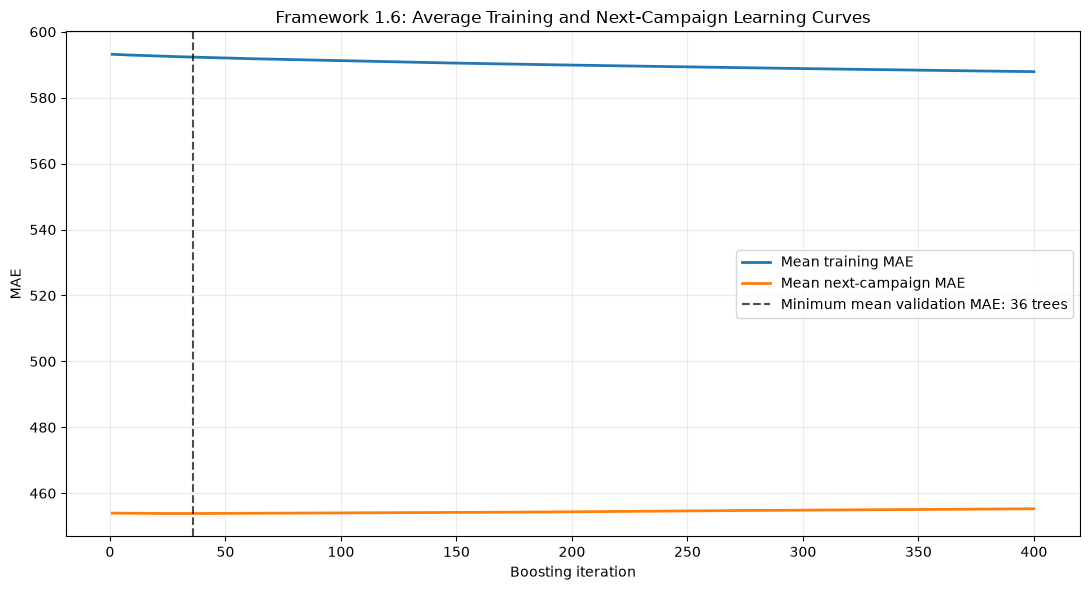

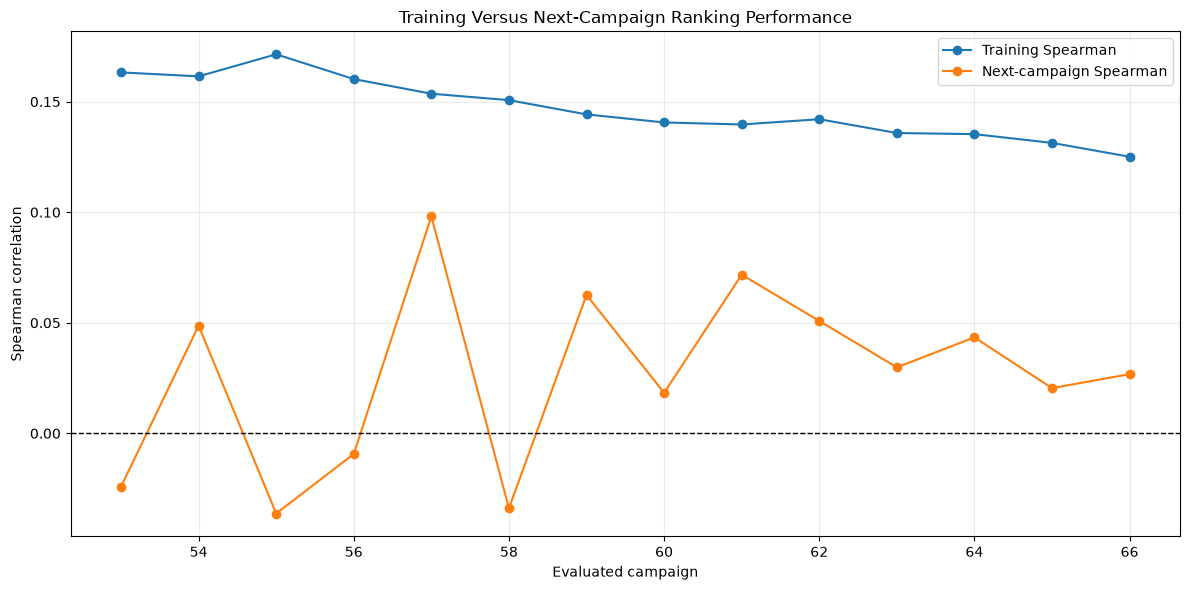


Overall diagnostic summary:


,metric,value
0,Median training MAE,588.281405
1,Median validation MAE,453.949874
2,Median MAE generalization gap,-127.929596
3,Median training R-squared,0.019839
4,Median validation R-squared,-0.005456
5,Median training Spearman,0.143154
6,Median validation Spearman,0.028304
7,Positive validation Spearman share,0.714286
8,Median diagnostic best iteration,56.500000
9,Median validation-loss deterioration rate,0.004105



Evidence flags:


,diagnostic,supports_overfitting,supports_underfitting,supports_weak_or_unstable_signal
0,Large training-validation rank gap,True,False,False
1,Large training-validation R-squared gap,False,False,False
2,Validation loss worsens before 400 trees,True,False,False
3,Weak fit even on training observations,False,False,False
4,Non-positive median future-campaign ranking,False,False,False



Campaign-level fixed-model diagnostics:


...


Most important features by average gain:


,feature,mean_gain_share
0,past_mean_win_profit_per_lot,0.124020
1,past_mean_loss_abs_profit_per_lot,0.119586
2,minutes_since_previous_trade_open,0.084651
3,past_trades_opened_per_active_hour,0.065059
4,past_payoff_ratio,0.065022
5,post_loss_reentry_gap_minutes,0.053720
6,trade_open_gap_to_past_median_ratio,0.051862
7,historical_median_amount_before_trade,0.051811
8,elapsed_active_hours,0.049845
9,minutes_since_previous_idea_start,0.044714



Feature-importance stability:


,previous_campaign,current_campaign,feature_importance_spearman
0,53,54,0.942107
1,54,55,0.967250
2,55,56,0.945793
3,56,57,0.974026
4,57,58,0.950311
5,58,59,0.950311
6,59,60,0.929983
7,60,61,0.897487
8,61,62,0.927422
9,62,63,0.896922



Average learning-curve minima:
Minimum mean next-campaign MAE: 36 trees
Minimum median next-campaign MAE: 1 trees

Saved overfitting/underfitting diagnostics to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_overfit_underfit_diagnostic


In [42]:
# ======================================================
# Framework 1 base-model fitting diagnosis
# ======================================================
#
# This cell diagnoses the Framework 1.6 strong-regularized
# LightGBM model using expanding-window validation.
#
# For evaluated campaign c:
#
#   Fixed model:
#       Train on every campaign < c.
#       Evaluate on campaign c.
#
#   Early-stopping benchmark:
#       Use the most recent campaign before c as an internal
#       validation campaign.
#       Use only earlier campaigns to determine best_iteration.
#       Refit on every campaign < c using best_iteration.
#       Evaluate once on campaign c.
#
# Campaign c is never used to select best_iteration in the
# leakage-safe early-stopping benchmark.
# ======================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from lightgbm import (
    LGBMRegressor,
    early_stopping,
    log_evaluation,
)


# ======================================================
# Configuration
# ======================================================

OVERFIT_DIAGNOSTIC_FRAMEWORK = (
    "framework_1_6_strong_q90"
)

OVERFIT_DIAGNOSTIC_QUANTILE = 0.90

OVERFIT_DIAGNOSTIC_FIXED_PARAMETERS = {
    "n_estimators": 400,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

# The early-stopping model is deliberately given a large
# maximum number of trees. Early stopping chooses how many
# are actually required.
OVERFIT_DIAGNOSTIC_MAX_ESTIMATORS = 3_000
OVERFIT_DIAGNOSTIC_STOPPING_ROUNDS = 100

OVERFIT_DIAGNOSTIC_OUTPUT_DIR = (
    OUTPUT_DIR
    / "framework_1_overfit_underfit_diagnostic"
)

OVERFIT_DIAGNOSTIC_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================
# Validate inputs
# ======================================================

if "historical_features" not in globals():
    raise RuntimeError(
        "historical_features is unavailable. "
        "Run the historical feature-engineering cells first."
    )

required_diagnostic_columns = {
    "trade_row_id",
    "campaign_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    *FEATURE_COLUMNS,
}

missing_diagnostic_columns = (
    required_diagnostic_columns
    - set(historical_features.columns)
)

if missing_diagnostic_columns:
    raise ValueError(
        "historical_features is missing required columns: "
        f"{sorted(missing_diagnostic_columns)}"
    )

diagnostic_data = historical_features.copy()

diagnostic_data = diagnostic_data.loc[
    diagnostic_data[
        "campaign_id"
    ].isin(
        TRAIN_CAMPAIGNS
        + VALIDATION_CAMPAIGNS
    )
].copy()

diagnostic_data["campaign_id"] = (
    diagnostic_data[
        "campaign_id"
    ].astype(int)
)

if diagnostic_data[
    "trade_row_id"
].duplicated().any():
    raise ValueError(
        "historical_features contains duplicate trade_row_id "
        "values."
    )

if diagnostic_data[
    [
        "amount",
        "reverse_profit",
        "reverse_profit_per_lot",
    ]
].isna().any().any():
    raise ValueError(
        "The diagnostic data contains missing outcome values."
    )

if not np.isfinite(
    diagnostic_data[
        [
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ].to_numpy(dtype=float)
).all():
    raise ValueError(
        "The diagnostic data contains non-finite outcomes."
    )

if diagnostic_data["amount"].le(0).any():
    raise ValueError(
        "The diagnostic data contains non-positive amounts."
    )

actual_validation_campaigns = set(
    diagnostic_data.loc[
        diagnostic_data[
            "campaign_id"
        ].isin(VALIDATION_CAMPAIGNS),
        "campaign_id",
    ].unique()
)

if actual_validation_campaigns != set(
    VALIDATION_CAMPAIGNS
):
    raise ValueError(
        "The diagnostic data does not contain all validation "
        "campaigns 53-66."
    )

print(
    "Model being diagnosed:",
    OVERFIT_DIAGNOSTIC_FRAMEWORK,
)

print(
    "Fixed tree count:",
    OVERFIT_DIAGNOSTIC_FIXED_PARAMETERS[
        "n_estimators"
    ],
)

print(
    "Current production-style model uses early stopping:",
    False,
)


# ======================================================
# Metric utilities
# ======================================================

def diagnostic_spearman(
    actual,
    predicted,
):
    """
    Return Spearman rank correlation.

    NaN is returned if either input is constant or there are
    fewer than three complete observations.
    """
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]

    if (
        len(actual) < 3
        or np.unique(actual).size < 2
        or np.unique(predicted).size < 2
    ):
        return np.nan

    correlation, _ = spearmanr(
        actual,
        predicted,
    )

    return float(correlation)


def diagnostic_prediction_metrics(
    actual,
    predicted,
):
    """
    Return standard regression and ranking metrics.
    """
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]

    if len(actual) == 0:
        return {
            "rmse": np.nan,
            "mae": np.nan,
            "r2": np.nan,
            "spearman_rho": np.nan,
        }

    rmse = float(
        np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        )
    )

    mae = float(
        mean_absolute_error(
            actual,
            predicted,
        )
    )

    r2 = (
        float(
            r2_score(
                actual,
                predicted,
            )
        )
        if len(actual) >= 2
        else np.nan
    )

    rank_correlation = diagnostic_spearman(
        actual,
        predicted,
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "spearman_rho": rank_correlation,
    }


def diagnostic_lot_weighted_edge(
    data,
    selected_mask,
):
    """
    Calculate lot-weighted RP/lot among selected trades.
    """
    selected_mask = np.asarray(
        selected_mask,
        dtype=bool,
    )

    selected = data.loc[
        selected_mask
    ].copy()

    if selected.empty:
        return np.nan

    total_lots = selected[
        "amount"
    ].sum()

    if (
        not np.isfinite(total_lots)
        or total_lots <= 0
    ):
        return np.nan

    return float(
        selected[
            "reverse_profit"
        ].sum()
        / total_lots
    )


def diagnostic_gate_metrics(
    data,
    scores,
    threshold,
):
    """
    Evaluate q90-gate coverage and lot-weighted edge.
    """
    scores = np.asarray(
        scores,
        dtype=float,
    )

    selected_mask = (
        scores >= threshold
    )

    return {
        "coverage": float(
            selected_mask.mean()
        ),
        "trades_selected": int(
            selected_mask.sum()
        ),
        "lot_weighted_rp_per_lot": (
            diagnostic_lot_weighted_edge(
                data=data,
                selected_mask=selected_mask,
            )
        ),
    }


def diagnostic_score_deciles(
    data,
    scores,
    dataset_name,
    campaign_id,
    model_name,
):
    """
    Calculate realised outcomes by prediction-score decile.
    """
    working = data[
        [
            "campaign_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ].copy()

    working["score"] = np.asarray(
        scores,
        dtype=float,
    )

    working = working.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna(
        subset=[
            "score",
            "amount",
            "reverse_profit",
        ]
    )

    if working.empty:
        return pd.DataFrame()

    number_of_unique_scores = working[
        "score"
    ].nunique()

    number_of_bins = min(
        10,
        number_of_unique_scores,
    )

    if number_of_bins < 2:
        return pd.DataFrame()

    # Ranking before qcut prevents duplicate bin-edge errors.
    working["score_decile"] = pd.qcut(
        working[
            "score"
        ].rank(
            method="first"
        ),
        q=number_of_bins,
        labels=False,
    ) + 1

    rows = []

    for score_decile, part in working.groupby(
        "score_decile",
        sort=True,
    ):
        total_lots = part[
            "amount"
        ].sum()

        edge = (
            part[
                "reverse_profit"
            ].sum()
            / total_lots
            if total_lots > 0
            else np.nan
        )

        rows.append(
            {
                "model": model_name,
                "campaign_id": campaign_id,
                "dataset": dataset_name,
                "score_decile": int(
                    score_decile
                ),
                "trades": len(part),
                "coverage": (
                    len(part)
                    / len(working)
                ),
                "mean_score": part[
                    "score"
                ].mean(),
                "mean_trade_rp_per_lot": part[
                    "reverse_profit_per_lot"
                ].mean(),
                "lot_weighted_rp_per_lot": (
                    edge
                ),
            }
        )

    return pd.DataFrame(rows)


# ======================================================
# Expanding-window fixed-model diagnosis
# ======================================================

fixed_metric_rows = []
learning_curve_rows = []
score_decile_frames = []
feature_importance_rows = []

fixed_tree_count = int(
    OVERFIT_DIAGNOSTIC_FIXED_PARAMETERS[
        "n_estimators"
    ]
)

for campaign_id in VALIDATION_CAMPAIGNS:
    print(
        f"\nFixed-model diagnosis for campaign "
        f"{campaign_id}..."
    )

    training_data = diagnostic_data.loc[
        diagnostic_data[
            "campaign_id"
        ] < campaign_id
    ].copy()

    validation_data = diagnostic_data.loc[
        diagnostic_data[
            "campaign_id"
        ] == campaign_id
    ].copy()

    if training_data.empty:
        raise ValueError(
            f"Campaign {campaign_id} has no training data."
        )

    if validation_data.empty:
        raise ValueError(
            f"Campaign {campaign_id} has no validation data."
        )

    X_train = training_data[
        FEATURE_COLUMNS
    ]

    y_train = training_data[
        "reverse_profit_per_lot"
    ]

    X_validation = validation_data[
        FEATURE_COLUMNS
    ]

    y_validation = validation_data[
        "reverse_profit_per_lot"
    ]

    fixed_model = LGBMRegressor(
        **OVERFIT_DIAGNOSTIC_FIXED_PARAMETERS
    )

    # The current campaign is supplied only for diagnostic
    # metric tracking. No early-stopping callback is used,
    # so it does not alter the fitted model or tree count.
    fixed_model.fit(
        X_train,
        y_train,
        eval_set=[
            (
                X_train,
                y_train,
            ),
            (
                X_validation,
                y_validation,
            ),
        ],
        eval_names=[
            "training",
            "next_campaign",
        ],
        eval_metric=[
            "l1",
            "l2",
        ],
        callbacks=[
            log_evaluation(period=0),
        ],
    )

    if fixed_model.best_iteration_ not in {
        0,
        fixed_tree_count,
        None,
    }:
        raise AssertionError(
            "The fixed model unexpectedly stopped early."
        )

    train_scores = np.asarray(
        fixed_model.predict(
            X_train
        ),
        dtype=float,
    )

    validation_scores = np.asarray(
        fixed_model.predict(
            X_validation
        ),
        dtype=float,
    )

    decision_threshold = float(
        np.quantile(
            train_scores,
            OVERFIT_DIAGNOSTIC_QUANTILE,
        )
    )

    train_prediction_metrics = (
        diagnostic_prediction_metrics(
            actual=y_train,
            predicted=train_scores,
        )
    )

    validation_prediction_metrics = (
        diagnostic_prediction_metrics(
            actual=y_validation,
            predicted=validation_scores,
        )
    )

    train_gate_metrics = (
        diagnostic_gate_metrics(
            data=training_data,
            scores=train_scores,
            threshold=decision_threshold,
        )
    )

    validation_gate_metrics = (
        diagnostic_gate_metrics(
            data=validation_data,
            scores=validation_scores,
            threshold=decision_threshold,
        )
    )

    evaluation_history = (
        fixed_model.evals_result_
    )

    training_l1 = np.asarray(
        evaluation_history[
            "training"
        ][
            "l1"
        ],
        dtype=float,
    )

    validation_l1 = np.asarray(
        evaluation_history[
            "next_campaign"
        ][
            "l1"
        ],
        dtype=float,
    )

    training_l2 = np.asarray(
        evaluation_history[
            "training"
        ][
            "l2"
        ],
        dtype=float,
    )

    validation_l2 = np.asarray(
        evaluation_history[
            "next_campaign"
        ][
            "l2"
        ],
        dtype=float,
    )

    if not (
        len(training_l1)
        == len(validation_l1)
        == len(training_l2)
        == len(validation_l2)
        == fixed_tree_count
    ):
        raise AssertionError(
            "Unexpected learning-curve length."
        )

    diagnostic_best_iteration = int(
        np.argmin(
            validation_l1
        ) + 1
    )

    diagnostic_best_validation_mae = float(
        validation_l1[
            diagnostic_best_iteration - 1
        ]
    )

    final_validation_mae = float(
        validation_l1[-1]
    )

    validation_mae_deterioration = (
        final_validation_mae
        - diagnostic_best_validation_mae
    )

    validation_mae_deterioration_rate = (
        validation_mae_deterioration
        / diagnostic_best_validation_mae
        if diagnostic_best_validation_mae > 0
        else np.nan
    )

    fixed_metric_rows.append(
        {
            "campaign_id": campaign_id,
            "training_campaign_start": int(
                training_data[
                    "campaign_id"
                ].min()
            ),
            "training_campaign_end": int(
                training_data[
                    "campaign_id"
                ].max()
            ),
            "training_rows": len(
                training_data
            ),
            "validation_rows": len(
                validation_data
            ),
            "fixed_estimators": (
                fixed_tree_count
            ),
            "diagnostic_best_iteration": (
                diagnostic_best_iteration
            ),
            "final_training_curve_mae": float(
                training_l1[-1]
            ),
            "best_validation_curve_mae": (
                diagnostic_best_validation_mae
            ),
            "final_validation_curve_mae": (
                final_validation_mae
            ),
            "validation_mae_deterioration": (
                validation_mae_deterioration
            ),
            "validation_mae_deterioration_rate": (
                validation_mae_deterioration_rate
            ),
            "training_rmse": (
                train_prediction_metrics[
                    "rmse"
                ]
            ),
            "validation_rmse": (
                validation_prediction_metrics[
                    "rmse"
                ]
            ),
            "rmse_generalization_gap": (
                validation_prediction_metrics[
                    "rmse"
                ]
                - train_prediction_metrics[
                    "rmse"
                ]
            ),
            "training_mae": (
                train_prediction_metrics[
                    "mae"
                ]
            ),
            "validation_mae": (
                validation_prediction_metrics[
                    "mae"
                ]
            ),
            "mae_generalization_gap": (
                validation_prediction_metrics[
                    "mae"
                ]
                - train_prediction_metrics[
                    "mae"
                ]
            ),
            "training_r2": (
                train_prediction_metrics[
                    "r2"
                ]
            ),
            "validation_r2": (
                validation_prediction_metrics[
                    "r2"
                ]
            ),
            "r2_generalization_gap": (
                train_prediction_metrics[
                    "r2"
                ]
                - validation_prediction_metrics[
                    "r2"
                ]
            ),
            "training_spearman_rho": (
                train_prediction_metrics[
                    "spearman_rho"
                ]
            ),
            "validation_spearman_rho": (
                validation_prediction_metrics[
                    "spearman_rho"
                ]
            ),
            "spearman_generalization_gap": (
                train_prediction_metrics[
                    "spearman_rho"
                ]
                - validation_prediction_metrics[
                    "spearman_rho"
                ]
            ),
            "decision_threshold": (
                decision_threshold
            ),
            "training_coverage": (
                train_gate_metrics[
                    "coverage"
                ]
            ),
            "validation_coverage": (
                validation_gate_metrics[
                    "coverage"
                ]
            ),
            "training_trades_selected": (
                train_gate_metrics[
                    "trades_selected"
                ]
            ),
            "validation_trades_selected": (
                validation_gate_metrics[
                    "trades_selected"
                ]
            ),
            "training_lot_weighted_rp_per_lot": (
                train_gate_metrics[
                    "lot_weighted_rp_per_lot"
                ]
            ),
            "validation_lot_weighted_rp_per_lot": (
                validation_gate_metrics[
                    "lot_weighted_rp_per_lot"
                ]
            ),
            "gate_edge_generalization_gap": (
                train_gate_metrics[
                    "lot_weighted_rp_per_lot"
                ]
                - validation_gate_metrics[
                    "lot_weighted_rp_per_lot"
                ]
            ),
        }
    )

    for iteration in range(
        fixed_tree_count
    ):
        learning_curve_rows.append(
            {
                "campaign_id": campaign_id,
                "iteration": iteration + 1,
                "training_mae": (
                    training_l1[
                        iteration
                    ]
                ),
                "validation_mae": (
                    validation_l1[
                        iteration
                    ]
                ),
                "training_rmse": float(
                    np.sqrt(
                        training_l2[
                            iteration
                        ]
                    )
                ),
                "validation_rmse": float(
                    np.sqrt(
                        validation_l2[
                            iteration
                        ]
                    )
                ),
            }
        )

    feature_importance_rows.extend(
        {
            "campaign_id": campaign_id,
            "feature": feature_name,
            "gain_importance": importance_value,
        }
        for feature_name, importance_value
        in zip(
            FEATURE_COLUMNS,
            fixed_model.booster_.feature_importance(
                importance_type="gain"
            ),
        )
    )

    training_deciles = (
        diagnostic_score_deciles(
            data=training_data,
            scores=train_scores,
            dataset_name="training",
            campaign_id=campaign_id,
            model_name="fixed_400",
        )
    )

    validation_deciles = (
        diagnostic_score_deciles(
            data=validation_data,
            scores=validation_scores,
            dataset_name="validation",
            campaign_id=campaign_id,
            model_name="fixed_400",
        )
    )

    if not training_deciles.empty:
        score_decile_frames.append(
            training_deciles
        )

    if not validation_deciles.empty:
        score_decile_frames.append(
            validation_deciles
        )

    print(
        f"  training MAE="
        f"{train_prediction_metrics['mae']:.4f}, "
        f"validation MAE="
        f"{validation_prediction_metrics['mae']:.4f}"
    )

    print(
        f"  training Spearman="
        f"{train_prediction_metrics['spearman_rho']:.4f}, "
        f"validation Spearman="
        f"{validation_prediction_metrics['spearman_rho']:.4f}"
    )

    print(
        f"  diagnostic validation-loss minimum="
        f"iteration {diagnostic_best_iteration}; "
        f"fixed model uses {fixed_tree_count}"
    )


fixed_diagnostic_results = pd.DataFrame(
    fixed_metric_rows
)

fixed_learning_curves = pd.DataFrame(
    learning_curve_rows
)

fixed_feature_importance = pd.DataFrame(
    feature_importance_rows
)

fixed_score_deciles = (
    pd.concat(
        score_decile_frames,
        ignore_index=True,
    )
    if score_decile_frames
    else pd.DataFrame()
)


# ======================================================
# Leakage-safe early-stopping benchmark
# ======================================================

early_stopping_rows = []
early_stopping_decision_frames = []

for campaign_id in VALIDATION_CAMPAIGNS:
    print(
        f"\nLeakage-safe early stopping for campaign "
        f"{campaign_id}..."
    )

    all_prior_data = diagnostic_data.loc[
        diagnostic_data[
            "campaign_id"
        ] < campaign_id
    ].copy()

    current_campaign_data = diagnostic_data.loc[
        diagnostic_data[
            "campaign_id"
        ] == campaign_id
    ].copy()

    prior_campaigns = sorted(
        all_prior_data[
            "campaign_id"
        ].unique()
    )

    if len(prior_campaigns) < 2:
        raise ValueError(
            f"Campaign {campaign_id} does not have enough "
            "prior campaigns for internal validation."
        )

    # The most recent available prior campaign becomes the
    # internal early-stopping validation set.
    internal_validation_campaign = int(
        prior_campaigns[-1]
    )

    internal_training_data = (
        all_prior_data.loc[
            all_prior_data[
                "campaign_id"
            ] < internal_validation_campaign
        ]
        .copy()
    )

    internal_validation_data = (
        all_prior_data.loc[
            all_prior_data[
                "campaign_id"
            ] == internal_validation_campaign
        ]
        .copy()
    )

    if (
        internal_training_data.empty
        or internal_validation_data.empty
        or current_campaign_data.empty
    ):
        raise ValueError(
            f"Invalid early-stopping split for campaign "
            f"{campaign_id}."
        )

    early_stopping_parameters = {
        **OVERFIT_DIAGNOSTIC_FIXED_PARAMETERS,
        "n_estimators": (
            OVERFIT_DIAGNOSTIC_MAX_ESTIMATORS
        ),
    }

    tuning_model = LGBMRegressor(
        **early_stopping_parameters
    )

    tuning_model.fit(
        internal_training_data[
            FEATURE_COLUMNS
        ],
        internal_training_data[
            "reverse_profit_per_lot"
        ],
        eval_set=[
            (
                internal_validation_data[
                    FEATURE_COLUMNS
                ],
                internal_validation_data[
                    "reverse_profit_per_lot"
                ],
            ),
        ],
        eval_names=[
            "internal_validation",
        ],
        eval_metric="l1",
        callbacks=[
            early_stopping(
                stopping_rounds=(
                    OVERFIT_DIAGNOSTIC_STOPPING_ROUNDS
                ),
                first_metric_only=True,
                verbose=False,
            ),
            log_evaluation(period=0),
        ],
    )

    selected_iteration = int(
        tuning_model.best_iteration_
    )

    if selected_iteration <= 0:
        raise AssertionError(
            f"Campaign {campaign_id}: LightGBM did not "
            "produce a valid best_iteration_."
        )

    # Refit on all data available before the current campaign.
    # This allows the internal validation campaign to be used
    # in the final training fit after tree count is selected.
    refit_parameters = {
        **OVERFIT_DIAGNOSTIC_FIXED_PARAMETERS,
        "n_estimators": selected_iteration,
    }

    refitted_model = LGBMRegressor(
        **refit_parameters
    )

    refitted_model.fit(
        all_prior_data[
            FEATURE_COLUMNS
        ],
        all_prior_data[
            "reverse_profit_per_lot"
        ],
        callbacks=[
            log_evaluation(period=0),
        ],
    )

    prior_scores = np.asarray(
        refitted_model.predict(
            all_prior_data[
                FEATURE_COLUMNS
            ]
        ),
        dtype=float,
    )

    current_scores = np.asarray(
        refitted_model.predict(
            current_campaign_data[
                FEATURE_COLUMNS
            ]
        ),
        dtype=float,
    )

    selected_threshold = float(
        np.quantile(
            prior_scores,
            OVERFIT_DIAGNOSTIC_QUANTILE,
        )
    )

    current_predictions = (
        current_scores
        >= selected_threshold
    )

    prior_prediction_metrics = (
        diagnostic_prediction_metrics(
            actual=all_prior_data[
                "reverse_profit_per_lot"
            ],
            predicted=prior_scores,
        )
    )

    current_prediction_metrics = (
        diagnostic_prediction_metrics(
            actual=current_campaign_data[
                "reverse_profit_per_lot"
            ],
            predicted=current_scores,
        )
    )

    prior_gate_metrics = (
        diagnostic_gate_metrics(
            data=all_prior_data,
            scores=prior_scores,
            threshold=selected_threshold,
        )
    )

    current_gate_metrics = (
        diagnostic_gate_metrics(
            data=current_campaign_data,
            scores=current_scores,
            threshold=selected_threshold,
        )
    )

    early_stopping_rows.append(
        {
            "campaign_id": campaign_id,
            "internal_validation_campaign": (
                internal_validation_campaign
            ),
            "internal_training_rows": len(
                internal_training_data
            ),
            "internal_validation_rows": len(
                internal_validation_data
            ),
            "full_prior_training_rows": len(
                all_prior_data
            ),
            "maximum_estimators": (
                OVERFIT_DIAGNOSTIC_MAX_ESTIMATORS
            ),
            "selected_iteration": (
                selected_iteration
            ),
            "stopped_before_fixed_400": (
                selected_iteration
                < fixed_tree_count
            ),
            "decision_threshold": (
                selected_threshold
            ),
            "training_rmse": (
                prior_prediction_metrics[
                    "rmse"
                ]
            ),
            "validation_rmse": (
                current_prediction_metrics[
                    "rmse"
                ]
            ),
            "training_mae": (
                prior_prediction_metrics[
                    "mae"
                ]
            ),
            "validation_mae": (
                current_prediction_metrics[
                    "mae"
                ]
            ),
            "training_r2": (
                prior_prediction_metrics[
                    "r2"
                ]
            ),
            "validation_r2": (
                current_prediction_metrics[
                    "r2"
                ]
            ),
            "training_spearman_rho": (
                prior_prediction_metrics[
                    "spearman_rho"
                ]
            ),
            "validation_spearman_rho": (
                current_prediction_metrics[
                    "spearman_rho"
                ]
            ),
            "training_coverage": (
                prior_gate_metrics[
                    "coverage"
                ]
            ),
            "validation_coverage": (
                current_gate_metrics[
                    "coverage"
                ]
            ),
            "training_lot_weighted_rp_per_lot": (
                prior_gate_metrics[
                    "lot_weighted_rp_per_lot"
                ]
            ),
            "validation_lot_weighted_rp_per_lot": (
                current_gate_metrics[
                    "lot_weighted_rp_per_lot"
                ]
            ),
        }
    )

    decision_frame = current_campaign_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "person_id",
            "amount",
            "reverse_profit",
            "open_date_time",
        ]
    ].copy()

    decision_frame["framework"] = (
        "framework_1_early_stopping_diagnostic"
    )

    decision_frame["score"] = (
        current_scores
    )

    decision_frame["threshold"] = (
        selected_threshold
    )

    decision_frame["fade_decision"] = (
        current_predictions.astype(bool)
    )

    early_stopping_decision_frames.append(
        decision_frame
    )

    print(
        f"  internal validation campaign="
        f"{internal_validation_campaign}, "
        f"selected trees={selected_iteration}"
    )

    print(
        f"  next-campaign MAE="
        f"{current_prediction_metrics['mae']:.4f}, "
        f"Spearman="
        f"{current_prediction_metrics['spearman_rho']:.4f}, "
        f"gate edge="
        f"{current_gate_metrics['lot_weighted_rp_per_lot']:.4f}"
    )


early_stopping_diagnostic_results = pd.DataFrame(
    early_stopping_rows
)

early_stopping_diagnostic_decisions = pd.concat(
    early_stopping_decision_frames,
    ignore_index=True,
)


# ======================================================
# Compare fixed and early-stopped models
# ======================================================

comparison_columns = [
    "campaign_id",
    "validation_rmse",
    "validation_mae",
    "validation_r2",
    "validation_spearman_rho",
    "validation_coverage",
    "validation_lot_weighted_rp_per_lot",
]

fixed_comparison = (
    fixed_diagnostic_results[
        comparison_columns
    ]
    .rename(
        columns={
            column: f"fixed_{column}"
            for column in comparison_columns
            if column != "campaign_id"
        }
    )
)

early_stopping_comparison = (
    early_stopping_diagnostic_results[
        [
            "campaign_id",
            "selected_iteration",
            *comparison_columns[1:],
        ]
    ]
    .rename(
        columns={
            column: f"early_stopping_{column}"
            for column in comparison_columns
            if column != "campaign_id"
        }
    )
)

fixed_vs_early_stopping = (
    fixed_comparison.merge(
        early_stopping_comparison,
        on="campaign_id",
        how="inner",
        validate="one_to_one",
    )
)

fixed_vs_early_stopping[
    "early_stopping_mae_improvement"
] = (
    fixed_vs_early_stopping[
        "fixed_validation_mae"
    ]
    - fixed_vs_early_stopping[
        "early_stopping_validation_mae"
    ]
)

fixed_vs_early_stopping[
    "early_stopping_rmse_improvement"
] = (
    fixed_vs_early_stopping[
        "fixed_validation_rmse"
    ]
    - fixed_vs_early_stopping[
        "early_stopping_validation_rmse"
    ]
)

fixed_vs_early_stopping[
    "early_stopping_spearman_improvement"
] = (
    fixed_vs_early_stopping[
        "early_stopping_validation_spearman_rho"
    ]
    - fixed_vs_early_stopping[
        "fixed_validation_spearman_rho"
    ]
)

fixed_vs_early_stopping[
    "early_stopping_edge_improvement"
] = (
    fixed_vs_early_stopping[
        "early_stopping_validation_lot_weighted_rp_per_lot"
    ]
    - fixed_vs_early_stopping[
        "fixed_validation_lot_weighted_rp_per_lot"
    ]
)


# ======================================================
# Aggregate score-decile behaviour
# ======================================================

if not fixed_score_deciles.empty:
    aggregate_score_deciles = (
        fixed_score_deciles.groupby(
            [
                "dataset",
                "score_decile",
            ],
            as_index=False,
        )
        .agg(
            campaigns=(
                "campaign_id",
                "nunique",
            ),
            trades=(
                "trades",
                "sum",
            ),
            mean_score=(
                "mean_score",
                "mean",
            ),
            mean_trade_rp_per_lot=(
                "mean_trade_rp_per_lot",
                "mean",
            ),
            mean_campaign_lot_weighted_rp_per_lot=(
                "lot_weighted_rp_per_lot",
                "mean",
            ),
        )
    )
else:
    aggregate_score_deciles = pd.DataFrame()


# ======================================================
# Feature-importance stability
# ======================================================

feature_importance_matrix = (
    fixed_feature_importance.pivot(
        index="campaign_id",
        columns="feature",
        values="gain_importance",
    )
    .fillna(0.0)
    .sort_index()
)

feature_importance_shares = (
    feature_importance_matrix.div(
        feature_importance_matrix.sum(axis=1).replace(
            0,
            np.nan,
        ),
        axis=0,
    )
    .fillna(0.0)
)

feature_importance_stability_rows = []

importance_campaigns = list(
    feature_importance_shares.index
)

for previous_campaign, current_campaign in zip(
    importance_campaigns[:-1],
    importance_campaigns[1:],
):
    stability = diagnostic_spearman(
        feature_importance_shares.loc[
            previous_campaign
        ].to_numpy(),
        feature_importance_shares.loc[
            current_campaign
        ].to_numpy(),
    )

    feature_importance_stability_rows.append(
        {
            "previous_campaign": (
                previous_campaign
            ),
            "current_campaign": (
                current_campaign
            ),
            "feature_importance_spearman": (
                stability
            ),
        }
    )

feature_importance_stability = pd.DataFrame(
    feature_importance_stability_rows
)

mean_feature_importance = (
    feature_importance_shares.mean(axis=0)
    .sort_values(ascending=False)
    .rename("mean_gain_share")
    .reset_index()
)


# ======================================================
# Aggregate diagnostic summary
# ======================================================

diagnostic_summary = pd.DataFrame(
    {
        "metric": [
            "Median training MAE",
            "Median validation MAE",
            "Median MAE generalization gap",
            "Median training R-squared",
            "Median validation R-squared",
            "Median training Spearman",
            "Median validation Spearman",
            "Positive validation Spearman share",
            "Median diagnostic best iteration",
            "Median validation-loss deterioration rate",
            "Median training gated RP/lot",
            "Median validation gated RP/lot",
            "Positive validation gated-edge share",
            "Median early-stopping selected iteration",
            "Early stopping improves validation MAE share",
            "Early stopping improves validation Spearman share",
            "Median adjacent feature-importance stability",
        ],
        "value": [
            fixed_diagnostic_results[
                "training_mae"
            ].median(),
            fixed_diagnostic_results[
                "validation_mae"
            ].median(),
            fixed_diagnostic_results[
                "mae_generalization_gap"
            ].median(),
            fixed_diagnostic_results[
                "training_r2"
            ].median(),
            fixed_diagnostic_results[
                "validation_r2"
            ].median(),
            fixed_diagnostic_results[
                "training_spearman_rho"
            ].median(),
            fixed_diagnostic_results[
                "validation_spearman_rho"
            ].median(),
            fixed_diagnostic_results[
                "validation_spearman_rho"
            ].gt(0).mean(),
            fixed_diagnostic_results[
                "diagnostic_best_iteration"
            ].median(),
            fixed_diagnostic_results[
                "validation_mae_deterioration_rate"
            ].median(),
            fixed_diagnostic_results[
                "training_lot_weighted_rp_per_lot"
            ].median(),
            fixed_diagnostic_results[
                "validation_lot_weighted_rp_per_lot"
            ].median(),
            fixed_diagnostic_results[
                "validation_lot_weighted_rp_per_lot"
            ].gt(0).mean(),
            early_stopping_diagnostic_results[
                "selected_iteration"
            ].median(),
            fixed_vs_early_stopping[
                "early_stopping_mae_improvement"
            ].gt(0).mean(),
            fixed_vs_early_stopping[
                "early_stopping_spearman_improvement"
            ].gt(0).mean(),
            (
                feature_importance_stability[
                    "feature_importance_spearman"
                ].median()
                if not feature_importance_stability.empty
                else np.nan
            ),
        ],
    }
)


# ======================================================
# Evidence flags
# ======================================================

median_training_spearman = (
    fixed_diagnostic_results[
        "training_spearman_rho"
    ].median()
)

median_validation_spearman = (
    fixed_diagnostic_results[
        "validation_spearman_rho"
    ].median()
)

median_training_r2 = (
    fixed_diagnostic_results[
        "training_r2"
    ].median()
)

median_validation_r2 = (
    fixed_diagnostic_results[
        "validation_r2"
    ].median()
)

median_best_iteration = (
    fixed_diagnostic_results[
        "diagnostic_best_iteration"
    ].median()
)

median_deterioration_rate = (
    fixed_diagnostic_results[
        "validation_mae_deterioration_rate"
    ].median()
)

overfitting_rank_gap = (
    np.isfinite(median_training_spearman)
    and np.isfinite(median_validation_spearman)
    and (
        median_training_spearman
        - median_validation_spearman
    ) > 0.10
)

overfitting_r2_gap = (
    np.isfinite(median_training_r2)
    and np.isfinite(median_validation_r2)
    and (
        median_training_r2
        - median_validation_r2
    ) > 0.10
)

overfitting_curve_evidence = (
    np.isfinite(median_best_iteration)
    and median_best_iteration
    < 0.80 * fixed_tree_count
    and np.isfinite(median_deterioration_rate)
    and median_deterioration_rate > 0
)

underfitting_training_evidence = (
    np.isfinite(median_training_spearman)
    and np.isfinite(median_training_r2)
    and median_training_spearman < 0.10
    and median_training_r2 < 0.05
)

weak_generalization_evidence = (
    np.isfinite(median_validation_spearman)
    and median_validation_spearman <= 0
)

diagnostic_flags = pd.DataFrame(
    {
        "diagnostic": [
            "Large training-validation rank gap",
            "Large training-validation R-squared gap",
            "Validation loss worsens before 400 trees",
            "Weak fit even on training observations",
            "Non-positive median future-campaign ranking",
        ],
        "supports_overfitting": [
            overfitting_rank_gap,
            overfitting_r2_gap,
            overfitting_curve_evidence,
            False,
            False,
        ],
        "supports_underfitting": [
            False,
            False,
            False,
            underfitting_training_evidence,
            False,
        ],
        "supports_weak_or_unstable_signal": [
            False,
            False,
            False,
            underfitting_training_evidence,
            weak_generalization_evidence,
        ],
    }
)


# ======================================================
# Plot average learning curves
# ======================================================

average_learning_curve = (
    fixed_learning_curves.groupby(
        "iteration",
        as_index=False,
    )
    .agg(
        mean_training_mae=(
            "training_mae",
            "mean",
        ),
        mean_validation_mae=(
            "validation_mae",
            "mean",
        ),
        median_training_mae=(
            "training_mae",
            "median",
        ),
        median_validation_mae=(
            "validation_mae",
            "median",
        ),
    )
)

mean_validation_best_iteration = int(
    average_learning_curve.loc[
        average_learning_curve[
            "mean_validation_mae"
        ].idxmin(),
        "iteration",
    ]
)

median_validation_best_iteration = int(
    average_learning_curve.loc[
        average_learning_curve[
            "median_validation_mae"
        ].idxmin(),
        "iteration",
    ]
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    average_learning_curve[
        "iteration"
    ],
    average_learning_curve[
        "mean_training_mae"
    ],
    label="Mean training MAE",
    linewidth=2,
)

plt.plot(
    average_learning_curve[
        "iteration"
    ],
    average_learning_curve[
        "mean_validation_mae"
    ],
    label="Mean next-campaign MAE",
    linewidth=2,
)

plt.axvline(
    mean_validation_best_iteration,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=(
        "Minimum mean validation MAE: "
        f"{mean_validation_best_iteration} trees"
    ),
)

plt.xlabel("Boosting iteration")
plt.ylabel("MAE")
plt.title(
    "Framework 1.6: Average Training and "
    "Next-Campaign Learning Curves"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

learning_curve_plot_path = (
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "average_learning_curve.png"
)

plt.savefig(
    learning_curve_plot_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ======================================================
# Plot campaign-level generalization
# ======================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    fixed_diagnostic_results[
        "campaign_id"
    ],
    fixed_diagnostic_results[
        "training_spearman_rho"
    ],
    marker="o",
    label="Training Spearman",
)

plt.plot(
    fixed_diagnostic_results[
        "campaign_id"
    ],
    fixed_diagnostic_results[
        "validation_spearman_rho"
    ],
    marker="o",
    label="Next-campaign Spearman",
)

plt.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

plt.xlabel("Evaluated campaign")
plt.ylabel("Spearman correlation")
plt.title(
    "Training Versus Next-Campaign Ranking Performance"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

spearman_plot_path = (
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "training_validation_spearman.png"
)

plt.savefig(
    spearman_plot_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ======================================================
# Display results
# ======================================================

print(
    "\nOverall diagnostic summary:"
)

display(
    diagnostic_summary.round(6)
)

print(
    "\nEvidence flags:"
)

display(
    diagnostic_flags
)

print(
    "\nCampaign-level fixed-model diagnostics:"
)

display(
    fixed_diagnostic_results.round(6)
)

print(
    "\nFixed 400 trees versus leakage-safe early stopping:"
)

display(
    fixed_vs_early_stopping.round(6)
)

print(
    "\nScore-decile behaviour:"
)

display(
    aggregate_score_deciles.round(6)
)

print(
    "\nMost important features by average gain:"
)

display(
    mean_feature_importance.head(
        15
    ).round(6)
)

print(
    "\nFeature-importance stability:"
)

display(
    feature_importance_stability.round(6)
)

print(
    "\nAverage learning-curve minima:"
)

print(
    "Minimum mean next-campaign MAE:",
    mean_validation_best_iteration,
    "trees",
)

print(
    "Minimum median next-campaign MAE:",
    median_validation_best_iteration,
    "trees",
)


# ======================================================
# Save outputs
# ======================================================

fixed_diagnostic_results.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "fixed_model_campaign_diagnostics.csv",
    index=False,
)

fixed_learning_curves.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "fixed_model_learning_curves.csv",
    index=False,
)

fixed_score_deciles.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "fixed_model_score_deciles.csv",
    index=False,
)

aggregate_score_deciles.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "aggregate_score_deciles.csv",
    index=False,
)

fixed_feature_importance.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "feature_importance_by_campaign.csv",
    index=False,
)

feature_importance_stability.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "feature_importance_stability.csv",
    index=False,
)

early_stopping_diagnostic_results.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "early_stopping_campaign_diagnostics.csv",
    index=False,
)

early_stopping_diagnostic_decisions.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "early_stopping_validation_decisions.csv",
    index=False,
)

fixed_vs_early_stopping.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "fixed_vs_early_stopping.csv",
    index=False,
)

diagnostic_summary.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "diagnostic_summary.csv",
    index=False,
)

diagnostic_flags.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "diagnostic_flags.csv",
    index=False,
)

average_learning_curve.to_csv(
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR
    / "average_learning_curve.csv",
    index=False,
)

print(
    "\nSaved overfitting/underfitting diagnostics to:",
    OVERFIT_DIAGNOSTIC_OUTPUT_DIR,
)

## Framework 1.11 - Early stopping

In [43]:
# ======================================================
# Framework 1.11:
# Leakage-safe early stopping with causal q90 selection
# ======================================================
#
# For each validation campaign c:
#
# 1. Use only campaigns before c.
# 2. Run early stopping on the three most recent eligible
#    historical campaign splits.
# 3. Take the median best iteration.
# 4. Restrict the selected tree count to 25-400.
# 5. Refit on all campaigns before c.
# 6. Calibrate the q90 gate on training predictions only.
# 7. Score campaign c without using its outcomes or future
#    score distribution.
#
# This is an exploratory validation framework.
# It does not use sealed campaigns.
# ======================================================

from hashlib import sha256
import json

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMRegressor,
    early_stopping,
    log_evaluation,
)


# ======================================================
# Configuration
# ======================================================

FRAMEWORK_1_11_NAME = (
    "framework_1_11_early_stopped_q90"
)

FRAMEWORK_1_11_PARAMETERS = {
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_11_QUANTILE = 0.90

# Early stopping initially has a high ceiling.
FRAMEWORK_1_11_MAXIMUM_TUNING_TREES = 1_500

FRAMEWORK_1_11_STOPPING_ROUNDS = 100

# Use the most recent three historical campaigns as
# separate early-stopping validation folds.
FRAMEWORK_1_11_NUMBER_OF_TUNING_FOLDS = 3

# Avoid degenerate one-tree models and prevent the selected
# model from becoming more complex than Framework 1.6.
FRAMEWORK_1_11_MINIMUM_TREES = 25
FRAMEWORK_1_11_MAXIMUM_TREES = 400

FRAMEWORK_1_11_OUTPUT_DIR = (
    OUTPUT_DIR / "framework_1_11"
)

FRAMEWORK_1_11_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================
# Validate required data and functions
# ======================================================

if "historical_features" not in globals():
    raise RuntimeError(
        "historical_features is unavailable. "
        "Run the historical feature-engineering cells first."
    )

if "evaluate_frameworks" not in globals():
    raise RuntimeError(
        "evaluate_frameworks is unavailable. "
        "Run the shared evaluation-utility cell first."
    )

required_framework_1_11_columns = {
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
    *FEATURE_COLUMNS,
}

missing_framework_1_11_columns = (
    required_framework_1_11_columns
    - set(historical_features.columns)
)

if missing_framework_1_11_columns:
    raise ValueError(
        "historical_features is missing required columns: "
        f"{sorted(missing_framework_1_11_columns)}"
    )

framework_1_11_feature_data = (
    historical_features.copy()
)

framework_1_11_feature_data[
    "campaign_id"
] = framework_1_11_feature_data[
    "campaign_id"
].astype(int)

if framework_1_11_feature_data[
    "trade_row_id"
].duplicated().any():
    raise ValueError(
        "historical_features contains duplicate trade_row_id "
        "values."
    )

if framework_1_11_feature_data[
    [
        "amount",
        "reverse_profit",
        "reverse_profit_per_lot",
    ]
].isna().any().any():
    raise ValueError(
        "Historical features contain missing outcomes."
    )

if not np.isfinite(
    framework_1_11_feature_data[
        [
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ].to_numpy(dtype=float)
).all():
    raise ValueError(
        "Historical features contain non-finite outcomes."
    )

if framework_1_11_feature_data[
    "amount"
].le(0).any():
    raise ValueError(
        "Historical features contain non-positive "
        "trade amounts."
    )

actual_framework_1_11_validation_campaigns = set(
    framework_1_11_feature_data.loc[
        framework_1_11_feature_data[
            "campaign_id"
        ].isin(VALIDATION_CAMPAIGNS),
        "campaign_id",
    ].unique()
)

if actual_framework_1_11_validation_campaigns != set(
    VALIDATION_CAMPAIGNS
):
    raise ValueError(
        "Historical features do not contain all validation "
        "campaigns 53-66."
    )


# ======================================================
# Deterministic tie-breaking utility
# ======================================================

def framework_1_11_hash_fraction(
    trade_row_id,
    seed=SEED,
):
    """
    Map trade_row_id deterministically to a value in [0, 1).

    This is used only to resolve tied model scores. It does
    not use outcomes, future trades, or campaign-level ranks.
    """
    encoded_value = (
        f"{seed}|{trade_row_id}"
    ).encode("utf-8")

    digest = sha256(
        encoded_value
    ).digest()

    integer_value = int.from_bytes(
        digest[:8],
        byteorder="big",
        signed=False,
    )

    return integer_value / float(2**64)


def framework_1_11_hash_fractions(
    trade_row_ids,
    seed=SEED,
):
    """
    Vectorised wrapper for deterministic tie-breaking.
    """
    return np.asarray(
        [
            framework_1_11_hash_fraction(
                trade_row_id=value,
                seed=seed,
            )
            for value in trade_row_ids
        ],
        dtype=float,
    )


# ======================================================
# Causal q90 threshold calibration
# ======================================================

def framework_1_11_calibrate_gate(
    training_scores,
    quantile,
):
    """
    Calibrate a training-score quantile gate.

    The returned tie_fraction ensures approximately the
    requested training coverage when many predictions equal
    the cutoff.

    No evaluation-campaign scores are used.
    """
    training_scores = np.asarray(
        training_scores,
        dtype=float,
    )

    if len(training_scores) == 0:
        raise ValueError(
            "Training scores are empty."
        )

    if not np.isfinite(
        training_scores
    ).all():
        raise ValueError(
            "Training scores contain non-finite values."
        )

    if not 0 < quantile < 1:
        raise ValueError(
            "Selection quantile must lie between zero and one."
        )

    number_of_training_rows = len(
        training_scores
    )

    target_selected_count = max(
        1,
        int(
            np.ceil(
                (1.0 - quantile)
                * number_of_training_rows
            )
        ),
    )

    sorted_scores = np.sort(
        training_scores
    )

    cutoff_index = max(
        0,
        number_of_training_rows
        - target_selected_count,
    )

    threshold = float(
        sorted_scores[
            cutoff_index
        ]
    )

    strictly_above_count = int(
        np.count_nonzero(
            training_scores > threshold
        )
    )

    equal_count = int(
        np.count_nonzero(
            training_scores == threshold
        )
    )

    required_from_ties = max(
        0,
        target_selected_count
        - strictly_above_count,
    )

    if equal_count == 0:
        tie_fraction = 0.0
    else:
        tie_fraction = float(
            np.clip(
                required_from_ties
                / equal_count,
                0.0,
                1.0,
            )
        )

    return {
        "threshold": threshold,
        "tie_fraction": tie_fraction,
        "target_selected_count": (
            target_selected_count
        ),
        "strictly_above_count": (
            strictly_above_count
        ),
        "equal_count": equal_count,
        "required_from_ties": (
            required_from_ties
        ),
        "target_training_coverage": (
            target_selected_count
            / number_of_training_rows
        ),
    }


def framework_1_11_apply_gate(
    scores,
    trade_row_ids,
    threshold,
    tie_fraction,
):
    """
    Apply the causal threshold and deterministic tie rule.

    Trades above the training threshold are selected.

    Trades exactly equal to the threshold are selected using
    a fixed hash fraction calibrated from training data.
    """
    scores = np.asarray(
        scores,
        dtype=float,
    )

    trade_row_ids = np.asarray(
        trade_row_ids
    )

    if len(scores) != len(trade_row_ids):
        raise ValueError(
            "Score and trade-row arrays have different lengths."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Evaluation scores contain non-finite values."
        )

    strictly_above = (
        scores > threshold
    )

    tied = (
        scores == threshold
    )

    decisions = strictly_above.copy()

    if tied.any() and tie_fraction > 0:
        tied_hash_fractions = (
            framework_1_11_hash_fractions(
                trade_row_ids[
                    tied
                ],
                seed=SEED,
            )
        )

        decisions[tied] = (
            tied_hash_fractions
            < tie_fraction
        )

    return decisions.astype(bool)


# ======================================================
# Early-stopping fold selection
# ======================================================

def framework_1_11_tuning_campaigns(
    available_campaigns,
):
    """
    Return the most recent eligible historical campaigns for
    early-stopping tuning.

    Each tuning campaign must have at least one earlier
    campaign available for model fitting.
    """
    available_campaigns = sorted(
        int(campaign_id)
        for campaign_id
        in available_campaigns
    )

    eligible_campaigns = [
        campaign_id
        for campaign_id in available_campaigns
        if any(
            earlier_campaign < campaign_id
            for earlier_campaign
            in available_campaigns
        )
    ]

    if not eligible_campaigns:
        raise ValueError(
            "No eligible internal tuning campaigns exist."
        )

    return eligible_campaigns[
        -FRAMEWORK_1_11_NUMBER_OF_TUNING_FOLDS:
    ]


# ======================================================
# Run Framework 1.11 walk-forward validation
# ======================================================

framework_1_11_decision_frames = []
framework_1_11_tuning_rows = []
framework_1_11_campaign_configuration_rows = []

for evaluation_campaign in VALIDATION_CAMPAIGNS:
    print(
        f"\nFramework 1.11, campaign "
        f"{evaluation_campaign}:"
    )

    all_prior_data = (
        framework_1_11_feature_data.loc[
            framework_1_11_feature_data[
                "campaign_id"
            ] < evaluation_campaign
        ]
        .copy()
    )

    current_campaign_data = (
        framework_1_11_feature_data.loc[
            framework_1_11_feature_data[
                "campaign_id"
            ] == evaluation_campaign
        ]
        .copy()
    )

    if all_prior_data.empty:
        raise ValueError(
            f"Campaign {evaluation_campaign} has no "
            "prior training data."
        )

    if current_campaign_data.empty:
        raise ValueError(
            f"Campaign {evaluation_campaign} has no "
            "evaluation data."
        )

    available_prior_campaigns = sorted(
        all_prior_data[
            "campaign_id"
        ].unique()
    )

    tuning_campaigns = (
        framework_1_11_tuning_campaigns(
            available_prior_campaigns
        )
    )

    fold_best_iterations = []

    # --------------------------------------------------
    # Historical early-stopping folds
    # --------------------------------------------------

    for tuning_campaign in tuning_campaigns:
        fold_training_data = (
            all_prior_data.loc[
                all_prior_data[
                    "campaign_id"
                ] < tuning_campaign
            ]
            .copy()
        )

        fold_validation_data = (
            all_prior_data.loc[
                all_prior_data[
                    "campaign_id"
                ] == tuning_campaign
            ]
            .copy()
        )

        if (
            fold_training_data.empty
            or fold_validation_data.empty
        ):
            raise ValueError(
                "Invalid internal early-stopping split for "
                f"evaluation campaign {evaluation_campaign}, "
                f"tuning campaign {tuning_campaign}."
            )

        tuning_parameters = {
            **FRAMEWORK_1_11_PARAMETERS,
            "n_estimators": (
                FRAMEWORK_1_11_MAXIMUM_TUNING_TREES
            ),
        }

        tuning_model = LGBMRegressor(
            **tuning_parameters
        )

        tuning_model.fit(
            fold_training_data[
                FEATURE_COLUMNS
            ],
            fold_training_data[
                "reverse_profit_per_lot"
            ],
            eval_set=[
                (
                    fold_validation_data[
                        FEATURE_COLUMNS
                    ],
                    fold_validation_data[
                        "reverse_profit_per_lot"
                    ],
                ),
            ],
            eval_names=[
                "internal_validation",
            ],
            eval_metric="l1",
            callbacks=[
                early_stopping(
                    stopping_rounds=(
                        FRAMEWORK_1_11_STOPPING_ROUNDS
                    ),
                    first_metric_only=True,
                    verbose=False,
                ),
                log_evaluation(period=0),
            ],
        )

        fold_best_iteration = int(
            tuning_model.best_iteration_
        )

        if fold_best_iteration <= 0:
            raise AssertionError(
                "Early stopping did not return a valid "
                "best iteration."
            )

        fold_best_iterations.append(
            fold_best_iteration
        )

        fold_best_mae = float(
            tuning_model.best_score_[
                "internal_validation"
            ][
                "l1"
            ]
        )

        framework_1_11_tuning_rows.append(
            {
                "evaluation_campaign": (
                    evaluation_campaign
                ),
                "tuning_campaign": (
                    tuning_campaign
                ),
                "fold_training_campaign_start": int(
                    fold_training_data[
                        "campaign_id"
                    ].min()
                ),
                "fold_training_campaign_end": int(
                    fold_training_data[
                        "campaign_id"
                    ].max()
                ),
                "fold_training_rows": len(
                    fold_training_data
                ),
                "fold_validation_rows": len(
                    fold_validation_data
                ),
                "best_iteration": (
                    fold_best_iteration
                ),
                "best_validation_mae": (
                    fold_best_mae
                ),
            }
        )

    # --------------------------------------------------
    # Aggregate and restrict the selected tree count
    # --------------------------------------------------

    raw_median_iteration = int(
        np.rint(
            np.median(
                fold_best_iterations
            )
        )
    )

    selected_tree_count = int(
        np.clip(
            raw_median_iteration,
            FRAMEWORK_1_11_MINIMUM_TREES,
            FRAMEWORK_1_11_MAXIMUM_TREES,
        )
    )

    lower_bound_applied = (
        raw_median_iteration
        < FRAMEWORK_1_11_MINIMUM_TREES
    )

    upper_bound_applied = (
        raw_median_iteration
        > FRAMEWORK_1_11_MAXIMUM_TREES
    )

    # --------------------------------------------------
    # Refit using all campaigns before the current one
    # --------------------------------------------------

    final_parameters = {
        **FRAMEWORK_1_11_PARAMETERS,
        "n_estimators": selected_tree_count,
    }

    final_model = LGBMRegressor(
        **final_parameters
    )

    final_model.fit(
        all_prior_data[
            FEATURE_COLUMNS
        ],
        all_prior_data[
            "reverse_profit_per_lot"
        ],
        callbacks=[
            log_evaluation(period=0),
        ],
    )

    training_scores = np.asarray(
        final_model.predict(
            all_prior_data[
                FEATURE_COLUMNS
            ]
        ),
        dtype=float,
    )

    current_scores = np.asarray(
        final_model.predict(
            current_campaign_data[
                FEATURE_COLUMNS
            ]
        ),
        dtype=float,
    )

    # --------------------------------------------------
    # Calibrate gate using training predictions only
    # --------------------------------------------------

    gate_calibration = (
        framework_1_11_calibrate_gate(
            training_scores=training_scores,
            quantile=FRAMEWORK_1_11_QUANTILE,
        )
    )

    training_decisions = (
        framework_1_11_apply_gate(
            scores=training_scores,
            trade_row_ids=all_prior_data[
                "trade_row_id"
            ].to_numpy(),
            threshold=gate_calibration[
                "threshold"
            ],
            tie_fraction=gate_calibration[
                "tie_fraction"
            ],
        )
    )

    current_decisions = (
        framework_1_11_apply_gate(
            scores=current_scores,
            trade_row_ids=current_campaign_data[
                "trade_row_id"
            ].to_numpy(),
            threshold=gate_calibration[
                "threshold"
            ],
            tie_fraction=gate_calibration[
                "tie_fraction"
            ],
        )
    )

    training_coverage = float(
        training_decisions.mean()
    )

    validation_coverage = float(
        current_decisions.mean()
    )

    # The training calibration should remain close to 10%.
    maximum_training_coverage_error = (
        1.0 / len(all_prior_data)
        + 0.001
    )

    if abs(
        training_coverage
        - gate_calibration[
            "target_training_coverage"
        ]
    ) > maximum_training_coverage_error:
        raise AssertionError(
            "The causal tie-aware gate did not reproduce "
            "its target training coverage."
        )

    # --------------------------------------------------
    # Build decision table
    # --------------------------------------------------

    decision_frame = current_campaign_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "person_id",
            "amount",
            "reverse_profit",
            "open_date_time",
        ]
    ].copy()

    decision_frame["framework"] = (
        FRAMEWORK_1_11_NAME
    )

    decision_frame["score"] = (
        current_scores
    )

    decision_frame["threshold"] = (
        gate_calibration[
            "threshold"
        ]
    )

    decision_frame["fade_decision"] = (
        current_decisions
    )

    decision_frame["selected_tree_count"] = (
        selected_tree_count
    )

    decision_frame["tie_fraction"] = (
        gate_calibration[
            "tie_fraction"
        ]
    )

    framework_1_11_decision_frames.append(
        decision_frame
    )

    framework_1_11_campaign_configuration_rows.append(
        {
            "campaign_id": evaluation_campaign,
            "training_campaign_start": int(
                all_prior_data[
                    "campaign_id"
                ].min()
            ),
            "training_campaign_end": int(
                all_prior_data[
                    "campaign_id"
                ].max()
            ),
            "training_rows": len(
                all_prior_data
            ),
            "evaluation_rows": len(
                current_campaign_data
            ),
            "tuning_campaigns": ",".join(
                str(value)
                for value in tuning_campaigns
            ),
            "fold_best_iterations": ",".join(
                str(value)
                for value
                in fold_best_iterations
            ),
            "raw_median_iteration": (
                raw_median_iteration
            ),
            "selected_tree_count": (
                selected_tree_count
            ),
            "minimum_tree_bound_applied": (
                lower_bound_applied
            ),
            "maximum_tree_bound_applied": (
                upper_bound_applied
            ),
            "threshold": gate_calibration[
                "threshold"
            ],
            "tie_fraction": gate_calibration[
                "tie_fraction"
            ],
            "training_threshold_ties": (
                gate_calibration[
                    "equal_count"
                ]
            ),
            "training_target_coverage": (
                gate_calibration[
                    "target_training_coverage"
                ]
            ),
            "training_actual_coverage": (
                training_coverage
            ),
            "validation_coverage": (
                validation_coverage
            ),
            "validation_trades_selected": int(
                current_decisions.sum()
            ),
        }
    )

    print(
        "  tuning campaigns:",
        list(tuning_campaigns),
    )

    print(
        "  fold best iterations:",
        fold_best_iterations,
    )

    print(
        "  raw median trees:",
        raw_median_iteration,
    )

    print(
        "  selected trees:",
        selected_tree_count,
    )

    print(
        f"  threshold="
        f"{gate_calibration['threshold']:.6f}, "
        f"tie fraction="
        f"{gate_calibration['tie_fraction']:.4f}"
    )

    print(
        f"  training coverage="
        f"{training_coverage:.2%}, "
        f"validation coverage="
        f"{validation_coverage:.2%}"
    )


framework_1_11_decisions = pd.concat(
    framework_1_11_decision_frames,
    ignore_index=True,
)

framework_1_11_tuning_results = pd.DataFrame(
    framework_1_11_tuning_rows
)

framework_1_11_campaign_configuration = pd.DataFrame(
    framework_1_11_campaign_configuration_rows
)


# ======================================================
# Validate final decision table
# ======================================================

expected_framework_1_11_rows = len(
    framework_1_11_feature_data.loc[
        framework_1_11_feature_data[
            "campaign_id"
        ].isin(VALIDATION_CAMPAIGNS)
    ]
)

if len(framework_1_11_decisions) != (
    expected_framework_1_11_rows
):
    raise AssertionError(
        "Framework 1.11 decision count does not match "
        "the validation trade count."
    )

if framework_1_11_decisions[
    "trade_row_id"
].duplicated().any():
    raise AssertionError(
        "Framework 1.11 produced duplicate decisions."
    )

if set(
    framework_1_11_decisions[
        "campaign_id"
    ].unique()
) != set(VALIDATION_CAMPAIGNS):
    raise AssertionError(
        "Framework 1.11 decision table does not contain "
        "exactly campaigns 53-66."
    )

if framework_1_11_decisions[
    [
        "score",
        "threshold",
    ]
].isna().any().any():
    raise AssertionError(
        "Framework 1.11 contains missing scores or thresholds."
    )


# ======================================================
# Evaluate Framework 1.11
# ======================================================

print(
    "\nEvaluating Framework 1.11..."
)

(
    framework_1_11_summary,
    framework_1_11_campaign_results,
    framework_1_11_bootstrap_results,
    framework_1_11_outcomes_available,
) = evaluate_frameworks(
    framework_1_11_decisions
)

print(
    "\nFramework 1.11 summary:"
)

display(
    framework_1_11_summary.round(6)
)

print(
    "\nFramework 1.11 campaign results:"
)

display(
    framework_1_11_campaign_results.round(6)
)

print(
    "\nFramework 1.11 tree-count and coverage configuration:"
)

display(
    framework_1_11_campaign_configuration.round(6)
)


# ======================================================
# Compare against Framework 1.6 anchor
# ======================================================

framework_1_11_anchor_decisions = None

# Framework 1.10 decisions contain the unchanged Framework
# 1.6 strong-q90 anchor when no filter was retained.
if "framework_1_10_decisions" in globals():
    framework_1_11_anchor_decisions = (
        framework_1_10_decisions.copy()
    )

    framework_1_11_anchor_decisions[
        "framework"
    ] = "framework_1_6_strong_q90"

elif (
    "framework_1_experiments" in globals()
    and "framework_1_6"
    in framework_1_experiments
    and "decisions"
    in framework_1_experiments[
        "framework_1_6"
    ]
):
    framework_1_11_anchor_decisions = (
        framework_1_experiments[
            "framework_1_6"
        ][
            "decisions"
        ].copy()
    )

if framework_1_11_anchor_decisions is not None:
    anchor_required_columns = {
        "trade_row_id",
        "campaign_id",
        "person_id",
        "amount",
        "reverse_profit",
        "framework",
        "threshold",
        "fade_decision",
    }

    missing_anchor_columns = (
        anchor_required_columns
        - set(
            framework_1_11_anchor_decisions.columns
        )
    )

    if missing_anchor_columns:
        raise ValueError(
            "Framework 1.6 anchor decisions are missing "
            f"columns: {sorted(missing_anchor_columns)}"
        )

    comparison_decisions = pd.concat(
        [
            framework_1_11_anchor_decisions,
            framework_1_11_decisions,
        ],
        ignore_index=True,
    )

    (
        framework_1_11_comparison_summary,
        framework_1_11_comparison_campaigns,
        framework_1_11_comparison_bootstrap,
        _,
    ) = evaluate_frameworks(
        comparison_decisions
    )

    print(
        "\nFramework 1.6 versus Framework 1.11:"
    )

    display(
        framework_1_11_comparison_summary.round(6)
    )

    campaign_comparison = (
        framework_1_11_comparison_campaigns.pivot(
            index="campaign_id",
            columns="framework",
            values=[
                "coverage",
                "lot_weighted_rp_per_lot",
            ],
        )
    )

    campaign_comparison.columns = [
        f"{metric}_{framework}"
        for metric, framework
        in campaign_comparison.columns
    ]

    campaign_comparison = (
        campaign_comparison.reset_index()
    )

    anchor_edge_column = (
        "lot_weighted_rp_per_lot_"
        "framework_1_6_strong_q90"
    )

    early_stopping_edge_column = (
        "lot_weighted_rp_per_lot_"
        f"{FRAMEWORK_1_11_NAME}"
    )

    if (
        anchor_edge_column
        in campaign_comparison.columns
        and early_stopping_edge_column
        in campaign_comparison.columns
    ):
        campaign_comparison[
            "framework_1_11_edge_improvement"
        ] = (
            campaign_comparison[
                early_stopping_edge_column
            ]
            - campaign_comparison[
                anchor_edge_column
            ]
        )

    print(
        "\nCampaign-level comparison:"
    )

    display(
        campaign_comparison.round(6)
    )

else:
    framework_1_11_comparison_summary = (
        pd.DataFrame()
    )

    framework_1_11_comparison_campaigns = (
        pd.DataFrame()
    )

    framework_1_11_comparison_bootstrap = (
        pd.DataFrame()
    )

    campaign_comparison = pd.DataFrame()

    print(
        "\nFramework 1.6 anchor decisions were not found. "
        "Framework 1.11 was evaluated independently."
    )


# ======================================================
# Register the exploratory framework
# ======================================================

framework_1_11_registration = {
    "framework": FRAMEWORK_1_11_NAME,
    "status": "exploratory_validation_development",
    "evaluation_campaigns": list(
        VALIDATION_CAMPAIGNS
    ),
    "sealed_campaigns_used": False,
    "feature_columns": list(
        FEATURE_COLUMNS
    ),
    "target": "reverse_profit_per_lot",
    "model": "LGBMRegressor",
    "model_parameters": (
        FRAMEWORK_1_11_PARAMETERS
    ),
    "early_stopping": {
        "maximum_tuning_trees": (
            FRAMEWORK_1_11_MAXIMUM_TUNING_TREES
        ),
        "stopping_rounds": (
            FRAMEWORK_1_11_STOPPING_ROUNDS
        ),
        "number_of_recent_tuning_folds": (
            FRAMEWORK_1_11_NUMBER_OF_TUNING_FOLDS
        ),
        "aggregation": (
            "median best iteration across tuning folds"
        ),
        "minimum_trees": (
            FRAMEWORK_1_11_MINIMUM_TREES
        ),
        "maximum_trees": (
            FRAMEWORK_1_11_MAXIMUM_TREES
        ),
        "refit_rule": (
            "After selecting tree count, refit on all "
            "campaigns strictly before the evaluated campaign."
        ),
    },
    "gate": {
        "selection_quantile": (
            FRAMEWORK_1_11_QUANTILE
        ),
        "threshold_source": (
            "Predictions on all training observations."
        ),
        "comparison": (
            "score strictly greater than training cutoff; "
            "ties resolved by deterministic SHA256 hash."
        ),
        "future_campaign_ranking_used": False,
        "target_training_coverage": (
            1.0 - FRAMEWORK_1_11_QUANTILE
        ),
    },
    "primary_metric": (
        "lot_weighted_reverse_profit_per_lot"
    ),
    "bootstrap_cluster": "person_id",
    "comparison_anchor": (
        "framework_1_6_strong_q90"
    ),
}


# ======================================================
# Save outputs
# ======================================================

framework_1_11_decisions.to_csv(
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_decisions.csv",
    index=False,
)

framework_1_11_tuning_results.to_csv(
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_tuning_results.csv",
    index=False,
)

framework_1_11_campaign_configuration.to_csv(
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_campaign_configuration.csv",
    index=False,
)

framework_1_11_summary.to_csv(
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_summary.csv",
    index=False,
)

framework_1_11_campaign_results.to_csv(
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_campaign_results.csv",
    index=False,
)

framework_1_11_bootstrap_results.to_csv(
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_bootstrap_results.csv",
    index=False,
)

if not framework_1_11_comparison_summary.empty:
    framework_1_11_comparison_summary.to_csv(
        FRAMEWORK_1_11_OUTPUT_DIR
        / "framework_1_6_vs_1_11_summary.csv",
        index=False,
    )

if not framework_1_11_comparison_campaigns.empty:
    framework_1_11_comparison_campaigns.to_csv(
        FRAMEWORK_1_11_OUTPUT_DIR
        / "framework_1_6_vs_1_11_campaign_results.csv",
        index=False,
    )

if not framework_1_11_comparison_bootstrap.empty:
    framework_1_11_comparison_bootstrap.to_csv(
        FRAMEWORK_1_11_OUTPUT_DIR
        / "framework_1_6_vs_1_11_bootstrap_results.csv",
        index=False,
    )

if not campaign_comparison.empty:
    campaign_comparison.to_csv(
        FRAMEWORK_1_11_OUTPUT_DIR
        / "framework_1_6_vs_1_11_campaign_comparison.csv",
        index=False,
    )

registration_path = (
    FRAMEWORK_1_11_OUTPUT_DIR
    / "framework_1_11_registration.json"
)

registration_path.write_text(
    json.dumps(
        framework_1_11_registration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "\nSaved Framework 1.11 outputs to:",
    FRAMEWORK_1_11_OUTPUT_DIR,
)


Framework 1.11, campaign 53:


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  tuning campaigns: [50, 51, 52]
  fold best iterations: [31, 23, 8]
  raw median trees: 23
  selected trees: 25
  threshold=0.208848, tie fraction=0.0012
  training coverage=10.00%, validation coverage=11.10%

Framework 1.11, campaign 54:


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  tuning campaigns: [51, 52, 53]
  fold best iterations: [23, 8, 131]
  raw median trees: 23
  selected trees: 25
  threshold=2.988200, tie fraction=0.3448
  training coverage=10.02%, validation coverage=11.71%

Framework 1.11, campaign 55:


...

  framework_1_6_strong_q90: faded=2,024, coverage=9.48%, edge=-2.6448, 95% CI=[-32.9875, 25.5022], positive campaigns=9/14
  framework_1_11_early_stopped_q90: faded=1,984, coverage=9.29%, edge=0.2608, 95% CI=[-30.8801, 32.4257], positive campaigns=8/14

Framework 1.6 versus Framework 1.11:


,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,framework_1_6_strong_q90,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,0.976512,False,False,False,True,False
1,framework_1_11_early_stopped_q90,21355,1984,0.092906,0.260790,-30.880107,32.425725,8,14,0.571429,0.488256,0.976512,False,True,False,False,False



Campaign-level comparison:


,campaign_id,coverage_framework_1_11_early_stopped_q90,coverage_framework_1_6_strong_q90,lot_weighted_rp_per_lot_framework_1_11_early_stopped_q90,lot_weighted_rp_per_lot_framework_1_6_strong_q90,framework_1_11_edge_improvement
0,53,0.111007,0.107244,19.640248,107.899563,-88.259315
1,54,0.117141,0.105890,17.953836,39.575087,-21.621251
2,55,0.093290,0.077741,-66.012567,-166.412357,100.399790
3,56,0.084873,0.087760,-20.327389,-177.471308,157.143919
4,57,0.099522,0.097930,101.615743,29.316087,72.299656
5,58,0.102930,0.090261,-61.730996,-4.739198,-56.991799
6,59,0.098658,0.095302,16.484700,132.673589,-116.188890
7,60,0.090794,0.095873,88.071429,47.768804,40.302624
8,61,0.095995,0.110617,23.167431,21.398918,1.768514
9,62,0.071785,0.077403,-66.303518,2.525703,-68.829220



Saved Framework 1.11 outputs to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_11


## Framework 1.12 - Rapid re-entry filter

In [46]:
# ======================================================
# Framework 1.12:
# Strong-q90 walk-forward with rapid-re-entry filter
# ======================================================
#
# Filter rule:
#
#     Stand down when:
#         minutes_since_previous_trade_open <= 6
#
# Interpretation:
#
# Campaigns 53-66:
#     Filter-development performance. The six-minute cutoff
#     was developed from these campaigns, so this result is
#     descriptive and not independently confirmatory.
#
# Campaigns 67-82:
#     Exploratory post-selection performance because these
#     campaigns were previously exposed.
#
# No filter cutoff is changed using campaigns 67-82.
# ======================================================

import json

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMRegressor,
    log_evaluation,
)


# ======================================================
# Framework configuration
# ======================================================

FRAMEWORK_1_12_ANCHOR_NAME = (
    "framework_1_6_strong_q90"
)

FRAMEWORK_1_12_FILTERED_NAME = (
    "framework_1_12_rapid_reentry_filter"
)

FRAMEWORK_1_12_MODEL_PARAMETERS = {
    "n_estimators": 400,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_12_QUANTILE = 0.90

FRAMEWORK_1_12_FILTER_FEATURE = (
    "minutes_since_previous_trade_open"
)

FRAMEWORK_1_12_FILTER_CUTOFF = 6.0

# Higher precision is useful for the paired improvement test.
FRAMEWORK_1_12_PAIRED_BOOTSTRAP_ITERATIONS = 20_000
FRAMEWORK_1_12_BOOTSTRAP_CHUNK_SIZE = 2_000

FRAMEWORK_1_12_OUTPUT_DIR = (
    OUTPUT_DIR / "framework_1_12"
)

FRAMEWORK_1_12_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================
# Validate inputs
# ======================================================

if "historical_features" not in globals():
    raise RuntimeError(
        "historical_features is unavailable. "
        "Run the historical feature-engineering cells first."
    )

if "full_features" not in globals():
    raise RuntimeError(
        "full_features is unavailable. "
        "Run the sealed-data feature-engineering cell first."
    )

if "evaluate_frameworks" not in globals():
    raise RuntimeError(
        "evaluate_frameworks is unavailable. "
        "Run the shared evaluation-utility cell first."
    )

required_framework_1_12_columns = {
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
    FRAMEWORK_1_12_FILTER_FEATURE,
    *FEATURE_COLUMNS,
}

for dataset_name, dataset in {
    "historical_features": historical_features,
    "full_features": full_features,
}.items():
    missing_columns = (
        required_framework_1_12_columns
        - set(dataset.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if dataset["trade_row_id"].duplicated().any():
        raise ValueError(
            f"{dataset_name} contains duplicate "
            "trade_row_id values."
        )

    if dataset[
        [
            "person_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
        ]
    ].isna().any().any():
        raise ValueError(
            f"{dataset_name} contains missing identities "
            "or outcomes."
        )

    if dataset["amount"].le(0).any():
        raise ValueError(
            f"{dataset_name} contains non-positive amounts."
        )


# ======================================================
# Shared utilities
# ======================================================

def framework_1_12_lot_weighted_edge(data):
    """
    Return total reverse profit divided by total lots.
    """
    if data.empty:
        return np.nan

    total_lots = data["amount"].sum()

    if (
        not np.isfinite(total_lots)
        or total_lots <= 0
    ):
        return np.nan

    return float(
        data["reverse_profit"].sum()
        / total_lots
    )


def framework_1_12_build_decision_frame(
    current,
    framework_name,
    scores,
    threshold,
    fade_decisions,
    raw_gate_decisions,
    stand_down,
):
    """
    Build the common trade-level decision table.
    """
    frame = current[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "person_id",
            "amount",
            "reverse_profit",
            "open_date_time",
        ]
    ].copy()

    frame["framework"] = (
        framework_name
    )

    frame["score"] = np.asarray(
        scores,
        dtype=float,
    )

    frame["threshold"] = float(
        threshold
    )

    frame["raw_gate_decision"] = np.asarray(
        raw_gate_decisions,
        dtype=bool,
    )

    frame["stand_down"] = np.asarray(
        stand_down,
        dtype=bool,
    )

    frame["fade_decision"] = np.asarray(
        fade_decisions,
        dtype=bool,
    )

    if frame["trade_row_id"].duplicated().any():
        raise AssertionError(
            f"{framework_name} produced duplicate decisions."
        )

    return frame


# ======================================================
# Walk-forward model and filter execution
# ======================================================

def run_framework_1_12(
    feature_data,
    evaluation_campaigns,
):
    """
    Run both the unfiltered anchor and frozen filtered framework.

    For campaign c:
        1. Train the strong LightGBM model on campaigns < c.
        2. Calibrate q90 using training predictions.
        3. Score campaign c.
        4. Apply the frozen six-minute stand-down filter.
    """
    feature_data = feature_data.copy()

    feature_data["campaign_id"] = (
        feature_data[
            "campaign_id"
        ].astype(int)
    )

    anchor_frames = []
    filtered_frames = []
    configuration_rows = []

    for campaign_id in evaluation_campaigns:
        print(
            f"\nFramework 1.12, campaign "
            f"{campaign_id}:"
        )

        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] < campaign_id
            ]
            .copy()
        )

        current = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] == campaign_id
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"Campaign {campaign_id} has no "
                "prior training observations."
            )

        if current.empty:
            raise ValueError(
                f"Campaign {campaign_id} has no "
                "evaluation observations."
            )

        model = LGBMRegressor(
            **FRAMEWORK_1_12_MODEL_PARAMETERS
        )

        model.fit(
            training_data[
                FEATURE_COLUMNS
            ],
            training_data[
                "reverse_profit_per_lot"
            ],
            callbacks=[
                log_evaluation(period=0),
            ],
        )

        training_scores = np.asarray(
            model.predict(
                training_data[
                    FEATURE_COLUMNS
                ]
            ),
            dtype=float,
        )

        current_scores = np.asarray(
            model.predict(
                current[
                    FEATURE_COLUMNS
                ]
            ),
            dtype=float,
        )

        if (
            not np.isfinite(
                training_scores
            ).all()
            or not np.isfinite(
                current_scores
            ).all()
        ):
            raise ValueError(
                f"Campaign {campaign_id}: model generated "
                "non-finite scores."
            )

        threshold = float(
            np.quantile(
                training_scores,
                FRAMEWORK_1_12_QUANTILE,
            )
        )

        raw_gate_decisions = (
            current_scores >= threshold
        )

        # Missing re-entry gaps cannot satisfy the filter.
        # They therefore do not trigger stand-down.
        rapid_reentry = (
            current[
                FRAMEWORK_1_12_FILTER_FEATURE
            ]
            .le(
                FRAMEWORK_1_12_FILTER_CUTOFF
            )
            .fillna(False)
            .to_numpy(dtype=bool)
        )

        filtered_decisions = (
            raw_gate_decisions
            & ~rapid_reentry
        )

        anchor_frames.append(
            framework_1_12_build_decision_frame(
                current=current,
                framework_name=(
                    FRAMEWORK_1_12_ANCHOR_NAME
                ),
                scores=current_scores,
                threshold=threshold,
                fade_decisions=(
                    raw_gate_decisions
                ),
                raw_gate_decisions=(
                    raw_gate_decisions
                ),
                stand_down=np.zeros(
                    len(current),
                    dtype=bool,
                ),
            )
        )

        filtered_frames.append(
            framework_1_12_build_decision_frame(
                current=current,
                framework_name=(
                    FRAMEWORK_1_12_FILTERED_NAME
                ),
                scores=current_scores,
                threshold=threshold,
                fade_decisions=(
                    filtered_decisions
                ),
                raw_gate_decisions=(
                    raw_gate_decisions
                ),
                stand_down=(
                    raw_gate_decisions
                    & rapid_reentry
                ),
            )
        )

        configuration_rows.append(
            {
                "campaign_id": campaign_id,
                "training_campaign_start": int(
                    training_data[
                        "campaign_id"
                    ].min()
                ),
                "training_campaign_end": int(
                    training_data[
                        "campaign_id"
                    ].max()
                ),
                "training_rows": len(
                    training_data
                ),
                "evaluation_rows": len(
                    current
                ),
                "decision_threshold": (
                    threshold
                ),
                "raw_gate_trades": int(
                    raw_gate_decisions.sum()
                ),
                "raw_gate_coverage": float(
                    raw_gate_decisions.mean()
                ),
                "rapid_reentry_gate_trades": int(
                    (
                        raw_gate_decisions
                        & rapid_reentry
                    ).sum()
                ),
                "filtered_trades": int(
                    filtered_decisions.sum()
                ),
                "filtered_coverage": float(
                    filtered_decisions.mean()
                ),
            }
        )

        print(
            f"  trained rows="
            f"{len(training_data):,}, "
            f"evaluation rows="
            f"{len(current):,}"
        )

        print(
            f"  threshold={threshold:.6f}, "
            f"unfiltered coverage="
            f"{raw_gate_decisions.mean():.2%}"
        )

        print(
            f"  removed by rapid-re-entry filter="
            f"{(raw_gate_decisions & rapid_reentry).sum():,}, "
            f"filtered coverage="
            f"{filtered_decisions.mean():.2%}"
        )

    anchor_decisions = pd.concat(
        anchor_frames,
        ignore_index=True,
    )

    filtered_decisions = pd.concat(
        filtered_frames,
        ignore_index=True,
    )

    combined_decisions = pd.concat(
        [
            anchor_decisions,
            filtered_decisions,
        ],
        ignore_index=True,
    )

    configuration = pd.DataFrame(
        configuration_rows
    )

    return (
        combined_decisions,
        anchor_decisions,
        filtered_decisions,
        configuration,
    )


# ======================================================
# Paired person-cluster bootstrap
# ======================================================

def framework_1_12_paired_improvement_bootstrap(
    anchor_decisions,
    filtered_decisions,
    n_bootstrap=(
        FRAMEWORK_1_12_PAIRED_BOOTSTRAP_ITERATIONS
    ),
    seed=SEED,
    chunk_size=(
        FRAMEWORK_1_12_BOOTSTRAP_CHUNK_SIZE
    ),
):
    """
    Bootstrap the filtered-minus-anchor edge difference.

    Entire people are resampled. Both frameworks are evaluated
    using the same sampled people in every bootstrap iteration.
    """
    anchor_ids = set(
        anchor_decisions[
            "trade_row_id"
        ]
    )

    filtered_ids = set(
        filtered_decisions[
            "trade_row_id"
        ]
    )

    if anchor_ids != filtered_ids:
        raise ValueError(
            "Anchor and filtered frameworks must evaluate "
            "the same trade population."
        )

    anchor_selected = (
        anchor_decisions.loc[
            anchor_decisions[
                "fade_decision"
            ]
        ]
        .groupby(
            "person_id",
            sort=True,
        )
        .agg(
            anchor_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
            anchor_amount=(
                "amount",
                "sum",
            ),
        )
    )

    filtered_selected = (
        filtered_decisions.loc[
            filtered_decisions[
                "fade_decision"
            ]
        ]
        .groupby(
            "person_id",
            sort=True,
        )
        .agg(
            filtered_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
            filtered_amount=(
                "amount",
                "sum",
            ),
        )
    )

    all_people = pd.Index(
        sorted(
            set(
                anchor_decisions[
                    "person_id"
                ]
            )
            | set(
                filtered_decisions[
                    "person_id"
                ]
            )
        ),
        name="person_id",
    )

    person_totals = pd.DataFrame(
        index=all_people
    )

    person_totals = person_totals.join(
        anchor_selected,
        how="left",
    )

    person_totals = person_totals.join(
        filtered_selected,
        how="left",
    )

    person_totals = person_totals.fillna(
        0.0
    )

    values = person_totals[
        [
            "anchor_reverse_profit",
            "anchor_amount",
            "filtered_reverse_profit",
            "filtered_amount",
        ]
    ].to_numpy(dtype=float)

    number_of_people = len(values)

    if number_of_people == 0:
        raise ValueError(
            "No people are available for paired bootstrap."
        )

    observed_anchor_edge = (
        framework_1_12_lot_weighted_edge(
            anchor_decisions.loc[
                anchor_decisions[
                    "fade_decision"
                ]
            ]
        )
    )

    observed_filtered_edge = (
        framework_1_12_lot_weighted_edge(
            filtered_decisions.loc[
                filtered_decisions[
                    "fade_decision"
                ]
            ]
        )
    )

    observed_improvement = (
        observed_filtered_edge
        - observed_anchor_edge
    )

    rng = np.random.default_rng(
        seed
    )

    bootstrap_improvements = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for chunk_start in range(
        0,
        n_bootstrap,
        chunk_size,
    ):
        chunk_end = min(
            chunk_start + chunk_size,
            n_bootstrap,
        )

        current_chunk_size = (
            chunk_end - chunk_start
        )

        sampled_indices = rng.integers(
            low=0,
            high=number_of_people,
            size=(
                current_chunk_size,
                number_of_people,
            ),
        )

        sampled_totals = (
            values[
                sampled_indices
            ]
            .sum(axis=1)
        )

        anchor_denominator = (
            sampled_totals[:, 1]
        )

        filtered_denominator = (
            sampled_totals[:, 3]
        )

        valid = (
            anchor_denominator > 0
        ) & (
            filtered_denominator > 0
        )

        chunk_improvements = np.full(
            current_chunk_size,
            np.nan,
            dtype=float,
        )

        chunk_improvements[
            valid
        ] = (
            sampled_totals[
                valid,
                2,
            ]
            / filtered_denominator[
                valid
            ]
            - sampled_totals[
                valid,
                0,
            ]
            / anchor_denominator[
                valid
            ]
        )

        bootstrap_improvements[
            chunk_start:chunk_end
        ] = chunk_improvements

    finite_improvements = (
        bootstrap_improvements[
            np.isfinite(
                bootstrap_improvements
            )
        ]
    )

    if len(finite_improvements) == 0:
        raise ValueError(
            "Paired bootstrap produced no finite samples."
        )

    ci_lower, ci_upper = np.quantile(
        finite_improvements,
        [
            0.025,
            0.975,
        ],
    )

    # One-sided null-centered test:
    #
    # H0: filtered improvement <= 0
    # H1: filtered improvement > 0
    null_samples = (
        finite_improvements
        - observed_improvement
    )

    extreme_count = np.count_nonzero(
        null_samples
        >= observed_improvement
    )

    p_value_improvement = float(
        (extreme_count + 1)
        / (len(null_samples) + 1)
    )

    summary = pd.DataFrame(
        [
            {
                "anchor_edge": (
                    observed_anchor_edge
                ),
                "filtered_edge": (
                    observed_filtered_edge
                ),
                "observed_improvement": (
                    observed_improvement
                ),
                "improvement_ci_lower": float(
                    ci_lower
                ),
                "improvement_ci_upper": float(
                    ci_upper
                ),
                "p_value_improvement_one_sided": (
                    p_value_improvement
                ),
                "improvement_above_zero": (
                    observed_improvement > 0
                ),
                "improvement_ci_clears_zero": (
                    ci_lower > 0
                ),
                "bootstrap_iterations": int(
                    len(finite_improvements)
                ),
                "cluster_unit": "person_id",
            }
        ]
    )

    bootstrap_output = pd.DataFrame(
        {
            "iteration": np.arange(
                1,
                len(
                    finite_improvements
                ) + 1,
            ),
            "filtered_minus_anchor_edge": (
                finite_improvements
            ),
        }
    )

    return (
        summary,
        bootstrap_output,
    )


# ======================================================
# Removed-trade diagnostics
# ======================================================

def framework_1_12_removed_trade_diagnostics(
    anchor_decisions,
    filtered_decisions,
    dataset_label,
):
    """
    Summarise trades removed by the stand-down filter.
    """
    filtered_decision_lookup = (
        filtered_decisions.set_index(
            "trade_row_id"
        )[
            "fade_decision"
        ]
    )

    working = anchor_decisions.copy()

    working[
        "filtered_fade_decision"
    ] = working[
        "trade_row_id"
    ].map(
        filtered_decision_lookup
    )

    if working[
        "filtered_fade_decision"
    ].isna().any():
        raise AssertionError(
            "Filtered decisions are missing for some "
            "anchor trades."
        )

    removed = working.loc[
        working[
            "fade_decision"
        ]
        & ~working[
            "filtered_fade_decision"
        ].astype(bool)
    ].copy()

    overall_summary = pd.DataFrame(
        [
            {
                "dataset": dataset_label,
                "trades_removed": len(
                    removed
                ),
                "persons_affected": removed[
                    "person_id"
                ].nunique(),
                "campaigns_affected": removed[
                    "campaign_id"
                ].nunique(),
                "lots_removed": removed[
                    "amount"
                ].sum(),
                "reverse_profit_removed": removed[
                    "reverse_profit"
                ].sum(),
                "removed_trade_rp_per_lot": (
                    framework_1_12_lot_weighted_edge(
                        removed
                    )
                ),
            }
        ]
    )

    campaign_rows = []

    for campaign_id in sorted(
        anchor_decisions[
            "campaign_id"
        ].unique()
    ):
        campaign_removed = removed.loc[
            removed[
                "campaign_id"
            ].eq(campaign_id)
        ].copy()

        campaign_rows.append(
            {
                "dataset": dataset_label,
                "campaign_id": (
                    campaign_id
                ),
                "trades_removed": len(
                    campaign_removed
                ),
                "persons_affected": (
                    campaign_removed[
                        "person_id"
                    ].nunique()
                ),
                "lots_removed": (
                    campaign_removed[
                        "amount"
                    ].sum()
                ),
                "reverse_profit_removed": (
                    campaign_removed[
                        "reverse_profit"
                    ].sum()
                ),
                "removed_trade_rp_per_lot": (
                    framework_1_12_lot_weighted_edge(
                        campaign_removed
                    )
                ),
            }
        )

    return (
        overall_summary,
        pd.DataFrame(
            campaign_rows
        ),
        removed,
    )


# ======================================================
# Dataset evaluation wrapper
# ======================================================

def evaluate_framework_1_12_dataset(
    feature_data,
    evaluation_campaigns,
    dataset_label,
):
    """
    Run and evaluate Framework 1.12 on one campaign range.
    """
    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Framework 1.12 evaluation: "
        f"{dataset_label}"
    )

    print(
        "=" * 70
    )

    (
        decisions,
        anchor_decisions,
        filtered_decisions,
        configuration,
    ) = run_framework_1_12(
        feature_data=feature_data,
        evaluation_campaigns=(
            evaluation_campaigns
        ),
    )

    (
        summary,
        campaign_results,
        bootstrap_results,
        outcomes_available,
    ) = evaluate_frameworks(
        decisions
    )

    (
        paired_improvement_summary,
        paired_improvement_bootstrap,
    ) = framework_1_12_paired_improvement_bootstrap(
        anchor_decisions=(
            anchor_decisions
        ),
        filtered_decisions=(
            filtered_decisions
        ),
    )

    (
        removed_summary,
        removed_by_campaign,
        removed_trades,
    ) = framework_1_12_removed_trade_diagnostics(
        anchor_decisions=(
            anchor_decisions
        ),
        filtered_decisions=(
            filtered_decisions
        ),
        dataset_label=dataset_label,
    )

    campaign_pivot = (
        campaign_results.pivot(
            index="campaign_id",
            columns="framework",
            values=[
                "coverage",
                "trades_faded",
                "lot_weighted_rp_per_lot",
            ],
        )
    )

    campaign_pivot.columns = [
        f"{metric}_{framework}"
        for metric, framework
        in campaign_pivot.columns
    ]

    campaign_comparison = (
        campaign_pivot.reset_index()
    )

    anchor_edge_column = (
        "lot_weighted_rp_per_lot_"
        f"{FRAMEWORK_1_12_ANCHOR_NAME}"
    )

    filtered_edge_column = (
        "lot_weighted_rp_per_lot_"
        f"{FRAMEWORK_1_12_FILTERED_NAME}"
    )

    campaign_comparison[
        "filtered_edge_improvement"
    ] = (
        campaign_comparison[
            filtered_edge_column
        ]
        - campaign_comparison[
            anchor_edge_column
        ]
    )

    campaign_comparison[
        "filter_improved_campaign"
    ] = (
        campaign_comparison[
            "filtered_edge_improvement"
        ] > 0
    )

    campaign_comparison[
        "filter_worsened_campaign"
    ] = (
        campaign_comparison[
            "filtered_edge_improvement"
        ] < 0
    )

    print(
        f"\n{dataset_label} framework summary:"
    )

    display(
        summary.round(6)
    )

    print(
        f"\n{dataset_label} paired improvement test:"
    )

    display(
        paired_improvement_summary.round(6)
    )

    print(
        f"\n{dataset_label} removed-trade summary:"
    )

    display(
        removed_summary.round(6)
    )

    print(
        f"\n{dataset_label} campaign comparison:"
    )

    display(
        campaign_comparison.round(6)
    )

    return {
        "decisions": decisions,
        "anchor_decisions": (
            anchor_decisions
        ),
        "filtered_decisions": (
            filtered_decisions
        ),
        "configuration": configuration,
        "summary": summary,
        "campaign_results": (
            campaign_results
        ),
        "bootstrap_results": (
            bootstrap_results
        ),
        "paired_improvement_summary": (
            paired_improvement_summary
        ),
        "paired_improvement_bootstrap": (
            paired_improvement_bootstrap
        ),
        "removed_summary": (
            removed_summary
        ),
        "removed_by_campaign": (
            removed_by_campaign
        ),
        "removed_trades": (
            removed_trades
        ),
        "campaign_comparison": (
            campaign_comparison
        ),
        "outcomes_available": (
            outcomes_available
        ),
    }


# ======================================================
# Validation-development evaluation: campaigns 53-66
# ======================================================

framework_1_12_validation_results = (
    evaluate_framework_1_12_dataset(
        feature_data=historical_features,
        evaluation_campaigns=(
            VALIDATION_CAMPAIGNS
        ),
        dataset_label=(
            "validation_development_53_66"
        ),
    )
)


# ======================================================
# Exploratory exposed evaluation: campaigns 67-82
# ======================================================

framework_1_12_sealed_results = (
    evaluate_framework_1_12_dataset(
        feature_data=full_features,
        evaluation_campaigns=(
            SEALED_CAMPAIGNS
        ),
        dataset_label=(
            "previously_exposed_67_82"
        ),
    )
)


# ======================================================
# Combined comparison table
# ======================================================

framework_1_12_comparison_rows = []

for dataset_label, results in {
    "validation_development_53_66": (
        framework_1_12_validation_results
    ),
    "previously_exposed_67_82": (
        framework_1_12_sealed_results
    ),
}.items():
    summary = results[
        "summary"
    ].copy()

    paired = results[
        "paired_improvement_summary"
    ].iloc[0]

    for row in summary.itertuples(
        index=False
    ):
        framework_1_12_comparison_rows.append(
            {
                "dataset": dataset_label,
                "framework": row.framework,
                "trades_evaluated": (
                    row.trades_evaluated
                ),
                "trades_faded": (
                    row.trades_faded
                ),
                "coverage": (
                    row.coverage
                ),
                "lot_weighted_rp_per_lot": (
                    row.lot_weighted_rp_per_lot
                ),
                "ci_lower": (
                    row.ci_lower
                ),
                "ci_upper": (
                    row.ci_upper
                ),
                "positive_campaigns": (
                    row.positive_campaigns
                ),
                "total_campaigns": (
                    row.total_campaigns
                ),
                "positive_campaign_share": (
                    row.positive_campaign_share
                ),
                "edge_above_zero": (
                    row.edge_above_zero
                ),
                "ci_clears_zero": (
                    row.ci_clears_zero
                ),
                "campaign_share_pass": (
                    row.campaign_share_pass
                ),
                "passes_required_criteria": (
                    row.passes_required_criteria
                ),
                "paired_filtered_improvement": (
                    paired[
                        "observed_improvement"
                    ]
                ),
                "paired_improvement_ci_lower": (
                    paired[
                        "improvement_ci_lower"
                    ]
                ),
                "paired_improvement_ci_upper": (
                    paired[
                        "improvement_ci_upper"
                    ]
                ),
                "paired_improvement_p_value": (
                    paired[
                        "p_value_improvement_one_sided"
                    ]
                ),
            }
        )

framework_1_12_combined_summary = (
    pd.DataFrame(
        framework_1_12_comparison_rows
    )
)

print(
    "\nCombined Framework 1.12 comparison:"
)

display(
    framework_1_12_combined_summary.round(6)
)


# ======================================================
# Register interpretation and limitations
# ======================================================

framework_1_12_registration = {
    "framework": (
        FRAMEWORK_1_12_FILTERED_NAME
    ),
    "anchor_framework": (
        FRAMEWORK_1_12_ANCHOR_NAME
    ),
    "status": (
        "exploratory_post_selection"
    ),
    "model_parameters": (
        FRAMEWORK_1_12_MODEL_PARAMETERS
    ),
    "model_target": (
        "reverse_profit_per_lot"
    ),
    "selection_quantile": (
        FRAMEWORK_1_12_QUANTILE
    ),
    "filter": {
        "candidate": "rapid_reentry",
        "feature": (
            FRAMEWORK_1_12_FILTER_FEATURE
        ),
        "operator": "less_equal",
        "cutoff": (
            FRAMEWORK_1_12_FILTER_CUTOFF
        ),
        "rule": (
            "Do not fade a gated trade when it opens "
            "within six minutes of the previous trade."
        ),
        "cutoff_source": (
            "Developed from campaigns 53-66 diagnostics."
        ),
        "candidate_evidence": {
            "state_edge": -55.592317,
            "ordinary_95_ci": [
                -100.502355,
                -11.569179,
            ],
            "bonferroni_adjusted_99_ci": [
                -116.480054,
                2.362869,
            ],
            "holm_adjusted_one_sided_p": (
                0.041299
            ),
            "negative_campaigns": 11,
            "campaigns_with_state": 14,
        },
    },
    "campaign_roles": {
        "53_66": (
            "Filter development and descriptive "
            "performance only."
        ),
        "67_82": (
            "Exploratory post-selection evaluation because "
            "these campaigns were previously exposed."
        ),
        "future_83_plus": (
            "Required for genuinely independent confirmation."
        ),
    },
    "paired_improvement_test": {
        "cluster": "person_id",
        "iterations": (
            FRAMEWORK_1_12_PAIRED_BOOTSTRAP_ITERATIONS
        ),
        "estimand": (
            "Filtered lot-weighted RP/lot minus anchor "
            "lot-weighted RP/lot."
        ),
    },
    "pass_bar": {
        "lot_weighted_rp_per_lot_above_zero": True,
        "confidence_interval_lower_bound_above_zero": True,
        "minimum_positive_campaign_share": (
            MIN_POSITIVE_CAMPAIGN_SHARE
        ),
    },
    "interpretation_warning": (
        "Neither campaigns 53-66 nor campaigns 67-82 "
        "constitutes an untouched confirmation set for this "
        "filter. Positive results must be labelled exploratory."
    ),
}


# ======================================================
# Save outputs
# ======================================================

for prefix, results in {
    "validation_53_66": (
        framework_1_12_validation_results
    ),
    "exposed_67_82": (
        framework_1_12_sealed_results
    ),
}.items():
    results[
        "decisions"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_decisions.csv",
        index=False,
    )

    results[
        "configuration"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_configuration.csv",
        index=False,
    )

    results[
        "summary"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_summary.csv",
        index=False,
    )

    results[
        "campaign_results"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_campaign_results.csv",
        index=False,
    )

    results[
        "bootstrap_results"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_bootstrap_results.csv",
        index=False,
    )

    results[
        "paired_improvement_summary"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_paired_improvement_summary.csv",
        index=False,
    )

    results[
        "paired_improvement_bootstrap"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_paired_improvement_bootstrap.csv",
        index=False,
    )

    results[
        "removed_summary"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_removed_summary.csv",
        index=False,
    )

    results[
        "removed_by_campaign"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_removed_by_campaign.csv",
        index=False,
    )

    results[
        "removed_trades"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_removed_trades.csv",
        index=False,
    )

    results[
        "campaign_comparison"
    ].to_csv(
        FRAMEWORK_1_12_OUTPUT_DIR
        / f"{prefix}_campaign_comparison.csv",
        index=False,
    )

framework_1_12_combined_summary.to_csv(
    FRAMEWORK_1_12_OUTPUT_DIR
    / "framework_1_12_combined_summary.csv",
    index=False,
)

registration_path = (
    FRAMEWORK_1_12_OUTPUT_DIR
    / "framework_1_12_registration.json"
)

registration_path.write_text(
    json.dumps(
        framework_1_12_registration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "\nSaved Framework 1.12 outputs to:",
    FRAMEWORK_1_12_OUTPUT_DIR,
)


Framework 1.12 evaluation: validation_development_53_66

Framework 1.12, campaign 53:
  trained rows=25,165, evaluation rows=1,063
  threshold=40.425869, unfiltered coverage=10.72%
  removed by rapid-re-entry filter=14, filtered coverage=9.41%

Framework 1.12, campaign 54:
  trained rows=26,228, evaluation rows=1,511
  threshold=38.624466, unfiltered coverage=10.59%
  removed by rapid-re-entry filter=16, filtered coverage=9.53%

Framework 1.12, campaign 55:
  trained rows=27,739, evaluation rows=1,222
  threshold=37.064099, unfiltered coverage=7.77%
  removed by rapid-re-entry filter=10, filtered coverage=6.96%

Framework 1.12, campaign 56:
  trained rows=28,961, evaluation rows=1,732
  threshold=32.708493, unfiltered coverage=8.78%
  removed by rapid-re-entry filter=26, filtered coverage=7.27%

Framework 1.12, campaign 57:
  trained rows=30,693, evaluation rows=1,256
  threshold=27.816586, unfiltered coverage=9.79%
  removed by rapid-re-entry filter=18, filtered coverage=8.36%

Frame

,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,framework_1_6_strong_q90,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,0.544228,0.544228,False,False,False,True,False
1,framework_1_12_rapid_reentry_filter,21355,1700,0.079607,11.784175,-23.240434,46.312977,9,14,0.642857,0.268866,0.537731,False,True,False,True,False



validation_development_53_66 paired improvement test:


,anchor_edge,filtered_edge,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,improvement_above_zero,improvement_ci_clears_zero,bootstrap_iterations,cluster_unit
0,-2.644756,11.784175,14.428931,2.775906,26.457619,0.010049,True,True,20000,person_id



validation_development_53_66 removed-trade summary:


...


previously_exposed_67_82 campaign comparison:


,campaign_id,coverage_framework_1_12_rapid_reentry_filter,coverage_framework_1_6_strong_q90,trades_faded_framework_1_12_rapid_reentry_filter,trades_faded_framework_1_6_strong_q90,lot_weighted_rp_per_lot_framework_1_12_rapid_reentry_filter,lot_weighted_rp_per_lot_framework_1_6_strong_q90,filtered_edge_improvement,filter_improved_campaign,filter_worsened_campaign
0,67,0.056784,0.067543,95.0,113.0,35.019090,30.814390,4.204700,True,False
1,68,0.088588,0.108390,170.0,208.0,-82.614471,-68.329038,-14.285433,False,True
2,69,0.102470,0.118234,195.0,225.0,24.703256,31.372845,-6.669589,False,True
3,70,0.076300,0.093350,179.0,219.0,-63.939766,-19.832615,-44.107151,False,True
4,71,0.083891,0.106536,163.0,207.0,102.141814,77.544169,24.597646,True,False
5,72,0.069607,0.084485,131.0,159.0,41.283385,55.149164,-13.865778,False,True
6,73,0.066313,0.093899,125.0,177.0,75.893489,32.177265,43.716224,True,False
7,74,0.101211,0.122518,209.0,253.0,18.862859,26.693416,-7.830557,False,True
8,75,0.103466,0.118697,197.0,226.0,-47.272679,-40.167117,-7.105562,False,True
9,76,0.078560,0.090016,144.0,165.0,48.278614,37.812750,10.465864,True,False



Combined Framework 1.12 comparison:


,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria,paired_filtered_improvement,paired_improvement_ci_lower,paired_improvement_ci_upper,paired_improvement_p_value
0,validation_development_53_66,framework_1_6_strong_q90,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,0.642857,False,False,True,False,14.428931,2.775906,26.457619,0.010049
1,validation_development_53_66,framework_1_12_rapid_reentry_filter,21355,1700,0.079607,11.784175,-23.240434,46.312977,9,14,0.642857,True,False,True,False,14.428931,2.775906,26.457619,0.010049
2,previously_exposed_67_82,framework_1_6_strong_q90,31498,3646,0.115753,4.156679,-13.804629,22.905754,8,16,0.500000,True,False,False,False,1.987858,-11.622515,15.500286,0.384331
3,previously_exposed_67_82,framework_1_12_rapid_reentry_filter,31498,2600,0.082545,6.144537,-21.798587,33.196031,9,16,0.562500,True,False,False,False,1.987858,-11.622515,15.500286,0.384331



Saved Framework 1.12 outputs to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_12


## Framework 1.13 - Individual and combined filter

In [47]:
# ======================================================
# Framework 1.13:
# Individual and combined stand-down filter comparison
# ======================================================
#
# Frameworks evaluated:
#
# 1. Unfiltered Framework 1.6 strong-q90 anchor
# 2. Post-loss filter
# 3. Size-up filter
# 4. Rapid-re-entry filter
# 5. Drawdown-pressure filter
# 6. Hot-streak filter
# 7. Any one of the five filters
# 8. Any two of the five filters
#
# The LightGBM scores and thresholds are reused from
# Framework 1.12. This cell changes only the stand-down rule.
#
# Interpretation:
#
# Campaigns 53-66:
#     Filter-development comparison.
#
# Campaigns 67-82:
#     Exploratory post-selection comparison because these
#     campaigns were previously exposed.
# ======================================================

import json

import numpy as np
import pandas as pd


# ======================================================
# Configuration
# ======================================================

FRAMEWORK_1_13_ANCHOR_NAME = (
    "framework_1_6_strong_q90"
)

FRAMEWORK_1_13_BOOTSTRAP_ITERATIONS = 20_000
FRAMEWORK_1_13_BOOTSTRAP_CHUNK_SIZE = 2_000
FRAMEWORK_1_13_ALPHA = 0.05

FRAMEWORK_1_13_OUTPUT_DIR = (
    OUTPUT_DIR / "framework_1_13_filter_comparison"
)

FRAMEWORK_1_13_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================
# Freeze all five candidate definitions
# ======================================================

FRAMEWORK_1_13_CANDIDATES = {
    "post_loss": {
        "framework": (
            "framework_1_13_post_loss"
        ),
        "feature": "post_loss_entry",
        "operator": "is_true",
        "cutoff": None,
        "description": (
            "Stand down when the trade is opened after a "
            "previously completed losing trade."
        ),
    },
    "size_up": {
        "framework": (
            "framework_1_13_size_up"
        ),
        "feature": (
            "current_to_historical_median_amount_ratio"
        ),
        "operator": "greater_than",
        "cutoff": 1.0,
        "description": (
            "Stand down when the current amount exceeds "
            "the person's historical median amount."
        ),
    },
    "rapid_reentry": {
        "framework": (
            "framework_1_13_rapid_reentry"
        ),
        "feature": (
            "minutes_since_previous_trade_open"
        ),
        "operator": "less_equal",
        "cutoff": 6.0,
        "description": (
            "Stand down when the trade is opened within "
            "six minutes of the previous trade."
        ),
    },
    "drawdown_pressure": {
        "framework": (
            "framework_1_13_drawdown_pressure"
        ),
        "feature": (
            "realized_pnl_before_trade"
        ),
        "operator": "less_equal",
        "cutoff": -55.0,
        "description": (
            "Stand down when realised campaign P&L before "
            "the trade is at or below -$55."
        ),
    },
    "hot_streak": {
        "framework": (
            "framework_1_13_hot_streak"
        ),
        "feature": "past_idea_win_rate",
        "operator": "greater_than",
        "cutoff": 0.50,
        "description": (
            "Stand down when the person's historical "
            "completed-idea win rate exceeds 50%."
        ),
    },
}

FRAMEWORK_1_13_COMBINATIONS = {
    "any_of_five": {
        "framework": (
            "framework_1_13_any_of_five"
        ),
        "minimum_states": 1,
        "description": (
            "Stand down when at least one of the five "
            "candidate states is active."
        ),
    },
    "any_two_of_five": {
        "framework": (
            "framework_1_13_any_two_of_five"
        ),
        "minimum_states": 2,
        "description": (
            "Stand down when at least two of the five "
            "candidate states are active."
        ),
    },
}

FRAMEWORK_1_13_FILTER_NAMES = [
    definition["framework"]
    for definition
    in FRAMEWORK_1_13_CANDIDATES.values()
] + [
    definition["framework"]
    for definition
    in FRAMEWORK_1_13_COMBINATIONS.values()
]


# ======================================================
# Validate prerequisites
# ======================================================

if "framework_1_12_validation_results" not in globals():
    raise RuntimeError(
        "framework_1_12_validation_results is unavailable. "
        "Run the Framework 1.12 cell first."
    )

if "framework_1_12_sealed_results" not in globals():
    raise RuntimeError(
        "framework_1_12_sealed_results is unavailable. "
        "Run the Framework 1.12 cell first."
    )

if "historical_features" not in globals():
    raise RuntimeError(
        "historical_features is unavailable."
    )

if "full_features" not in globals():
    raise RuntimeError(
        "full_features is unavailable."
    )

if "evaluate_frameworks" not in globals():
    raise RuntimeError(
        "evaluate_frameworks is unavailable. "
        "Run the shared evaluation-utility cell first."
    )

required_candidate_features = {
    definition["feature"]
    for definition
    in FRAMEWORK_1_13_CANDIDATES.values()
}

for dataset_name, dataset in {
    "historical_features": historical_features,
    "full_features": full_features,
}.items():
    required_columns = {
        "trade_row_id",
        *required_candidate_features,
    }

    missing_columns = (
        required_columns
        - set(dataset.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing candidate features: "
            f"{sorted(missing_columns)}"
        )

    if dataset[
        "trade_row_id"
    ].duplicated().any():
        raise ValueError(
            f"{dataset_name} contains duplicate trade_row_id "
            "values."
        )


# ======================================================
# Filter-mask utilities
# ======================================================

def framework_1_13_candidate_mask(
    data,
    definition,
):
    """
    Construct one frozen candidate-state mask.
    """
    feature = definition["feature"]
    operator = definition["operator"]
    cutoff = definition["cutoff"]

    values = data[feature]

    if operator == "is_true":
        mask = (
            values.fillna(False)
            .astype(bool)
        )

    elif operator == "greater_than":
        mask = (
            values.gt(cutoff)
            .fillna(False)
        )

    elif operator == "less_equal":
        mask = (
            values.le(cutoff)
            .fillna(False)
        )

    else:
        raise ValueError(
            f"Unsupported operator: {operator}"
        )

    return mask.astype(bool)


def framework_1_13_attach_states(
    anchor_decisions,
    feature_data,
):
    """
    Attach all five candidate states to anchor decisions.
    """
    feature_columns = [
        "trade_row_id",
        *sorted(
            required_candidate_features
        ),
    ]

    feature_table = feature_data[
        feature_columns
    ].copy()

    working = anchor_decisions.merge(
        feature_table,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    if len(working) != len(
        anchor_decisions
    ):
        raise AssertionError(
            "Attaching filter states changed the trade count."
        )

    for candidate_name, definition in (
        FRAMEWORK_1_13_CANDIDATES.items()
    ):
        working[
            f"state_{candidate_name}"
        ] = framework_1_13_candidate_mask(
            data=working,
            definition=definition,
        )

    state_columns = [
        f"state_{candidate_name}"
        for candidate_name
        in FRAMEWORK_1_13_CANDIDATES
    ]

    working[
        "risk_state_count"
    ] = (
        working[
            state_columns
        ]
        .astype(int)
        .sum(axis=1)
    )

    working[
        "active_filter_states"
    ] = working.apply(
        lambda row: ",".join(
            candidate_name
            for candidate_name
            in FRAMEWORK_1_13_CANDIDATES
            if bool(
                row[
                    f"state_{candidate_name}"
                ]
            )
        ),
        axis=1,
    )

    return working


# ======================================================
# Construct every filter framework
# ======================================================

def framework_1_13_build_frameworks(
    anchor_decisions,
    feature_data,
):
    """
    Build the anchor, five individual filters, and two
    combined filters from the same scored trade population.
    """
    working = framework_1_13_attach_states(
        anchor_decisions=(
            anchor_decisions
        ),
        feature_data=feature_data,
    )

    if "raw_gate_decision" in working.columns:
        raw_gate_decision = (
            working[
                "raw_gate_decision"
            ].astype(bool)
        )
    else:
        raw_gate_decision = (
            working[
                "fade_decision"
            ].astype(bool)
        )

    common_columns = [
        "trade_row_id",
        "campaign_id",
        "account_id",
        "person_id",
        "amount",
        "reverse_profit",
        "open_date_time",
        "score",
        "threshold",
    ]

    state_columns = [
        f"state_{candidate_name}"
        for candidate_name
        in FRAMEWORK_1_13_CANDIDATES
    ]

    decision_frames = []

    # --------------------------------------------------
    # Unfiltered anchor
    # --------------------------------------------------

    anchor_frame = working[
        common_columns
        + state_columns
        + [
            "risk_state_count",
            "active_filter_states",
        ]
    ].copy()

    anchor_frame["framework"] = (
        FRAMEWORK_1_13_ANCHOR_NAME
    )

    anchor_frame["raw_gate_decision"] = (
        raw_gate_decision.to_numpy()
    )

    anchor_frame["stand_down"] = False
    anchor_frame["fade_decision"] = (
        raw_gate_decision.to_numpy()
    )

    anchor_frame["filter_rule"] = (
        "none"
    )

    decision_frames.append(
        anchor_frame
    )

    # --------------------------------------------------
    # Five individual filters
    # --------------------------------------------------

    for candidate_name, definition in (
        FRAMEWORK_1_13_CANDIDATES.items()
    ):
        candidate_state = working[
            f"state_{candidate_name}"
        ].astype(bool)

        stand_down = (
            raw_gate_decision
            & candidate_state
        )

        fade_decision = (
            raw_gate_decision
            & ~candidate_state
        )

        frame = working[
            common_columns
            + state_columns
            + [
                "risk_state_count",
                "active_filter_states",
            ]
        ].copy()

        frame["framework"] = (
            definition["framework"]
        )

        frame["raw_gate_decision"] = (
            raw_gate_decision.to_numpy()
        )

        frame["stand_down"] = (
            stand_down.to_numpy()
        )

        frame["fade_decision"] = (
            fade_decision.to_numpy()
        )

        frame["filter_rule"] = (
            candidate_name
        )

        decision_frames.append(
            frame
        )

    # --------------------------------------------------
    # Combined filters
    # --------------------------------------------------

    for combination_name, definition in (
        FRAMEWORK_1_13_COMBINATIONS.items()
    ):
        combined_state = (
            working[
                "risk_state_count"
            ]
            >= definition[
                "minimum_states"
            ]
        )

        stand_down = (
            raw_gate_decision
            & combined_state
        )

        fade_decision = (
            raw_gate_decision
            & ~combined_state
        )

        frame = working[
            common_columns
            + state_columns
            + [
                "risk_state_count",
                "active_filter_states",
            ]
        ].copy()

        frame["framework"] = (
            definition["framework"]
        )

        frame["raw_gate_decision"] = (
            raw_gate_decision.to_numpy()
        )

        frame["stand_down"] = (
            stand_down.to_numpy()
        )

        frame["fade_decision"] = (
            fade_decision.to_numpy()
        )

        frame["filter_rule"] = (
            combination_name
        )

        decision_frames.append(
            frame
        )

    combined_decisions = pd.concat(
        decision_frames,
        ignore_index=True,
    )

    expected_framework_count = (
        1
        + len(
            FRAMEWORK_1_13_CANDIDATES
        )
        + len(
            FRAMEWORK_1_13_COMBINATIONS
        )
    )

    if combined_decisions[
        "framework"
    ].nunique() != expected_framework_count:
        raise AssertionError(
            "Unexpected number of Framework 1.13 variants."
        )

    framework_trade_sets = {
        framework_name: set(
            part[
                "trade_row_id"
            ]
        )
        for framework_name, part
        in combined_decisions.groupby(
            "framework"
        )
    }

    reference_trade_set = next(
        iter(
            framework_trade_sets.values()
        )
    )

    for framework_name, trade_set in (
        framework_trade_sets.items()
    ):
        if trade_set != reference_trade_set:
            raise AssertionError(
                f"{framework_name} evaluates a different "
                "trade population."
            )

    return (
        combined_decisions,
        working,
    )


# ======================================================
# Holm adjustment for paired filter comparisons
# ======================================================

def framework_1_13_holm_adjust(
    p_values,
):
    """
    Return Holm step-down adjusted p-values.
    """
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    if len(p_values) == 0:
        return np.array(
            [],
            dtype=float,
        )

    if not np.isfinite(
        p_values
    ).all():
        return np.full(
            len(p_values),
            np.nan,
            dtype=float,
        )

    order = np.argsort(
        p_values
    )

    adjusted = np.empty(
        len(p_values),
        dtype=float,
    )

    running_maximum = 0.0

    for rank, original_index in enumerate(
        order
    ):
        remaining_tests = (
            len(p_values) - rank
        )

        candidate = min(
            1.0,
            remaining_tests
            * p_values[
                original_index
            ],
        )

        running_maximum = max(
            running_maximum,
            candidate,
        )

        adjusted[
            original_index
        ] = running_maximum

    return adjusted


# ======================================================
# Paired bootstrap against the anchor
# ======================================================

def framework_1_13_paired_bootstrap(
    anchor_decisions,
    filtered_decisions,
    framework_name,
    n_bootstrap=(
        FRAMEWORK_1_13_BOOTSTRAP_ITERATIONS
    ),
    seed=SEED,
    chunk_size=(
        FRAMEWORK_1_13_BOOTSTRAP_CHUNK_SIZE
    ),
):
    """
    Bootstrap filtered-minus-anchor RP/lot by resampling
    whole people.

    Both frameworks use the same sampled people in every
    bootstrap iteration.
    """
    anchor_trade_ids = set(
        anchor_decisions[
            "trade_row_id"
        ]
    )

    filtered_trade_ids = set(
        filtered_decisions[
            "trade_row_id"
        ]
    )

    if anchor_trade_ids != filtered_trade_ids:
        raise ValueError(
            f"{framework_name}: anchor and filtered "
            "trade populations differ."
        )

    anchor_selected = (
        anchor_decisions.loc[
            anchor_decisions[
                "fade_decision"
            ]
        ]
        .groupby(
            "person_id",
            sort=True,
        )
        .agg(
            anchor_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
            anchor_amount=(
                "amount",
                "sum",
            ),
        )
    )

    filtered_selected = (
        filtered_decisions.loc[
            filtered_decisions[
                "fade_decision"
            ]
        ]
        .groupby(
            "person_id",
            sort=True,
        )
        .agg(
            filtered_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
            filtered_amount=(
                "amount",
                "sum",
            ),
        )
    )

    all_people = pd.Index(
        sorted(
            set(
                anchor_decisions[
                    "person_id"
                ]
            )
            | set(
                filtered_decisions[
                    "person_id"
                ]
            )
        ),
        name="person_id",
    )

    person_totals = pd.DataFrame(
        index=all_people
    )

    person_totals = person_totals.join(
        anchor_selected,
        how="left",
    )

    person_totals = person_totals.join(
        filtered_selected,
        how="left",
    )

    person_totals = person_totals.fillna(
        0.0
    )

    values = person_totals[
        [
            "anchor_reverse_profit",
            "anchor_amount",
            "filtered_reverse_profit",
            "filtered_amount",
        ]
    ].to_numpy(dtype=float)

    number_of_people = len(values)

    if number_of_people == 0:
        raise ValueError(
            "No people are available for paired bootstrap."
        )

    anchor_selected_trades = (
        anchor_decisions.loc[
            anchor_decisions[
                "fade_decision"
            ]
        ]
    )

    filtered_selected_trades = (
        filtered_decisions.loc[
            filtered_decisions[
                "fade_decision"
            ]
        ]
    )

    observed_anchor_edge = (
        framework_1_12_lot_weighted_edge(
            anchor_selected_trades
        )
    )

    observed_filtered_edge = (
        framework_1_12_lot_weighted_edge(
            filtered_selected_trades
        )
    )

    observed_improvement = (
        observed_filtered_edge
        - observed_anchor_edge
    )

    # A framework-specific seed preserves reproducibility
    # without giving every comparison an identical stream.
    framework_seed_offset = int(
        sha256(
            framework_name.encode(
                "utf-8"
            )
        ).hexdigest()[:8],
        16,
    )

    rng = np.random.default_rng(
        int(SEED)
        + framework_seed_offset
    )

    bootstrap_improvements = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for chunk_start in range(
        0,
        n_bootstrap,
        chunk_size,
    ):
        chunk_end = min(
            chunk_start + chunk_size,
            n_bootstrap,
        )

        current_chunk_size = (
            chunk_end - chunk_start
        )

        sampled_indices = rng.integers(
            low=0,
            high=number_of_people,
            size=(
                current_chunk_size,
                number_of_people,
            ),
        )

        sampled_totals = (
            values[
                sampled_indices
            ]
            .sum(axis=1)
        )

        anchor_denominator = (
            sampled_totals[:, 1]
        )

        filtered_denominator = (
            sampled_totals[:, 3]
        )

        valid = (
            anchor_denominator > 0
        ) & (
            filtered_denominator > 0
        )

        chunk_values = np.full(
            current_chunk_size,
            np.nan,
            dtype=float,
        )

        chunk_values[
            valid
        ] = (
            sampled_totals[
                valid,
                2,
            ]
            / filtered_denominator[
                valid
            ]
            - sampled_totals[
                valid,
                0,
            ]
            / anchor_denominator[
                valid
            ]
        )

        bootstrap_improvements[
            chunk_start:chunk_end
        ] = chunk_values

    finite_samples = (
        bootstrap_improvements[
            np.isfinite(
                bootstrap_improvements
            )
        ]
    )

    if len(finite_samples) == 0:
        raise ValueError(
            f"{framework_name}: no finite bootstrap samples."
        )

    ci_lower, ci_upper = np.quantile(
        finite_samples,
        [
            0.025,
            0.975,
        ],
    )

    null_samples = (
        finite_samples
        - observed_improvement
    )

    extreme_count = np.count_nonzero(
        null_samples
        >= observed_improvement
    )

    p_value = float(
        (extreme_count + 1)
        / (len(null_samples) + 1)
    )

    summary = {
        "framework": framework_name,
        "anchor_edge": (
            observed_anchor_edge
        ),
        "filtered_edge": (
            observed_filtered_edge
        ),
        "observed_improvement": (
            observed_improvement
        ),
        "improvement_ci_lower": float(
            ci_lower
        ),
        "improvement_ci_upper": float(
            ci_upper
        ),
        "p_value_improvement_one_sided": (
            p_value
        ),
        "improvement_above_zero": (
            observed_improvement > 0
        ),
        "improvement_ci_clears_zero": (
            ci_lower > 0
        ),
        "bootstrap_iterations": int(
            len(finite_samples)
        ),
    }

    bootstrap_output = pd.DataFrame(
        {
            "framework": framework_name,
            "iteration": np.arange(
                1,
                len(finite_samples) + 1,
            ),
            "filtered_minus_anchor_edge": (
                finite_samples
            ),
        }
    )

    return (
        summary,
        bootstrap_output,
    )


# ======================================================
# State prevalence and overlap diagnostics
# ======================================================

def framework_1_13_state_diagnostics(
    state_data,
    dataset_label,
):
    """
    Summarise filter prevalence and pairwise overlap among
    trades that passed the original q90 gate.
    """
    gated = state_data.loc[
        state_data[
            "fade_decision"
        ].astype(bool)
    ].copy()

    prevalence_rows = []

    for candidate_name in (
        FRAMEWORK_1_13_CANDIDATES
    ):
        state_column = (
            f"state_{candidate_name}"
        )

        state_trades = gated.loc[
            gated[
                state_column
            ].astype(bool)
        ].copy()

        prevalence_rows.append(
            {
                "dataset": dataset_label,
                "candidate": candidate_name,
                "gated_trades": len(
                    gated
                ),
                "state_trades": len(
                    state_trades
                ),
                "state_share_of_gate": (
                    len(state_trades)
                    / len(gated)
                    if len(gated)
                    else np.nan
                ),
                "persons": state_trades[
                    "person_id"
                ].nunique(),
                "campaigns": state_trades[
                    "campaign_id"
                ].nunique(),
                "state_rp_per_lot": (
                    framework_1_12_lot_weighted_edge(
                        state_trades
                    )
                ),
            }
        )

    prevalence = pd.DataFrame(
        prevalence_rows
    )

    overlap_rows = []

    candidate_names = list(
        FRAMEWORK_1_13_CANDIDATES
    )

    for left_index, left_candidate in enumerate(
        candidate_names
    ):
        for right_candidate in candidate_names[
            left_index + 1:
        ]:
            left_mask = gated[
                f"state_{left_candidate}"
            ].astype(bool)

            right_mask = gated[
                f"state_{right_candidate}"
            ].astype(bool)

            overlap_mask = (
                left_mask
                & right_mask
            )

            union_mask = (
                left_mask
                | right_mask
            )

            overlap_rows.append(
                {
                    "dataset": dataset_label,
                    "candidate_1": (
                        left_candidate
                    ),
                    "candidate_2": (
                        right_candidate
                    ),
                    "candidate_1_trades": int(
                        left_mask.sum()
                    ),
                    "candidate_2_trades": int(
                        right_mask.sum()
                    ),
                    "overlap_trades": int(
                        overlap_mask.sum()
                    ),
                    "union_trades": int(
                        union_mask.sum()
                    ),
                    "jaccard_overlap": (
                        overlap_mask.sum()
                        / union_mask.sum()
                        if union_mask.sum()
                        else np.nan
                    ),
                }
            )

    overlap = pd.DataFrame(
        overlap_rows
    )

    risk_count_summary = (
        gated.groupby(
            "risk_state_count",
            as_index=False,
        )
        .agg(
            trades=(
                "trade_row_id",
                "size",
            ),
            persons=(
                "person_id",
                "nunique",
            ),
            campaigns=(
                "campaign_id",
                "nunique",
            ),
            total_lots=(
                "amount",
                "sum",
            ),
            total_reverse_profit=(
                "reverse_profit",
                "sum",
            ),
        )
    )

    risk_count_summary[
        "dataset"
    ] = dataset_label

    risk_count_summary[
        "share_of_gate"
    ] = (
        risk_count_summary[
            "trades"
        ]
        / len(gated)
    )

    risk_count_summary[
        "lot_weighted_rp_per_lot"
    ] = (
        risk_count_summary[
            "total_reverse_profit"
        ]
        / risk_count_summary[
            "total_lots"
        ]
    )

    return (
        prevalence,
        overlap,
        risk_count_summary,
    )


# ======================================================
# Complete dataset-level evaluation
# ======================================================

def evaluate_framework_1_13_dataset(
    anchor_decisions,
    feature_data,
    dataset_label,
):
    """
    Evaluate all individual and combined filters on one
    campaign range.
    """
    print(
        "\n"
        + "=" * 75
    )

    print(
        "Framework 1.13 filter comparison:",
        dataset_label,
    )

    print(
        "=" * 75
    )

    (
        decisions,
        state_data,
    ) = framework_1_13_build_frameworks(
        anchor_decisions=(
            anchor_decisions
        ),
        feature_data=feature_data,
    )

    (
        summary,
        campaign_results,
        bootstrap_results,
        outcomes_available,
    ) = evaluate_frameworks(
        decisions
    )

    anchor = decisions.loc[
        decisions[
            "framework"
        ].eq(
            FRAMEWORK_1_13_ANCHOR_NAME
        )
    ].copy()

    paired_rows = []
    paired_bootstrap_frames = []

    for framework_name in (
        FRAMEWORK_1_13_FILTER_NAMES
    ):
        filtered = decisions.loc[
            decisions[
                "framework"
            ].eq(
                framework_name
            )
        ].copy()

        (
            paired_row,
            paired_bootstrap,
        ) = framework_1_13_paired_bootstrap(
            anchor_decisions=anchor,
            filtered_decisions=filtered,
            framework_name=framework_name,
        )

        paired_row[
            "dataset"
        ] = dataset_label

        paired_rows.append(
            paired_row
        )

        paired_bootstrap[
            "dataset"
        ] = dataset_label

        paired_bootstrap_frames.append(
            paired_bootstrap
        )

    paired_summary = pd.DataFrame(
        paired_rows
    )

    paired_summary[
        "holm_adjusted_improvement_p"
    ] = framework_1_13_holm_adjust(
        paired_summary[
            "p_value_improvement_one_sided"
        ].to_numpy()
    )

    paired_summary[
        "holm_improvement_significant"
    ] = (
        paired_summary[
            "holm_adjusted_improvement_p"
        ]
        < FRAMEWORK_1_13_ALPHA
    )

    paired_bootstrap_results = pd.concat(
        paired_bootstrap_frames,
        ignore_index=True,
    )

    # Merge paired comparison into the main summary.
    merged_summary = summary.merge(
        paired_summary[
            [
                "framework",
                "observed_improvement",
                "improvement_ci_lower",
                "improvement_ci_upper",
                "p_value_improvement_one_sided",
                "holm_adjusted_improvement_p",
                "holm_improvement_significant",
            ]
        ],
        on="framework",
        how="left",
        validate="one_to_one",
    )

    merged_summary.insert(
        0,
        "dataset",
        dataset_label,
    )

    (
        state_prevalence,
        state_overlap,
        risk_count_summary,
    ) = framework_1_13_state_diagnostics(
        state_data=state_data,
        dataset_label=dataset_label,
    )

    # Campaign-level framework comparison.
    campaign_pivot = (
        campaign_results.pivot(
            index="campaign_id",
            columns="framework",
            values=[
                "coverage",
                "trades_faded",
                "lot_weighted_rp_per_lot",
            ],
        )
    )

    campaign_pivot.columns = [
        f"{metric}_{framework}"
        for metric, framework
        in campaign_pivot.columns
    ]

    campaign_comparison = (
        campaign_pivot.reset_index()
    )

    print(
        "\nFramework summary:"
    )

    display(
        merged_summary.sort_values(
            [
                "passes_required_criteria",
                "ci_lower",
                "lot_weighted_rp_per_lot",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        ).round(6)
    )

    print(
        "\nPaired improvement versus unfiltered anchor:"
    )

    display(
        paired_summary.sort_values(
            [
                "holm_improvement_significant",
                "observed_improvement",
            ],
            ascending=[
                False,
                False,
            ],
        ).round(6)
    )

    print(
        "\nCandidate-state prevalence:"
    )

    display(
        state_prevalence.sort_values(
            "state_share_of_gate",
            ascending=False,
        ).round(6)
    )

    print(
        "\nNumber of active warning states:"
    )

    display(
        risk_count_summary.round(6)
    )

    print(
        "\nPairwise candidate overlap:"
    )

    display(
        state_overlap.sort_values(
            "jaccard_overlap",
            ascending=False,
        ).round(6)
    )

    return {
        "decisions": decisions,
        "state_data": state_data,
        "summary": merged_summary,
        "campaign_results": campaign_results,
        "campaign_comparison": (
            campaign_comparison
        ),
        "bootstrap_results": (
            bootstrap_results
        ),
        "paired_summary": (
            paired_summary
        ),
        "paired_bootstrap_results": (
            paired_bootstrap_results
        ),
        "state_prevalence": (
            state_prevalence
        ),
        "state_overlap": (
            state_overlap
        ),
        "risk_count_summary": (
            risk_count_summary
        ),
        "outcomes_available": (
            outcomes_available
        ),
    }


# ======================================================
# Retrieve Framework 1.12 anchor decisions
# ======================================================

framework_1_13_validation_anchor = (
    framework_1_12_validation_results[
        "anchor_decisions"
    ].copy()
)

framework_1_13_exposed_anchor = (
    framework_1_12_sealed_results[
        "anchor_decisions"
    ].copy()
)

framework_1_13_validation_anchor[
    "framework"
] = FRAMEWORK_1_13_ANCHOR_NAME

framework_1_13_exposed_anchor[
    "framework"
] = FRAMEWORK_1_13_ANCHOR_NAME


# ======================================================
# Campaigns 53-66: development comparison
# ======================================================

framework_1_13_validation_results = (
    evaluate_framework_1_13_dataset(
        anchor_decisions=(
            framework_1_13_validation_anchor
        ),
        feature_data=historical_features,
        dataset_label=(
            "validation_development_53_66"
        ),
    )
)


# ======================================================
# Campaigns 67-82: exploratory exposed comparison
# ======================================================

framework_1_13_exposed_results = (
    evaluate_framework_1_13_dataset(
        anchor_decisions=(
            framework_1_13_exposed_anchor
        ),
        feature_data=full_features,
        dataset_label=(
            "previously_exposed_67_82"
        ),
    )
)


# ======================================================
# Combine both result tables
# ======================================================

framework_1_13_combined_summary = (
    pd.concat(
        [
            framework_1_13_validation_results[
                "summary"
            ],
            framework_1_13_exposed_results[
                "summary"
            ],
        ],
        ignore_index=True,
    )
)

print(
    "\nCombined Framework 1.13 summary:"
)

display(
    framework_1_13_combined_summary.sort_values(
        [
            "dataset",
            "passes_required_criteria",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            True,
            False,
            False,
            False,
        ],
    ).round(6)
)


# ======================================================
# Register the exploratory comparison
# ======================================================

framework_1_13_registration = {
    "framework_group": (
        "framework_1_13_filter_comparison"
    ),
    "status": (
        "exploratory_post_selection"
    ),
    "anchor": (
        FRAMEWORK_1_13_ANCHOR_NAME
    ),
    "individual_filters": (
        FRAMEWORK_1_13_CANDIDATES
    ),
    "combined_filters": (
        FRAMEWORK_1_13_COMBINATIONS
    ),
    "filter_count": len(
        FRAMEWORK_1_13_FILTER_NAMES
    ),
    "paired_comparison": {
        "estimand": (
            "Filtered lot-weighted RP/lot minus "
            "unfiltered anchor RP/lot."
        ),
        "bootstrap_cluster": "person_id",
        "bootstrap_iterations": (
            FRAMEWORK_1_13_BOOTSTRAP_ITERATIONS
        ),
        "multiple_testing_correction": (
            "Holm across seven filtered frameworks "
            "within each dataset."
        ),
    },
    "campaign_roles": {
        "53_66": (
            "Filter-development comparison only."
        ),
        "67_82": (
            "Exploratory post-selection comparison because "
            "campaigns were previously exposed."
        ),
    },
    "selection_warning": (
        "All seven variants must be reported. Selecting only "
        "the best result after comparison would introduce "
        "additional post-selection bias."
    ),
}


# ======================================================
# Save outputs
# ======================================================

for prefix, results in {
    "validation_53_66": (
        framework_1_13_validation_results
    ),
    "exposed_67_82": (
        framework_1_13_exposed_results
    ),
}.items():
    results[
        "decisions"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_decisions.csv",
        index=False,
    )

    results[
        "summary"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_summary.csv",
        index=False,
    )

    results[
        "campaign_results"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_campaign_results.csv",
        index=False,
    )

    results[
        "campaign_comparison"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_campaign_comparison.csv",
        index=False,
    )

    results[
        "bootstrap_results"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_bootstrap_results.csv",
        index=False,
    )

    results[
        "paired_summary"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_paired_summary.csv",
        index=False,
    )

    results[
        "paired_bootstrap_results"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_paired_bootstrap_results.csv",
        index=False,
    )

    results[
        "state_prevalence"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_state_prevalence.csv",
        index=False,
    )

    results[
        "state_overlap"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_state_overlap.csv",
        index=False,
    )

    results[
        "risk_count_summary"
    ].to_csv(
        FRAMEWORK_1_13_OUTPUT_DIR
        / f"{prefix}_risk_count_summary.csv",
        index=False,
    )

framework_1_13_combined_summary.to_csv(
    FRAMEWORK_1_13_OUTPUT_DIR
    / "framework_1_13_combined_summary.csv",
    index=False,
)

registration_path = (
    FRAMEWORK_1_13_OUTPUT_DIR
    / "framework_1_13_registration.json"
)

registration_path.write_text(
    json.dumps(
        framework_1_13_registration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "\nSaved Framework 1.13 outputs to:",
    FRAMEWORK_1_13_OUTPUT_DIR,
)


Framework 1.13 filter comparison: validation_development_53_66
  framework_1_6_strong_q90: faded=2,024, coverage=9.48%, edge=-2.6448, 95% CI=[-32.9875, 25.5022], positive campaigns=9/14
  framework_1_13_post_loss: faded=1,122, coverage=5.25%, edge=23.1540, 95% CI=[-15.4153, 63.1259], positive campaigns=9/14
  framework_1_13_size_up: faded=1,337, coverage=6.26%, edge=27.2496, 95% CI=[-13.1355, 65.4521], positive campaigns=11/14
  framework_1_13_rapid_reentry: faded=1,700, coverage=7.96%, edge=11.7842, 95% CI=[-23.2404, 46.3130], positive campaigns=9/14
  framework_1_13_drawdown_pressure: faded=1,619, coverage=7.58%, edge=8.3808, 95% CI=[-24.3912, 40.6163], positive campaigns=10/14
  framework_1_13_hot_streak: faded=1,235, coverage=5.78%, edge=14.7487, 95% CI=[-21.8312, 49.4396], positive campaigns=9/14
  framework_1_13_any_of_five: faded=410, coverage=1.92%, edge=85.6568, 95% CI=[22.3798, 143.0340], positive campaigns=10/14
  framework_1_13_any_two_of_five: faded=1,056, coverage=4.94%,

,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,...,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,holm_adjusted_improvement_p,holm_improvement_significant
6,validation_development_53_66,framework_1_13_any_of_five,21355,410,0.019199,85.656757,22.379788,143.033953,10,14,...,True,True,True,True,88.301513,32.442130,142.892072,0.000800,0.005600,True
7,validation_development_53_66,framework_1_13_any_two_of_five,21355,1056,0.049450,39.655394,-2.520564,83.636001,10,14,...,True,False,True,False,42.300150,10.743419,73.757458,0.003750,0.022499,True
2,validation_development_53_66,framework_1_13_size_up,21355,1337,0.062608,27.249575,-13.135496,65.452105,11,14,...,True,False,True,False,29.894331,3.475979,55.607110,0.011599,0.055997,False
1,validation_development_53_66,framework_1_13_post_loss,21355,1122,0.052540,23.153983,-15.415327,63.125871,9,14,...,True,False,True,False,25.798739,2.104891,49.911019,0.019099,0.057297,False
5,validation_development_53_66,framework_1_13_hot_streak,21355,1235,0.057832,14.748738,-21.831228,49.439561,9,14,...,True,False,True,False,17.393494,-6.767569,40.639251,0.071846,0.114294,False
3,validation_development_53_66,framework_1_13_rapid_reentry,21355,1700,0.079607,11.784175,-23.240434,46.312977,9,14,...,True,False,True,False,14.428931,2.923926,26.683381,0.011199,0.055997,False
4,validation_development_53_66,framework_1_13_drawdown_pressure,21355,1619,0.075814,8.380840,-24.391210,40.616333,10,14,...,True,False,True,False,11.025596,-1.792927,25.025716,0.057147,0.114294,False
0,validation_development_53_66,framework_1_6_strong_q90,21355,2024,0.094779,-2.644756,-32.987508,25.502177,9,14,...,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN



Paired improvement versus unfiltered anchor:


,framework,anchor_edge,filtered_edge,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,improvement_above_zero,improvement_ci_clears_zero,bootstrap_iterations,dataset,holm_adjusted_improvement_p,holm_improvement_significant
5,framework_1_13_any_of_five,-2.644756,85.656757,88.301513,32.442130,142.892072,0.000800,True,True,20000,validation_development_53_66,0.005600,True
6,framework_1_13_any_two_of_five,-2.644756,39.655394,42.300150,10.743419,73.757458,0.003750,True,True,20000,validation_development_53_66,0.022499,True
1,framework_1_13_size_up,-2.644756,27.249575,29.894331,3.475979,55.607110,0.011599,True,True,20000,validation_development_53_66,0.055997,False
0,framework_1_13_post_loss,-2.644756,23.153983,25.798739,2.104891,49.911019,0.019099,True,True,20000,validation_development_53_66,0.057297,False
4,framework_1_13_hot_streak,-2.644756,14.748738,17.393494,-6.767569,40.639251,0.071846,True,False,20000,validation_development_53_66,0.114294,False
2,framework_1_13_rapid_reentry,-2.644756,11.784175,14.428931,2.923926,26.683381,0.011199,True,True,20000,validation_development_53_66,0.055997,False
3,framework_1_13_drawdown_pressure,-2.644756,8.380840,11.025596,-1.792927,25.025716,0.057147,True,False,20000,validation_development_53_66,0.114294,False



Candidate-state prevalence:


...


Pairwise candidate overlap:


,dataset,candidate_1,candidate_2,candidate_1_trades,candidate_2_trades,overlap_trades,union_trades,jaccard_overlap
1,previously_exposed_67_82,post_loss,rapid_reentry,2055,1046,859,2242,0.383140
2,previously_exposed_67_82,post_loss,drawdown_pressure,2055,809,739,2125,0.347765
0,previously_exposed_67_82,post_loss,size_up,2055,945,702,2298,0.305483
4,previously_exposed_67_82,size_up,rapid_reentry,945,1046,380,1611,0.235878
7,previously_exposed_67_82,rapid_reentry,drawdown_pressure,1046,809,297,1558,0.190629
3,previously_exposed_67_82,post_loss,hot_streak,2055,1199,503,2751,0.182843
5,previously_exposed_67_82,size_up,drawdown_pressure,945,809,271,1483,0.182738
8,previously_exposed_67_82,rapid_reentry,hot_streak,1046,1199,336,1909,0.176008
6,previously_exposed_67_82,size_up,hot_streak,945,1199,263,1881,0.139819
9,previously_exposed_67_82,drawdown_pressure,hot_streak,809,1199,162,1846,0.087757



Combined Framework 1.13 summary:


,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,...,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,holm_adjusted_improvement_p,holm_improvement_significant
8,previously_exposed_67_82,framework_1_6_strong_q90,31498,3646,0.115753,4.156679,-13.804629,22.905754,8,16,...,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN
13,previously_exposed_67_82,framework_1_13_hot_streak,31498,2447,0.077687,6.520799,-16.799670,30.371291,7,16,...,True,False,False,False,2.364120,-11.249754,15.813376,0.366182,1.000000,False
10,previously_exposed_67_82,framework_1_13_size_up,31498,2701,0.085751,7.563098,-18.525917,33.870448,9,16,...,True,False,False,False,3.406420,-13.421997,19.936909,0.341483,1.000000,False
11,previously_exposed_67_82,framework_1_13_rapid_reentry,31498,2600,0.082545,6.144537,-21.798587,33.196031,9,16,...,True,False,False,False,1.987858,-11.747822,15.503589,0.385631,1.000000,False
12,previously_exposed_67_82,framework_1_13_drawdown_pressure,31498,2837,0.090069,-0.401248,-23.074869,20.796400,7,16,...,False,False,False,False,-4.557926,-15.443813,6.922620,0.787361,1.000000,False
15,previously_exposed_67_82,framework_1_13_any_two_of_five,31498,1679,0.053305,8.489959,-24.572238,43.610968,9,16,...,True,False,False,False,4.333280,-21.636894,30.940886,0.374331,1.000000,False
9,previously_exposed_67_82,framework_1_13_post_loss,31498,1591,0.050511,-4.628218,-34.983523,25.073008,7,16,...,False,False,False,False,-8.784897,-30.159409,13.167417,0.788811,1.000000,False
14,previously_exposed_67_82,framework_1_13_any_of_five,31498,696,0.022097,-0.020521,-52.402449,49.844600,9,16,...,False,False,False,False,-4.177199,-50.129732,42.028836,0.573271,1.000000,False
6,validation_development_53_66,framework_1_13_any_of_five,21355,410,0.019199,85.656757,22.379788,143.033953,10,14,...,True,True,True,True,88.301513,32.442130,142.892072,0.000800,0.005600,True
7,validation_development_53_66,framework_1_13_any_two_of_five,21355,1056,0.049450,39.655394,-2.520564,83.636001,10,14,...,True,False,True,False,42.300150,10.743419,73.757458,0.003750,0.022499,True



Saved Framework 1.13 outputs to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_13_filter_comparison


## Framework 1.14 - Reduced tree count with filter

In [48]:
# ======================================================
# Framework 1.14:
# Reduced 36-tree model with all frozen filters
# ======================================================
#
# Model:
#     Strongly regularized LightGBM with 36 trees.
#
# Filter variants:
#     1. No filter
#     2. Post-loss
#     3. Size-up
#     4. Rapid re-entry
#     5. Drawdown pressure
#     6. Hot streak
#     7. Any one of five
#     8. Any two of five
#
# The behavioural definitions and cutoffs remain unchanged.
# ======================================================

import json

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMRegressor,
    log_evaluation,
)


# ======================================================
# Configuration
# ======================================================

FRAMEWORK_1_14_TREE_COUNT = 36
FRAMEWORK_1_14_QUANTILE = 0.90

FRAMEWORK_1_14_BASE_NAME = (
    "framework_1_14_36_tree_base"
)

FRAMEWORK_1_14_MODEL_PARAMETERS = {
    "n_estimators": (
        FRAMEWORK_1_14_TREE_COUNT
    ),
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
}

FRAMEWORK_1_14_OUTPUT_DIR = (
    OUTPUT_DIR
    / "framework_1_14_36_tree_filter_comparison"
)

FRAMEWORK_1_14_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================
# Framework names
# ======================================================

FRAMEWORK_1_14_NAMES = {
    "base": (
        "framework_1_14_36_tree_base"
    ),
    "post_loss": (
        "framework_1_14_36_tree_post_loss"
    ),
    "size_up": (
        "framework_1_14_36_tree_size_up"
    ),
    "rapid_reentry": (
        "framework_1_14_36_tree_rapid_reentry"
    ),
    "drawdown_pressure": (
        "framework_1_14_36_tree_drawdown_pressure"
    ),
    "hot_streak": (
        "framework_1_14_36_tree_hot_streak"
    ),
    "any_of_five": (
        "framework_1_14_36_tree_any_of_five"
    ),
    "any_two_of_five": (
        "framework_1_14_36_tree_any_two_of_five"
    ),
}

FRAMEWORK_1_14_FILTER_NAMES = [
    framework_name
    for filter_name, framework_name
    in FRAMEWORK_1_14_NAMES.items()
    if filter_name != "base"
]


# ======================================================
# Frozen behavioural definitions
# ======================================================

FRAMEWORK_1_14_FILTER_DEFINITIONS = {
    "post_loss": {
        "feature": "post_loss_entry",
        "operator": "is_true",
        "cutoff": None,
        "description": (
            "Stand down after a previously completed "
            "losing trade."
        ),
    },
    "size_up": {
        "feature": (
            "current_to_historical_median_amount_ratio"
        ),
        "operator": "greater_than",
        "cutoff": 1.0,
        "description": (
            "Stand down when the current amount exceeds "
            "the person's historical median amount."
        ),
    },
    "rapid_reentry": {
        "feature": (
            "minutes_since_previous_trade_open"
        ),
        "operator": "less_equal",
        "cutoff": 6.0,
        "description": (
            "Stand down when the current trade opens within "
            "six minutes of the previous trade."
        ),
    },
    "drawdown_pressure": {
        "feature": (
            "realized_pnl_before_trade"
        ),
        "operator": "less_equal",
        "cutoff": -55.0,
        "description": (
            "Stand down when realised campaign P&L before "
            "the trade is at or below -$55."
        ),
    },
    "hot_streak": {
        "feature": "past_idea_win_rate",
        "operator": "greater_than",
        "cutoff": 0.50,
        "description": (
            "Stand down when historical completed-idea "
            "win rate exceeds 50%."
        ),
    },
}


# ======================================================
# Validate prerequisites
# ======================================================

required_existing_objects = [
    "historical_features",
    "full_features",
    "evaluate_frameworks",
    "framework_1_13_paired_bootstrap",
    "framework_1_13_holm_adjust",
]

missing_existing_objects = [
    object_name
    for object_name in required_existing_objects
    if object_name not in globals()
]

if missing_existing_objects:
    raise RuntimeError(
        "Run the shared utilities and Framework 1.13 cell "
        "first. Missing objects: "
        f"{missing_existing_objects}"
    )

required_framework_1_14_columns = {
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
    *FEATURE_COLUMNS,
    *[
        definition["feature"]
        for definition
        in FRAMEWORK_1_14_FILTER_DEFINITIONS.values()
    ],
}

for dataset_name, dataset in {
    "historical_features": historical_features,
    "full_features": full_features,
}.items():
    missing_columns = (
        required_framework_1_14_columns
        - set(dataset.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if dataset[
        "trade_row_id"
    ].duplicated().any():
        raise ValueError(
            f"{dataset_name} contains duplicate trade_row_id "
            "values."
        )


# ======================================================
# Filter-state utilities
# ======================================================

def framework_1_14_candidate_mask(
    data,
    definition,
):
    """
    Construct one frozen behavioural-state mask.
    """
    feature = definition["feature"]
    operator = definition["operator"]
    cutoff = definition["cutoff"]

    values = data[feature]

    if operator == "is_true":
        mask = (
            values.fillna(False)
            .astype(bool)
        )

    elif operator == "greater_than":
        mask = (
            values.gt(cutoff)
            .fillna(False)
        )

    elif operator == "less_equal":
        mask = (
            values.le(cutoff)
            .fillna(False)
        )

    else:
        raise ValueError(
            f"Unsupported operator: {operator}"
        )

    return mask.astype(bool)


def framework_1_14_attach_filter_states(
    decisions,
    feature_data,
):
    """
    Attach the five frozen behavioural states to the model
    decision table.
    """
    candidate_features = sorted(
        {
            definition["feature"]
            for definition
            in FRAMEWORK_1_14_FILTER_DEFINITIONS.values()
        }
    )

    feature_table = feature_data[
        [
            "trade_row_id",
            *candidate_features,
        ]
    ].copy()

    working = decisions.merge(
        feature_table,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    if len(working) != len(
        decisions
    ):
        raise AssertionError(
            "Attaching filter states changed the trade count."
        )

    for filter_name, definition in (
        FRAMEWORK_1_14_FILTER_DEFINITIONS.items()
    ):
        working[
            f"state_{filter_name}"
        ] = framework_1_14_candidate_mask(
            data=working,
            definition=definition,
        )

    state_columns = [
        f"state_{filter_name}"
        for filter_name
        in FRAMEWORK_1_14_FILTER_DEFINITIONS
    ]

    working[
        "risk_state_count"
    ] = (
        working[
            state_columns
        ]
        .astype(int)
        .sum(axis=1)
    )

    working[
        "active_filter_states"
    ] = working.apply(
        lambda row: ",".join(
            filter_name
            for filter_name
            in FRAMEWORK_1_14_FILTER_DEFINITIONS
            if bool(
                row[
                    f"state_{filter_name}"
                ]
            )
        ),
        axis=1,
    )

    return working


# ======================================================
# Generate the 36-tree walk-forward model gate
# ======================================================

def framework_1_14_run_base_model(
    feature_data,
    evaluation_campaigns,
):
    """
    Run the 36-tree expanding-window LightGBM model.

    For campaign c:
        train on every campaign < c;
        calculate q90 from training predictions;
        score campaign c.
    """
    feature_data = feature_data.copy()

    feature_data[
        "campaign_id"
    ] = feature_data[
        "campaign_id"
    ].astype(int)

    decision_frames = []
    configuration_rows = []

    for campaign_id in evaluation_campaigns:
        print(
            f"\nFramework 1.14 base, campaign "
            f"{campaign_id}:"
        )

        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] < campaign_id
            ]
            .copy()
        )

        current = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ] == campaign_id
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"Campaign {campaign_id} has no "
                "training data."
            )

        if current.empty:
            raise ValueError(
                f"Campaign {campaign_id} has no "
                "evaluation data."
            )

        model = LGBMRegressor(
            **FRAMEWORK_1_14_MODEL_PARAMETERS
        )

        model.fit(
            training_data[
                FEATURE_COLUMNS
            ],
            training_data[
                "reverse_profit_per_lot"
            ],
            callbacks=[
                log_evaluation(period=0),
            ],
        )

        training_scores = np.asarray(
            model.predict(
                training_data[
                    FEATURE_COLUMNS
                ]
            ),
            dtype=float,
        )

        current_scores = np.asarray(
            model.predict(
                current[
                    FEATURE_COLUMNS
                ]
            ),
            dtype=float,
        )

        if (
            not np.isfinite(
                training_scores
            ).all()
            or not np.isfinite(
                current_scores
            ).all()
        ):
            raise ValueError(
                f"Campaign {campaign_id}: non-finite scores."
            )

        threshold = float(
            np.quantile(
                training_scores,
                FRAMEWORK_1_14_QUANTILE,
            )
        )

        raw_gate_decision = (
            current_scores >= threshold
        )

        frame = current[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "person_id",
                "amount",
                "reverse_profit",
                "open_date_time",
            ]
        ].copy()

        frame["framework"] = (
            FRAMEWORK_1_14_BASE_NAME
        )

        frame["score"] = (
            current_scores
        )

        frame["threshold"] = (
            threshold
        )

        frame["raw_gate_decision"] = (
            raw_gate_decision.astype(bool)
        )

        frame["stand_down"] = False

        frame["fade_decision"] = (
            raw_gate_decision.astype(bool)
        )

        frame["tree_count"] = (
            FRAMEWORK_1_14_TREE_COUNT
        )

        decision_frames.append(
            frame
        )

        configuration_rows.append(
            {
                "campaign_id": campaign_id,
                "training_campaign_start": int(
                    training_data[
                        "campaign_id"
                    ].min()
                ),
                "training_campaign_end": int(
                    training_data[
                        "campaign_id"
                    ].max()
                ),
                "training_rows": len(
                    training_data
                ),
                "evaluation_rows": len(
                    current
                ),
                "tree_count": (
                    FRAMEWORK_1_14_TREE_COUNT
                ),
                "threshold": threshold,
                "trades_faded": int(
                    raw_gate_decision.sum()
                ),
                "coverage": float(
                    raw_gate_decision.mean()
                ),
            }
        )

        print(
            f"  trained={len(training_data):,}, "
            f"scored={len(current):,}, "
            f"threshold={threshold:.6f}, "
            f"coverage={raw_gate_decision.mean():.2%}"
        )

    return (
        pd.concat(
            decision_frames,
            ignore_index=True,
        ),
        pd.DataFrame(
            configuration_rows
        ),
    )


# ======================================================
# Construct individual and combined filtered frameworks
# ======================================================

def framework_1_14_build_filter_frameworks(
    base_decisions,
    feature_data,
):
    """
    Create all seven filtered versions of the 36-tree base.
    """
    working = framework_1_14_attach_filter_states(
        decisions=base_decisions,
        feature_data=feature_data,
    )

    raw_gate = working[
        "raw_gate_decision"
    ].astype(bool)

    state_columns = [
        f"state_{filter_name}"
        for filter_name
        in FRAMEWORK_1_14_FILTER_DEFINITIONS
    ]

    output_columns = [
        "trade_row_id",
        "campaign_id",
        "account_id",
        "person_id",
        "amount",
        "reverse_profit",
        "open_date_time",
        "score",
        "threshold",
        "tree_count",
        *state_columns,
        "risk_state_count",
        "active_filter_states",
    ]

    decision_frames = []

    # --------------------------------------------------
    # Unfiltered base
    # --------------------------------------------------

    base_frame = working[
        output_columns
    ].copy()

    base_frame["framework"] = (
        FRAMEWORK_1_14_NAMES[
            "base"
        ]
    )

    base_frame["raw_gate_decision"] = (
        raw_gate.to_numpy()
    )

    base_frame["stand_down"] = False

    base_frame["fade_decision"] = (
        raw_gate.to_numpy()
    )

    base_frame["filter_rule"] = (
        "none"
    )

    decision_frames.append(
        base_frame
    )

    # --------------------------------------------------
    # Five individual filters
    # --------------------------------------------------

    for filter_name in (
        FRAMEWORK_1_14_FILTER_DEFINITIONS
    ):
        filter_state = working[
            f"state_{filter_name}"
        ].astype(bool)

        stand_down = (
            raw_gate
            & filter_state
        )

        filtered_decision = (
            raw_gate
            & ~filter_state
        )

        frame = working[
            output_columns
        ].copy()

        frame["framework"] = (
            FRAMEWORK_1_14_NAMES[
                filter_name
            ]
        )

        frame["raw_gate_decision"] = (
            raw_gate.to_numpy()
        )

        frame["stand_down"] = (
            stand_down.to_numpy()
        )

        frame["fade_decision"] = (
            filtered_decision.to_numpy()
        )

        frame["filter_rule"] = (
            filter_name
        )

        decision_frames.append(
            frame
        )

    # --------------------------------------------------
    # Any one of five
    # --------------------------------------------------

    any_of_five_state = (
        working[
            "risk_state_count"
        ] >= 1
    )

    any_of_five_frame = working[
        output_columns
    ].copy()

    any_of_five_frame[
        "framework"
    ] = FRAMEWORK_1_14_NAMES[
        "any_of_five"
    ]

    any_of_five_frame[
        "raw_gate_decision"
    ] = raw_gate.to_numpy()

    any_of_five_frame[
        "stand_down"
    ] = (
        raw_gate
        & any_of_five_state
    ).to_numpy()

    any_of_five_frame[
        "fade_decision"
    ] = (
        raw_gate
        & ~any_of_five_state
    ).to_numpy()

    any_of_five_frame[
        "filter_rule"
    ] = "any_of_five"

    decision_frames.append(
        any_of_five_frame
    )

    # --------------------------------------------------
    # Any two of five
    # --------------------------------------------------

    any_two_state = (
        working[
            "risk_state_count"
        ] >= 2
    )

    any_two_frame = working[
        output_columns
    ].copy()

    any_two_frame[
        "framework"
    ] = FRAMEWORK_1_14_NAMES[
        "any_two_of_five"
    ]

    any_two_frame[
        "raw_gate_decision"
    ] = raw_gate.to_numpy()

    any_two_frame[
        "stand_down"
    ] = (
        raw_gate
        & any_two_state
    ).to_numpy()

    any_two_frame[
        "fade_decision"
    ] = (
        raw_gate
        & ~any_two_state
    ).to_numpy()

    any_two_frame[
        "filter_rule"
    ] = "any_two_of_five"

    decision_frames.append(
        any_two_frame
    )

    decisions = pd.concat(
        decision_frames,
        ignore_index=True,
    )

    if decisions[
        "framework"
    ].nunique() != len(
        FRAMEWORK_1_14_NAMES
    ):
        raise AssertionError(
            "Unexpected number of Framework 1.14 variants."
        )

    reference_trade_ids = set(
        base_decisions[
            "trade_row_id"
        ]
    )

    for framework_name, part in decisions.groupby(
        "framework"
    ):
        if set(
            part[
                "trade_row_id"
            ]
        ) != reference_trade_ids:
            raise AssertionError(
                f"{framework_name} evaluates a different "
                "trade population."
            )

    return (
        decisions,
        working,
    )


# ======================================================
# Evaluate one campaign range
# ======================================================

def evaluate_framework_1_14_dataset(
    feature_data,
    evaluation_campaigns,
    dataset_label,
):
    """
    Run and evaluate every 36-tree filter framework.
    """
    print(
        "\n"
        + "=" * 75
    )

    print(
        "Framework 1.14:",
        dataset_label,
    )

    print(
        "=" * 75
    )

    (
        base_decisions,
        configuration,
    ) = framework_1_14_run_base_model(
        feature_data=feature_data,
        evaluation_campaigns=(
            evaluation_campaigns
        ),
    )

    (
        decisions,
        state_data,
    ) = framework_1_14_build_filter_frameworks(
        base_decisions=base_decisions,
        feature_data=feature_data,
    )

    (
        summary,
        campaign_results,
        bootstrap_results,
        outcomes_available,
    ) = evaluate_frameworks(
        decisions
    )

    anchor = decisions.loc[
        decisions[
            "framework"
        ].eq(
            FRAMEWORK_1_14_NAMES[
                "base"
            ]
        )
    ].copy()

    paired_rows = []
    paired_bootstrap_frames = []

    for framework_name in (
        FRAMEWORK_1_14_FILTER_NAMES
    ):
        filtered = decisions.loc[
            decisions[
                "framework"
            ].eq(
                framework_name
            )
        ].copy()

        (
            paired_row,
            paired_bootstrap,
        ) = framework_1_13_paired_bootstrap(
            anchor_decisions=anchor,
            filtered_decisions=filtered,
            framework_name=framework_name,
            n_bootstrap=(
                FRAMEWORK_1_13_BOOTSTRAP_ITERATIONS
            ),
            seed=SEED,
            chunk_size=(
                FRAMEWORK_1_13_BOOTSTRAP_CHUNK_SIZE
            ),
        )

        paired_row[
            "dataset"
        ] = dataset_label

        paired_rows.append(
            paired_row
        )

        paired_bootstrap[
            "dataset"
        ] = dataset_label

        paired_bootstrap_frames.append(
            paired_bootstrap
        )

    paired_summary = pd.DataFrame(
        paired_rows
    )

    paired_summary[
        "holm_adjusted_improvement_p"
    ] = framework_1_13_holm_adjust(
        paired_summary[
            "p_value_improvement_one_sided"
        ].to_numpy()
    )

    paired_summary[
        "holm_improvement_significant"
    ] = (
        paired_summary[
            "holm_adjusted_improvement_p"
        ] < 0.05
    )

    paired_bootstrap_results = pd.concat(
        paired_bootstrap_frames,
        ignore_index=True,
    )

    merged_summary = summary.merge(
        paired_summary[
            [
                "framework",
                "observed_improvement",
                "improvement_ci_lower",
                "improvement_ci_upper",
                "p_value_improvement_one_sided",
                "holm_adjusted_improvement_p",
                "holm_improvement_significant",
            ]
        ],
        on="framework",
        how="left",
        validate="one_to_one",
    )

    merged_summary.insert(
        0,
        "dataset",
        dataset_label,
    )

    # --------------------------------------------------
    # State prevalence and overlap
    # --------------------------------------------------

    temporary_state_data = state_data.copy()

    temporary_state_data[
        "fade_decision"
    ] = temporary_state_data[
        "raw_gate_decision"
    ].astype(bool)

    (
        state_prevalence,
        state_overlap,
        risk_count_summary,
    ) = framework_1_13_state_diagnostics(
        state_data=temporary_state_data,
        dataset_label=dataset_label,
    )

    # --------------------------------------------------
    # Campaign comparison
    # --------------------------------------------------

    campaign_pivot = (
        campaign_results.pivot(
            index="campaign_id",
            columns="framework",
            values=[
                "coverage",
                "trades_faded",
                "lot_weighted_rp_per_lot",
            ],
        )
    )

    campaign_pivot.columns = [
        f"{metric}_{framework}"
        for metric, framework
        in campaign_pivot.columns
    ]

    campaign_comparison = (
        campaign_pivot.reset_index()
    )

    print(
        "\nFramework 1.14 summary:"
    )

    display(
        merged_summary.sort_values(
            [
                "passes_required_criteria",
                "ci_lower",
                "lot_weighted_rp_per_lot",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        ).round(6)
    )

    print(
        "\nPaired filter improvement versus 36-tree base:"
    )

    display(
        paired_summary.sort_values(
            [
                "holm_improvement_significant",
                "observed_improvement",
            ],
            ascending=[
                False,
                False,
            ],
        ).round(6)
    )

    print(
        "\n36-tree model configuration:"
    )

    display(
        configuration.round(6)
    )

    print(
        "\nState prevalence among 36-tree gated trades:"
    )

    display(
        state_prevalence.sort_values(
            "state_share_of_gate",
            ascending=False,
        ).round(6)
    )

    print(
        "\nRisk-state count results:"
    )

    display(
        risk_count_summary.round(6)
    )

    return {
        "base_decisions": (
            base_decisions
        ),
        "decisions": decisions,
        "state_data": state_data,
        "configuration": configuration,
        "summary": merged_summary,
        "campaign_results": (
            campaign_results
        ),
        "campaign_comparison": (
            campaign_comparison
        ),
        "bootstrap_results": (
            bootstrap_results
        ),
        "paired_summary": (
            paired_summary
        ),
        "paired_bootstrap_results": (
            paired_bootstrap_results
        ),
        "state_prevalence": (
            state_prevalence
        ),
        "state_overlap": (
            state_overlap
        ),
        "risk_count_summary": (
            risk_count_summary
        ),
        "outcomes_available": (
            outcomes_available
        ),
    }


# ======================================================
# Campaigns 53-66
# ======================================================

framework_1_14_validation_results = (
    evaluate_framework_1_14_dataset(
        feature_data=historical_features,
        evaluation_campaigns=(
            VALIDATION_CAMPAIGNS
        ),
        dataset_label=(
            "validation_development_53_66"
        ),
    )
)


# ======================================================
# Campaigns 67-82
# ======================================================

framework_1_14_exposed_results = (
    evaluate_framework_1_14_dataset(
        feature_data=full_features,
        evaluation_campaigns=(
            SEALED_CAMPAIGNS
        ),
        dataset_label=(
            "previously_exposed_67_82"
        ),
    )
)


# ======================================================
# Combined 36-tree summary
# ======================================================

framework_1_14_combined_summary = pd.concat(
    [
        framework_1_14_validation_results[
            "summary"
        ],
        framework_1_14_exposed_results[
            "summary"
        ],
    ],
    ignore_index=True,
)

print(
    "\nCombined 36-tree Framework 1.14 summary:"
)

display(
    framework_1_14_combined_summary.sort_values(
        [
            "dataset",
            "passes_required_criteria",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            True,
            False,
            False,
            False,
        ],
    ).round(6)
)


# ======================================================
# Compare 36-tree results with 400-tree Framework 1.13
# ======================================================

tree_count_name_mapping = {
    FRAMEWORK_1_14_NAMES[
        "base"
    ]: "base",
    FRAMEWORK_1_14_NAMES[
        "post_loss"
    ]: "post_loss",
    FRAMEWORK_1_14_NAMES[
        "size_up"
    ]: "size_up",
    FRAMEWORK_1_14_NAMES[
        "rapid_reentry"
    ]: "rapid_reentry",
    FRAMEWORK_1_14_NAMES[
        "drawdown_pressure"
    ]: "drawdown_pressure",
    FRAMEWORK_1_14_NAMES[
        "hot_streak"
    ]: "hot_streak",
    FRAMEWORK_1_14_NAMES[
        "any_of_five"
    ]: "any_of_five",
    FRAMEWORK_1_14_NAMES[
        "any_two_of_five"
    ]: "any_two_of_five",
}

framework_1_14_tree_comparison = (
    framework_1_14_combined_summary.copy()
)

framework_1_14_tree_comparison[
    "filter_specification"
] = framework_1_14_tree_comparison[
    "framework"
].map(
    tree_count_name_mapping
)

framework_1_14_tree_comparison[
    "tree_count"
] = 36

if "framework_1_13_combined_summary" in globals():
    framework_1_13_name_mapping = {
        "framework_1_6_strong_q90": (
            "base"
        ),
        "framework_1_13_post_loss": (
            "post_loss"
        ),
        "framework_1_13_size_up": (
            "size_up"
        ),
        "framework_1_13_rapid_reentry": (
            "rapid_reentry"
        ),
        "framework_1_13_drawdown_pressure": (
            "drawdown_pressure"
        ),
        "framework_1_13_hot_streak": (
            "hot_streak"
        ),
        "framework_1_13_any_of_five": (
            "any_of_five"
        ),
        "framework_1_13_any_two_of_five": (
            "any_two_of_five"
        ),
    }

    framework_1_13_tree_comparison = (
        framework_1_13_combined_summary.copy()
    )

    framework_1_13_tree_comparison[
        "filter_specification"
    ] = framework_1_13_tree_comparison[
        "framework"
    ].map(
        framework_1_13_name_mapping
    )

    framework_1_13_tree_comparison[
        "tree_count"
    ] = 400

    comparison_columns = [
        "dataset",
        "tree_count",
        "filter_specification",
        "framework",
        "trades_faded",
        "coverage",
        "lot_weighted_rp_per_lot",
        "ci_lower",
        "ci_upper",
        "positive_campaigns",
        "total_campaigns",
        "positive_campaign_share",
        "passes_required_criteria",
    ]

    framework_1_14_tree_count_comparison = (
        pd.concat(
            [
                framework_1_13_tree_comparison[
                    comparison_columns
                ],
                framework_1_14_tree_comparison[
                    comparison_columns
                ],
            ],
            ignore_index=True,
        )
    )

    print(
        "\n36-tree versus 400-tree comparison:"
    )

    display(
        framework_1_14_tree_count_comparison.sort_values(
            [
                "dataset",
                "filter_specification",
                "tree_count",
            ]
        ).round(6)
    )

else:
    framework_1_14_tree_count_comparison = (
        framework_1_14_tree_comparison
    )

    print(
        "\nFramework 1.13 summary was unavailable, so the "
        "400-tree comparison was skipped."
    )


# ======================================================
# Registration
# ======================================================

framework_1_14_registration = {
    "framework_group": (
        "framework_1_14_36_tree_filter_comparison"
    ),
    "status": (
        "exploratory_post_selection"
    ),
    "tree_count": (
        FRAMEWORK_1_14_TREE_COUNT
    ),
    "tree_count_source": (
        "Selected from campaigns 53-66 learning-curve "
        "diagnostics, where mean next-campaign MAE was "
        "minimised at approximately 36 trees."
    ),
    "model_parameters": (
        FRAMEWORK_1_14_MODEL_PARAMETERS
    ),
    "selection_quantile": (
        FRAMEWORK_1_14_QUANTILE
    ),
    "filter_definitions": (
        FRAMEWORK_1_14_FILTER_DEFINITIONS
    ),
    "combined_filters": {
        "any_of_five": (
            "Stand down when at least one state is active."
        ),
        "any_two_of_five": (
            "Stand down when at least two states are active."
        ),
    },
    "campaign_roles": {
        "53_66": (
            "Model-complexity and filter-development analysis."
        ),
        "67_82": (
            "Exploratory post-selection analysis because "
            "the outcomes were previously exposed."
        ),
    },
    "warning": (
        "The 36-tree count and behavioural filters were "
        "selected after reviewing campaigns 53-66. "
        "All revised results are exploratory."
    ),
}


# ======================================================
# Save outputs
# ======================================================

for prefix, results in {
    "validation_53_66": (
        framework_1_14_validation_results
    ),
    "exposed_67_82": (
        framework_1_14_exposed_results
    ),
}.items():
    results[
        "base_decisions"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_base_decisions.csv",
        index=False,
    )

    results[
        "decisions"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_all_decisions.csv",
        index=False,
    )

    results[
        "configuration"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_configuration.csv",
        index=False,
    )

    results[
        "summary"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_summary.csv",
        index=False,
    )

    results[
        "campaign_results"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_campaign_results.csv",
        index=False,
    )

    results[
        "campaign_comparison"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_campaign_comparison.csv",
        index=False,
    )

    results[
        "bootstrap_results"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_bootstrap_results.csv",
        index=False,
    )

    results[
        "paired_summary"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_paired_summary.csv",
        index=False,
    )

    results[
        "paired_bootstrap_results"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_paired_bootstrap_results.csv",
        index=False,
    )

    results[
        "state_prevalence"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_state_prevalence.csv",
        index=False,
    )

    results[
        "state_overlap"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_state_overlap.csv",
        index=False,
    )

    results[
        "risk_count_summary"
    ].to_csv(
        FRAMEWORK_1_14_OUTPUT_DIR
        / f"{prefix}_risk_count_summary.csv",
        index=False,
    )

framework_1_14_combined_summary.to_csv(
    FRAMEWORK_1_14_OUTPUT_DIR
    / "framework_1_14_combined_summary.csv",
    index=False,
)

framework_1_14_tree_count_comparison.to_csv(
    FRAMEWORK_1_14_OUTPUT_DIR
    / "framework_1_14_tree_count_comparison.csv",
    index=False,
)

registration_path = (
    FRAMEWORK_1_14_OUTPUT_DIR
    / "framework_1_14_registration.json"
)

registration_path.write_text(
    json.dumps(
        framework_1_14_registration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "\nSaved Framework 1.14 outputs to:",
    FRAMEWORK_1_14_OUTPUT_DIR,
)


Framework 1.14: validation_development_53_66

Framework 1.14 base, campaign 53:
  trained=25,165, scored=1,063, threshold=4.284886, coverage=11.19%

Framework 1.14 base, campaign 54:
  trained=26,228, scored=1,511, threshold=6.446716, coverage=11.78%

Framework 1.14 base, campaign 55:
  trained=27,739, scored=1,222, threshold=2.952651, coverage=21.11%

Framework 1.14 base, campaign 56:
  trained=28,961, scored=1,732, threshold=1.460397, coverage=15.94%

Framework 1.14 base, campaign 57:
  trained=30,693, scored=1,256, threshold=-2.453164, coverage=20.54%

Framework 1.14 base, campaign 58:
  trained=31,949, scored=1,263, threshold=0.431108, coverage=20.82%

Framework 1.14 base, campaign 59:
  trained=33,212, scored=1,490, threshold=1.085242, coverage=23.49%

Framework 1.14 base, campaign 60:
  trained=34,702, scored=1,575, threshold=3.273559, coverage=23.68%

Framework 1.14 base, campaign 61:
  trained=36,277, scored=1,573, threshold=2.011316, coverage=21.55%

Framework 1.14 base, camp

,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,...,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,holm_adjusted_improvement_p,holm_improvement_significant
2,validation_development_53_66,framework_1_14_36_tree_size_up,21355,3689,0.172746,15.993791,-7.336120,39.888125,9,14,...,True,False,True,False,4.624202,-3.352766,12.648260,0.126694,0.862707,False
6,validation_development_53_66,framework_1_14_36_tree_any_of_five,21355,2539,0.118895,20.905433,-8.377118,50.558132,9,14,...,True,False,True,False,9.535845,-8.032119,27.145582,0.142643,0.862707,False
5,validation_development_53_66,framework_1_14_36_tree_hot_streak,21355,2969,0.139031,19.622760,-8.741517,47.117409,9,14,...,True,False,True,False,8.253171,-5.891637,22.258774,0.123244,0.862707,False
7,validation_development_53_66,framework_1_14_36_tree_any_two_of_five,21355,3605,0.168813,15.122449,-9.501029,38.807034,9,14,...,True,False,True,False,3.752860,-4.321039,11.839153,0.177391,0.862707,False
3,validation_development_53_66,framework_1_14_36_tree_rapid_reentry,21355,4034,0.188902,12.029148,-9.623562,33.672062,10,14,...,True,False,True,False,0.659559,-1.786492,3.393746,0.295035,0.862707,False
4,validation_development_53_66,framework_1_14_36_tree_drawdown_pressure,21355,3913,0.183236,13.234076,-10.055834,36.560608,11,14,...,True,False,True,False,1.864488,-1.816302,5.867930,0.166642,0.862707,False
0,validation_development_53_66,framework_1_14_36_tree_base,21355,4105,0.192227,11.369589,-10.754907,33.722305,9,14,...,True,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
1,validation_development_53_66,framework_1_14_36_tree_post_loss,21355,3668,0.171763,10.012695,-13.422017,33.346783,11,14,...,True,False,True,False,-1.356894,-7.374893,4.788903,0.668517,0.862707,False



Paired filter improvement versus 36-tree base:


,framework,anchor_edge,filtered_edge,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,improvement_above_zero,improvement_ci_clears_zero,bootstrap_iterations,dataset,holm_adjusted_improvement_p,holm_improvement_significant
5,framework_1_14_36_tree_any_of_five,11.369589,20.905433,9.535845,-8.032119,27.145582,0.142643,True,False,20000,validation_development_53_66,0.862707,False
4,framework_1_14_36_tree_hot_streak,11.369589,19.622760,8.253171,-5.891637,22.258774,0.123244,True,False,20000,validation_development_53_66,0.862707,False
1,framework_1_14_36_tree_size_up,11.369589,15.993791,4.624202,-3.352766,12.648260,0.126694,True,False,20000,validation_development_53_66,0.862707,False
6,framework_1_14_36_tree_any_two_of_five,11.369589,15.122449,3.752860,-4.321039,11.839153,0.177391,True,False,20000,validation_development_53_66,0.862707,False
3,framework_1_14_36_tree_drawdown_pressure,11.369589,13.234076,1.864488,-1.816302,5.867930,0.166642,True,False,20000,validation_development_53_66,0.862707,False
2,framework_1_14_36_tree_rapid_reentry,11.369589,12.029148,0.659559,-1.786492,3.393746,0.295035,True,False,20000,validation_development_53_66,0.862707,False
0,framework_1_14_36_tree_post_loss,11.369589,10.012695,-1.356894,-7.374893,4.788903,0.668517,False,False,20000,validation_development_53_66,0.862707,False



36-tree model configuration:


...


Combined 36-tree Framework 1.14 summary:


,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,...,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria,observed_improvement,improvement_ci_lower,improvement_ci_upper,p_value_improvement_one_sided,holm_adjusted_improvement_p,holm_improvement_significant
11,previously_exposed_67_82,framework_1_14_36_tree_rapid_reentry,31498,6927,0.219919,6.361543,-6.986671,20.074633,9,16,...,True,False,False,False,3.611945,-1.165654,8.413992,0.065797,0.460577,False
8,previously_exposed_67_82,framework_1_14_36_tree_base,31498,8264,0.262366,2.749598,-8.565323,14.115766,9,16,...,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN
10,previously_exposed_67_82,framework_1_14_36_tree_size_up,31498,7195,0.228427,3.312712,-9.109888,16.765533,9,16,...,True,False,False,False,0.563114,-4.357253,5.539448,0.406130,1.000000,False
12,previously_exposed_67_82,framework_1_14_36_tree_drawdown_pressure,31498,7392,0.234682,1.654468,-10.248848,14.081846,8,16,...,True,False,False,False,-1.095130,-4.533162,2.367551,0.733513,1.000000,False
15,previously_exposed_67_82,framework_1_14_36_tree_any_two_of_five,31498,6069,0.192679,3.897162,-11.262445,18.283191,8,16,...,True,False,False,False,1.147564,-5.869182,8.085341,0.372181,1.000000,False
9,previously_exposed_67_82,framework_1_14_36_tree_post_loss,31498,6183,0.196298,-2.505045,-17.245179,11.566068,5,16,...,False,False,False,False,-5.254643,-11.085120,0.430746,0.962952,1.000000,False
13,previously_exposed_67_82,framework_1_14_36_tree_hot_streak,31498,5856,0.185917,-2.490127,-17.611282,12.000164,8,16,...,False,False,False,False,-5.239725,-12.808780,2.221336,0.911604,1.000000,False
14,previously_exposed_67_82,framework_1_14_36_tree_any_of_five,31498,3877,0.123087,-10.741877,-30.446277,8.942831,8,16,...,False,False,False,False,-13.491476,-26.817789,-0.574036,0.976151,1.000000,False
2,validation_development_53_66,framework_1_14_36_tree_size_up,21355,3689,0.172746,15.993791,-7.336120,39.888125,9,14,...,True,False,True,False,4.624202,-3.352766,12.648260,0.126694,0.862707,False
6,validation_development_53_66,framework_1_14_36_tree_any_of_five,21355,2539,0.118895,20.905433,-8.377118,50.558132,9,14,...,True,False,True,False,9.535845,-8.032119,27.145582,0.142643,0.862707,False



36-tree versus 400-tree comparison:


,dataset,tree_count,filter_specification,framework,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,passes_required_criteria
30,previously_exposed_67_82,36,any_of_five,framework_1_14_36_tree_any_of_five,3877,0.123087,-10.741877,-30.446277,8.942831,8,16,0.500000,False
14,previously_exposed_67_82,400,any_of_five,framework_1_13_any_of_five,696,0.022097,-0.020521,-52.402449,49.844600,9,16,0.562500,False
31,previously_exposed_67_82,36,any_two_of_five,framework_1_14_36_tree_any_two_of_five,6069,0.192679,3.897162,-11.262445,18.283191,8,16,0.500000,False
15,previously_exposed_67_82,400,any_two_of_five,framework_1_13_any_two_of_five,1679,0.053305,8.489959,-24.572238,43.610968,9,16,0.562500,False
24,previously_exposed_67_82,36,base,framework_1_14_36_tree_base,8264,0.262366,2.749598,-8.565323,14.115766,9,16,0.562500,False
8,previously_exposed_67_82,400,base,framework_1_6_strong_q90,3646,0.115753,4.156679,-13.804629,22.905754,8,16,0.500000,False
28,previously_exposed_67_82,36,drawdown_pressure,framework_1_14_36_tree_drawdown_pressure,7392,0.234682,1.654468,-10.248848,14.081846,8,16,0.500000,False
12,previously_exposed_67_82,400,drawdown_pressure,framework_1_13_drawdown_pressure,2837,0.090069,-0.401248,-23.074869,20.796400,7,16,0.437500,False
29,previously_exposed_67_82,36,hot_streak,framework_1_14_36_tree_hot_streak,5856,0.185917,-2.490127,-17.611282,12.000164,8,16,0.500000,False
13,previously_exposed_67_82,400,hot_streak,framework_1_13_hot_streak,2447,0.077687,6.520799,-16.799670,30.371291,7,16,0.437500,False



Saved Framework 1.14 outputs to: C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_14_36_tree_filter_comparison


## Framework 1.15 - Robust fixed-tree LightGBM comparison

In [49]:
# ======================================================
# Framework 1.15
# Robust fixed-tree LightGBM comparison
# ======================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from IPython.display import display


# ======================================================
# 1. Compatibility checks
# ======================================================

REQUIRED_GLOBALS = {
    "historical_features",
    "full_features",
    "FEATURE_COLUMNS",
    "VALIDATION_CAMPAIGNS",
    "SEALED_CAMPAIGNS",
    "QUANTILE",
    "SEED",
    "OUTPUT_DIR",
    "evaluate_frameworks",
    "build_decision_frame",
}

missing_globals = sorted(
    name
    for name in REQUIRED_GLOBALS
    if name not in globals()
)

if missing_globals:
    raise RuntimeError(
        "Framework 1.15 requires the following notebook "
        "objects to be created first: "
        f"{missing_globals}"
    )

required_feature_columns = {
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
    *FEATURE_COLUMNS,
}

for table_name, table in {
    "historical_features": historical_features,
    "full_features": full_features,
}.items():
    missing_columns = (
        required_feature_columns
        - set(table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{table_name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if table["trade_row_id"].duplicated().any():
        raise ValueError(
            f"{table_name} contains duplicate trade_row_id values."
        )

    if table["person_id"].isna().any():
        raise ValueError(
            f"{table_name} contains missing person_id values."
        )

    if table["amount"].isna().any():
        raise ValueError(
            f"{table_name} contains missing trade amounts."
        )

    if table["amount"].le(0).any():
        raise ValueError(
            f"{table_name} contains non-positive trade amounts."
        )

if len(FEATURE_COLUMNS) != 22:
    raise ValueError(
        "Framework 1.15 expects the frozen reduced "
        "22-feature specification."
    )

if not 0 < QUANTILE < 1:
    raise ValueError(
        "QUANTILE must lie strictly between zero and one."
    )


# ======================================================
# 2. Framework 1.15 configuration
# ======================================================

FRAMEWORK_1_15_BASE_PARAMETERS = {
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "random_state": SEED,
    "verbosity": -1,
    "n_jobs": -1,
}

# No behavioural filters are used in this framework.
#
# For winsorised variants:
# - Quantile boundaries are calculated from each walk-forward
#   training set only.
# - Only the training target is clipped.
# - Evaluation outcomes remain completely unmodified.
FRAMEWORK_1_15_CONFIGURATIONS = {
    "framework_1_15_a_raw_l2_36": {
        "description": (
            "36-tree LightGBM using raw RP/lot and L2 loss."
        ),
        "n_estimators": 36,
        "objective": "regression",
        "target_method": "raw",
        "winsor_lower": None,
        "winsor_upper": None,
    },
    "framework_1_15_b_huber_50": {
        "description": (
            "50-tree LightGBM using raw RP/lot and Huber loss."
        ),
        "n_estimators": 50,
        "objective": "huber",
        "huber_alpha": 0.90,
        "target_method": "raw",
        "winsor_lower": None,
        "winsor_upper": None,
    },
    "framework_1_15_c_huber_75": {
        "description": (
            "75-tree LightGBM using raw RP/lot and Huber loss."
        ),
        "n_estimators": 75,
        "objective": "huber",
        "huber_alpha": 0.90,
        "target_method": "raw",
        "winsor_lower": None,
        "winsor_upper": None,
    },
    "framework_1_15_d_winsor_q01_q99_50": {
        "description": (
            "50-tree LightGBM using training-only q01-q99 "
            "winsorised RP/lot and L2 loss."
        ),
        "n_estimators": 50,
        "objective": "regression",
        "target_method": "winsor",
        "winsor_lower": 0.01,
        "winsor_upper": 0.99,
    },
    "framework_1_15_e_winsor_q01_q99_75": {
        "description": (
            "75-tree LightGBM using training-only q01-q99 "
            "winsorised RP/lot and L2 loss."
        ),
        "n_estimators": 75,
        "objective": "regression",
        "target_method": "winsor",
        "winsor_lower": 0.01,
        "winsor_upper": 0.99,
    },
    "framework_1_15_f_winsor_q025_q975_50": {
        "description": (
            "50-tree LightGBM using training-only q02.5-q97.5 "
            "winsorised RP/lot and L2 loss."
        ),
        "n_estimators": 50,
        "objective": "regression",
        "target_method": "winsor",
        "winsor_lower": 0.025,
        "winsor_upper": 0.975,
    },
}

if len(FRAMEWORK_1_15_CONFIGURATIONS) != 6:
    raise AssertionError(
        "Framework 1.15 should contain exactly six variants."
    )


# ======================================================
# 3. Target preparation
# ======================================================

def prepare_framework_1_15_target(
    training_data,
    configuration,
):
    """
    Prepare the model-training target for one walk-forward fold.

    Winsorisation boundaries are calculated using only the current
    training campaigns. Evaluation outcomes are never clipped.

    Returns
    -------
    target : pandas.Series
        Target used to fit the current model.

    target_information : dict
        Audit information about the target transformation.
    """
    if training_data.empty:
        raise ValueError(
            "Framework 1.15 training data is empty."
        )

    raw_target = training_data[
        "reverse_profit_per_lot"
    ].astype(float)

    if raw_target.isna().any():
        raise ValueError(
            "Training RP/lot contains missing values."
        )

    if not np.isfinite(raw_target).all():
        raise ValueError(
            "Training RP/lot contains non-finite values."
        )

    target_method = configuration[
        "target_method"
    ]

    target_information = {
        "target_method": target_method,
        "winsor_lower_quantile": np.nan,
        "winsor_upper_quantile": np.nan,
        "winsor_lower_value": np.nan,
        "winsor_upper_value": np.nan,
        "training_target_min_raw": float(
            raw_target.min()
        ),
        "training_target_max_raw": float(
            raw_target.max()
        ),
        "training_target_mean_raw": float(
            raw_target.mean()
        ),
        "training_target_median_raw": float(
            raw_target.median()
        ),
        "training_rows_clipped_lower": 0,
        "training_rows_clipped_upper": 0,
    }

    if target_method == "raw":
        prepared_target = raw_target.copy()

    elif target_method == "winsor":
        lower_quantile = configuration[
            "winsor_lower"
        ]

        upper_quantile = configuration[
            "winsor_upper"
        ]

        if (
            lower_quantile is None
            or upper_quantile is None
            or not 0 <= lower_quantile < upper_quantile <= 1
        ):
            raise ValueError(
                "Invalid winsorisation quantiles."
            )

        lower_value = float(
            raw_target.quantile(
                lower_quantile
            )
        )

        upper_value = float(
            raw_target.quantile(
                upper_quantile
            )
        )

        if (
            not np.isfinite(lower_value)
            or not np.isfinite(upper_value)
            or lower_value >= upper_value
        ):
            raise ValueError(
                "Invalid training-only winsorisation boundaries."
            )

        prepared_target = raw_target.clip(
            lower=lower_value,
            upper=upper_value,
        )

        target_information.update(
            {
                "winsor_lower_quantile": (
                    lower_quantile
                ),
                "winsor_upper_quantile": (
                    upper_quantile
                ),
                "winsor_lower_value": (
                    lower_value
                ),
                "winsor_upper_value": (
                    upper_value
                ),
                "training_rows_clipped_lower": int(
                    raw_target.lt(
                        lower_value
                    ).sum()
                ),
                "training_rows_clipped_upper": int(
                    raw_target.gt(
                        upper_value
                    ).sum()
                ),
            }
        )

    else:
        raise ValueError(
            f"Unknown target method: {target_method}"
        )

    if not np.isfinite(
        prepared_target
    ).all():
        raise ValueError(
            "Prepared training target contains "
            "non-finite values."
        )

    target_information.update(
        {
            "training_target_min_used": float(
                prepared_target.min()
            ),
            "training_target_max_used": float(
                prepared_target.max()
            ),
            "training_target_mean_used": float(
                prepared_target.mean()
            ),
            "training_target_median_used": float(
                prepared_target.median()
            ),
        }
    )

    return (
        prepared_target,
        target_information,
    )


# ======================================================
# 4. Model construction
# ======================================================

def new_framework_1_15_regressor(
    configuration,
):
    """
    Create one fixed-tree Framework 1.15 LightGBM regressor.

    No early stopping is used.
    """
    parameters = {
        **FRAMEWORK_1_15_BASE_PARAMETERS,
        "n_estimators": int(
            configuration[
                "n_estimators"
            ]
        ),
        "objective": configuration[
            "objective"
        ],
    }

    if configuration[
        "objective"
    ] == "huber":
        parameters["alpha"] = float(
            configuration.get(
                "huber_alpha",
                0.90,
            )
        )

    return LGBMRegressor(
        **parameters
    )


def fit_framework_1_15_regressor(
    training_data,
    configuration,
):
    """
    Fit one Framework 1.15 model using the current
    walk-forward training data.
    """
    (
        training_target,
        target_information,
    ) = prepare_framework_1_15_target(
        training_data=training_data,
        configuration=configuration,
    )

    model = new_framework_1_15_regressor(
        configuration=configuration,
    )

    model.fit(
        training_data[
            FEATURE_COLUMNS
        ],
        training_target,
    )

    if not hasattr(
        model,
        "predict",
    ):
        raise TypeError(
            "The fitted Framework 1.15 model "
            "does not support prediction."
        )

    return (
        model,
        target_information,
    )


# ======================================================
# 5. Training-score threshold calibration
# ======================================================

def calibrate_framework_1_15_threshold(
    model,
    training_data,
):
    """
    Calculate the q90 gate using predictions on the
    current walk-forward training observations.
    """
    training_scores = np.asarray(
        model.predict(
            training_data[
                FEATURE_COLUMNS
            ]
        ),
        dtype=float,
    )

    if len(training_scores) != len(
        training_data
    ):
        raise AssertionError(
            "Training prediction length does not "
            "match the training-table length."
        )

    if not np.isfinite(
        training_scores
    ).all():
        raise ValueError(
            "Framework 1.15 produced non-finite "
            "training scores."
        )

    threshold = float(
        np.quantile(
            training_scores,
            QUANTILE,
        )
    )

    training_gate_share = float(
        np.mean(
            training_scores >= threshold
        )
    )

    return (
        threshold,
        training_gate_share,
        training_scores,
    )


# ======================================================
# 6. Walk-forward execution
# ======================================================

def run_framework_1_15_variant(
    feature_data,
    evaluation_campaigns,
    framework_name,
    configuration,
):
    """
    Run one robust fixed-tree specification using expanding-window
    walk-forward evaluation.

    For campaign c:
        training campaigns = all campaigns strictly before c
        evaluation campaign = c
    """
    decision_frames = []
    configuration_rows = []

    available_campaigns = set(
        feature_data[
            "campaign_id"
        ]
        .astype(int)
        .unique()
    )

    missing_evaluation_campaigns = (
        set(evaluation_campaigns)
        - available_campaigns
    )

    if missing_evaluation_campaigns:
        raise ValueError(
            f"{framework_name}: feature data is missing "
            "evaluation campaigns "
            f"{sorted(missing_evaluation_campaigns)}."
        )

    for campaign_id in evaluation_campaigns:
        campaign_id = int(
            campaign_id
        )

        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ]
                .astype(int)
                .lt(campaign_id)
            ]
            .copy()
        )

        current_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ]
                .astype(int)
                .eq(campaign_id)
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training data is empty."
            )

        if current_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "evaluation data is empty."
            )

        if training_data[
            "campaign_id"
        ].max() >= campaign_id:
            raise AssertionError(
                f"{framework_name}, campaign {campaign_id}: "
                "future or current campaign leaked into training."
            )

        if training_data[
            "reverse_profit_per_lot"
        ].isna().any():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training outcomes are incomplete."
            )

        (
            model,
            target_information,
        ) = fit_framework_1_15_regressor(
            training_data=training_data,
            configuration=configuration,
        )

        (
            decision_threshold,
            training_gate_share,
            training_scores,
        ) = calibrate_framework_1_15_threshold(
            model=model,
            training_data=training_data,
        )

        current_scores = np.asarray(
            model.predict(
                current_data[
                    FEATURE_COLUMNS
                ]
            ),
            dtype=float,
        )

        if len(current_scores) != len(
            current_data
        ):
            raise AssertionError(
                f"{framework_name}, campaign {campaign_id}: "
                "prediction length mismatch."
            )

        if not np.isfinite(
            current_scores
        ).all():
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "non-finite evaluation scores."
            )

        fade_decisions = (
            current_scores
            >= decision_threshold
        )

        decision_frame = build_decision_frame(
            current=current_data,
            framework_name=framework_name,
            scores=current_scores,
            thresholds=np.full(
                len(current_data),
                decision_threshold,
                dtype=float,
            ),
            fade_decisions=fade_decisions,
        )

        decision_frames.append(
            decision_frame
        )

        configuration_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "training_campaign_min": int(
                    training_data[
                        "campaign_id"
                    ].min()
                ),
                "training_campaign_max": int(
                    training_data[
                        "campaign_id"
                    ].max()
                ),
                "training_campaigns": int(
                    training_data[
                        "campaign_id"
                    ].nunique()
                ),
                "training_rows": len(
                    training_data
                ),
                "evaluation_rows": len(
                    current_data
                ),
                "n_estimators": int(
                    configuration[
                        "n_estimators"
                    ]
                ),
                "objective": configuration[
                    "objective"
                ],
                "huber_alpha": configuration.get(
                    "huber_alpha",
                    np.nan,
                ),
                "target_method": configuration[
                    "target_method"
                ],
                "selection_quantile": QUANTILE,
                "decision_threshold": (
                    decision_threshold
                ),
                "training_gate_share": (
                    training_gate_share
                ),
                "evaluation_coverage": float(
                    fade_decisions.mean()
                ),
                "training_score_min": float(
                    training_scores.min()
                ),
                "training_score_max": float(
                    training_scores.max()
                ),
                "evaluation_score_min": float(
                    current_scores.min()
                ),
                "evaluation_score_max": float(
                    current_scores.max()
                ),
                **target_information,
            }
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"trained={len(training_data):,}, "
            f"scored={len(current_data):,}, "
            f"trees={configuration['n_estimators']}, "
            f"target={configuration['target_method']}, "
            f"threshold={decision_threshold:.6f}, "
            f"coverage={fade_decisions.mean():.2%}"
        )

    decisions = pd.concat(
        decision_frames,
        ignore_index=True,
    )

    configuration_audit = pd.DataFrame(
        configuration_rows
    )

    expected_decision_rows = sum(
        feature_data[
            "campaign_id"
        ]
        .astype(int)
        .isin(
            evaluation_campaigns
        )
    )

    if len(decisions) != expected_decision_rows:
        raise AssertionError(
            f"{framework_name}: expected "
            f"{expected_decision_rows:,} decision rows, "
            f"but generated {len(decisions):,}."
        )

    if decisions[
        "trade_row_id"
    ].duplicated().any():
        raise AssertionError(
            f"{framework_name}: duplicate trade decisions."
        )

    return (
        decisions,
        configuration_audit,
    )


def run_framework_1_15_comparison(
    feature_data,
    evaluation_campaigns,
):
    """
    Run all six Framework 1.15 variants on the same
    evaluation campaigns.
    """
    all_decisions = []
    all_configuration_rows = []

    for (
        framework_name,
        configuration,
    ) in FRAMEWORK_1_15_CONFIGURATIONS.items():
        print(
            "\n"
            + "=" * 72
        )

        print(
            f"Running {framework_name}"
        )

        print(
            configuration[
                "description"
            ]
        )

        print(
            "=" * 72
        )

        (
            variant_decisions,
            variant_configuration,
        ) = run_framework_1_15_variant(
            feature_data=feature_data,
            evaluation_campaigns=(
                evaluation_campaigns
            ),
            framework_name=framework_name,
            configuration=configuration,
        )

        all_decisions.append(
            variant_decisions
        )

        all_configuration_rows.append(
            variant_configuration
        )

    combined_decisions = pd.concat(
        all_decisions,
        ignore_index=True,
    )

    combined_configuration = pd.concat(
        all_configuration_rows,
        ignore_index=True,
    )

    population_sizes = (
        combined_decisions.groupby(
            "framework"
        )
        .size()
    )

    if population_sizes.nunique() != 1:
        raise AssertionError(
            "Framework 1.15 variants evaluated "
            "different trade populations."
        )

    framework_count = (
        combined_decisions[
            "framework"
        ]
        .nunique()
    )

    if framework_count != len(
        FRAMEWORK_1_15_CONFIGURATIONS
    ):
        raise AssertionError(
            "Not all registered Framework 1.15 "
            "variants were evaluated."
        )

    return (
        combined_decisions,
        combined_configuration,
    )


# ======================================================
# 7. Validation evaluation: campaigns 53-66
# ======================================================

print(
    "\nRunning Framework 1.15 on "
    "validation campaigns 53-66..."
)

(
    framework_1_15_validation_decisions,
    framework_1_15_validation_configuration,
) = run_framework_1_15_comparison(
    feature_data=historical_features,
    evaluation_campaigns=VALIDATION_CAMPAIGNS,
)

(
    framework_1_15_validation_summary,
    framework_1_15_validation_campaign_results,
    framework_1_15_validation_bootstrap_results,
    framework_1_15_validation_outcomes_available,
) = evaluate_frameworks(
    framework_1_15_validation_decisions
)

framework_1_15_validation_summary.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

framework_1_15_validation_campaign_results.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

framework_1_15_validation_configuration.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

print(
    "\nFramework 1.15 validation summary:"
)

display(
    framework_1_15_validation_summary.sort_values(
        by=[
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)

print(
    "\nFramework 1.15 validation campaign results:"
)

display(
    framework_1_15_validation_campaign_results.sort_values(
        by=[
            "framework",
            "campaign_id",
        ]
    ).reset_index(
        drop=True
    )
)


# ======================================================
# 8. Exploratory evaluation: campaigns 67-82
# ======================================================

# Campaigns 67-82 have already been examined in earlier experiments.
# These results are therefore exploratory and must not be described
# as a genuinely sealed confirmatory test.

print(
    "\nRunning Framework 1.15 on previously exposed "
    "campaigns 67-82..."
)

(
    framework_1_15_exposed_decisions,
    framework_1_15_exposed_configuration,
) = run_framework_1_15_comparison(
    feature_data=full_features,
    evaluation_campaigns=SEALED_CAMPAIGNS,
)

(
    framework_1_15_exposed_summary,
    framework_1_15_exposed_campaign_results,
    framework_1_15_exposed_bootstrap_results,
    framework_1_15_exposed_outcomes_available,
) = evaluate_frameworks(
    framework_1_15_exposed_decisions
)

framework_1_15_exposed_summary.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

framework_1_15_exposed_campaign_results.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

framework_1_15_exposed_configuration.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

print(
    "\nFramework 1.15 exploratory 67-82 summary:"
)

display(
    framework_1_15_exposed_summary.sort_values(
        by=[
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)

print(
    "\nFramework 1.15 exploratory 67-82 "
    "campaign results:"
)

display(
    framework_1_15_exposed_campaign_results.sort_values(
        by=[
            "framework",
            "campaign_id",
        ]
    ).reset_index(
        drop=True
    )
)


# ======================================================
# 9. Combined comparison table
# ======================================================

framework_1_15_combined_summary = pd.concat(
    [
        framework_1_15_validation_summary,
        framework_1_15_exposed_summary,
    ],
    ignore_index=True,
)

configuration_lookup = pd.DataFrame(
    [
        {
            "framework": framework_name,
            "description": configuration[
                "description"
            ],
            "n_estimators": configuration[
                "n_estimators"
            ],
            "objective": configuration[
                "objective"
            ],
            "huber_alpha": configuration.get(
                "huber_alpha",
                np.nan,
            ),
            "target_method": configuration[
                "target_method"
            ],
            "winsor_lower": configuration[
                "winsor_lower"
            ],
            "winsor_upper": configuration[
                "winsor_upper"
            ],
        }
        for (
            framework_name,
            configuration,
        ) in FRAMEWORK_1_15_CONFIGURATIONS.items()
    ]
)

framework_1_15_combined_summary = (
    framework_1_15_combined_summary.merge(
        configuration_lookup,
        on="framework",
        how="left",
        validate="many_to_one",
    )
)

summary_column_order = [
    "dataset",
    "framework",
    "description",
    "n_estimators",
    "objective",
    "huber_alpha",
    "target_method",
    "winsor_lower",
    "winsor_upper",
    "trades_evaluated",
    "trades_faded",
    "coverage",
    "lot_weighted_rp_per_lot",
    "ci_lower",
    "ci_upper",
    "positive_campaigns",
    "total_campaigns",
    "positive_campaign_share",
    "p_value_one_sided",
    "holm_adjusted_p",
    "holm_significant",
    "edge_above_zero",
    "ci_clears_zero",
    "campaign_share_pass",
    "passes_required_criteria",
]

summary_column_order = [
    column
    for column in summary_column_order
    if column
    in framework_1_15_combined_summary.columns
]

remaining_summary_columns = [
    column
    for column
    in framework_1_15_combined_summary.columns
    if column not in summary_column_order
]

framework_1_15_combined_summary = (
    framework_1_15_combined_summary[
        summary_column_order
        + remaining_summary_columns
    ]
)

print(
    "\nCombined Framework 1.15 comparison:"
)

display(
    framework_1_15_combined_summary.sort_values(
        by=[
            "dataset",
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)


# ======================================================
# 10. Campaign-level pivot table
# ======================================================

framework_1_15_all_campaign_results = pd.concat(
    [
        framework_1_15_validation_campaign_results,
        framework_1_15_exposed_campaign_results,
    ],
    ignore_index=True,
)

framework_1_15_campaign_edge_pivot = (
    framework_1_15_all_campaign_results.pivot(
        index=[
            "dataset",
            "campaign_id",
        ],
        columns="framework",
        values="lot_weighted_rp_per_lot",
    )
    .reset_index()
)

framework_1_15_campaign_coverage_pivot = (
    framework_1_15_all_campaign_results.pivot(
        index=[
            "dataset",
            "campaign_id",
        ],
        columns="framework",
        values="coverage",
    )
    .reset_index()
)

print(
    "\nCampaign-level RP/lot comparison:"
)

display(
    framework_1_15_campaign_edge_pivot
)


# ======================================================
# 11. Leave-one-campaign-out sensitivity
# ======================================================

def framework_1_15_leave_one_campaign_out(
    decisions,
    dataset_name,
):
    """
    Recalculate pooled lot-weighted RP/lot after excluding
    each campaign in turn.

    This identifies variants whose pooled result depends
    heavily on one campaign.
    """
    rows = []

    for framework_name, framework_data in decisions.groupby(
        "framework",
        sort=False,
    ):
        selected_all = framework_data.loc[
            framework_data[
                "fade_decision"
            ]
        ].copy()

        all_campaigns = sorted(
            framework_data[
                "campaign_id"
            ]
            .astype(int)
            .unique()
        )

        full_edge = lot_weighted_edge(
            selected_all
        )

        for excluded_campaign in all_campaigns:
            remaining = selected_all.loc[
                selected_all[
                    "campaign_id"
                ]
                .astype(int)
                .ne(excluded_campaign)
            ].copy()

            remaining_edge = lot_weighted_edge(
                remaining
            )

            rows.append(
                {
                    "dataset": dataset_name,
                    "framework": framework_name,
                    "excluded_campaign": (
                        excluded_campaign
                    ),
                    "full_edge": full_edge,
                    "leave_one_campaign_out_edge": (
                        remaining_edge
                    ),
                    "edge_change_after_exclusion": (
                        remaining_edge
                        - full_edge
                    ),
                    "remaining_selected_trades": len(
                        remaining
                    ),
                }
            )

    return pd.DataFrame(
        rows
    )


framework_1_15_validation_loco = (
    framework_1_15_leave_one_campaign_out(
        decisions=(
            framework_1_15_validation_decisions
        ),
        dataset_name=(
            "validation_development_53_66"
        ),
    )
)

framework_1_15_exposed_loco = (
    framework_1_15_leave_one_campaign_out(
        decisions=(
            framework_1_15_exposed_decisions
        ),
        dataset_name=(
            "previously_exposed_67_82"
        ),
    )
)

framework_1_15_loco_results = pd.concat(
    [
        framework_1_15_validation_loco,
        framework_1_15_exposed_loco,
    ],
    ignore_index=True,
)

framework_1_15_loco_summary = (
    framework_1_15_loco_results.groupby(
        [
            "dataset",
            "framework",
        ],
        as_index=False,
    )
    .agg(
        full_edge=(
            "full_edge",
            "first",
        ),
        minimum_loco_edge=(
            "leave_one_campaign_out_edge",
            "min",
        ),
        maximum_loco_edge=(
            "leave_one_campaign_out_edge",
            "max",
        ),
        mean_loco_edge=(
            "leave_one_campaign_out_edge",
            "mean",
        ),
        positive_loco_cases=(
            "leave_one_campaign_out_edge",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        total_loco_cases=(
            "leave_one_campaign_out_edge",
            "size",
        ),
    )
)

framework_1_15_loco_summary[
    "positive_loco_share"
] = (
    framework_1_15_loco_summary[
        "positive_loco_cases"
    ]
    / framework_1_15_loco_summary[
        "total_loco_cases"
    ]
)

print(
    "\nFramework 1.15 leave-one-campaign-out summary:"
)

display(
    framework_1_15_loco_summary.sort_values(
        by=[
            "dataset",
            "minimum_loco_edge",
            "mean_loco_edge",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)


# ======================================================
# 12. Registration record
# ======================================================

framework_1_15_registration = {
    "framework": "framework_1_15",
    "title": (
        "Robust fixed-tree LightGBM comparison"
    ),
    "status": (
        "Exploratory model-development comparison"
    ),
    "features": list(
        FEATURE_COLUMNS
    ),
    "number_of_features": len(
        FEATURE_COLUMNS
    ),
    "selection_quantile": QUANTILE,
    "threshold_rule": (
        "For each evaluated campaign, calculate the "
        "selection threshold from the q90 of predictions "
        "on all earlier training observations."
    ),
    "walk_forward_rule": (
        "For evaluated campaign c, fit using all campaigns "
        "strictly earlier than c."
    ),
    "early_stopping_used": False,
    "training_weighting": "unweighted",
    "base_model_parameters": (
        FRAMEWORK_1_15_BASE_PARAMETERS
    ),
    "configurations": (
        FRAMEWORK_1_15_CONFIGURATIONS
    ),
    "winsorisation_rule": (
        "Winsorisation boundaries are calculated separately "
        "inside each walk-forward training fold. Only the "
        "training target is clipped. Evaluation reverse "
        "profit, amount and RP/lot remain unmodified."
    ),
    "validation_campaigns": list(
        VALIDATION_CAMPAIGNS
    ),
    "exploratory_exposed_campaigns": list(
        SEALED_CAMPAIGNS
    ),
    "inference": (
        "Person-cluster bootstrap with Holm correction "
        "across the six Framework 1.15 variants within "
        "each evaluation period."
    ),
    "primary_metric": (
        "Lot-weighted reverse profit per lot"
    ),
    "required_criteria": {
        "edge_above_zero": True,
        "ci_lower_above_zero": True,
        "minimum_positive_campaign_share": (
            MIN_POSITIVE_CAMPAIGN_SHARE
        ),
    },
    "important_limitation": (
        "Campaigns 67-82 were examined in previous "
        "experiments and are no longer genuinely sealed. "
        "Their Framework 1.15 results are exploratory."
    ),
}


# ======================================================
# 13. Save outputs
# ======================================================

FRAMEWORK_1_15_OUTPUT_DIR = (
    Path(OUTPUT_DIR)
    / "framework_1_15_robust_fixed_tree"
)

FRAMEWORK_1_15_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Registration
(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_registration.json"
).write_text(
    json.dumps(
        framework_1_15_registration,
        indent=2,
    ),
    encoding="utf-8",
)

# Combined outputs
framework_1_15_combined_summary.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_combined_summary.csv",
    index=False,
)

configuration_lookup.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_variant_definitions.csv",
    index=False,
)

framework_1_15_all_campaign_results.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_all_campaign_results.csv",
    index=False,
)

framework_1_15_campaign_edge_pivot.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_campaign_edge_pivot.csv",
    index=False,
)

framework_1_15_campaign_coverage_pivot.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_campaign_coverage_pivot.csv",
    index=False,
)

framework_1_15_loco_results.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_leave_one_campaign_out.csv",
    index=False,
)

framework_1_15_loco_summary.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "framework_1_15_loco_summary.csv",
    index=False,
)

# Validation outputs
framework_1_15_validation_decisions.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "validation_53_66_decisions.csv",
    index=False,
)

framework_1_15_validation_summary.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "validation_53_66_summary.csv",
    index=False,
)

framework_1_15_validation_campaign_results.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "validation_53_66_campaign_results.csv",
    index=False,
)

framework_1_15_validation_bootstrap_results.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "validation_53_66_bootstrap_results.csv",
    index=False,
)

framework_1_15_validation_configuration.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "validation_53_66_training_audit.csv",
    index=False,
)

# Previously exposed 67-82 outputs
framework_1_15_exposed_decisions.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "exposed_67_82_decisions.csv",
    index=False,
)

framework_1_15_exposed_summary.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "exposed_67_82_summary.csv",
    index=False,
)

framework_1_15_exposed_campaign_results.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "exposed_67_82_campaign_results.csv",
    index=False,
)

framework_1_15_exposed_bootstrap_results.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "exposed_67_82_bootstrap_results.csv",
    index=False,
)

framework_1_15_exposed_configuration.to_csv(
    FRAMEWORK_1_15_OUTPUT_DIR
    / "exposed_67_82_training_audit.csv",
    index=False,
)

print(
    "\nSaved Framework 1.15 outputs to:"
)

print(
    FRAMEWORK_1_15_OUTPUT_DIR
)


Running Framework 1.15 on validation campaigns 53-66...

Running framework_1_15_a_raw_l2_36
36-tree LightGBM using raw RP/lot and L2 loss.
framework_1_15_a_raw_l2_36, campaign 53: trained=25,165, scored=1,063, trees=36, target=raw, threshold=4.284886, coverage=11.19%
framework_1_15_a_raw_l2_36, campaign 54: trained=26,228, scored=1,511, trees=36, target=raw, threshold=6.446716, coverage=11.78%
framework_1_15_a_raw_l2_36, campaign 55: trained=27,739, scored=1,222, trees=36, target=raw, threshold=2.952651, coverage=21.11%
framework_1_15_a_raw_l2_36, campaign 56: trained=28,961, scored=1,732, trees=36, target=raw, threshold=1.460397, coverage=15.94%
framework_1_15_a_raw_l2_36, campaign 57: trained=30,693, scored=1,256, trees=36, target=raw, threshold=-2.453164, coverage=20.54%
framework_1_15_a_raw_l2_36, campaign 58: trained=31,949, scored=1,263, trees=36, target=raw, threshold=0.431108, coverage=20.82%
framework_1_15_a_raw_l2_36, campaign 59: trained=33,212, scored=1,490, trees=36, targ

,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,validation_development_53_66,framework_1_15_e_winsor_q01_q99_75,21355,2576,0.120627,32.378226,1.957986,62.151762,11,14,0.785714,0.016992,0.101949,False,True,True,True,True
1,validation_development_53_66,framework_1_15_a_raw_l2_36,21355,4105,0.192227,11.369589,-10.754907,33.722305,9,14,0.642857,0.157421,0.629685,False,True,False,True,False
2,validation_development_53_66,framework_1_15_d_winsor_q01_q99_50,21355,2916,0.136549,16.549142,-10.840101,42.843844,9,14,0.642857,0.110945,0.554723,False,True,False,True,False
3,validation_development_53_66,framework_1_15_f_winsor_q025_q975_50,21355,2236,0.104706,-0.856309,-30.458516,27.086504,8,14,0.571429,0.528736,1.000000,False,False,False,False,False
4,validation_development_53_66,framework_1_15_b_huber_50,21355,5298,0.248092,0.674528,-11.065655,11.953902,7,14,0.500000,0.459770,1.000000,False,True,False,False,False
5,validation_development_53_66,framework_1_15_c_huber_75,21355,5298,0.248092,0.674528,-11.065655,11.953902,7,14,0.500000,0.459770,1.000000,False,True,False,False,False



Framework 1.15 validation campaign results:


,dataset,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold
0,validation_development_53_66,framework_1_15_a_raw_l2_36,53,1063,119,0.111947,31.653951,4.284886
1,validation_development_53_66,framework_1_15_a_raw_l2_36,54,1511,178,0.117803,20.132154,6.446716
2,validation_development_53_66,framework_1_15_a_raw_l2_36,55,1222,258,0.211129,-12.900796,2.952651
3,validation_development_53_66,framework_1_15_a_raw_l2_36,56,1732,276,0.159353,9.182349,1.460397
4,validation_development_53_66,framework_1_15_a_raw_l2_36,57,1256,258,0.205414,44.305610,-2.453164
...,...,...,...,...,...,...,...,...
79,validation_development_53_66,framework_1_15_f_winsor_q025_q975_50,62,1602,230,0.143571,-115.391406,12.356327
80,validation_development_53_66,framework_1_15_f_winsor_q025_q975_50,63,1715,152,0.088630,63.837997,11.898567
81,validation_development_53_66,framework_1_15_f_winsor_q025_q975_50,64,1696,124,0.073113,28.969613,12.156680
82,validation_development_53_66,framework_1_15_f_winsor_q025_q975_50,65,1746,155,0.088774,-75.630624,14.715091



Running Framework 1.15 on previously exposed campaigns 67-82...

Running framework_1_15_a_raw_l2_36
36-tree LightGBM using raw RP/lot and L2 loss.
framework_1_15_a_raw_l2_36, campaign 67: trained=46,520, scored=1,673, trees=36, target=raw, threshold=-1.893448, coverage=18.59%
framework_1_15_a_raw_l2_36, campaign 68: trained=48,193, scored=1,919, trees=36, target=raw, threshold=-2.471565, coverage=20.64%
framework_1_15_a_raw_l2_36, campaign 69: trained=50,112, scored=1,903, trees=36, target=raw, threshold=-3.135790, coverage=18.65%
framework_1_15_a_raw_l2_36, campaign 70: trained=52,015, scored=2,346, trees=36, target=raw, threshold=-2.670749, coverage=17.18%
framework_1_15_a_raw_l2_36, campaign 71: trained=54,361, scored=1,943, trees=36, target=raw, threshold=-6.118614, coverage=94.90%
framework_1_15_a_raw_l2_36, campaign 72: trained=56,304, scored=1,882, trees=36, target=raw, threshold=-4.673668, coverage=19.93%
framework_1_15_a_raw_l2_36, campaign 73: trained=58,186, scored=1,885, t

...


Campaign-level RP/lot comparison:


framework,dataset,campaign_id,framework_1_15_a_raw_l2_36,framework_1_15_b_huber_50,framework_1_15_c_huber_75,framework_1_15_d_winsor_q01_q99_50,framework_1_15_e_winsor_q01_q99_75,framework_1_15_f_winsor_q025_q975_50
0,previously_exposed_67_82,67,-41.315560,-5.187865,-5.187865,8.982102,47.041750,21.749265
1,previously_exposed_67_82,68,-22.279783,-11.308819,-11.308819,-43.699006,-43.539348,-3.663807
2,previously_exposed_67_82,69,-21.996964,-29.209141,-29.209141,-58.000000,-43.226645,-89.761516
3,previously_exposed_67_82,70,14.995711,-3.570665,-3.570665,5.761032,16.767673,11.622637
4,previously_exposed_67_82,71,2.176802,1.214197,1.214197,40.555221,37.556713,23.318936
5,previously_exposed_67_82,72,-5.173261,-18.462870,-18.462870,-10.337871,16.409409,-50.128823
6,previously_exposed_67_82,73,21.079727,-21.135497,-21.135497,3.903302,30.653214,-9.723948
7,previously_exposed_67_82,74,29.883786,-18.182463,-18.182463,-8.474576,-9.073133,-30.271437
8,previously_exposed_67_82,75,-15.834112,-19.720911,-19.720911,-16.478194,-34.306972,-52.650851
9,previously_exposed_67_82,76,42.268606,9.228909,9.228909,37.331318,12.239481,35.388231



Framework 1.15 leave-one-campaign-out summary:


,dataset,framework,full_edge,minimum_loco_edge,maximum_loco_edge,mean_loco_edge,positive_loco_cases,total_loco_cases,positive_loco_share
0,previously_exposed_67_82,framework_1_15_a_raw_l2_36,2.749598,0.048565,4.979617,2.755195,16,16,1.000000
1,previously_exposed_67_82,framework_1_15_e_winsor_q01_q99_75,1.559729,-2.761952,5.692317,1.564098,12,16,0.750000
2,previously_exposed_67_82,framework_1_15_d_winsor_q01_q99_50,-3.624253,-6.883070,-0.642134,-3.597992,0,16,0.000000
3,previously_exposed_67_82,framework_1_15_b_huber_50,-9.784665,-10.964104,-8.304027,-9.778989,0,16,0.000000
4,previously_exposed_67_82,framework_1_15_c_huber_75,-9.784665,-10.964104,-8.304027,-9.778989,0,16,0.000000
5,previously_exposed_67_82,framework_1_15_f_winsor_q025_q975_50,-9.392820,-13.311231,-2.884940,-9.375391,0,16,0.000000
6,validation_development_53_66,framework_1_15_e_winsor_q01_q99_75,32.378226,25.955157,36.949953,32.391817,14,14,1.000000
7,validation_development_53_66,framework_1_15_d_winsor_q01_q99_50,16.549142,12.191893,22.768539,16.583231,14,14,1.000000
8,validation_development_53_66,framework_1_15_a_raw_l2_36,11.369589,8.011650,15.359002,11.371272,14,14,1.000000
9,validation_development_53_66,framework_1_15_b_huber_50,0.674528,-2.912112,4.259103,0.682765,8,14,0.571429



Saved Framework 1.15 outputs to:
C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_15_robust_fixed_tree


## Framework 1.16 - Classification

In [50]:
# ======================================================
# Framework 1.16
# Classification of profitable fade opportunities
# ======================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from IPython.display import display


# ======================================================
# 1. Compatibility checks
# ======================================================

REQUIRED_GLOBALS = {
    "historical_features",
    "full_features",
    "FEATURE_COLUMNS",
    "VALIDATION_CAMPAIGNS",
    "SEALED_CAMPAIGNS",
    "QUANTILE",
    "SEED",
    "OUTPUT_DIR",
    "evaluate_frameworks",
    "build_decision_frame",
    "MIN_POSITIVE_CAMPAIGN_SHARE",
}

missing_globals = sorted(
    name
    for name in REQUIRED_GLOBALS
    if name not in globals()
)

if missing_globals:
    raise RuntimeError(
        "Framework 1.16 requires these notebook objects first: "
        f"{missing_globals}"
    )

required_columns = {
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
    *FEATURE_COLUMNS,
}

for table_name, table in {
    "historical_features": historical_features,
    "full_features": full_features,
}.items():
    missing_columns = (
        required_columns
        - set(table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{table_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if table["trade_row_id"].duplicated().any():
        raise ValueError(
            f"{table_name} contains duplicate trade_row_id values."
        )

    if table["person_id"].isna().any():
        raise ValueError(
            f"{table_name} contains missing person_id values."
        )

    if table["amount"].isna().any():
        raise ValueError(
            f"{table_name} contains missing amounts."
        )

if len(FEATURE_COLUMNS) != 22:
    raise ValueError(
        "Framework 1.16 expects the reduced 22-feature set."
    )


# ======================================================
# 2. Classification target
# ======================================================

CLASSIFICATION_TARGET = "fade_profitable"

# A positive label means fading the original trade generated
# positive reverse profit per lot.
#
# Zero RP/lot is treated as not profitable.
def add_classification_target(data):
    """
    Add the binary profitable-fade target.

    1 = reverse_profit_per_lot > 0
    0 = reverse_profit_per_lot <= 0
    """
    output = data.copy()

    if output[
        "reverse_profit_per_lot"
    ].isna().any():
        raise ValueError(
            "Classification target contains missing RP/lot."
        )

    output[CLASSIFICATION_TARGET] = (
        output[
            "reverse_profit_per_lot"
        ]
        .gt(0)
        .astype(int)
    )

    return output


# ======================================================
# 3. Model configurations
# ======================================================

FRAMEWORK_1_16_CONFIGURATIONS = {
    "framework_1_16_logistic": {
        "description": (
            "Logistic regression predicting whether "
            "fade RP/lot is positive."
        ),
        "model_type": "logistic_regression",
    },
    "framework_1_16_lightgbm": {
        "description": (
            "Small LightGBM classifier predicting whether "
            "fade RP/lot is positive."
        ),
        "model_type": "lightgbm_classifier",
        "parameters": {
            "n_estimators": 75,
            "learning_rate": 0.02,
            "num_leaves": 7,
            "max_depth": 4,
            "min_child_samples": 60,
            "reg_alpha": 5.0,
            "reg_lambda": 10.0,
            "objective": "binary",
            "random_state": SEED,
            "verbosity": -1,
            "n_jobs": -1,
        },
    },
}


# ======================================================
# 4. Feature preparation
# ======================================================

def prepare_classification_features(data):
    """
    Return the frozen feature table with infinite values
    replaced by missing values.

    Missing values are handled inside each model pipeline.
    """
    features = (
        data[
            FEATURE_COLUMNS
        ]
        .astype(float)
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

    return features


# ======================================================
# 5. Model construction
# ======================================================

def new_framework_1_16_classifier(configuration):
    """
    Construct one Framework 1.16 classifier.
    """
    model_type = configuration[
        "model_type"
    ]

    if model_type == "logistic_regression":
        # Median imputation and scaling are fitted using
        # the current walk-forward training data only.
        model = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                        add_indicator=True,
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "classifier",
                    LogisticRegression(
                        penalty="l2",
                        C=1.0,
                        max_iter=2_000,
                        solver="lbfgs",
                        random_state=SEED,
                    ),
                ),
            ]
        )

    elif model_type == "lightgbm_classifier":
        model = LGBMClassifier(
            **configuration[
                "parameters"
            ]
        )

    else:
        raise ValueError(
            f"Unknown classifier type: {model_type}"
        )

    return model


# ======================================================
# 6. Probability and threshold utilities
# ======================================================

def predict_positive_probability(
    model,
    features,
):
    """
    Return the predicted probability of positive fade RP/lot.
    """
    probabilities = np.asarray(
        model.predict_proba(
            features
        )[:, 1],
        dtype=float,
    )

    if len(probabilities) != len(
        features
    ):
        raise AssertionError(
            "Probability length does not match feature rows."
        )

    if not np.isfinite(
        probabilities
    ).all():
        raise ValueError(
            "Classifier produced non-finite probabilities."
        )

    if (
        (probabilities < 0).any()
        or (probabilities > 1).any()
    ):
        raise ValueError(
            "Predicted probabilities must lie between 0 and 1."
        )

    return probabilities


def classification_gate_audit(
    scores,
    threshold,
):
    """
    Audit ties and actual coverage around the q90 threshold.
    """
    scores = np.asarray(
        scores,
        dtype=float,
    )

    equal_to_threshold = np.isclose(
        scores,
        threshold,
        rtol=1e-12,
        atol=1e-12,
    )

    selected = (
        scores >= threshold
    )

    return {
        "unique_scores": int(
            pd.Series(scores).nunique()
        ),
        "scores_equal_threshold": int(
            equal_to_threshold.sum()
        ),
        "share_equal_threshold": float(
            equal_to_threshold.mean()
        ),
        "share_above_threshold": float(
            np.mean(scores > threshold)
        ),
        "share_at_or_above_threshold": float(
            selected.mean()
        ),
    }


# ======================================================
# 7. Classification diagnostic metrics
# ======================================================

def calculate_classification_metrics(
    labels,
    probabilities,
):
    """
    Calculate predictive metrics for one campaign.

    These metrics are supporting diagnostics only.
    The primary result remains lot-weighted RP/lot.
    """
    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    if np.unique(labels).size == 2:
        auc = float(
            roc_auc_score(
                labels,
                probabilities,
            )
        )

        campaign_log_loss = float(
            log_loss(
                labels,
                probabilities,
                labels=[0, 1],
            )
        )

    else:
        auc = np.nan
        campaign_log_loss = np.nan

    return {
        "positive_label_rate": float(
            labels.mean()
        ),
        "mean_predicted_probability": float(
            probabilities.mean()
        ),
        "roc_auc": auc,
        "log_loss": campaign_log_loss,
        "brier_score": float(
            brier_score_loss(
                labels,
                probabilities,
            )
        ),
        "accuracy_at_050": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),
        "balanced_accuracy_at_050": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),
    }


# ======================================================
# 8. Walk-forward classification
# ======================================================

def run_framework_1_16_variant(
    feature_data,
    evaluation_campaigns,
    framework_name,
    configuration,
):
    """
    Run one expanding-window classification framework.

    For campaign c:
        train on all campaigns strictly before c
        calculate the q90 threshold from training probabilities
        evaluate campaign c
    """
    prepared_data = add_classification_target(
        feature_data
    )

    available_campaigns = set(
        prepared_data[
            "campaign_id"
        ]
        .astype(int)
        .unique()
    )

    missing_campaigns = (
        set(evaluation_campaigns)
        - available_campaigns
    )

    if missing_campaigns:
        raise ValueError(
            f"{framework_name} is missing campaigns: "
            f"{sorted(missing_campaigns)}"
        )

    decision_frames = []
    diagnostic_rows = []
    gate_audit_rows = []

    for campaign_id in evaluation_campaigns:
        campaign_id = int(
            campaign_id
        )

        training_data = (
            prepared_data.loc[
                prepared_data[
                    "campaign_id"
                ]
                .astype(int)
                .lt(campaign_id)
            ]
            .copy()
        )

        current_data = (
            prepared_data.loc[
                prepared_data[
                    "campaign_id"
                ]
                .astype(int)
                .eq(campaign_id)
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training data is empty."
            )

        if current_data.empty:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "evaluation data is empty."
            )

        if training_data[
            "campaign_id"
        ].max() >= campaign_id:
            raise AssertionError(
                f"{framework_name}, campaign {campaign_id}: "
                "current or future data leaked into training."
            )

        training_labels = training_data[
            CLASSIFICATION_TARGET
        ].to_numpy(
            dtype=int
        )

        if np.unique(
            training_labels
        ).size != 2:
            raise ValueError(
                f"{framework_name}, campaign {campaign_id}: "
                "training data must contain both classes."
            )

        training_features = (
            prepare_classification_features(
                training_data
            )
        )

        current_features = (
            prepare_classification_features(
                current_data
            )
        )

        model = (
            new_framework_1_16_classifier(
                configuration
            )
        )

        model.fit(
            training_features,
            training_labels,
        )

        training_probabilities = (
            predict_positive_probability(
                model=model,
                features=training_features,
            )
        )

        current_probabilities = (
            predict_positive_probability(
                model=model,
                features=current_features,
            )
        )

        decision_threshold = float(
            np.quantile(
                training_probabilities,
                QUANTILE,
            )
        )

        fade_decisions = (
            current_probabilities
            >= decision_threshold
        )

        decision_frame = build_decision_frame(
            current=current_data,
            framework_name=framework_name,
            scores=current_probabilities,
            thresholds=np.full(
                len(current_data),
                decision_threshold,
                dtype=float,
            ),
            fade_decisions=fade_decisions,
        )

        decision_frames.append(
            decision_frame
        )

        training_gate = (
            classification_gate_audit(
                scores=training_probabilities,
                threshold=decision_threshold,
            )
        )

        evaluation_gate = (
            classification_gate_audit(
                scores=current_probabilities,
                threshold=decision_threshold,
            )
        )

        classification_metrics = (
            calculate_classification_metrics(
                labels=current_data[
                    CLASSIFICATION_TARGET
                ].to_numpy(
                    dtype=int
                ),
                probabilities=(
                    current_probabilities
                ),
            )
        )

        diagnostic_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "training_campaign_min": int(
                    training_data[
                        "campaign_id"
                    ].min()
                ),
                "training_campaign_max": int(
                    training_data[
                        "campaign_id"
                    ].max()
                ),
                "training_campaigns": int(
                    training_data[
                        "campaign_id"
                    ].nunique()
                ),
                "training_rows": len(
                    training_data
                ),
                "evaluation_rows": len(
                    current_data
                ),
                "training_positive_rate": float(
                    training_labels.mean()
                ),
                "decision_threshold": (
                    decision_threshold
                ),
                "evaluation_coverage": float(
                    fade_decisions.mean()
                ),
                **classification_metrics,
            }
        )

        gate_audit_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "population": "training",
                "rows": len(
                    training_data
                ),
                "threshold": (
                    decision_threshold
                ),
                **training_gate,
            }
        )

        gate_audit_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "population": "evaluation",
                "rows": len(
                    current_data
                ),
                "threshold": (
                    decision_threshold
                ),
                **evaluation_gate,
            }
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"trained={len(training_data):,}, "
            f"scored={len(current_data):,}, "
            f"threshold={decision_threshold:.6f}, "
            f"coverage={fade_decisions.mean():.2%}, "
            f"AUC={classification_metrics['roc_auc']:.4f}"
        )

    decisions = pd.concat(
        decision_frames,
        ignore_index=True,
    )

    diagnostics = pd.DataFrame(
        diagnostic_rows
    )

    gate_audit = pd.DataFrame(
        gate_audit_rows
    )

    if decisions[
        "trade_row_id"
    ].duplicated().any():
        raise AssertionError(
            f"{framework_name} produced duplicate decisions."
        )

    return (
        decisions,
        diagnostics,
        gate_audit,
    )


def run_framework_1_16_comparison(
    feature_data,
    evaluation_campaigns,
):
    """
    Run both classification frameworks.
    """
    all_decisions = []
    all_diagnostics = []
    all_gate_audits = []

    for (
        framework_name,
        configuration,
    ) in FRAMEWORK_1_16_CONFIGURATIONS.items():
        print(
            "\n"
            + "=" * 70
        )

        print(
            f"Running {framework_name}"
        )

        print(
            configuration[
                "description"
            ]
        )

        print(
            "=" * 70
        )

        (
            decisions,
            diagnostics,
            gate_audit,
        ) = run_framework_1_16_variant(
            feature_data=feature_data,
            evaluation_campaigns=(
                evaluation_campaigns
            ),
            framework_name=framework_name,
            configuration=configuration,
        )

        all_decisions.append(
            decisions
        )

        all_diagnostics.append(
            diagnostics
        )

        all_gate_audits.append(
            gate_audit
        )

    combined_decisions = pd.concat(
        all_decisions,
        ignore_index=True,
    )

    combined_diagnostics = pd.concat(
        all_diagnostics,
        ignore_index=True,
    )

    combined_gate_audit = pd.concat(
        all_gate_audits,
        ignore_index=True,
    )

    population_sizes = (
        combined_decisions.groupby(
            "framework"
        )
        .size()
    )

    if population_sizes.nunique() != 1:
        raise AssertionError(
            "Classification frameworks evaluated "
            "different trade populations."
        )

    return (
        combined_decisions,
        combined_diagnostics,
        combined_gate_audit,
    )


# ======================================================
# 9. Calibration tables
# ======================================================

def build_probability_calibration_table(
    decisions,
    feature_data,
    number_of_bins=10,
):
    """
    Compare predicted probabilities with observed positive rates.

    This is a descriptive calibration table.
    """
    outcome_columns = feature_data[
        [
            "trade_row_id",
            "reverse_profit_per_lot",
        ]
    ].copy()

    if outcome_columns[
        "trade_row_id"
    ].duplicated().any():
        raise ValueError(
            "Feature data contains duplicate trade_row_id values."
        )

    calibration_data = decisions.merge(
        outcome_columns,
        on="trade_row_id",
        how="left",
        validate="many_to_one",
    )

    calibration_data[
        "positive_outcome"
    ] = (
        calibration_data[
            "reverse_profit_per_lot"
        ]
        .gt(0)
        .astype(int)
    )

    calibration_frames = []

    for (
        framework_name,
        framework_data,
    ) in calibration_data.groupby(
        "framework",
        sort=False,
    ):
        framework_data = (
            framework_data.copy()
        )

        # Duplicate probability values can produce fewer
        # than ten bins, which is acceptable.
        framework_data[
            "probability_bin"
        ] = pd.qcut(
            framework_data[
                "score"
            ],
            q=number_of_bins,
            duplicates="drop",
        )

        calibration_frame = (
            framework_data.groupby(
                "probability_bin",
                observed=True,
                as_index=False,
            )
            .agg(
                trades=(
                    "trade_row_id",
                    "size",
                ),
                mean_predicted_probability=(
                    "score",
                    "mean",
                ),
                observed_positive_rate=(
                    "positive_outcome",
                    "mean",
                ),
                mean_rp_per_lot=(
                    "reverse_profit_per_lot",
                    "mean",
                ),
            )
        )

        calibration_frame.insert(
            0,
            "framework",
            framework_name,
        )

        calibration_frames.append(
            calibration_frame
        )

    return pd.concat(
        calibration_frames,
        ignore_index=True,
    )


# ======================================================
# 10. Validation: campaigns 53-66
# ======================================================

print(
    "\nRunning Framework 1.16 on campaigns 53-66..."
)

(
    framework_1_16_validation_decisions,
    framework_1_16_validation_diagnostics,
    framework_1_16_validation_gate_audit,
) = run_framework_1_16_comparison(
    feature_data=historical_features,
    evaluation_campaigns=VALIDATION_CAMPAIGNS,
)

(
    framework_1_16_validation_summary,
    framework_1_16_validation_campaign_results,
    framework_1_16_validation_bootstrap_results,
    framework_1_16_validation_outcomes_available,
) = evaluate_frameworks(
    framework_1_16_validation_decisions
)

framework_1_16_validation_summary.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

framework_1_16_validation_campaign_results.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

framework_1_16_validation_diagnostics.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

framework_1_16_validation_gate_audit.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

framework_1_16_validation_calibration = (
    build_probability_calibration_table(
        decisions=(
            framework_1_16_validation_decisions
        ),
        feature_data=historical_features,
    )
)

framework_1_16_validation_calibration.insert(
    0,
    "dataset",
    "validation_development_53_66",
)

print(
    "\nFramework 1.16 validation summary:"
)

display(
    framework_1_16_validation_summary.sort_values(
        by=[
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)

print(
    "\nClassification diagnostics by campaign:"
)

display(
    framework_1_16_validation_diagnostics
)

print(
    "\nProbability calibration:"
)

display(
    framework_1_16_validation_calibration
)


# ======================================================
# 11. Exploratory evaluation: campaigns 67-82
# ======================================================

print(
    "\nRunning Framework 1.16 on previously exposed "
    "campaigns 67-82..."
)

(
    framework_1_16_exposed_decisions,
    framework_1_16_exposed_diagnostics,
    framework_1_16_exposed_gate_audit,
) = run_framework_1_16_comparison(
    feature_data=full_features,
    evaluation_campaigns=SEALED_CAMPAIGNS,
)

(
    framework_1_16_exposed_summary,
    framework_1_16_exposed_campaign_results,
    framework_1_16_exposed_bootstrap_results,
    framework_1_16_exposed_outcomes_available,
) = evaluate_frameworks(
    framework_1_16_exposed_decisions
)

framework_1_16_exposed_summary.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

framework_1_16_exposed_campaign_results.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

framework_1_16_exposed_diagnostics.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

framework_1_16_exposed_gate_audit.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

framework_1_16_exposed_calibration = (
    build_probability_calibration_table(
        decisions=(
            framework_1_16_exposed_decisions
        ),
        feature_data=full_features,
    )
)

framework_1_16_exposed_calibration.insert(
    0,
    "dataset",
    "previously_exposed_67_82",
)

print(
    "\nFramework 1.16 exploratory 67-82 summary:"
)

display(
    framework_1_16_exposed_summary.sort_values(
        by=[
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)

print(
    "\nExploratory classification diagnostics:"
)

display(
    framework_1_16_exposed_diagnostics
)

print(
    "\nExploratory probability calibration:"
)

display(
    framework_1_16_exposed_calibration
)


# ======================================================
# 12. Aggregate classification diagnostics
# ======================================================

framework_1_16_all_diagnostics = pd.concat(
    [
        framework_1_16_validation_diagnostics,
        framework_1_16_exposed_diagnostics,
    ],
    ignore_index=True,
)

framework_1_16_diagnostic_summary = (
    framework_1_16_all_diagnostics.groupby(
        [
            "dataset",
            "framework",
        ],
        as_index=False,
    )
    .agg(
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        median_roc_auc=(
            "roc_auc",
            "median",
        ),
        minimum_roc_auc=(
            "roc_auc",
            "min",
        ),
        maximum_roc_auc=(
            "roc_auc",
            "max",
        ),
        mean_log_loss=(
            "log_loss",
            "mean",
        ),
        mean_brier_score=(
            "brier_score",
            "mean",
        ),
        mean_accuracy=(
            "accuracy_at_050",
            "mean",
        ),
        mean_balanced_accuracy=(
            "balanced_accuracy_at_050",
            "mean",
        ),
        mean_positive_label_rate=(
            "positive_label_rate",
            "mean",
        ),
        mean_predicted_probability=(
            "mean_predicted_probability",
            "mean",
        ),
        mean_coverage=(
            "evaluation_coverage",
            "mean",
        ),
    )
)

print(
    "\nAggregate classification diagnostics:"
)

display(
    framework_1_16_diagnostic_summary
)


# ======================================================
# 13. Gate audit summary
# ======================================================

framework_1_16_all_gate_audits = pd.concat(
    [
        framework_1_16_validation_gate_audit,
        framework_1_16_exposed_gate_audit,
    ],
    ignore_index=True,
)

framework_1_16_gate_summary = (
    framework_1_16_all_gate_audits.groupby(
        [
            "dataset",
            "framework",
            "population",
        ],
        as_index=False,
    )
    .agg(
        campaigns=(
            "campaign_id",
            "nunique",
        ),
        mean_unique_scores=(
            "unique_scores",
            "mean",
        ),
        mean_threshold_ties=(
            "scores_equal_threshold",
            "mean",
        ),
        mean_share_equal_threshold=(
            "share_equal_threshold",
            "mean",
        ),
        mean_share_above_threshold=(
            "share_above_threshold",
            "mean",
        ),
        mean_share_at_or_above_threshold=(
            "share_at_or_above_threshold",
            "mean",
        ),
    )
)

print(
    "\nGate and threshold audit:"
)

display(
    framework_1_16_gate_summary
)


# ======================================================
# 14. Combined strategy summary
# ======================================================

framework_1_16_combined_summary = pd.concat(
    [
        framework_1_16_validation_summary,
        framework_1_16_exposed_summary,
    ],
    ignore_index=True,
)

print(
    "\nCombined Framework 1.16 strategy summary:"
)

display(
    framework_1_16_combined_summary.sort_values(
        by=[
            "dataset",
            "passes_required_criteria",
            "positive_campaign_share",
            "ci_lower",
            "lot_weighted_rp_per_lot",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            False,
        ],
    ).reset_index(
        drop=True
    )
)


# ======================================================
# 15. Registration
# ======================================================

framework_1_16_registration = {
    "framework": "framework_1_16",
    "title": (
        "Classification of profitable fade opportunities"
    ),
    "status": (
        "Exploratory model-development comparison"
    ),
    "target_definition": (
        "1 when reverse_profit_per_lot > 0; otherwise 0"
    ),
    "features": list(
        FEATURE_COLUMNS
    ),
    "number_of_features": len(
        FEATURE_COLUMNS
    ),
    "models": (
        FRAMEWORK_1_16_CONFIGURATIONS
    ),
    "training_rule": (
        "For campaign c, fit the classifier using all "
        "campaigns strictly earlier than c."
    ),
    "score": (
        "Predicted probability that fade RP/lot is positive"
    ),
    "threshold_rule": (
        "90th percentile of predicted probabilities on "
        "the current walk-forward training observations"
    ),
    "selection_rule": (
        "Fade when predicted probability is greater than "
        "or equal to the training q90 threshold"
    ),
    "training_weighting": "unweighted",
    "behavioural_filters_used": False,
    "early_stopping_used": False,
    "primary_evaluation_metric": (
        "lot-weighted reverse profit per lot"
    ),
    "supporting_predictive_metrics": [
        "ROC AUC",
        "log loss",
        "Brier score",
        "accuracy",
        "balanced accuracy",
        "probability calibration",
    ],
    "required_criteria": {
        "lot_weighted_rp_per_lot_above_zero": True,
        "confidence_interval_lower_bound_above_zero": True,
        "minimum_positive_campaign_share": (
            MIN_POSITIVE_CAMPAIGN_SHARE
        ),
    },
    "validation_campaigns": list(
        VALIDATION_CAMPAIGNS
    ),
    "exploratory_exposed_campaigns": list(
        SEALED_CAMPAIGNS
    ),
    "important_limitation": (
        "Campaigns 67-82 have already been examined. "
        "Their Framework 1.16 results are exploratory."
    ),
}


# ======================================================
# 16. Save outputs
# ======================================================

FRAMEWORK_1_16_OUTPUT_DIR = (
    Path(OUTPUT_DIR)
    / "framework_1_16_classification"
)

FRAMEWORK_1_16_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "framework_1_16_registration.json"
).write_text(
    json.dumps(
        framework_1_16_registration,
        indent=2,
    ),
    encoding="utf-8",
)

framework_1_16_combined_summary.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "framework_1_16_combined_summary.csv",
    index=False,
)

framework_1_16_diagnostic_summary.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "framework_1_16_classification_diagnostics.csv",
    index=False,
)

framework_1_16_gate_summary.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "framework_1_16_gate_summary.csv",
    index=False,
)

framework_1_16_all_gate_audits.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "framework_1_16_gate_audit.csv",
    index=False,
)

# Validation outputs
framework_1_16_validation_decisions.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "validation_53_66_decisions.csv",
    index=False,
)

framework_1_16_validation_summary.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "validation_53_66_summary.csv",
    index=False,
)

framework_1_16_validation_campaign_results.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "validation_53_66_campaign_results.csv",
    index=False,
)

framework_1_16_validation_bootstrap_results.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "validation_53_66_bootstrap_results.csv",
    index=False,
)

framework_1_16_validation_diagnostics.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "validation_53_66_classification_diagnostics.csv",
    index=False,
)

framework_1_16_validation_calibration.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "validation_53_66_calibration.csv",
    index=False,
)

# Previously exposed 67-82 outputs
framework_1_16_exposed_decisions.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "exposed_67_82_decisions.csv",
    index=False,
)

framework_1_16_exposed_summary.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "exposed_67_82_summary.csv",
    index=False,
)

framework_1_16_exposed_campaign_results.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "exposed_67_82_campaign_results.csv",
    index=False,
)

framework_1_16_exposed_bootstrap_results.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "exposed_67_82_bootstrap_results.csv",
    index=False,
)

framework_1_16_exposed_diagnostics.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "exposed_67_82_classification_diagnostics.csv",
    index=False,
)

framework_1_16_exposed_calibration.to_csv(
    FRAMEWORK_1_16_OUTPUT_DIR
    / "exposed_67_82_calibration.csv",
    index=False,
)

print(
    "\nSaved Framework 1.16 outputs to:"
)

print(
    FRAMEWORK_1_16_OUTPUT_DIR
)


Running Framework 1.16 on campaigns 53-66...

Running framework_1_16_logistic
Logistic regression predicting whether fade RP/lot is positive.


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


framework_1_16_logistic, campaign 53: trained=25,165, scored=1,063, threshold=0.593035, coverage=12.32%, AUC=0.6041


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


framework_1_16_logistic, campaign 54: trained=26,228, scored=1,511, threshold=0.594468, coverage=11.18%, AUC=0.6179


...


Gate and threshold audit:


,dataset,framework,population,campaigns,mean_unique_scores,mean_threshold_ties,mean_share_equal_threshold,mean_share_above_threshold,mean_share_at_or_above_threshold
0,previously_exposed_67_82,framework_1_16_lightgbm,evaluation,16,1043.062500,6.312500,0.002830,0.100098,0.102928
1,previously_exposed_67_82,framework_1_16_lightgbm,training,16,12812.437500,173.062500,0.002687,0.098583,0.101270
2,previously_exposed_67_82,framework_1_16_logistic,evaluation,16,1873.000000,0.000000,0.000000,0.118380,0.118380
3,previously_exposed_67_82,framework_1_16_logistic,training,16,56851.187500,0.250000,0.000004,0.100005,0.100009
4,validation_development_53_66,framework_1_16_lightgbm,evaluation,14,870.000000,5.142857,0.003200,0.105666,0.108866
5,validation_development_53_66,framework_1_16_lightgbm,training,14,8981.928571,128.857143,0.003438,0.097480,0.100918
6,validation_development_53_66,framework_1_16_logistic,evaluation,14,1424.857143,0.000000,0.000000,0.102578,0.102578
7,validation_development_53_66,framework_1_16_logistic,training,14,31557.285714,0.071429,0.000002,0.100011,0.100014



Combined Framework 1.16 strategy summary:


,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,previously_exposed_67_82,framework_1_16_logistic,31498,3713,0.117881,-9.190249,-25.803837,6.531051,10,16,0.625000,0.876062,1.0,False,False,False,True,False
1,previously_exposed_67_82,framework_1_16_lightgbm,31498,3211,0.101943,-12.652970,-28.230875,3.327947,10,16,0.625000,0.942529,1.0,False,False,False,True,False
2,validation_development_53_66,framework_1_16_logistic,21355,2192,0.102646,-2.146305,-21.683456,16.593501,8,14,0.571429,0.596202,1.0,False,False,False,False,False
3,validation_development_53_66,framework_1_16_lightgbm,21355,2314,0.108359,-2.953175,-20.566269,13.805695,6,14,0.428571,0.633683,1.0,False,False,False,False,False



Saved Framework 1.16 outputs to:
C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_16_classification


## Framework 1.17 - Two-stage model

In [51]:
# ======================================================
# Framework 1.17
# Two-stage probability and payoff model
# ======================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.stats import spearmanr

from IPython.display import display


# ======================================================
# 1. Compatibility checks
# ======================================================

REQUIRED_GLOBALS = {
    "historical_features",
    "full_features",
    "FEATURE_COLUMNS",
    "VALIDATION_CAMPAIGNS",
    "SEALED_CAMPAIGNS",
    "QUANTILE",
    "SEED",
    "OUTPUT_DIR",
    "evaluate_frameworks",
    "build_decision_frame",
    "MIN_POSITIVE_CAMPAIGN_SHARE",
}

missing_globals = sorted(
    name
    for name in REQUIRED_GLOBALS
    if name not in globals()
)

if missing_globals:
    raise RuntimeError(
        "Framework 1.17 requires these notebook objects first: "
        f"{missing_globals}"
    )

required_columns = {
    "trade_row_id",
    "campaign_id",
    "account_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
    *FEATURE_COLUMNS,
}

for table_name, table in {
    "historical_features": historical_features,
    "full_features": full_features,
}.items():
    missing_columns = (
        required_columns
        - set(table.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{table_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if table["trade_row_id"].duplicated().any():
        raise ValueError(
            f"{table_name} contains duplicate trade_row_id values."
        )

    if table["person_id"].isna().any():
        raise ValueError(
            f"{table_name} contains missing person IDs."
        )

    if table["amount"].isna().any():
        raise ValueError(
            f"{table_name} contains missing amounts."
        )

    if table["amount"].le(0).any():
        raise ValueError(
            f"{table_name} contains non-positive amounts."
        )

if len(FEATURE_COLUMNS) != 22:
    raise ValueError(
        "Framework 1.17 expects the reduced 22-feature set."
    )


# ======================================================
# 2. Framework configuration
# ======================================================

FRAMEWORK_1_17_NAME = (
    "framework_1_17_two_stage"
)

FRAMEWORK_1_17_DESCRIPTION = (
    "Logistic win-probability model combined with separate "
    "LightGBM gain and loss-magnitude regressors."
)

# The magnitude models predict log-transformed conditional
# gains and losses. This reduces the influence of extreme RP/lot.
FRAMEWORK_1_17_MAGNITUDE_PARAMETERS = {
    "n_estimators": 75,
    "learning_rate": 0.02,
    "num_leaves": 7,
    "max_depth": 4,
    "min_child_samples": 60,
    "reg_alpha": 5.0,
    "reg_lambda": 10.0,
    "objective": "regression",
    "random_state": SEED,
    "verbosity": -1,
    "n_jobs": -1,
}

FRAMEWORK_1_17_SCORE_CLIP_QUANTILE = 0.999


# ======================================================
# 3. Feature preparation
# ======================================================

def prepare_framework_1_17_features(data):
    """
    Return the frozen feature set with infinite values replaced
    by missing values.

    Logistic regression imputes the missing values inside its
    pipeline. LightGBM handles missing values directly.
    """
    return (
        data[
            FEATURE_COLUMNS
        ]
        .astype(float)
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )


# ======================================================
# 4. Model construction
# ======================================================

def new_framework_1_17_classifier():
    """
    Create the probability-of-positive-RP/lot classifier.
    """
    return Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    max_iter=2_000,
                    solver="lbfgs",
                    random_state=SEED,
                ),
            ),
        ]
    )


def new_framework_1_17_magnitude_regressor():
    """
    Create one conditional payoff-magnitude regressor.
    """
    return LGBMRegressor(
        **FRAMEWORK_1_17_MAGNITUDE_PARAMETERS
    )


# ======================================================
# 5. Two-stage training
# ======================================================

def fit_framework_1_17_models(
    training_data,
):
    """
    Fit:

    1. Probability model:
       P(reverse_profit_per_lot > 0)

    2. Gain model:
       log(1 + positive RP/lot)

    3. Loss model:
       log(1 + absolute negative RP/lot)
    """
    if training_data.empty:
        raise ValueError(
            "Two-stage training data is empty."
        )

    training_target = (
        training_data[
            "reverse_profit_per_lot"
        ]
        .astype(float)
    )

    if training_target.isna().any():
        raise ValueError(
            "Training RP/lot contains missing values."
        )

    if not np.isfinite(
        training_target
    ).all():
        raise ValueError(
            "Training RP/lot contains non-finite values."
        )

    training_features = (
        prepare_framework_1_17_features(
            training_data
        )
    )

    positive_mask = (
        training_target > 0
    )

    negative_mask = (
        training_target < 0
    )

    if positive_mask.sum() < 100:
        raise ValueError(
            "Insufficient positive training observations."
        )

    if negative_mask.sum() < 100:
        raise ValueError(
            "Insufficient negative training observations."
        )

    binary_target = (
        positive_mask.astype(int)
    )

    probability_model = (
        new_framework_1_17_classifier()
    )

    probability_model.fit(
        training_features,
        binary_target,
    )

    gain_model = (
        new_framework_1_17_magnitude_regressor()
    )

    loss_model = (
        new_framework_1_17_magnitude_regressor()
    )

    positive_target = np.log1p(
        training_target.loc[
            positive_mask
        ]
    )

    negative_magnitude_target = np.log1p(
        -training_target.loc[
            negative_mask
        ]
    )

    gain_model.fit(
        training_features.loc[
            positive_mask
        ],
        positive_target,
    )

    loss_model.fit(
        training_features.loc[
            negative_mask
        ],
        negative_magnitude_target,
    )

    training_information = {
        "training_rows": len(
            training_data
        ),
        "positive_training_rows": int(
            positive_mask.sum()
        ),
        "negative_training_rows": int(
            negative_mask.sum()
        ),
        "zero_training_rows": int(
            training_target.eq(0).sum()
        ),
        "positive_training_share": float(
            positive_mask.mean()
        ),
        "mean_positive_rp_per_lot": float(
            training_target.loc[
                positive_mask
            ].mean()
        ),
        "mean_negative_abs_rp_per_lot": float(
            -training_target.loc[
                negative_mask
            ].mean()
        ),
    }

    return (
        probability_model,
        gain_model,
        loss_model,
        training_information,
    )


# ======================================================
# 6. Two-stage prediction
# ======================================================

def predict_framework_1_17_components(
    probability_model,
    gain_model,
    loss_model,
    data,
):
    """
    Predict probability, conditional gain, conditional loss,
    and combined expected RP/lot.
    """
    features = (
        prepare_framework_1_17_features(
            data
        )
    )

    positive_probability = np.asarray(
        probability_model.predict_proba(
            features
        )[:, 1],
        dtype=float,
    )

    predicted_log_gain = np.asarray(
        gain_model.predict(
            features
        ),
        dtype=float,
    )

    predicted_log_loss = np.asarray(
        loss_model.predict(
            features
        ),
        dtype=float,
    )

    if (
        not np.isfinite(
            positive_probability
        ).all()
        or not np.isfinite(
            predicted_log_gain
        ).all()
        or not np.isfinite(
            predicted_log_loss
        ).all()
    ):
        raise ValueError(
            "Two-stage model produced non-finite predictions."
        )

    # Reverse the log1p transformations.
    expected_gain_if_positive = np.expm1(
        predicted_log_gain
    )

    expected_loss_if_negative = np.expm1(
        predicted_log_loss
    )

    # Conditional magnitudes cannot be negative.
    expected_gain_if_positive = np.maximum(
        expected_gain_if_positive,
        0.0,
    )

    expected_loss_if_negative = np.maximum(
        expected_loss_if_negative,
        0.0,
    )

    expected_rp_per_lot = (
        positive_probability
        * expected_gain_if_positive
        - (
            1.0
            - positive_probability
        )
        * expected_loss_if_negative
    )

    if not np.isfinite(
        expected_rp_per_lot
    ).all():
        raise ValueError(
            "Expected RP/lot contains non-finite values."
        )

    return {
        "positive_probability": (
            positive_probability
        ),
        "expected_gain_if_positive": (
            expected_gain_if_positive
        ),
        "expected_loss_if_negative": (
            expected_loss_if_negative
        ),
        "expected_rp_per_lot": (
            expected_rp_per_lot
        ),
    }


# ======================================================
# 7. Optional score stabilisation
# ======================================================

def stabilise_framework_1_17_training_scores(
    training_scores,
    evaluation_scores,
):
    """
    Limit extremely large expected-value scores using bounds
    learned from the current training predictions.

    This only stabilises numerical score extremes. It does not
    use outcomes from the evaluation campaign.
    """
    training_scores = np.asarray(
        training_scores,
        dtype=float,
    )

    evaluation_scores = np.asarray(
        evaluation_scores,
        dtype=float,
    )

    lower_quantile = (
        1.0
        - FRAMEWORK_1_17_SCORE_CLIP_QUANTILE
    )

    upper_quantile = (
        FRAMEWORK_1_17_SCORE_CLIP_QUANTILE
    )

    lower_bound = float(
        np.quantile(
            training_scores,
            lower_quantile,
        )
    )

    upper_bound = float(
        np.quantile(
            training_scores,
            upper_quantile,
        )
    )

    clipped_training_scores = np.clip(
        training_scores,
        lower_bound,
        upper_bound,
    )

    clipped_evaluation_scores = np.clip(
        evaluation_scores,
        lower_bound,
        upper_bound,
    )

    return (
        clipped_training_scores,
        clipped_evaluation_scores,
        lower_bound,
        upper_bound,
    )


# ======================================================
# 8. Diagnostics
# ======================================================

def safe_framework_1_17_auc(
    labels,
    probabilities,
):
    """
    Calculate AUC when both classes are present.
    """
    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    if np.unique(
        labels
    ).size < 2:
        return np.nan

    return float(
        roc_auc_score(
            labels,
            probabilities,
        )
    )


def safe_framework_1_17_spearman(
    actual,
    predicted,
):
    """
    Calculate Spearman correlation when both variables vary.
    """
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    if (
        len(actual) < 3
        or np.unique(actual).size < 2
        or np.unique(predicted).size < 2
    ):
        return np.nan

    correlation, _ = spearmanr(
        actual,
        predicted,
    )

    return float(
        correlation
    )


def framework_1_17_gate_audit(
    scores,
    threshold,
):
    """
    Audit threshold ties and realised score coverage.
    """
    scores = np.asarray(
        scores,
        dtype=float,
    )

    equal_threshold = np.isclose(
        scores,
        threshold,
        rtol=1e-12,
        atol=1e-12,
    )

    return {
        "unique_scores": int(
            pd.Series(scores).nunique()
        ),
        "scores_equal_threshold": int(
            equal_threshold.sum()
        ),
        "share_equal_threshold": float(
            equal_threshold.mean()
        ),
        "share_above_threshold": float(
            np.mean(
                scores > threshold
            )
        ),
        "share_at_or_above_threshold": float(
            np.mean(
                scores >= threshold
            )
        ),
    }


# ======================================================
# 9. Walk-forward execution
# ======================================================

def run_framework_1_17(
    feature_data,
    evaluation_campaigns,
    framework_name=FRAMEWORK_1_17_NAME,
):
    """
    Run expanding-window two-stage walk-forward evaluation.
    """
    decision_frames = []
    component_frames = []
    diagnostic_rows = []
    training_audit_rows = []
    gate_audit_rows = []

    available_campaigns = set(
        feature_data[
            "campaign_id"
        ]
        .astype(int)
        .unique()
    )

    missing_campaigns = (
        set(evaluation_campaigns)
        - available_campaigns
    )

    if missing_campaigns:
        raise ValueError(
            "Feature data is missing campaigns: "
            f"{sorted(missing_campaigns)}"
        )

    for campaign_id in evaluation_campaigns:
        campaign_id = int(
            campaign_id
        )

        training_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ]
                .astype(int)
                .lt(campaign_id)
            ]
            .copy()
        )

        current_data = (
            feature_data.loc[
                feature_data[
                    "campaign_id"
                ]
                .astype(int)
                .eq(campaign_id)
            ]
            .copy()
        )

        if training_data.empty:
            raise ValueError(
                f"Campaign {campaign_id}: training data is empty."
            )

        if current_data.empty:
            raise ValueError(
                f"Campaign {campaign_id}: evaluation data is empty."
            )

        if training_data[
            "campaign_id"
        ].max() >= campaign_id:
            raise AssertionError(
                f"Campaign {campaign_id}: current or future "
                "campaign leaked into training."
            )

        (
            probability_model,
            gain_model,
            loss_model,
            training_information,
        ) = fit_framework_1_17_models(
            training_data=training_data
        )

        training_components = (
            predict_framework_1_17_components(
                probability_model=probability_model,
                gain_model=gain_model,
                loss_model=loss_model,
                data=training_data,
            )
        )

        current_components = (
            predict_framework_1_17_components(
                probability_model=probability_model,
                gain_model=gain_model,
                loss_model=loss_model,
                data=current_data,
            )
        )

        (
            training_scores,
            current_scores,
            score_clip_lower,
            score_clip_upper,
        ) = stabilise_framework_1_17_training_scores(
            training_scores=(
                training_components[
                    "expected_rp_per_lot"
                ]
            ),
            evaluation_scores=(
                current_components[
                    "expected_rp_per_lot"
                ]
            ),
        )

        decision_threshold = float(
            np.quantile(
                training_scores,
                QUANTILE,
            )
        )

        fade_decisions = (
            current_scores
            >= decision_threshold
        )

        decision_frame = build_decision_frame(
            current=current_data,
            framework_name=framework_name,
            scores=current_scores,
            thresholds=np.full(
                len(current_data),
                decision_threshold,
                dtype=float,
            ),
            fade_decisions=fade_decisions,
        )

        decision_frames.append(
            decision_frame
        )

        component_frame = current_data[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "person_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
                "open_date_time",
            ]
        ].copy()

        component_frame[
            "framework"
        ] = framework_name

        component_frame[
            "positive_probability"
        ] = current_components[
            "positive_probability"
        ]

        component_frame[
            "expected_gain_if_positive"
        ] = current_components[
            "expected_gain_if_positive"
        ]

        component_frame[
            "expected_loss_if_negative"
        ] = current_components[
            "expected_loss_if_negative"
        ]

        component_frame[
            "expected_rp_per_lot_raw"
        ] = current_components[
            "expected_rp_per_lot"
        ]

        component_frame[
            "expected_rp_per_lot"
        ] = current_scores

        component_frame[
            "decision_threshold"
        ] = decision_threshold

        component_frame[
            "fade_decision"
        ] = fade_decisions

        component_frames.append(
            component_frame
        )

        actual_positive = (
            current_data[
                "reverse_profit_per_lot"
            ]
            .gt(0)
            .astype(int)
            .to_numpy()
        )

        auc = safe_framework_1_17_auc(
            labels=actual_positive,
            probabilities=(
                current_components[
                    "positive_probability"
                ]
            ),
        )

        campaign_log_loss = float(
            log_loss(
                actual_positive,
                current_components[
                    "positive_probability"
                ],
                labels=[0, 1],
            )
        )

        campaign_brier = float(
            brier_score_loss(
                actual_positive,
                current_components[
                    "positive_probability"
                ],
            )
        )

        score_spearman = (
            safe_framework_1_17_spearman(
                actual=current_data[
                    "reverse_profit_per_lot"
                ],
                predicted=current_scores,
            )
        )

        diagnostic_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "evaluation_rows": len(
                    current_data
                ),
                "trades_faded": int(
                    fade_decisions.sum()
                ),
                "coverage": float(
                    fade_decisions.mean()
                ),
                "decision_threshold": (
                    decision_threshold
                ),
                "positive_label_rate": float(
                    actual_positive.mean()
                ),
                "mean_positive_probability": float(
                    current_components[
                        "positive_probability"
                    ].mean()
                ),
                "roc_auc": auc,
                "log_loss": campaign_log_loss,
                "brier_score": campaign_brier,
                "score_spearman": (
                    score_spearman
                ),
                "mean_expected_gain": float(
                    current_components[
                        "expected_gain_if_positive"
                    ].mean()
                ),
                "mean_expected_loss": float(
                    current_components[
                        "expected_loss_if_negative"
                    ].mean()
                ),
                "mean_expected_rp_per_lot": float(
                    current_scores.mean()
                ),
            }
        )

        training_audit_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "training_campaign_min": int(
                    training_data[
                        "campaign_id"
                    ].min()
                ),
                "training_campaign_max": int(
                    training_data[
                        "campaign_id"
                    ].max()
                ),
                "training_campaigns": int(
                    training_data[
                        "campaign_id"
                    ].nunique()
                ),
                **training_information,
                "score_clip_lower": (
                    score_clip_lower
                ),
                "score_clip_upper": (
                    score_clip_upper
                ),
                "decision_threshold": (
                    decision_threshold
                ),
            }
        )

        training_gate_audit = (
            framework_1_17_gate_audit(
                scores=training_scores,
                threshold=decision_threshold,
            )
        )

        evaluation_gate_audit = (
            framework_1_17_gate_audit(
                scores=current_scores,
                threshold=decision_threshold,
            )
        )

        gate_audit_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "population": "training",
                "rows": len(
                    training_data
                ),
                "threshold": (
                    decision_threshold
                ),
                **training_gate_audit,
            }
        )

        gate_audit_rows.append(
            {
                "framework": framework_name,
                "campaign_id": campaign_id,
                "population": "evaluation",
                "rows": len(
                    current_data
                ),
                "threshold": (
                    decision_threshold
                ),
                **evaluation_gate_audit,
            }
        )

        print(
            f"{framework_name}, campaign {campaign_id}: "
            f"trained={len(training_data):,}, "
            f"scored={len(current_data):,}, "
            f"threshold={decision_threshold:.4f}, "
            f"coverage={fade_decisions.mean():.2%}, "
            f"AUC={auc:.4f}, "
            f"Spearman={score_spearman:.4f}"
        )

    decisions = pd.concat(
        decision_frames,
        ignore_index=True,
    )

    components = pd.concat(
        component_frames,
        ignore_index=True,
    )

    diagnostics = pd.DataFrame(
        diagnostic_rows
    )

    training_audit = pd.DataFrame(
        training_audit_rows
    )

    gate_audit = pd.DataFrame(
        gate_audit_rows
    )

    if decisions[
        "trade_row_id"
    ].duplicated().any():
        raise AssertionError(
            "Framework 1.17 produced duplicate decisions."
        )

    return (
        decisions,
        components,
        diagnostics,
        training_audit,
        gate_audit,
    )


# ======================================================
# 10. Score-band analysis
# ======================================================

def build_framework_1_17_score_bands(
    components,
    number_of_bands=10,
):
    """
    Check whether higher expected-value scores correspond
    to better realised RP/lot.
    """
    frames = []

    for campaign_id, campaign_data in components.groupby(
        "campaign_id",
        sort=True,
    ):
        campaign_data = (
            campaign_data.copy()
        )

        campaign_data[
            "score_band"
        ] = pd.qcut(
            campaign_data[
                "expected_rp_per_lot"
            ],
            q=number_of_bands,
            labels=False,
            duplicates="drop",
        )

        campaign_summary = (
            campaign_data.groupby(
                "score_band",
                as_index=False,
            )
            .agg(
                trades=(
                    "trade_row_id",
                    "size",
                ),
                total_lots=(
                    "amount",
                    "sum",
                ),
                total_reverse_profit=(
                    "reverse_profit",
                    "sum",
                ),
                mean_score=(
                    "expected_rp_per_lot",
                    "mean",
                ),
                mean_positive_probability=(
                    "positive_probability",
                    "mean",
                ),
                mean_expected_gain=(
                    "expected_gain_if_positive",
                    "mean",
                ),
                mean_expected_loss=(
                    "expected_loss_if_negative",
                    "mean",
                ),
            )
        )

        campaign_summary[
            "lot_weighted_rp_per_lot"
        ] = (
            campaign_summary[
                "total_reverse_profit"
            ]
            / campaign_summary[
                "total_lots"
            ]
        )

        campaign_summary.insert(
            0,
            "campaign_id",
            campaign_id,
        )

        frames.append(
            campaign_summary
        )

    campaign_bands = pd.concat(
        frames,
        ignore_index=True,
    )

    aggregate_bands = (
        campaign_bands.groupby(
            "score_band",
            as_index=False,
        )
        .agg(
            campaigns=(
                "campaign_id",
                "nunique",
            ),
            trades=(
                "trades",
                "sum",
            ),
            total_lots=(
                "total_lots",
                "sum",
            ),
            total_reverse_profit=(
                "total_reverse_profit",
                "sum",
            ),
            mean_score=(
                "mean_score",
                "mean",
            ),
            mean_positive_probability=(
                "mean_positive_probability",
                "mean",
            ),
            mean_expected_gain=(
                "mean_expected_gain",
                "mean",
            ),
            mean_expected_loss=(
                "mean_expected_loss",
                "mean",
            ),
        )
    )

    aggregate_bands[
        "lot_weighted_rp_per_lot"
    ] = (
        aggregate_bands[
            "total_reverse_profit"
        ]
        / aggregate_bands[
            "total_lots"
        ]
    )

    return (
        campaign_bands,
        aggregate_bands,
    )


# ======================================================
# 11. Validation: campaigns 53-66
# ======================================================

print(
    "\nRunning Framework 1.17 on campaigns 53-66..."
)

(
    framework_1_17_validation_decisions,
    framework_1_17_validation_components,
    framework_1_17_validation_diagnostics,
    framework_1_17_validation_training_audit,
    framework_1_17_validation_gate_audit,
) = run_framework_1_17(
    feature_data=historical_features,
    evaluation_campaigns=VALIDATION_CAMPAIGNS,
)

(
    framework_1_17_validation_summary,
    framework_1_17_validation_campaign_results,
    framework_1_17_validation_bootstrap_results,
    framework_1_17_validation_outcomes_available,
) = evaluate_frameworks(
    framework_1_17_validation_decisions
)

(
    framework_1_17_validation_campaign_bands,
    framework_1_17_validation_aggregate_bands,
) = build_framework_1_17_score_bands(
    framework_1_17_validation_components
)

for table in [
    framework_1_17_validation_summary,
    framework_1_17_validation_campaign_results,
    framework_1_17_validation_components,
    framework_1_17_validation_diagnostics,
    framework_1_17_validation_training_audit,
    framework_1_17_validation_gate_audit,
    framework_1_17_validation_campaign_bands,
    framework_1_17_validation_aggregate_bands,
]:
    table.insert(
        0,
        "dataset",
        "validation_development_53_66",
    )

print(
    "\nFramework 1.17 validation result:"
)

display(
    framework_1_17_validation_summary
)

print(
    "\nValidation campaign results:"
)

display(
    framework_1_17_validation_campaign_results
)

print(
    "\nValidation score bands:"
)

display(
    framework_1_17_validation_aggregate_bands
)


# ======================================================
# 12. Exploratory evaluation: campaigns 67-82
# ======================================================

print(
    "\nRunning Framework 1.17 on previously exposed "
    "campaigns 67-82..."
)

(
    framework_1_17_exposed_decisions,
    framework_1_17_exposed_components,
    framework_1_17_exposed_diagnostics,
    framework_1_17_exposed_training_audit,
    framework_1_17_exposed_gate_audit,
) = run_framework_1_17(
    feature_data=full_features,
    evaluation_campaigns=SEALED_CAMPAIGNS,
)

(
    framework_1_17_exposed_summary,
    framework_1_17_exposed_campaign_results,
    framework_1_17_exposed_bootstrap_results,
    framework_1_17_exposed_outcomes_available,
) = evaluate_frameworks(
    framework_1_17_exposed_decisions
)

(
    framework_1_17_exposed_campaign_bands,
    framework_1_17_exposed_aggregate_bands,
) = build_framework_1_17_score_bands(
    framework_1_17_exposed_components
)

for table in [
    framework_1_17_exposed_summary,
    framework_1_17_exposed_campaign_results,
    framework_1_17_exposed_components,
    framework_1_17_exposed_diagnostics,
    framework_1_17_exposed_training_audit,
    framework_1_17_exposed_gate_audit,
    framework_1_17_exposed_campaign_bands,
    framework_1_17_exposed_aggregate_bands,
]:
    table.insert(
        0,
        "dataset",
        "previously_exposed_67_82",
    )

print(
    "\nFramework 1.17 exploratory 67-82 result:"
)

display(
    framework_1_17_exposed_summary
)

print(
    "\nExploratory campaign results:"
)

display(
    framework_1_17_exposed_campaign_results
)

print(
    "\nExploratory score bands:"
)

display(
    framework_1_17_exposed_aggregate_bands
)


# ======================================================
# 13. Combined summary
# ======================================================

framework_1_17_combined_summary = pd.concat(
    [
        framework_1_17_validation_summary,
        framework_1_17_exposed_summary,
    ],
    ignore_index=True,
)

framework_1_17_combined_diagnostics = pd.concat(
    [
        framework_1_17_validation_diagnostics,
        framework_1_17_exposed_diagnostics,
    ],
    ignore_index=True,
)

framework_1_17_diagnostic_summary = (
    framework_1_17_combined_diagnostics.groupby(
        [
            "dataset",
            "framework",
        ],
        as_index=False,
    )
    .agg(
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        median_roc_auc=(
            "roc_auc",
            "median",
        ),
        mean_log_loss=(
            "log_loss",
            "mean",
        ),
        mean_brier_score=(
            "brier_score",
            "mean",
        ),
        mean_score_spearman=(
            "score_spearman",
            "mean",
        ),
        median_score_spearman=(
            "score_spearman",
            "median",
        ),
        mean_coverage=(
            "coverage",
            "mean",
        ),
    )
)

print(
    "\nCombined Framework 1.17 summary:"
)

display(
    framework_1_17_combined_summary
)

print(
    "\nCombined predictive diagnostics:"
)

display(
    framework_1_17_diagnostic_summary
)


# ======================================================
# 14. Registration
# ======================================================

framework_1_17_registration = {
    "framework": FRAMEWORK_1_17_NAME,
    "description": FRAMEWORK_1_17_DESCRIPTION,
    "status": (
        "Exploratory two-stage model"
    ),
    "features": list(
        FEATURE_COLUMNS
    ),
    "number_of_features": len(
        FEATURE_COLUMNS
    ),
    "probability_model": (
        "L2 logistic regression with median imputation "
        "and standardisation"
    ),
    "gain_model": (
        "75-tree LightGBM trained on log1p of positive RP/lot"
    ),
    "loss_model": (
        "75-tree LightGBM trained on log1p of absolute "
        "negative RP/lot"
    ),
    "combined_score": (
        "P(positive) * expected gain - "
        "(1 - P(positive)) * expected loss"
    ),
    "score_clip_quantile": (
        FRAMEWORK_1_17_SCORE_CLIP_QUANTILE
    ),
    "selection_quantile": QUANTILE,
    "threshold_rule": (
        "q90 of combined expected-RP/lot scores on "
        "the current walk-forward training data"
    ),
    "walk_forward_rule": (
        "For evaluated campaign c, fit all three models "
        "using campaigns strictly earlier than c"
    ),
    "early_stopping_used": False,
    "training_weighting": "unweighted",
    "behavioural_filters_used": False,
    "primary_metric": (
        "lot-weighted reverse profit per lot"
    ),
    "required_criteria": {
        "edge_above_zero": True,
        "ci_lower_above_zero": True,
        "minimum_positive_campaign_share": (
            MIN_POSITIVE_CAMPAIGN_SHARE
        ),
    },
    "validation_campaigns": list(
        VALIDATION_CAMPAIGNS
    ),
    "exploratory_exposed_campaigns": list(
        SEALED_CAMPAIGNS
    ),
    "important_limitation": (
        "Campaigns 67-82 were previously examined and "
        "are no longer genuinely sealed."
    ),
}


# ======================================================
# 15. Save outputs
# ======================================================

FRAMEWORK_1_17_OUTPUT_DIR = (
    Path(OUTPUT_DIR)
    / "framework_1_17_two_stage"
)

FRAMEWORK_1_17_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "framework_1_17_registration.json"
).write_text(
    json.dumps(
        framework_1_17_registration,
        indent=2,
    ),
    encoding="utf-8",
)

framework_1_17_combined_summary.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "framework_1_17_combined_summary.csv",
    index=False,
)

framework_1_17_diagnostic_summary.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "framework_1_17_diagnostic_summary.csv",
    index=False,
)

# Validation outputs
framework_1_17_validation_decisions.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_decisions.csv",
    index=False,
)

framework_1_17_validation_components.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_components.csv",
    index=False,
)

framework_1_17_validation_summary.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_summary.csv",
    index=False,
)

framework_1_17_validation_campaign_results.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_campaign_results.csv",
    index=False,
)

framework_1_17_validation_bootstrap_results.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_bootstrap_results.csv",
    index=False,
)

framework_1_17_validation_diagnostics.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_diagnostics.csv",
    index=False,
)

framework_1_17_validation_training_audit.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_training_audit.csv",
    index=False,
)

framework_1_17_validation_gate_audit.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_gate_audit.csv",
    index=False,
)

framework_1_17_validation_campaign_bands.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_campaign_score_bands.csv",
    index=False,
)

framework_1_17_validation_aggregate_bands.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "validation_53_66_aggregate_score_bands.csv",
    index=False,
)

# Previously exposed 67-82 outputs
framework_1_17_exposed_decisions.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_decisions.csv",
    index=False,
)

framework_1_17_exposed_components.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_components.csv",
    index=False,
)

framework_1_17_exposed_summary.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_summary.csv",
    index=False,
)

framework_1_17_exposed_campaign_results.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_campaign_results.csv",
    index=False,
)

framework_1_17_exposed_bootstrap_results.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_bootstrap_results.csv",
    index=False,
)

framework_1_17_exposed_diagnostics.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_diagnostics.csv",
    index=False,
)

framework_1_17_exposed_training_audit.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_training_audit.csv",
    index=False,
)

framework_1_17_exposed_gate_audit.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_gate_audit.csv",
    index=False,
)

framework_1_17_exposed_campaign_bands.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_campaign_score_bands.csv",
    index=False,
)

framework_1_17_exposed_aggregate_bands.to_csv(
    FRAMEWORK_1_17_OUTPUT_DIR
    / "exposed_67_82_aggregate_score_bands.csv",
    index=False,
)

print(
    "\nSaved Framework 1.17 outputs to:"
)

print(
    FRAMEWORK_1_17_OUTPUT_DIR
)


Running Framework 1.17 on campaigns 53-66...


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


framework_1_17_two_stage, campaign 53: trained=25,165, scored=1,063, threshold=93.7971, coverage=12.61%, AUC=0.6041, Spearman=0.1149


c:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


framework_1_17_two_stage, campaign 54: trained=26,228, scored=1,511, threshold=93.9550, coverage=10.59%, AUC=0.6179, Spearman=0.1126


...


Combined Framework 1.17 summary:


,dataset,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,validation_development_53_66,framework_1_17_two_stage,21355,1822,0.085320,5.522155,-29.533812,37.705877,4,14,0.285714,0.399300,0.399300,False,True,False,False,False
1,previously_exposed_67_82,framework_1_17_two_stage,31498,2796,0.088768,-1.746554,-33.410622,31.202506,7,16,0.437500,0.541229,0.541229,False,False,False,False,False



Combined predictive diagnostics:


,dataset,framework,mean_roc_auc,median_roc_auc,mean_log_loss,mean_brier_score,mean_score_spearman,median_score_spearman,mean_coverage
0,previously_exposed_67_82,framework_1_17_two_stage,0.578448,0.587694,0.682085,0.244431,0.089502,0.088903,0.089759
1,validation_development_53_66,framework_1_17_two_stage,0.595712,0.595579,0.676179,0.241657,0.096096,0.095804,0.086022



Saved Framework 1.17 outputs to:
C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\outputs\stage4\framework_1_17_two_stage


## Framework 1.18 - Controlled feature-quality exp

In [54]:
# ======================================================
# Framework 1.18: Controlled feature-quality experiments
#
# Training: expanding window, starting at campaign 33
# Evaluation: campaigns 53–66 only
# Model: 36-tree strongly regularised LightGBM
# Gate: score >= training-score 90th percentile
#
# No filters, early stopping, target clipping, or sealed data.
# Existing historical data and features are not modified.
# ======================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from IPython.display import display


def run_framework_1_18():

    required_objects = [
        "historical_trades",
        "historical_features",
        "evaluate_frameworks",
    ]

    missing_objects = [
        name for name in required_objects
        if name not in globals()
    ]

    if missing_objects:
        raise RuntimeError(
            f"Run the prerequisite cells first: {missing_objects}"
        )

    def as_float(series):
        return pd.Series(
            pd.to_numeric(series, errors="coerce").to_numpy(
                dtype=float,
                na_value=np.nan,
            ),
            index=series.index,
        )

    base_features = [
        "post_loss_entry",
        "post_loss_reentry_gap_minutes",
        "post_loss_amount_ratio",
        "past_trade_open_count",
        "elapsed_active_hours",
        "past_trades_opened_per_active_hour",
        "trades_opened_past_30_minutes",
        "minutes_since_previous_trade_open",
        "past_median_trade_open_gap_minutes",
        "trade_open_gap_to_past_median_ratio",
        "minutes_since_previous_idea_start",
        "past_median_idea_start_gap_minutes",
        "idea_start_gap_to_past_median_ratio",
        "realized_distance_to_drawdown_limit",
        "historical_median_amount_before_trade",
        "current_to_historical_median_amount_ratio",
        "past_amount_cv",
        "past_completed_idea_count",
        "past_idea_win_rate",
        "past_mean_win_profit_per_lot",
        "past_mean_loss_abs_profit_per_lot",
        "past_payoff_ratio",
    ]

    model_parameters = {
        "objective": "regression",
        "n_estimators": 36,
        "learning_rate": 0.02,
        "num_leaves": 7,
        "max_depth": 4,
        "min_child_samples": 60,
        "reg_alpha": 5.0,
        "reg_lambda": 10.0,
        "random_state": int(globals().get("SEED", 42)),
        "verbosity": -1,
    }

    quantile = 0.90

    data = historical_features.copy()
    raw = historical_trades.copy()

    for table in [data, raw]:
        table["campaign_id"] = pd.to_numeric(
            table["campaign_id"], errors="raise"
        )

    data = data.loc[
        data["campaign_id"].between(33, 66)
    ].reset_index(drop=True)

    raw = raw.loc[
        raw["campaign_id"].between(33, 66)
    ].reset_index(drop=True)

    required_columns = set(base_features) | {
        "trade_row_id",
        "campaign_id",
        "account_id",
        "person_id",
        "open_date_time",
        "close_date_time",
        "amount",
        "net_profit",
        "reverse_profit",
        "realized_pnl_before_trade",
    }

    missing_columns = required_columns - set(data.columns)

    if missing_columns:
        raise ValueError(
            "historical_features is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if set(data["campaign_id"]) != set(range(33, 67)):
        raise ValueError("Expected historical campaigns 33–66.")

    if data["trade_row_id"].duplicated().any():
        raise ValueError("Duplicate trade_row_id in historical_features.")

    if data[["account_id", "person_id"]].isna().any().any():
        raise ValueError("Missing account/person identifiers.")

    for column in ["open_date_time", "close_date_time"]:
        data[column] = pd.to_datetime(
            data[column], errors="raise", utc=True
        )

    if data[["open_date_time", "close_date_time"]].isna().any().any():
        raise ValueError("Missing trade timestamps.")

    if data["close_date_time"].lt(data["open_date_time"]).any():
        raise ValueError("Some trades close before opening.")

    for column in [
        "amount",
        "net_profit",
        "reverse_profit",
        "realized_pnl_before_trade",
    ]:
        data[column] = as_float(data[column])

    if (
        ~np.isfinite(
            data[["amount", "net_profit", "reverse_profit"]]
        ).all().all()
        or data["amount"].le(0).any()
    ):
        raise ValueError("Invalid lots or historical outcomes.")

    # Recompute the target consistently; keep all actual outcomes.
    data["reverse_profit_per_lot"] = (
        data["reverse_profit"] / data["amount"]
    )

    # --------------------------------------------------
    # 1. Deadline and drawdown diagnostics
    # --------------------------------------------------

    exception_data = data[
        [
            "trade_row_id",
            "campaign_id",
            "open_date_time",
            "close_date_time",
            "amount",
            "net_profit",
            "realized_pnl_before_trade",
            "elapsed_active_hours",
        ]
    ].copy()

    exception_data["elapsed_over_24h"] = (
        as_float(exception_data["elapsed_active_hours"]).gt(24)
    )
    exception_data["realized_pnl_below_minus_200"] = (
        exception_data["realized_pnl_before_trade"].lt(-200)
    )

    deadline_available = False

    if "campaign_date" in raw.columns:
        # campaign_date is interpreted as the official SGT start date.
        def local_calendar_date(value):
            timestamp = pd.Timestamp(value)

            if pd.isna(timestamp):
                return pd.NaT

            if timestamp.tzinfo is not None:
                timestamp = (
                    timestamp.tz_convert("Asia/Singapore")
                    .tz_localize(None)
                )

            return timestamp.normalize()

        date_rows = raw[["campaign_id", "campaign_date"]].copy()
        date_rows["local_start_date"] = (
            date_rows["campaign_date"].map(local_calendar_date)
        )

        unique_dates = date_rows[
            ["campaign_id", "local_start_date"]
        ].drop_duplicates()

        if (
            unique_dates["local_start_date"].isna().any()
            or unique_dates["campaign_id"].duplicated().any()
        ):
            print(
                "Deadline check skipped: missing/conflicting campaign dates."
            )
        else:
            starts = {
                int(row.campaign_id): (
                    pd.Timestamp(row.local_start_date)
                    .tz_localize("Asia/Singapore")
                    + pd.Timedelta(hours=9)
                ).tz_convert("UTC")
                for row in unique_dates.itertuples(index=False)
            }

            exception_data["campaign_start_utc"] = (
                exception_data["campaign_id"].map(starts)
            )
            exception_data["campaign_deadline_utc"] = (
                exception_data["campaign_start_utc"]
                + pd.Timedelta(hours=24)
            )

            exception_data["entry_before_campaign_start"] = (
                exception_data["open_date_time"].lt(
                    exception_data["campaign_start_utc"]
                )
            )
            exception_data["entry_at_or_after_deadline"] = (
                exception_data["open_date_time"].ge(
                    exception_data["campaign_deadline_utc"]
                )
            )

            deadline_available = True
    else:
        print("Deadline check skipped: campaign_date is unavailable.")

    flag_columns = [
        "elapsed_over_24h",
        "realized_pnl_below_minus_200",
    ]

    if deadline_available:
        flag_columns += [
            "entry_before_campaign_start",
            "entry_at_or_after_deadline",
        ]

    exception_summary = (
        exception_data.groupby("campaign_id")[flag_columns]
        .sum()
        .astype(int)
        .reset_index()
    )

    flagged_exceptions = exception_data.loc[
        exception_data[flag_columns].any(axis=1)
    ].copy()

    print("\nDeadline/drawdown exceptions by campaign:")
    display(
        exception_summary.loc[
            exception_summary[flag_columns].sum(axis=1).gt(0)
        ]
    )

    print("\nFirst 20 exceptional rows:")
    display(flagged_exceptions.head(20))

    print(
        "Exceptions are retained for this controlled comparison. "
        "Realised P&L alone does not reconstruct equity-based breaches."
    )

    # --------------------------------------------------
    # 2. Correct previous-trade matching
    #
    # No replacement of notebook functions.
    # Work only on a separate feature-table copy.
    # --------------------------------------------------

    corrected = data.copy()

    previous_profit = pd.Series(np.nan, index=data.index)
    previous_amount = pd.Series(np.nan, index=data.index)
    previous_gap = pd.Series(np.nan, index=data.index)
    previous_id = pd.Series(pd.NA, index=data.index, dtype="object")

    for _, group in data.groupby(
        ["campaign_id", "account_id"],
        sort=False,
        dropna=False,
    ):
        current = group.sort_values(
            ["open_date_time", "trade_row_id"],
            kind="stable",
        )

        completed = group.sort_values(
            ["close_date_time", "trade_row_id"],
            kind="stable",
        )

        closes = pd.DatetimeIndex(completed["close_date_time"])
        opens = pd.DatetimeIndex(current["open_date_time"])

        # side="left" excludes every close equal to the current open.
        positions = closes.searchsorted(opens, side="left") - 1
        available = positions >= 0

        if not available.any():
            continue

        current_indices = current.index[available]
        previous = completed.iloc[positions[available]]

        previous_profit.loc[current_indices] = (
            previous["net_profit"].to_numpy()
        )
        previous_amount.loc[current_indices] = (
            previous["amount"].to_numpy()
        )
        previous_id.loc[current_indices] = (
            previous["trade_row_id"].to_numpy()
        )

        gaps = (
            pd.DatetimeIndex(current.loc[
                current_indices, "open_date_time"
            ])
            - pd.DatetimeIndex(previous["close_date_time"])
        ).total_seconds() / 60

        previous_gap.loc[current_indices] = np.asarray(gaps)

    has_previous = previous_id.notna()
    is_post_loss = previous_profit.lt(0)

    if previous_gap.loc[has_previous].le(0).any():
        raise AssertionError("Previous-trade timing is not strictly earlier.")

    if (
        previous_id.loc[has_previous].to_numpy()
        == data.loc[has_previous, "trade_row_id"].to_numpy()
    ).any():
        raise AssertionError("A trade matched its own outcome.")

    corrected["post_loss_entry"] = is_post_loss
    corrected["post_loss_reentry_gap_minutes"] = (
        previous_gap.where(is_post_loss)
    )
    corrected["post_loss_amount_ratio"] = (
        (data["amount"] / previous_amount).where(is_post_loss)
    )

    # These extra columns describe history availability.
    availability_columns = [
        "has_previous_completed_trade",
        "has_trade_gap_history",
        "has_idea_gap_history",
        "has_completed_idea_history",
        "has_winning_idea_history",
        "has_losing_idea_history",
    ]

    corrected["has_previous_completed_trade"] = (
        has_previous.astype(float)
    )

    availability_sources = {
        "has_trade_gap_history": "past_median_trade_open_gap_minutes",
        "has_idea_gap_history": "past_median_idea_start_gap_minutes",
        "has_completed_idea_history": "past_completed_idea_count",
        "has_winning_idea_history": "past_mean_win_profit_per_lot",
        "has_losing_idea_history": "past_mean_loss_abs_profit_per_lot",
    }

    for output_column, source_column in availability_sources.items():
        values = as_float(corrected[source_column])
        corrected[output_column] = np.isfinite(values).astype(float)

    corrected["has_completed_idea_history"] = (
        as_float(corrected["past_completed_idea_count"])
        .gt(0)
        .astype(float)
    )

    timing_change_rows = []

    for column in [
        "post_loss_entry",
        "post_loss_reentry_gap_minutes",
        "post_loss_amount_ratio",
    ]:
        before = as_float(data[column]).to_numpy()
        after = as_float(corrected[column]).to_numpy()

        changed = ~np.isclose(
            before, after, equal_nan=True
        )

        timing_change_rows.append({
            "feature": column,
            "changed_rows": int(changed.sum()),
        })

    timing_changes = pd.DataFrame(timing_change_rows)

    print("\nFeatures changed by strict previous-close matching:")
    display(timing_changes)

    # --------------------------------------------------
    # 3. Controlled variants
    #
    # Variants 3 and 4 each compare directly against variant 2.
    # Variant 4 does not include variant 3's added indicators.
    # --------------------------------------------------

    variants = {
        "1_18_current_features": (
            data,
            base_features,
        ),
        "1_18_strict_timing": (
            corrected,
            base_features,
        ),
        "1_18_strict_plus_availability": (
            corrected,
            base_features + availability_columns,
        ),
        "1_18_strict_without_rate_payoff": (
            corrected,
            [
                column for column in base_features
                if column not in {
                    "past_trades_opened_per_active_hour",
                    "past_payoff_ratio",
                }
            ],
        ),
    }

    all_decisions = []
    training_audit = []

    print("\nRunning 4 variants × 14 validation campaigns...")

    for framework_name, (feature_table, columns) in variants.items():
        print(f"\nRunning {framework_name}")

        X = pd.DataFrame({
            column: as_float(feature_table[column])
            for column in columns
        }).replace([np.inf, -np.inf], np.nan)

        for campaign_id in range(53, 67):
            evaluation_mask = feature_table["campaign_id"].eq(
                campaign_id
            )

            earlier_campaign_mask = (
                feature_table["campaign_id"].lt(campaign_id)
            )

            # Use only outcomes available before the first evaluated entry.
            evaluation_start = feature_table.loc[
                evaluation_mask, "open_date_time"
            ].min()

            training_mask = (
                earlier_campaign_mask
                & feature_table["close_date_time"].lt(evaluation_start)
            )

            train = feature_table.loc[training_mask]
            current = feature_table.loc[evaluation_mask]

            if train.empty or current.empty:
                raise ValueError(
                    f"{framework_name}, campaign {campaign_id}: empty data."
                )

            model = LGBMRegressor(**model_parameters)

            model.fit(
                X.loc[training_mask, columns],
                train["reverse_profit_per_lot"],
            )

            training_scores = np.asarray(
                model.predict(X.loc[training_mask, columns]),
                dtype=float,
            )
            current_scores = np.asarray(
                model.predict(X.loc[evaluation_mask, columns]),
                dtype=float,
            )

            if (
                not np.isfinite(training_scores).all()
                or not np.isfinite(current_scores).all()
            ):
                raise ValueError("Non-finite model predictions.")

            threshold = float(
                np.quantile(training_scores, quantile)
            )
            selected = current_scores >= threshold

            frame = current[
                [
                    "trade_row_id",
                    "campaign_id",
                    "account_id",
                    "person_id",
                    "amount",
                    "reverse_profit",
                    "open_date_time",
                ]
            ].copy()

            frame["framework"] = framework_name
            frame["score"] = current_scores
            frame["threshold"] = threshold
            frame["fade_decision"] = selected

            all_decisions.append(frame)

            training_audit.append({
                "framework": framework_name,
                "campaign_id": campaign_id,
                "training_rows": len(train),
                "unavailable_prior_outcomes_excluded": int(
                    (earlier_campaign_mask & ~training_mask).sum()
                ),
                "number_of_features": len(columns),
                "trees_built": model.booster_.num_trees(),
                "threshold": threshold,
                "training_gate_coverage": float(
                    (training_scores >= threshold).mean()
                ),
                "training_equal_threshold_share": float(
                    (training_scores == threshold).mean()
                ),
                "validation_coverage": float(selected.mean()),
            })

        print(f"Completed {framework_name}")

    decisions = pd.concat(all_decisions, ignore_index=True)
    training_audit = pd.DataFrame(training_audit)

    # Verify identical evaluated populations.
    expected_ids = set(
        data.loc[
            data["campaign_id"].between(53, 66),
            "trade_row_id",
        ]
    )

    for name, group in decisions.groupby("framework"):
        if (
            group["trade_row_id"].duplicated().any()
            or set(group["trade_row_id"]) != expected_ids
        ):
            raise AssertionError(
                f"{name}: evaluated trade populations differ."
            )

    # --------------------------------------------------
    # 4. Existing person-cluster evaluation utilities
    # --------------------------------------------------

    (
        summary,
        campaign_results,
        bootstrap_results,
        outcomes_available,
    ) = evaluate_frameworks(decisions)

    if not outcomes_available:
        raise ValueError("Historical evaluation outcomes are unavailable.")

    # Difference in point estimates only; not a paired significance test.
    strict_edge = summary.loc[
        summary["framework"].eq("1_18_strict_timing"),
        "lot_weighted_rp_per_lot",
    ].iloc[0]

    summary["edge_difference_vs_strict"] = (
        summary["lot_weighted_rp_per_lot"] - strict_edge
    )

    print("\nVALIDATION COMPARISON — CAMPAIGNS 53–66")
    display(summary.round(4))

    print("\nCampaign RP/lot comparison:")
    display(
        campaign_results.pivot(
            index="campaign_id",
            columns="framework",
            values="lot_weighted_rp_per_lot",
        ).round(3)
    )

    print("\nGate audit:")
    display(
        training_audit.groupby("framework")[
            [
                "training_gate_coverage",
                "training_equal_threshold_share",
                "validation_coverage",
            ]
        ].mean().round(4)
    )

    print(
        "\nCoverage can exceed 10% because scores tied at the "
        "q90 threshold are all selected with >=."
    )
    print(
        "Holm correction from evaluate_frameworks covers these four "
        "variants only, not all earlier experiments. "
        "This remains exploratory development evidence."
    )
    print(
        "Strict timing here corrects the three post-loss features; "
        "other historical feature definitions are unchanged."
    )

    return {
        "summary": summary,
        "campaign_results": campaign_results,
        "bootstrap_results": bootstrap_results,
        "decisions": decisions,
        "training_audit": training_audit,
        "timing_changes": timing_changes,
        "exception_summary": exception_summary,
        "exception_rows": flagged_exceptions,
        "model_parameters": model_parameters,
        "feature_sets": {
            name: list(columns)
            for name, (_, columns) in variants.items()
        },
    }


framework_1_18_results = run_framework_1_18()


Deadline/drawdown exceptions by campaign:


,campaign_id,elapsed_over_24h,realized_pnl_below_minus_200,entry_before_campaign_start,entry_at_or_after_deadline
0,33,3,2,1,4
1,34,0,3,0,0
2,35,0,1,0,0
3,36,0,1,0,1457
4,37,0,3,0,0
5,38,0,2,0,0
6,39,0,3,0,0
7,40,0,5,0,0
8,41,0,4,0,0
9,42,0,3,0,0



First 20 exceptional rows:


,trade_row_id,campaign_id,open_date_time,close_date_time,amount,net_profit,realized_pnl_before_trade,elapsed_active_hours,elapsed_over_24h,realized_pnl_below_minus_200,campaign_start_utc,campaign_deadline_utc,entry_before_campaign_start,entry_at_or_after_deadline
14,15,33,2026-02-24 00:49:38+00:00,2026-02-24 01:00:09+00:00,0.04,105.88,0.00,0.000000,False,False,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,True,False
18,19,33,2026-02-25 02:14:02+00:00,2026-02-25 05:24:54+00:00,0.05,13.44,12.20,25.406667,True,False,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,False,True
19,20,33,2026-02-25 03:26:26+00:00,2026-02-25 05:24:54+00:00,0.02,13.68,12.20,26.613333,True,False,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,False,True
20,21,33,2026-02-25 05:28:28+00:00,2026-02-25 05:44:20+00:00,0.08,72.08,39.32,28.647222,True,False,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,False,True
22,23,33,2026-02-25 02:51:32+00:00,2026-02-25 02:52:10+00:00,0.43,-291.98,104.05,21.816944,False,False,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,False,True
175,176,33,2026-02-24 01:51:21+00:00,2026-02-24 01:52:31+00:00,0.30,79.50,-222.90,0.083889,False,True,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,False,False
735,736,33,2026-02-24 14:20:08+00:00,2026-02-24 14:55:12+00:00,0.10,242.90,-292.10,1.630000,False,True,2026-02-24 01:00:00+00:00,2026-02-25 01:00:00+00:00,False,False
893,894,34,2026-03-03 05:54:08+00:00,2026-03-03 05:54:23+00:00,0.39,-39.01,-504.04,0.059444,False,True,2026-03-03 01:00:00+00:00,2026-03-04 01:00:00+00:00,False,False
1130,1131,34,2026-03-03 16:36:29+00:00,2026-03-03 16:36:40+00:00,0.40,44.80,-219.20,0.155556,False,True,2026-03-03 01:00:00+00:00,2026-03-04 01:00:00+00:00,False,False
1359,1360,34,2026-03-03 09:11:12+00:00,2026-03-03 09:11:21+00:00,0.09,-15.94,-218.90,7.902222,False,True,2026-03-03 01:00:00+00:00,2026-03-04 01:00:00+00:00,False,False


Exceptions are retained for this controlled comparison. Realised P&L alone does not reconstruct equity-based breaches.

Features changed by strict previous-close matching:


...


Campaign RP/lot comparison:


framework,1_18_current_features,1_18_strict_plus_availability,1_18_strict_timing,1_18_strict_without_rate_payoff
campaign_id,,,,
53,31.654,31.654,31.654,22.498
54,20.132,23.026,23.026,39.011
55,-12.901,-12.901,-12.901,-0.319
56,9.182,9.182,9.182,13.735
57,44.306,44.306,44.306,32.590
58,-0.931,-0.931,-0.931,9.684
59,38.095,39.219,39.219,61.560
60,-21.438,-21.438,-21.438,-14.070
61,18.326,18.326,18.326,14.063



Gate audit:


,training_gate_coverage,training_equal_threshold_share,validation_coverage
framework,,,
1_18_current_features,0.1993,0.1187,0.1915
1_18_strict_plus_availability,0.1992,0.1187,0.1916
1_18_strict_timing,0.1992,0.1187,0.1916
1_18_strict_without_rate_payoff,0.1995,0.1149,0.1960



Coverage can exceed 10% because scores tied at the q90 threshold are all selected with >=.
Holm correction from evaluate_frameworks covers these four variants only, not all earlier experiments. This remains exploratory development evidence.
Strict timing here corrects the three post-loss features; other historical feature definitions are unchanged.


## Framework 1.19

In [55]:
# ======================================================
# Framework 1.19: Diagnose scores around the q90 threshold
#
# Uses Framework 1.18 strict-timing validation predictions.
# No retraining, feature changes or sealed-data access.
# ======================================================

import numpy as np
import pandas as pd
from IPython.display import display


def run_framework_1_19():

    if "framework_1_18_results" not in globals():
        raise RuntimeError("Run Framework 1.18 first.")

    if "evaluate_frameworks" not in globals():
        raise RuntimeError("Run the shared evaluation utilities first.")

    source = framework_1_18_results["decisions"]

    required = {
        "framework",
        "trade_row_id",
        "campaign_id",
        "person_id",
        "amount",
        "reverse_profit",
        "score",
        "threshold",
        "fade_decision",
    }

    missing = required - set(source.columns)

    if missing:
        raise ValueError(f"Missing decision columns: {sorted(missing)}")

    base = source.loc[
        source["framework"].eq("1_18_strict_timing")
        & source["campaign_id"].between(53, 66)
    ].copy().reset_index(drop=True)

    if base.empty:
        raise ValueError("No strict-timing validation decisions found.")

    if set(base["campaign_id"]) != set(range(53, 67)):
        raise ValueError("Expected all validation campaigns 53–66.")

    if base["trade_row_id"].duplicated().any():
        raise ValueError("Duplicate validation trade IDs.")

    for column in ["score", "threshold", "amount", "reverse_profit"]:
        base[column] = pd.to_numeric(
            base[column], errors="raise"
        ).astype(float)

        if not np.isfinite(base[column]).all():
            raise ValueError(f"Non-finite values in {column}.")

    if base["amount"].le(0).any() or base["person_id"].isna().any():
        raise ValueError("Invalid amounts or missing person IDs.")

    # Exact equality intentionally matches the original >= gate.
    # np.isclose would redefine which trades count as threshold ties.
    above = base["score"].gt(base["threshold"])
    tied = base["score"].eq(base["threshold"])
    below = base["score"].lt(base["threshold"])
    current_gate = above | tied

    if not (above.astype(int) + tied.astype(int) + below.astype(int)).eq(1).all():
        raise AssertionError("Score groups do not form a complete partition.")

    if not base["fade_decision"].eq(current_gate).all():
        raise AssertionError("Stored decisions do not match score >= threshold.")

    groups = {
        "1_19_above_threshold": above,
        "1_19_exactly_at_threshold": tied,
        "1_19_below_threshold": below,
        "1_19_current_gate_above_or_equal": current_gate,
    }

    frames = []
    composition_rows = []

    for name, mask in groups.items():
        frame = base.copy()
        frame["framework"] = name

        # For this diagnostic, "fade_decision" selects the score group.
        # Below-threshold results are hypothetical fading outcomes.
        frame["fade_decision"] = mask.to_numpy(dtype=bool)
        frames.append(frame)

        selected = base.loc[mask]
        selected_lots = selected["amount"].sum()

        composition_rows.append({
            "group": name,
            "trades": len(selected),
            "persons": selected["person_id"].nunique(),
            "lots": selected_lots,
            "trade_share": len(selected) / len(base),
            "lot_share": selected_lots / base["amount"].sum(),
            "reverse_profit_total": selected["reverse_profit"].sum(),
        })

    decisions = pd.concat(frames, ignore_index=True)

    (
        summary,
        campaign_results,
        bootstrap_results,
        outcomes_available,
    ) = evaluate_frameworks(decisions)

    if not outcomes_available:
        raise ValueError("Validation outcomes are unavailable.")

    composition = pd.DataFrame(composition_rows)

    # Show how much of the current gate consists of threshold ties.
    tie_rows = []

    for campaign_id, part in base.groupby("campaign_id", sort=True):
        part_tied = part["score"].eq(part["threshold"])
        part_gate = part["score"].ge(part["threshold"])

        selected_count = int(part_gate.sum())
        selected_lots = part.loc[part_gate, "amount"].sum()

        tie_rows.append({
            "campaign_id": campaign_id,
            "threshold": part["threshold"].iloc[0],
            "gate_trades": selected_count,
            "tied_trades": int(part_tied.sum()),
            "ties_share_of_gate_trades": (
                part_tied.sum() / selected_count
                if selected_count else np.nan
            ),
            "ties_share_of_gate_lots": (
                part.loc[part_tied, "amount"].sum() / selected_lots
                if selected_lots > 0 else np.nan
            ),
        })

    tie_audit = pd.DataFrame(tie_rows)

    display_columns = [
        "framework",
        "trades_faded",
        "coverage",
        "lot_weighted_rp_per_lot",
        "ci_lower",
        "ci_upper",
        "positive_campaigns",
        "total_campaigns",
        "positive_campaign_share",
        "holm_adjusted_p",
        "passes_required_criteria",
    ]

    print("\nScore-group results: campaigns 53–66")
    display(summary[display_columns].round(4))

    print("\nTrade and lot composition:")
    display(composition.round(4))

    print("\nCampaign RP/lot:")
    display(
        campaign_results.pivot(
            index="campaign_id",
            columns="framework",
            values="lot_weighted_rp_per_lot",
        ).round(3)
    )

    print("\nThreshold ties within the current gate:")
    display(tie_audit.round(4))

    print(
        "\nThe three score groups are disjoint. "
        "The current gate combines above-threshold and tied trades."
    )
    print(
        "Gate RP/lot is a lot-weighted combination of those two groups, "
        "not the sum or simple average of their edges."
    )
    print(
        "CIs describe each group's edge; overlapping or separated point "
        "estimates alone do not establish a significant difference."
    )
    print(
        "Holm covers these four tests only. "
        "These are exploratory diagnostics, not fresh confirmation."
    )

    return {
        "summary": summary,
        "composition": composition,
        "campaign_results": campaign_results,
        "bootstrap_results": bootstrap_results,
        "tie_audit": tie_audit,
        "decisions": decisions,
    }


framework_1_19_results = run_framework_1_19()

  1_19_above_threshold: faded=1,560, coverage=7.31%, edge=15.1934, 95% CI=[-23.5103, 52.5962], positive campaigns=8/14
  1_19_exactly_at_threshold: faded=2,546, coverage=11.92%, edge=9.4653, 95% CI=[-18.0949, 36.4548], positive campaigns=8/14
  1_19_below_threshold: faded=17,249, coverage=80.77%, edge=-6.4683, 95% CI=[-13.0643, 0.5431], positive campaigns=6/14
  1_19_current_gate_above_or_equal: faded=4,106, coverage=19.23%, edge=11.5804, 95% CI=[-11.2045, 34.6308], positive campaigns=9/14

Score-group results: campaigns 53–66


,framework,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,holm_adjusted_p,passes_required_criteria
0,1_19_above_threshold,1560,0.0731,15.1934,-23.5103,52.5962,8,14,0.5714,0.6522,False
1,1_19_exactly_at_threshold,2546,0.1192,9.4653,-18.0949,36.4548,8,14,0.5714,0.6522,False
2,1_19_below_threshold,17249,0.8077,-6.4683,-13.0643,0.5431,6,14,0.4286,0.9720,False
3,1_19_current_gate_above_or_equal,4106,0.1923,11.5804,-11.2045,34.6308,9,14,0.6429,0.6437,False



Trade and lot composition:


,group,trades,persons,lots,trade_share,lot_share,reverse_profit_total
0,1_19_above_threshold,1560,803,265.09,0.0731,0.0590,4027.63
1,1_19_exactly_at_threshold,2546,1452,452.84,0.1192,0.1007,4286.26
2,1_19_below_threshold,17249,1479,3778.74,0.8077,0.8403,-24442.00
3,1_19_current_gate_above_or_equal,4106,1629,717.93,0.1923,0.1597,8313.89



Campaign RP/lot:


framework,1_19_above_threshold,1_19_below_threshold,1_19_current_gate_above_or_equal,1_19_exactly_at_threshold
campaign_id,,,,
53,38.020,31.117,31.654,-101.463
54,33.579,-17.319,23.026,-66.613
55,-34.462,-22.243,-12.901,-1.121
56,-60.616,-34.323,9.182,47.776
57,101.888,-5.916,44.306,-17.814
58,-2.602,6.199,-0.931,0.271
59,94.896,13.132,39.219,5.255
60,40.786,17.944,-21.438,-36.666
61,22.562,2.565,18.326,16.598



Threshold ties within the current gate:


,campaign_id,threshold,gate_trades,tied_trades,ties_share_of_gate_trades,ties_share_of_gate_lots
0,53,4.2849,119,6,0.0504,0.0456
1,54,6.6019,182,14,0.0769,0.1053
2,55,2.9527,258,164,0.6357,0.6467
3,56,1.4604,276,171,0.6196,0.6439
4,57,-2.4532,258,141,0.5465,0.4810
5,58,0.4311,263,141,0.5361,0.5816
6,59,-0.7446,347,200,0.5764,0.6211
7,60,3.2736,373,282,0.7560,0.8034
8,61,2.0113,339,229,0.6755,0.7104
9,62,0.0713,323,234,0.7245,0.7499



The three score groups are disjoint. The current gate combines above-threshold and tied trades.
Gate RP/lot is a lot-weighted combination of those two groups, not the sum or simple average of their edges.
CIs describe each group's edge; overlapping or separated point estimates alone do not establish a significant difference.
Holm covers these four tests only. These are exploratory diagnostics, not fresh confirmation.


## Framework 1.20

In [56]:
# ======================================================
# Framework 1.20: Explain tied scores
#
# Uses the SAME strict-timing model from Framework 1.18.
# Checks:
#   1. Missing history / first trades
#   2. Similar or identical feature inputs
#   3. Identical paths through all model trees
#
# Validation campaigns 53–66 only.
# No tuning or changes to existing notebook objects.
# ======================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from IPython.display import display


def run_framework_1_20():

    if "framework_1_18_results" not in globals():
        raise RuntimeError("Run Framework 1.18 first.")

    if "historical_features" not in globals():
        raise RuntimeError("Build historical_features first.")

    previous_results = framework_1_18_results
    model_parameters = dict(previous_results["model_parameters"])
    feature_columns = list(
        previous_results["feature_sets"]["1_18_strict_timing"]
    )

    reference = previous_results["decisions"].loc[
        previous_results["decisions"]["framework"].eq(
            "1_18_strict_timing"
        )
    ].copy()

    if reference.empty:
        raise ValueError("Strict-timing reference decisions are missing.")

    if reference["trade_row_id"].duplicated().any():
        raise ValueError("Reference trade IDs are duplicated.")

    reference = reference.set_index("trade_row_id")

    def as_float(series):
        return pd.Series(
            pd.to_numeric(series, errors="coerce").to_numpy(
                dtype=float,
                na_value=np.nan,
            ),
            index=series.index,
        )

    # --------------------------------------------------
    # 1. Recreate exactly the strict-timing feature table
    # --------------------------------------------------

    data = historical_features.copy()

    data["campaign_id"] = pd.to_numeric(
        data["campaign_id"], errors="raise"
    )

    data = data.loc[
        data["campaign_id"].between(33, 66)
    ].reset_index(drop=True)

    required = set(feature_columns) | {
        "trade_row_id",
        "campaign_id",
        "account_id",
        "person_id",
        "open_date_time",
        "close_date_time",
        "amount",
        "net_profit",
        "reverse_profit",
    }

    missing = required - set(data.columns)

    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    if set(data["campaign_id"]) != set(range(33, 67)):
        raise ValueError("Expected campaigns 33–66.")

    if data["trade_row_id"].duplicated().any():
        raise ValueError("Duplicate historical trade IDs.")

    for column in ["open_date_time", "close_date_time"]:
        data[column] = pd.to_datetime(
            data[column], errors="raise", utc=True
        )

    if data[["open_date_time", "close_date_time"]].isna().any().any():
        raise ValueError("Missing timestamps.")

    if data["close_date_time"].lt(data["open_date_time"]).any():
        raise ValueError("Invalid trade chronology.")

    if data[["account_id", "person_id"]].isna().any().any():
        raise ValueError("Missing account or person identifiers.")

    for column in ["amount", "net_profit", "reverse_profit"]:
        data[column] = as_float(data[column])

    if (
        not np.isfinite(
            data[["amount", "net_profit", "reverse_profit"]]
        ).all().all()
        or data["amount"].le(0).any()
    ):
        raise ValueError("Invalid amounts or outcomes.")

    data["reverse_profit_per_lot"] = (
        data["reverse_profit"] / data["amount"]
    )

    previous_profit = pd.Series(np.nan, index=data.index)
    previous_amount = pd.Series(np.nan, index=data.index)
    previous_gap = pd.Series(np.nan, index=data.index)

    for _, group in data.groupby(
        ["campaign_id", "account_id"],
        sort=False,
        dropna=False,
    ):
        current = group.sort_values(
            ["open_date_time", "trade_row_id"],
            kind="stable",
        )

        completed = group.sort_values(
            ["close_date_time", "trade_row_id"],
            kind="stable",
        )

        positions = (
            pd.DatetimeIndex(completed["close_date_time"])
            .searchsorted(
                pd.DatetimeIndex(current["open_date_time"]),
                side="left",
            )
            - 1
        )

        available = positions >= 0

        if not available.any():
            continue

        indices = current.index[available]
        previous = completed.iloc[positions[available]]

        previous_profit.loc[indices] = previous["net_profit"].to_numpy()
        previous_amount.loc[indices] = previous["amount"].to_numpy()

        previous_gap.loc[indices] = np.asarray(
            (
                pd.DatetimeIndex(current.loc[indices, "open_date_time"])
                - pd.DatetimeIndex(previous["close_date_time"])
            ).total_seconds() / 60
        )

    post_loss = previous_profit.lt(0)

    data["post_loss_entry"] = post_loss
    data["post_loss_reentry_gap_minutes"] = previous_gap.where(post_loss)
    data["post_loss_amount_ratio"] = (
        data["amount"] / previous_amount
    ).where(post_loss)

    X = pd.DataFrame({
        column: as_float(data[column])
        for column in feature_columns
    }).replace([np.inf, -np.inf], np.nan)

    # History diagnostics are NOT added as model inputs.
    history_flags = pd.DataFrame(index=data.index)

    history_flags["first_trade_in_campaign"] = (
        as_float(data["past_trade_open_count"]).eq(0)
    )
    history_flags["no_previous_completed_trade"] = previous_gap.isna()

    idea_count = as_float(data["past_completed_idea_count"])

    history_flags["no_completed_idea_history"] = (
        idea_count.isna() | idea_count.le(0)
    )
    history_flags["one_to_four_completed_ideas"] = (
        idea_count.ge(1) & idea_count.le(4)
    )
    history_flags["no_trade_gap_history"] = (
        X["past_median_trade_open_gap_minutes"].isna()
    )
    history_flags["no_idea_gap_history"] = (
        X["past_median_idea_start_gap_minutes"].isna()
    )

    diagnostic_rows = []
    verification_rows = []

    # --------------------------------------------------
    # 2. Refit unchanged models and inspect leaf paths
    # --------------------------------------------------

    for campaign_id in range(53, 67):
        current_mask = data["campaign_id"].eq(campaign_id)
        evaluation_start = data.loc[
            current_mask, "open_date_time"
        ].min()

        training_mask = (
            data["campaign_id"].lt(campaign_id)
            & data["close_date_time"].lt(evaluation_start)
        )

        current = data.loc[current_mask]
        current_X = X.loc[current_mask]

        expected = reference.reindex(
            current["trade_row_id"].to_numpy()
        )

        if expected["score"].isna().any():
            raise ValueError(
                f"Campaign {campaign_id}: missing reference predictions."
            )

        model = LGBMRegressor(**model_parameters)

        model.fit(
            X.loc[training_mask],
            data.loc[training_mask, "reverse_profit_per_lot"],
        )

        training_scores = np.asarray(
            model.predict(X.loc[training_mask]),
            dtype=float,
        )

        scores = np.asarray(
            model.predict(current_X),
            dtype=float,
        )

        threshold = float(np.quantile(training_scores, 0.90))

        expected_scores = expected["score"].to_numpy(dtype=float)
        expected_thresholds = expected["threshold"].to_numpy(dtype=float)

        if (
            not np.allclose(
                scores, expected_scores,
                rtol=1e-10, atol=1e-10,
            )
            or not np.allclose(
                threshold, expected_thresholds,
                rtol=1e-10, atol=1e-10,
            )
        ):
            raise RuntimeError(
                f"Campaign {campaign_id}: recreated predictions differ "
                "from Framework 1.18. Stop here: check whether historical "
                "features or model settings changed."
            )

        def score_groups(predictions, thresholds):
            return np.where(
                predictions > thresholds,
                "above",
                np.where(predictions == thresholds, "tied", "below"),
            )

        groups = score_groups(scores, threshold)
        expected_groups = score_groups(
            expected_scores, expected_thresholds
        )

        # Exact threshold equality determines membership.
        if not np.array_equal(groups, expected_groups):
            raise RuntimeError(
                f"Campaign {campaign_id}: threshold-tie membership changed."
            )

        leaves = np.asarray(
            model.predict(current_X, pred_leaf=True)
        )

        if leaves.ndim == 1:
            leaves = leaves.reshape(-1, 1)

        # Codes are campaign-local: each campaign has a different model.
        _, leaf_codes = np.unique(
            leaves, axis=0, return_inverse=True
        )

        # Exact input patterns, including missing-value positions.
        input_patterns = pd.MultiIndex.from_frame(
            current_X.reset_index(drop=True)
        )
        input_codes, _ = pd.factorize(input_patterns, sort=False)

        part = current[
            ["trade_row_id", "campaign_id"]
        ].copy()

        part["score_group"] = groups
        part["score"] = scores
        part["threshold"] = threshold
        part["leaf_pattern"] = leaf_codes
        part["input_pattern"] = input_codes
        part["missing_feature_count"] = current_X.isna().sum(axis=1)

        for column in history_flags.columns:
            part[column] = history_flags.loc[part.index, column]

        diagnostic_rows.append(part)

        tied = part.loc[part["score_group"].eq("tied")]
        tied_paths = tied["leaf_pattern"].value_counts()

        verification_rows.append({
            "campaign_id": campaign_id,
            "trees_built": model.booster_.num_trees(),
            "prediction_max_abs_difference": float(
                np.abs(scores - expected_scores).max()
            ),
            "validation_trades": len(part),
            "unique_scores": part["score"].nunique(),
            "unique_leaf_patterns": part["leaf_pattern"].nunique(),
            "tied_trades": len(tied),
            "tied_unique_input_patterns": tied["input_pattern"].nunique(),
            "tied_unique_leaf_patterns": tied["leaf_pattern"].nunique(),
            "largest_tied_leaf_pattern_pct": (
                100 * tied_paths.iloc[0] / len(tied)
                if len(tied) else np.nan
            ),
        })

        print(
            f"Campaign {campaign_id}: verified; "
            f"tied trades={len(tied):,}, "
            f"tied leaf patterns={tied['leaf_pattern'].nunique():,}"
        )

    rows = pd.concat(diagnostic_rows).sort_index()
    verification = pd.DataFrame(verification_rows)

    # --------------------------------------------------
    # 3. History availability by score group
    # --------------------------------------------------

    history_summary = rows.groupby("score_group").agg(
        trades=("trade_row_id", "size"),
        mean_missing_features=("missing_feature_count", "mean"),
        median_missing_features=("missing_feature_count", "median"),
    )

    for column in history_flags.columns:
        history_summary[f"{column}_pct"] = (
            100 * rows.groupby("score_group")[column].mean()
        )

    group_order = ["above", "tied", "below"]
    history_summary = history_summary.reindex(group_order)

    # --------------------------------------------------
    # 4. Missingness and typical feature values
    # --------------------------------------------------

    missingness = pd.DataFrame(index=feature_columns)
    medians = pd.DataFrame(index=feature_columns)

    for group_name in group_order:
        indices = rows.index[
            rows["score_group"].eq(group_name)
        ]

        values = X.loc[indices]

        missingness[f"{group_name}_missing_pct"] = (
            values.isna().mean() * 100
        )
        medians[f"{group_name}_median"] = values.median()

    missingness["tied_minus_above_pp"] = (
        missingness["tied_missing_pct"]
        - missingness["above_missing_pct"]
    )

    missingness.index.name = "feature"
    medians.index.name = "feature"

    missingness = missingness.sort_values(
        "tied_minus_above_pp",
        ascending=False,
    )

    # --------------------------------------------------
    # 5. Most common tied leaf path per campaign
    # --------------------------------------------------

    dominant_rows = []

    for campaign_id, part in rows.groupby("campaign_id"):
        tied = part.loc[part["score_group"].eq("tied")]

        if tied.empty:
            continue

        dominant_code = tied["leaf_pattern"].value_counts().index[0]
        dominant = tied.loc[tied["leaf_pattern"].eq(dominant_code)]

        dominant_rows.append({
            "campaign_id": campaign_id,
            "dominant_tied_path_trades": len(dominant),
            "share_of_tied_trades_pct": 100 * len(dominant) / len(tied),
            "distinct_input_patterns": dominant["input_pattern"].nunique(),
            "first_trade_pct": (
                100 * dominant["first_trade_in_campaign"].mean()
            ),
            "no_completed_idea_history_pct": (
                100 * dominant["no_completed_idea_history"].mean()
            ),
            "mean_missing_features": (
                dominant["missing_feature_count"].mean()
            ),
        })

    dominant_paths = pd.DataFrame(dominant_rows)

    # --------------------------------------------------
    # 6. Display
    # --------------------------------------------------

    print("\n1. History availability by score group")
    display(history_summary.round(2))

    print("\n2. Model verification and tied tree paths")
    display(verification.round(4))

    print("\n3. Feature missingness")
    print("pp = percentage-point difference.")
    display(missingness.round(2))

    print("\n4. Feature medians")
    display(medians.round(4))

    print("\n5. Most common tied tree path in each campaign")
    display(dominant_paths.round(2))

    print(
        "\nInterpretation:\n"
        "- High first-trade/missing-history percentages among ties "
        "suggest limited available history.\n"
        "- Many different input patterns sharing one tree path mean "
        "the current model maps those inputs to the same prediction.\n"
        "- Multiple paths with the same score can also occur.\n"
        "- Neither pattern alone proves underfitting or justifies "
        "removing those trades."
    )

    return {
        "history_summary": history_summary,
        "verification": verification,
        "feature_missingness": missingness,
        "feature_medians": medians,
        "dominant_tied_paths": dominant_paths,
        "trade_diagnostics": rows,
    }


framework_1_20_results = run_framework_1_20()

Campaign 53: verified; tied trades=6, tied leaf patterns=1
Campaign 54: verified; tied trades=14, tied leaf patterns=1
Campaign 55: verified; tied trades=164, tied leaf patterns=1
Campaign 56: verified; tied trades=171, tied leaf patterns=1
Campaign 57: verified; tied trades=141, tied leaf patterns=1
Campaign 58: verified; tied trades=141, tied leaf patterns=1
Campaign 59: verified; tied trades=200, tied leaf patterns=1
Campaign 60: verified; tied trades=282, tied leaf patterns=1
Campaign 61: verified; tied trades=229, tied leaf patterns=1
Campaign 62: verified; tied trades=234, tied leaf patterns=1
Campaign 63: verified; tied trades=214, tied leaf patterns=1
Campaign 64: verified; tied trades=257, tied leaf patterns=1
Campaign 65: verified; tied trades=238, tied leaf patterns=1
Campaign 66: verified; tied trades=255, tied leaf patterns=1

1. History availability by score group


,trades,mean_missing_features,median_missing_features,first_trade_in_campaign_pct,no_previous_completed_trade_pct,no_completed_idea_history_pct,one_to_four_completed_ideas_pct,no_trade_gap_history_pct,no_idea_gap_history_pct
score_group,,,,,,,,,
above,1560,7.12,7.0,37.63,37.63,0.51,55.96,57.12,62.88
tied,2546,14.20,14.0,97.84,97.84,47.09,4.40,98.04,98.11
below,17249,3.07,2.0,3.48,3.48,5.24,22.42,18.77,31.58



2. Model verification and tied tree paths


,campaign_id,trees_built,prediction_max_abs_difference,validation_trades,unique_scores,unique_leaf_patterns,tied_trades,tied_unique_input_patterns,tied_unique_leaf_patterns,largest_tied_leaf_pattern_pct
0,53,36,0.0,1063,77,77,6,6,1,100.0
1,54,36,0.0,1511,161,161,14,14,1,100.0
2,55,36,0.0,1222,79,79,164,57,1,100.0
3,56,36,0.0,1732,134,134,171,63,1,100.0
4,57,36,0.0,1256,97,97,141,79,1,100.0
5,58,36,0.0,1263,81,81,141,106,1,100.0
6,59,36,0.0,1490,128,128,200,124,1,100.0
7,60,36,0.0,1575,84,84,282,159,1,100.0
8,61,36,0.0,1573,73,73,229,142,1,100.0
9,62,36,0.0,1602,57,57,234,130,1,100.0



3. Feature missingness
pp = percentage-point difference.


...


4. Feature medians


,above_median,tied_median,below_median
feature,,,
post_loss_entry,0.0000,0.0000,0.0000
post_loss_reentry_gap_minutes,95.3667,149.3167,1.1833
post_loss_amount_ratio,1.0000,1.0000,1.0000
past_trade_open_count,1.0000,0.0000,5.0000
elapsed_active_hours,3.4162,0.0000,1.7503
past_trades_opened_per_active_hour,0.3599,0.6820,2.9474
trades_opened_past_30_minutes,0.0000,0.0000,1.0000
minutes_since_previous_trade_open,187.8667,197.9500,9.0500
past_median_trade_open_gap_minutes,55.4917,26.2333,10.8833



5. Most common tied tree path in each campaign


,campaign_id,dominant_tied_path_trades,share_of_tied_trades_pct,distinct_input_patterns,first_trade_pct,no_completed_idea_history_pct,mean_missing_features
0,53,6,100.0,6,100.00,0.00,12.00
1,54,14,100.0,14,100.00,0.00,12.00
2,55,164,100.0,57,100.00,65.85,15.29
3,56,171,100.0,63,100.00,63.74,15.53
4,57,141,100.0,79,100.00,44.68,14.28
5,58,141,100.0,106,100.00,25.53,13.30
6,59,200,100.0,124,99.50,38.50,13.91
7,60,282,100.0,159,100.00,43.97,14.38
8,61,229,100.0,142,89.96,38.43,12.93
9,62,234,100.0,130,100.00,44.87,14.25



Interpretation:
- High first-trade/missing-history percentages among ties suggest limited available history.
- Many different input patterns sharing one tree path mean the current model maps those inputs to the same prediction.
- Multiple paths with the same score can also occur.
- Neither pattern alone proves underfitting or justifies removing those trades.


# Framework 2 — Stage 3 fixed reference


In [ ]:
def fit_stage3_fixed_reference(feature_data):
    """
    Train once on campaigns 33-52 using the corrected person-keyed
    feature pipeline, then freeze both the weights and q90 threshold.
    """
    training_data = feature_data.loc[
        feature_data["campaign_id"].isin(TRAIN_CAMPAIGNS)
    ].copy()

    actual_campaigns = set(
        training_data["campaign_id"].astype(int).unique()
    )

    if actual_campaigns != set(TRAIN_CAMPAIGNS):
        raise ValueError(
            "Stage 3 reference training data must contain "
            "exactly campaigns 33-52."
        )

    model = fit_regressor(training_data)

    threshold = calibrate_training_threshold(
        model,
        training_data,
    )

    metadata = {
        "framework": "stage3_fixed_reference",
        "framework_origin": "stage3_exp10b",
        "model_training": "retrained",
        "identity_pipeline": "person_keyed",
        "feature_pipeline": "corrected_stage4_pipeline",
        "training_campaigns": list(TRAIN_CAMPAIGNS),
        "training_rows": int(len(training_data)),
        "feature_columns": FEATURE_COLUMNS,
        "n_features": len(FEATURE_COLUMNS),
        "target": "reverse_profit_per_lot",
        "model_parameters": MODEL_PARAMETERS,
        "threshold_quantile": QUANTILE,
        "decision_threshold": threshold,
        "weights_policy": "fixed_after_campaign_52",
        "threshold_policy": "fixed_after_campaign_52",
    }

    return model, threshold, metadata


def run_stage3_fixed_reference(
    feature_data,
    evaluation_campaigns,
    model,
    threshold,
):
    """Apply the frozen campaigns 33-52 reference to later campaigns."""
    decision_frames = []

    for campaign_id in evaluation_campaigns:
        current = feature_data.loc[
            feature_data["campaign_id"] == campaign_id
        ].copy()

        if current.empty:
            raise ValueError(
                f"No feature rows for campaign {campaign_id}."
            )

        scores = np.asarray(
            model.predict(current[FEATURE_COLUMNS]),
            dtype=float,
        )

        decisions = scores >= threshold

        decision_frames.append(
            build_decision_frame(
                current=current,
                framework_name="stage3_fixed_reference",
                scores=scores,
                thresholds=np.full(len(current), threshold),
                fade_decisions=decisions,
            )
        )

        print(
            f"stage3_fixed_reference, campaign {campaign_id}: "
            f"scored={len(current):,}, "
            f"threshold={threshold:.6f}, "
            f"coverage={decisions.mean():.2%}"
        )

    return pd.concat(
        decision_frames,
        ignore_index=True,
    )


stage3_reference_model = None
stage3_reference_threshold = None
stage3_reference_metadata = None

if "stage3_fixed_reference" in ENABLED_FRAMEWORKS:
    (
        stage3_reference_model,
        stage3_reference_threshold,
        stage3_reference_metadata,
    ) = fit_stage3_fixed_reference(
        historical_features
    )

    print(
        "Stage 3 fixed reference fitted on campaigns 33-52."
    )
    print(
        "Fixed threshold:",
        f"{stage3_reference_threshold:.6f}",
    )


Stage 3 fixed reference fitted on campaigns 33-52.
Fixed threshold: 60.439365


# Framework 3 — walk-forward with stand-down filter


## Behavioural-state construction


In [ ]:
# ======================================================
# Stand-down filter: Historical position sizing
# ======================================================

def person_closed_lot_median(data, trades):
    """Find each person's median lot among strictly earlier closed trades."""

    completed = trades.loc[
        trades["close_date_time"].notna()
        & trades["amount"].notna(),
        ["person_id", "close_date_time", "amount"],
    ].copy()

    completed = completed.sort_values("close_date_time")

    output = pd.Series(np.nan, index=data.index, dtype=float)

    for person, entries in data.groupby("person_id", sort=False):
        events = completed.loc[
            completed["person_id"].eq(person)
        ]

        if events.empty:
            continue

        event_times = pd.DatetimeIndex(events["close_date_time"])
        lots = events["amount"].to_numpy(dtype=float)

        for index, opened in entries["open_date_time"].items():
            cutoff = event_times.searchsorted(opened, side="left")

            if cutoff:
                output.at[index] = float(np.median(lots[:cutoff]))

    return output


In [ ]:
# ======================================================
# Stand-down filter: Behavioural states
# ======================================================

def attach_filter_states(data, idea_features, trades):
    """Construct behavioural states using information available before entry."""

    data = data.copy()

    # --------------------------------------------------
    # 1. Size-up: Person-level history across campaigns
    # --------------------------------------------------

    data["person_past_closed_median_lot"] = person_closed_lot_median(
        data,
        trades,
    )

    data["size_up_ratio"] = (
        data["amount"] / data["person_past_closed_median_lot"]
    ).replace([np.inf, -np.inf], np.nan)

    # --------------------------------------------------
    # 2. Hot streak: Reset for every campaign
    # --------------------------------------------------

    ideas = idea_features.loc[
        idea_features["outcome_observed"].eq(True)
        & idea_features["idea_end_time"].notna(),
        [
            "campaign_id",
            "person_id",
            "idea_end_time",
            "total_net_profit",
            "idea_id",
        ],
    ].copy()

    ideas = ideas.sort_values(
        ["campaign_id", "person_id", "idea_end_time", "idea_id"]
    )

    events = []

    for (campaign_id, person_id), group in ideas.groupby(
        ["campaign_id", "person_id"],
        sort=False,
    ):
        streak = 0

        for close_time, simultaneous in group.groupby(
            "idea_end_time",
            sort=True,
        ):
            if simultaneous["total_net_profit"].gt(0).all():
                streak += len(simultaneous)
            else:
                streak = 0

            events.append({
                "campaign_id": campaign_id,
                "person_id": person_id,
                "streak_event_time": close_time,
                "hot_streak_completed_wins": streak,
            })

    if events:
        event_df = pd.DataFrame(events).sort_values(
            "streak_event_time"
        )

        data = pd.merge_asof(
            data.sort_values("open_date_time"),
            event_df,
            left_on="open_date_time",
            right_on="streak_event_time",
            by=["campaign_id", "person_id"],
            direction="backward",
            allow_exact_matches=False,
        )
    else:
        data["hot_streak_completed_wins"] = np.nan

    data["hot_streak_completed_wins"] = (
        data["hot_streak_completed_wins"].fillna(0)
    )

    # --------------------------------------------------
    # 3. Near target and desperate pace
    # --------------------------------------------------

    if PROFIT_TARGET_AMOUNT is not None:
        data["profit_still_needed"] = (
            PROFIT_TARGET_AMOUNT
            - data["realized_pnl_before_trade"]
        )

        data["near_target_remaining_profit"] = (
            data["profit_still_needed"]
        )

        deadline = pd.to_datetime(
            data["campaign_id"].map(CAMPAIGN_DEADLINES_UTC),
            utc=True,
            errors="coerce",
        )

        if deadline.isna().any():
            raise ValueError(
                "Missing campaign deadlines for desperate-pace calculation."
            )

        hours_remaining = (
            deadline - data["open_date_time"]
        ).dt.total_seconds() / 3600

        data["desperate_pace_profit_per_hour"] = (
            data["profit_still_needed"]
            / hours_remaining.where(hours_remaining > 0)
        )

    else:
        data["near_target_remaining_profit"] = np.nan
        data["desperate_pace_profit_per_hour"] = np.nan

    return data.drop(
        columns=["streak_event_time"],
        errors="ignore",
    )


In [ ]:
# ======================================================
# Framework 3: Filter-candidate correlation analysis
# ======================================================

from scipy.stats import spearmanr


CANDIDATE_FEATURES = {
    "size_up": (
        "size_up_ratio"
    ),
    "hot_streak": (
        "hot_streak_completed_wins"
    ),
    "near_target": (
        "near_target_remaining_profit"
    ),
    "desperate_pace": (
        "desperate_pace_profit_per_hour"
    ),
}


# ======================================================
# 1. Validate required functions and data
# ======================================================

if "attach_filter_states" not in globals():
    raise RuntimeError(
        "attach_filter_states() has not been defined. "
        "Run the Framework 3 behavioural-state utility "
        "cells before this correlation-analysis cell."
    )

if "run_walk_forward_baseline" not in globals():
    raise RuntimeError(
        "run_walk_forward_baseline() has not been defined. "
        "Run the Framework 1 definition cell first."
    )

required_feature_columns = {
    "trade_row_id",
    "campaign_id",
    "person_id",
    "amount",
    "reverse_profit",
    "reverse_profit_per_lot",
    "open_date_time",
}

missing_feature_columns = (
    required_feature_columns
    - set(historical_features.columns)
)

if missing_feature_columns:
    raise ValueError(
        "Historical feature data is missing columns: "
        f"{sorted(missing_feature_columns)}"
    )


# ======================================================
# 2. Generate or reuse baseline validation decisions
# ======================================================

reuse_existing_baseline = False

if "validation_baseline_decisions" in globals():
    existing_baseline_campaigns = set(
        validation_baseline_decisions[
            "campaign_id"
        ]
        .dropna()
        .astype(int)
        .unique()
    )

    expected_baseline_campaigns = set(
        VALIDATION_CAMPAIGNS
    )

    required_baseline_columns = {
        "trade_row_id",
        "campaign_id",
        "fade_decision",
    }

    reuse_existing_baseline = (
        existing_baseline_campaigns
        == expected_baseline_campaigns
        and required_baseline_columns.issubset(
            validation_baseline_decisions.columns
        )
    )

if reuse_existing_baseline:
    print(
        "Reusing existing walk-forward baseline "
        "validation decisions."
    )

    validation_baseline_decisions = (
        validation_baseline_decisions.copy()
    )

else:
    print(
        "Generating walk-forward baseline decisions "
        "for campaigns "
        f"{min(VALIDATION_CAMPAIGNS)}–"
        f"{max(VALIDATION_CAMPAIGNS)}..."
    )

    validation_baseline_decisions = (
        run_walk_forward_baseline(
            feature_data=historical_features,
            evaluation_campaigns=(
                VALIDATION_CAMPAIGNS
            ),
        )
    )


# ======================================================
# 3. Validate baseline decisions
# ======================================================

if validation_baseline_decisions.empty:
    raise ValueError(
        "Walk-forward baseline produced no "
        "validation decisions."
    )

if validation_baseline_decisions[
    "trade_row_id"
].duplicated().any():
    raise AssertionError(
        "Baseline validation decisions contain "
        "duplicate trade_row_id values."
    )

actual_validation_campaigns = set(
    validation_baseline_decisions[
        "campaign_id"
    ]
    .astype(int)
    .unique()
)

expected_validation_campaigns = set(
    VALIDATION_CAMPAIGNS
)

if (
    actual_validation_campaigns
    != expected_validation_campaigns
):
    raise ValueError(
        "Baseline validation campaign mismatch. "
        f"Found {sorted(actual_validation_campaigns)}; "
        f"expected {sorted(expected_validation_campaigns)}."
    )


# ======================================================
# 4. Construct filter states for validation trades
# ======================================================

validation_filter_features = (
    historical_features.loc[
        historical_features[
            "campaign_id"
        ].isin(
            VALIDATION_CAMPAIGNS
        )
    ]
    .copy()
)

validation_filter_states = (
    attach_filter_states(
        data=validation_filter_features,
        idea_features=(
            stage1_historical[
                "idea_features"
            ]
        ),
        trades=(
            stage1_historical[
                "trades"
            ]
        ),
    )
)

if validation_filter_states[
    "trade_row_id"
].duplicated().any():
    raise AssertionError(
        "Filter-state table contains duplicate "
        "trade_row_id values."
    )

missing_candidate_features = (
    set(CANDIDATE_FEATURES.values())
    - set(validation_filter_states.columns)
)

if missing_candidate_features:
    raise ValueError(
        "Filter-state construction did not create "
        "the following candidate features: "
        f"{sorted(missing_candidate_features)}"
    )


# ======================================================
# 5. Attach the baseline fade gate
# ======================================================

baseline_gate = (
    validation_baseline_decisions[
        [
            "trade_row_id",
            "fade_decision",
        ]
    ]
    .rename(
        columns={
            "fade_decision":
                "baseline_fade_decision"
        }
    )
)

validation_filter_states = (
    validation_filter_states.merge(
        baseline_gate,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )
)

if validation_filter_states[
    "baseline_fade_decision"
].isna().any():
    missing_gate_rows = int(
        validation_filter_states[
            "baseline_fade_decision"
        ]
        .isna()
        .sum()
    )

    raise AssertionError(
        f"{missing_gate_rows} validation trades are "
        "missing baseline fade decisions."
    )

validation_filter_states[
    "baseline_fade_decision"
] = (
    validation_filter_states[
        "baseline_fade_decision"
    ]
    .astype(bool)
)


# ======================================================
# 6. Keep only baseline-gated validation trades
# ======================================================

gated_validation = (
    validation_filter_states.loc[
        validation_filter_states[
            "baseline_fade_decision"
        ]
    ]
    .copy()
)

if gated_validation.empty:
    raise ValueError(
        "No validation trades passed the "
        "walk-forward baseline gate."
    )

print(
    "\nBaseline-gated validation sample:"
)

print(
    "Trades:",
    f"{len(gated_validation):,}",
)

print(
    "People:",
    gated_validation[
        "person_id"
    ].nunique(),
)

print(
    "Campaigns:",
    gated_validation[
        "campaign_id"
    ].nunique(),
)


# ======================================================
# 7. Calculate candidate-to-RP/lot correlations
# ======================================================

correlation_results = []

for (
    candidate,
    feature,
) in CANDIDATE_FEATURES.items():

    subset = (
        gated_validation[
            [
                "campaign_id",
                "person_id",
                feature,
                "reverse_profit_per_lot",
            ]
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .dropna(
            subset=[
                feature,
                "reverse_profit_per_lot",
                "person_id",
            ]
        )
        .copy()
    )

    number_of_trades = len(
        subset
    )

    number_of_people = (
        subset[
            "person_id"
        ]
        .nunique()
    )

    number_of_campaigns = (
        subset[
            "campaign_id"
        ]
        .nunique()
    )

    unique_feature_values = (
        subset[
            feature
        ]
        .nunique()
    )

    unique_outcome_values = (
        subset[
            "reverse_profit_per_lot"
        ]
        .nunique()
    )

    if (
        number_of_trades < 3
        or unique_feature_values < 2
        or unique_outcome_values < 2
    ):
        correlation = np.nan
        p_value = np.nan

    else:
        (
            correlation,
            p_value,
        ) = spearmanr(
            subset[
                feature
            ],
            subset[
                "reverse_profit_per_lot"
            ],
            nan_policy="omit",
        )

        correlation = float(
            correlation
        )

        p_value = float(
            p_value
        )

    # The filter is looking for behavioural states
    # associated with lower reverse profit per lot.
    if pd.isna(correlation):
        direction = (
            "Undetermined"
        )

    elif correlation < 0:
        direction = (
            "Higher values → lower RP/lot (>=)"
        )

    elif correlation > 0:
        direction = (
            "Lower values → lower RP/lot (<=)"
        )

    else:
        direction = (
            "No monotonic association"
        )

    correlation_results.append(
        {
            "candidate": candidate,
            "feature": feature,
            "trades": number_of_trades,
            "persons": number_of_people,
            "campaigns": number_of_campaigns,
            "spearman_rho": correlation,
            "naive_p_value": p_value,
            "suggested_direction": direction,
        }
    )


filter_correlation_results = pd.DataFrame(
    correlation_results
)


# ======================================================
# 8. Display correlation results
# ======================================================

print(
    "\nFilter-candidate correlation with "
    "reverse profit per lot:"
)

display(
    filter_correlation_results.round(
        {
            "spearman_rho": 4,
            "naive_p_value": 4,
        }
    )
)

print(
    "\nNote: naive_p_value treats trades as independent. "
    "Use the person-cluster bootstrap and adjusted "
    "filter screening to decide whether a rule is retained."
)

Reusing existing walk-forward baseline validation decisions.

Baseline-gated validation sample:
Trades: 1,986
People: 827
Campaigns: 14

Filter-candidate correlation with reverse profit per lot:


,candidate,feature,trades,persons,campaigns,spearman_rho,naive_p_value,suggested_direction
0,size_up,size_up_ratio,1986,827,14,-0.0379,0.0916,Higher values → lower RP/lot (>=)
1,hot_streak,hot_streak_completed_wins,1986,827,14,-0.0641,0.0043,Higher values → lower RP/lot (>=)
2,near_target,near_target_remaining_profit,1986,827,14,0.1011,0.0000,Lower values → lower RP/lot (<=)
3,desperate_pace,desperate_pace_profit_per_hour,1986,827,14,0.0805,0.0003,Lower values → lower RP/lot (<=)



Note: naive_p_value treats trades as independent. Use the person-cluster bootstrap and adjusted filter screening to decide whether a rule is retained.


In [ ]:
CANDIDATE_FEATURES = {
    "size_up": "size_up_ratio",
    "hot_streak": "hot_streak_completed_wins",
    "near_target": "near_target_remaining_profit",
    "desperate_pace": "desperate_pace_profit_per_hour",
}

CANDIDATE_DIRECTIONS = {
    "size_up": "high",
    "hot_streak": "high",
    "near_target": "low",
    "desperate_pace": "low",
}

CUTOFF_QUANTILES = {
    "size_up": [0.75, 0.85, 0.95],
    "hot_streak": [0.75, 0.85, 0.95],
    "near_target": [0.10, 0.20, 0.30],
    "desperate_pace": [0.75, 0.85, 0.95],
}


def build_filter_cutoff_grid(data):
    """Derive candidate cutoffs without inspecting outcomes."""
    cutoff_grid = {}

    for candidate, feature in CANDIDATE_FEATURES.items():
        values = (
            data[feature]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if candidate in {"near_target", "desperate_pace"}:
            values = values.loc[values >= 0]

        if values.empty:
            cutoff_grid[candidate] = []
            continue

        cutoffs = np.quantile(
            values,
            CUTOFF_QUANTILES[candidate],
        )

        if candidate == "hot_streak":
            cutoffs = np.ceil(cutoffs).astype(int)
            cutoffs = cutoffs[cutoffs > 0]

        cutoff_grid[candidate] = sorted(set(cutoffs))

    return cutoff_grid


def develop_stand_down_rules(
    baseline_decisions,
    feature_data,
    stage1_tables,
):
    """Develop filter rules using validation campaigns 53-66 only."""
    validation_features = feature_data.loc[
        feature_data["campaign_id"].isin(VALIDATION_CAMPAIGNS)
    ].copy()

    state_data = attach_filter_states(
        validation_features,
        stage1_tables["idea_features"],
        stage1_tables["trades"],
    )

    gate_columns = baseline_decisions[
        ["trade_row_id", "fade_decision"]
    ].rename(columns={"fade_decision": "baseline_gate"})

    state_data = state_data.merge(
        gate_columns,
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    gated = state_data.loc[
        state_data["baseline_gate"].fillna(False)
    ].copy()

    cutoff_grid = build_filter_cutoff_grid(gated)

    number_of_comparisons = sum(
        len(cutoffs) for cutoffs in cutoff_grid.values()
    )

    if number_of_comparisons == 0:
        return pd.DataFrame(), {}

    adjusted_confidence = (
        1
        - (1 - CONFIDENCE_LEVEL)
        / number_of_comparisons
    )

    rows = []

    for candidate, cutoffs in cutoff_grid.items():
        feature = CANDIDATE_FEATURES[candidate]
        direction = CANDIDATE_DIRECTIONS[candidate]

        for cutoff in cutoffs:
            if direction == "high":
                mask = gated[feature].ge(cutoff)
            else:
                mask = gated[feature].le(cutoff)

            subset = gated.loc[
                mask.fillna(False)
            ].copy()

            observed_edge = lot_weighted_edge(subset)
            people = subset["person_id"].nunique()

            samples = (
                person_cluster_bootstrap(
                    subset,
                    n_bootstrap=BOOTSTRAP_ITERATIONS,
                    seed=SEED,
                )
                if people >= 2
                else np.array([], dtype=float)
            )

            ci_lower, ci_upper = percentile_bootstrap_ci(
                samples,
                confidence=CONFIDENCE_LEVEL,
            )

            adjusted_lower, adjusted_upper = (
                percentile_bootstrap_ci(
                    samples,
                    confidence=adjusted_confidence,
                )
            )

            qualifies = bool(
                len(subset) > 0
                and people >= 2
                and np.isfinite(observed_edge)
                and observed_edge < 0
                and adjusted_upper < 0
            )

            rows.append(
                {
                    "candidate": candidate,
                    "feature": feature,
                    "direction": direction,
                    "cutoff": float(cutoff),
                    "trades": len(subset),
                    "persons": people,
                    "campaigns": subset["campaign_id"].nunique(),
                    "lot_weighted_rp_per_lot": observed_edge,
                    "ci_lower": ci_lower,
                    "ci_upper": ci_upper,
                    "adjusted_ci_lower": adjusted_lower,
                    "adjusted_ci_upper": adjusted_upper,
                    "qualifies": qualifies,
                }
            )

    screen = pd.DataFrame(rows)

    qualifying = (
        screen.loc[screen["qualifies"]]
        .sort_values(
            ["candidate", "trades", "cutoff"],
            ascending=[True, False, True],
        )
        .drop_duplicates("candidate")
    )

    screen["retained"] = False
    screen.loc[qualifying.index, "retained"] = True

    retained_rules = {
        row.candidate: {
            "feature": row.feature,
            "direction": row.direction,
            "cutoff": float(row.cutoff),
        }
        for row in qualifying.itertuples(index=False)
    }

    return screen, retained_rules


def run_walk_forward_filtered(
    feature_data,
    evaluation_campaigns,
    stage1_tables,
    retained_rules,
):
    """Apply retained stand-down rules in front of the baseline gate."""
    if not retained_rules:
        raise ValueError(
            "walk_forward_filtered was enabled, but no "
            "stand-down rule passed the validation criterion. "
            "Remove it from ENABLED_FRAMEWORKS."
        )

    baseline = run_walk_forward_baseline(
        feature_data=feature_data,
        evaluation_campaigns=evaluation_campaigns,
        framework_name="walk_forward_filtered",
    )

    evaluation_features = feature_data.loc[
        feature_data["campaign_id"].isin(evaluation_campaigns)
    ].copy()

    states = attach_filter_states(
        evaluation_features,
        stage1_tables["idea_features"],
        stage1_tables["trades"],
    )

    state_columns = [
        "trade_row_id",
        *sorted(
            {
                rule["feature"]
                for rule in retained_rules.values()
            }
        ),
    ]

    filtered = baseline.merge(
        states[state_columns],
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    stand_down = pd.Series(
        False,
        index=filtered.index,
    )

    for rule in retained_rules.values():
        values = filtered[rule["feature"]]

        if rule["direction"] == "high":
            rule_mask = values.ge(rule["cutoff"])
        else:
            rule_mask = values.le(rule["cutoff"])

        stand_down = (
            stand_down
            | rule_mask.fillna(False)
        )

    filtered["stand_down"] = stand_down
    filtered["fade_decision"] = (
        filtered["fade_decision"]
        & ~filtered["stand_down"]
    )

    return filtered[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "person_id",
            "amount",
            "reverse_profit",
            "open_date_time",
            "framework",
            "score",
            "threshold",
            "fade_decision",
            "stand_down",
        ]
    ].copy()


# Validation evaluation


In [ ]:
# ======================================================
# Initialize validation framework outputs
# ======================================================

validation_outputs = {}

# These are used only by the filtered framework.
filter_screen = pd.DataFrame()
retained_filter_rules = {}

print(
    "Validation output container initialized."
)

Validation output container initialized.


## Framework 1


In [ ]:
# ======================================================
# Validate Framework 1: Walk-forward baseline
# ======================================================

FRAMEWORK_NAME = "walk_forward_baseline"

if FRAMEWORK_NAME not in ENABLED_FRAMEWORKS:
    validation_outputs.pop(
        FRAMEWORK_NAME,
        None,
    )

    print(
        f"Skipped: {FRAMEWORK_NAME} is not enabled."
    )

else:
    validation_outputs[
        FRAMEWORK_NAME
    ] = run_walk_forward_baseline(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
    )

    print(
        f"Completed validation: {FRAMEWORK_NAME}"
    )

walk_forward_baseline, campaign 53: trained=25,165, scored=1,063, threshold=60.439365, coverage=9.97%
walk_forward_baseline, campaign 54: trained=26,228, scored=1,511, threshold=57.532725, coverage=10.46%
walk_forward_baseline, campaign 55: trained=27,739, scored=1,222, threshold=58.682902, coverage=7.36%
walk_forward_baseline, campaign 56: trained=28,961, scored=1,732, threshold=51.320125, coverage=8.43%
walk_forward_baseline, campaign 57: trained=30,693, scored=1,256, threshold=39.850729, coverage=8.52%
walk_forward_baseline, campaign 58: trained=31,949, scored=1,263, threshold=38.202976, coverage=9.82%
walk_forward_baseline, campaign 59: trained=33,212, scored=1,490, threshold=35.634304, coverage=8.46%
walk_forward_baseline, campaign 60: trained=34,702, scored=1,575, threshold=40.757560, coverage=8.44%
walk_forward_baseline, campaign 61: trained=36,277, scored=1,573, threshold=38.911996, coverage=10.49%
walk_forward_baseline, campaign 62: trained=37,850, scored=1,602, threshold=35.7

## Framework 2


In [ ]:
# ======================================================
# Validate Framework 2: Stage 3 fixed reference
# ======================================================

FRAMEWORK_NAME = "stage3_fixed_reference"

if FRAMEWORK_NAME not in ENABLED_FRAMEWORKS:
    validation_outputs.pop(
        FRAMEWORK_NAME,
        None,
    )

    print(
        f"Skipped: {FRAMEWORK_NAME} is not enabled."
    )

else:
    if stage3_reference_model is None:
        raise RuntimeError(
            "stage3_reference_model is unavailable. "
            "Run the Stage 3 fixed-reference training cell first."
        )

    if stage3_reference_threshold is None:
        raise RuntimeError(
            "stage3_reference_threshold is unavailable. "
            "Run the Stage 3 fixed-reference training cell first."
        )

    validation_outputs[
        FRAMEWORK_NAME
    ] = run_stage3_fixed_reference(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        model=stage3_reference_model,
        threshold=stage3_reference_threshold,
    )

    print(
        f"Completed validation: {FRAMEWORK_NAME}"
    )

stage3_fixed_reference, campaign 53: scored=1,063, threshold=60.439365, coverage=9.97%
stage3_fixed_reference, campaign 54: scored=1,511, threshold=60.439365, coverage=9.60%
stage3_fixed_reference, campaign 55: scored=1,222, threshold=60.439365, coverage=7.86%
stage3_fixed_reference, campaign 56: scored=1,732, threshold=60.439365, coverage=8.89%
stage3_fixed_reference, campaign 57: scored=1,256, threshold=60.439365, coverage=8.28%
stage3_fixed_reference, campaign 58: scored=1,263, threshold=60.439365, coverage=8.00%
stage3_fixed_reference, campaign 59: scored=1,490, threshold=60.439365, coverage=8.99%
stage3_fixed_reference, campaign 60: scored=1,575, threshold=60.439365, coverage=8.63%
stage3_fixed_reference, campaign 61: scored=1,573, threshold=60.439365, coverage=8.65%
stage3_fixed_reference, campaign 62: scored=1,602, threshold=60.439365, coverage=7.12%
stage3_fixed_reference, campaign 63: scored=1,715, threshold=60.439365, coverage=7.93%
stage3_fixed_reference, campaign 64: scored

## Framework 3


In [ ]:
# ======================================================
# Validate Framework 3: Walk-forward filtered
# ======================================================

FRAMEWORK_NAME = "walk_forward_filtered"

if FRAMEWORK_NAME not in ENABLED_FRAMEWORKS:
    validation_outputs.pop(
        FRAMEWORK_NAME,
        None,
    )

    print(
        f"Skipped: {FRAMEWORK_NAME} is not enabled."
    )

else:
    if (
        "retained_filter_rules" not in globals()
        or retained_filter_rules is None
    ):
        raise RuntimeError(
            "retained_filter_rules is unavailable. "
            "Run the Framework 3 filter-development cell first."
        )

    if not retained_filter_rules:
        raise RuntimeError(
            "No stand-down filter rules were retained. "
            "Framework 3 cannot be evaluated as a distinct framework."
        )

    validation_outputs[
        FRAMEWORK_NAME
    ] = run_walk_forward_filtered(
        feature_data=historical_features,
        evaluation_campaigns=VALIDATION_CAMPAIGNS,
        stage1_tables=stage1_historical,
        retained_rules=retained_filter_rules,
    )

    print(
        f"Completed validation: {FRAMEWORK_NAME}"
    )

    print(
        "Retained filter rules:",
        retained_filter_rules,
    )

RuntimeError: No stand-down filter rules were retained. Framework C cannot be evaluated as a distinct framework.

In [ ]:
# ======================================================
# Combine and evaluate enabled validation frameworks
# ======================================================

if not validation_outputs:
    raise RuntimeError(
        "No validation framework results are available. "
        "Run at least one enabled framework cell first."
    )

enabled_framework_set = set(
    ENABLED_FRAMEWORKS
)

completed_framework_set = set(
    validation_outputs
)

missing_frameworks = (
    enabled_framework_set
    - completed_framework_set
)

if missing_frameworks:
    raise RuntimeError(
        "The following enabled frameworks have not produced "
        "validation results: "
        f"{sorted(missing_frameworks)}. "
        "Run their validation cells or remove them from "
        "ENABLED_FRAMEWORKS."
    )

# Ignore stale results belonging to frameworks that are no
# longer enabled. This means individual framework cells do
# not all need to be rerun after changing the configuration.
active_validation_outputs = {
    framework_name: validation_outputs[
        framework_name
    ]
    for framework_name in ENABLED_FRAMEWORKS
}

validation_decisions = pd.concat(
    [
        active_validation_outputs[
            framework_name
        ]
        for framework_name
        in ENABLED_FRAMEWORKS
    ],
    ignore_index=True,
)

actual_frameworks = set(
    validation_decisions[
        "framework"
    ].unique()
)

if actual_frameworks != enabled_framework_set:
    raise AssertionError(
        "The combined validation decision table does not "
        "match ENABLED_FRAMEWORKS. "
        f"Found {sorted(actual_frameworks)}; "
        f"expected {sorted(enabled_framework_set)}."
    )

# Confirm that every framework evaluated the same campaigns.
framework_campaign_sets = {
    framework_name: set(
        framework_data[
            "campaign_id"
        ].astype(int).unique()
    )
    for framework_name, framework_data
    in validation_decisions.groupby(
        "framework"
    )
}

expected_validation_campaigns = set(
    VALIDATION_CAMPAIGNS
)

for framework_name, campaign_set in (
    framework_campaign_sets.items()
):
    if campaign_set != expected_validation_campaigns:
        raise AssertionError(
            f"{framework_name} did not evaluate exactly "
            "the validation campaigns. "
            f"Found {sorted(campaign_set)}; "
            f"expected {sorted(expected_validation_campaigns)}."
        )

(
    validation_summary,
    validation_campaign_results,
    validation_bootstrap_results,
    validation_outcomes_available,
) = evaluate_frameworks(
    validation_decisions
)

print(
    "\nValidation framework summary:"
)

display(
    validation_summary
)

# print(
#     "\nValidation campaign results:"
# )

# display(
#     validation_campaign_results
# )

  walk_forward_baseline: faded=1,986, coverage=9.30%, edge=-24.6362, 95% CI=[-52.5015, 4.4305], positive campaigns=4/14
  stage3_fixed_reference: faded=1,819, coverage=8.52%, edge=-14.7723, 95% CI=[-44.3374, 14.0809], positive campaigns=6/14

Validation framework summary:


,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,walk_forward_baseline,21355,1986,0.092999,-24.636248,-52.501451,4.430463,4,14,0.285714,0.95952,1.0,False,False,False,False,False
1,stage3_fixed_reference,21355,1819,0.085179,-14.772259,-44.337435,14.080948,6,14,0.428571,0.83908,1.0,False,False,False,False,False


# Framework specification record


In [ ]:
framework_specification = {
    "enabled_frameworks": ENABLED_FRAMEWORKS,
    "campaign_roles": {
        "train": list(TRAIN_CAMPAIGNS),
        "validation": list(VALIDATION_CAMPAIGNS),
        "sealed_evaluation": list(SEALED_CAMPAIGNS),
    },
    "data_directories": {
        "train": str(TRAIN_DIR),
        "validation": str(VALIDATION_DIR),
        "sealed": str(SEALED_DIR),
    },
    "person_key": (
        "SHA256 hash of normalized email after joining "
        "within campaign on campaign_id and account_id"
    ),
    "missing_email_policy": MISSING_EMAIL_POLICY,
    "frozen_features": FEATURE_COLUMNS,
    "model_parameters": MODEL_PARAMETERS,
    "model_target": "reverse_profit_per_lot",
    "threshold_quantile": QUANTILE,
    "walk_forward_rule": (
        "For campaign c, train on all available campaigns < c."
    ),
    "stage3_fixed_reference": stage3_reference_metadata,
    "retained_filter_rules": retained_filter_rules,
    "primary_metric": "lot_weighted_reverse_profit_per_lot",
    "confidence_level": CONFIDENCE_LEVEL,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "bootstrap_cluster": "person_id",
    "multiple_testing_method": "Holm",
    "minimum_positive_campaign_share": (
        MIN_POSITIVE_CAMPAIGN_SHARE
    ),
    "pass_bar": {
        "lot_weighted_rp_per_lot_above_zero": True,
        "confidence_interval_lower_bound_above_zero": True,
        "minimum_positive_campaign_share": (
            MIN_POSITIVE_CAMPAIGN_SHARE
        ),
    },
    "interpretation_note": (
        "Campaigns 67-82 have already been viewed. The originally "
        "frozen result is confirmatory; revised results on the same "
        "campaigns are exploratory."
    ),
}

display(
    pd.DataFrame(
        {
            "framework": ENABLED_FRAMEWORKS,
            "enabled": True,
        }
    )
)


,framework,enabled
0,walk_forward_baseline,True
1,stage3_fixed_reference,True


# Load sealed campaigns


In [45]:
sealed_trades_raw = load_trade_directory(
    SEALED_DIR / "User Trades",
    is_unseen=True,
)

sealed_users_raw = load_user_directory(
    SEALED_DIR / "User Data"
)

validate_campaign_range(
    sealed_trades_raw,
    SEALED_CAMPAIGNS,
    "Sealed trades",
)

validate_campaign_range(
    sealed_users_raw,
    SEALED_CAMPAIGNS,
    "Sealed User Data",
)

if sealed_trades_raw["close_date_time"].isna().any():
    raise ValueError(
        "Sealed trades contain missing close timestamps."
    )

if sealed_trades_raw["net_profit"].isna().any():
    raise ValueError(
        "Sealed trades contain missing net_profit values."
    )

if sealed_trades_raw["reverse_profit"].isna().any():
    raise ValueError(
        "Sealed trades contain missing reverse_profit values."
    )

if (
    sealed_trades_raw["amount"].isna().any()
    or sealed_trades_raw["amount"].le(0).any()
):
    raise ValueError(
        "Sealed trades contain missing or non-positive amounts."
    )

(
    sealed_identity_table,
    sealed_identity_audit,
    sealed_missing_email_summary,
    sealed_missing_user_summary,
) = audit_user_identities(
    users=sealed_users_raw,
    trades=sealed_trades_raw,
    expected_campaigns=SEALED_CAMPAIGNS,
    dataset_label="Sealed",
)

sealed_trades = attach_person_ids(
    sealed_trades_raw,
    sealed_identity_table,
)

combined_trades = pd.concat(
    [historical_trades, sealed_trades],
    ignore_index=True,
    sort=False,
)

expected_combined_campaigns = set(
    TRAIN_CAMPAIGNS
    + VALIDATION_CAMPAIGNS
    + SEALED_CAMPAIGNS
)

actual_combined_campaigns = set(
    combined_trades["campaign_id"].astype(int).unique()
)

if actual_combined_campaigns != expected_combined_campaigns:
    raise ValueError(
        "Combined trade data does not contain exactly "
        "campaigns 33-82."
    )

CAMPAIGN_DEADLINES_UTC = build_campaign_deadlines(
    combined_trades
)

stage1_all = build_stage1_tables_from_trades(
    combined_trades
)

full_features = build_model_features(
    stage1_all
)

if len(full_features) != len(combined_trades):
    raise AssertionError(
        "Feature engineering changed the combined trade-row count."
    )

missing_sealed_features = (
    set(FEATURE_COLUMNS) - set(full_features.columns)
)

if missing_sealed_features:
    raise AssertionError(
        "Combined feature table is missing frozen features: "
        f"{sorted(missing_sealed_features)}"
    )

if full_features["person_id"].isna().any():
    raise AssertionError(
        "Combined feature table contains missing person IDs."
    )

print(
    f"Prepared {len(full_features):,} combined feature rows "
    "for campaigns 33-82."
)



Scanning unseen trade directory:
  C:\Desktop\Contrarian-Market-Strategy-Behavioural-Systems-Design\data\sealed\User Trades
Found 16 unseen files.
  [1/16] Processing: Campaign 67 Data 07 July 2026 XAUUSD only (1D).csv
  [2/16] Processing: Campaign 68 Data 10 July 2026 XAUUSD only (1D).csv
  [3/16] Processing: Campaign 69 Data 14 July 2026 XAUUSD only (1D).csv
  [4/16] Processing: Campaign 70 Data 17 July 2026 XAUUSD only (1D).csv
  [5/16] Processing: Campaign 71 Data 21 Jul 2026 XAUUSD only (1D).csv
  [6/16] Processing: Campaign 72 Data 24 Jul 2026 XAUUSD only (1D).csv
  [7/16] Processing: Campaign 73 Data 28 Jul 2026 XAUUSD only (1D).csv
  [8/16] Processing: Campaign 74 Data 31 Jul 2026 XAUUSD only (1D).csv
  [9/16] Processing: Campaign 75 Data 04 Aug 2026 XAUUSD only (1D).csv
  [10/16] Processing: Campaign 76 Data 07 Aug 2026 XAUUSD only (1D).csv
  [11/16] Processing: Campaign 77 Data 11 Aug 2026 XAUUSD only (1D).csv
  [12/16] Processing: Campaign 78 Data 14 Aug 2026 XAUUSD only (1

,dataset,user_data_rows,unique_trading_accounts,duplicate_user_data_rows,account_ids_reused_by_different_emails,emails_using_multiple_account_ids,same_email_multiple_accounts_in_campaign,missing_email_user_data_rows,missing_email_accounts_with_trades,missing_email_accounts_without_trades,missing_email_affected_trade_rows,missing_user_record_accounts,missing_user_record_affected_trade_rows,email_based_account_mappings,unique_person_ids
0,Sealed,7820,4746,0,500,1431,21,0,0,0,0,3,15,4743,2044



Missing-email accounts by campaign:


,campaign_id,missing_email_accounts,accounts_with_trades,accounts_without_trades



Missing User Data accounts by campaign:


,campaign_id,affected_trade_rows,affected_accounts
0,74,3,1
1,78,11,1
2,82,1,1



Identity status counts:


,identity_status,account_mappings
0,email_based,4743
1,missing_user_record_fallback,3



Identity mapping completed: 4,746 trading accounts.
Person IDs attached successfully: 31,498 trades.
Prepared 78,018 combined feature rows for campaigns 33-82.


# Sealed evaluation


In [ ]:
sealed_outputs = {}

if "walk_forward_baseline" in ENABLED_FRAMEWORKS:
    sealed_outputs[
        "walk_forward_baseline"
    ] = run_walk_forward_baseline(
        feature_data=full_features,
        evaluation_campaigns=SEALED_CAMPAIGNS,
    )

if "stage3_fixed_reference" in ENABLED_FRAMEWORKS:
    sealed_outputs[
        "stage3_fixed_reference"
    ] = run_stage3_fixed_reference(
        feature_data=full_features,
        evaluation_campaigns=SEALED_CAMPAIGNS,
        model=stage3_reference_model,
        threshold=stage3_reference_threshold,
    )

if "walk_forward_filtered" in ENABLED_FRAMEWORKS:
    sealed_outputs[
        "walk_forward_filtered"
    ] = run_walk_forward_filtered(
        feature_data=full_features,
        evaluation_campaigns=SEALED_CAMPAIGNS,
        stage1_tables=stage1_all,
        retained_rules=retained_filter_rules,
    )

sealed_decisions = pd.concat(
    sealed_outputs.values(),
    ignore_index=True,
)

expected_frameworks = set(ENABLED_FRAMEWORKS)
actual_frameworks = set(
    sealed_decisions["framework"].unique()
)

if actual_frameworks != expected_frameworks:
    raise AssertionError(
        "Sealed decision frameworks do not match "
        "ENABLED_FRAMEWORKS."
    )

framework_trade_sets = {
    framework_name: set(part["trade_row_id"])
    for framework_name, part
    in sealed_decisions.groupby("framework")
}

reference_trade_set = next(
    iter(framework_trade_sets.values())
)

for framework_name, trade_set in framework_trade_sets.items():
    if trade_set != reference_trade_set:
        raise AssertionError(
            f"{framework_name} evaluated a different trade population."
        )

print(
    f"Generated {len(sealed_decisions):,} "
    "framework/trade decision rows."
)


walk_forward_baseline, campaign 67: trained=46,520, scored=1,673, threshold=31.341518, coverage=8.07%
walk_forward_baseline, campaign 68: trained=48,193, scored=1,919, threshold=23.722838, coverage=10.11%
walk_forward_baseline, campaign 69: trained=50,112, scored=1,903, threshold=18.199538, coverage=8.51%
walk_forward_baseline, campaign 70: trained=52,015, scored=2,346, threshold=12.337556, coverage=7.97%
walk_forward_baseline, campaign 71: trained=54,361, scored=1,943, threshold=13.685024, coverage=9.98%
walk_forward_baseline, campaign 72: trained=56,304, scored=1,882, threshold=13.652582, coverage=8.93%
walk_forward_baseline, campaign 73: trained=58,186, scored=1,885, threshold=14.856912, coverage=8.91%
walk_forward_baseline, campaign 74: trained=60,071, scored=2,065, threshold=14.960331, coverage=9.93%
walk_forward_baseline, campaign 75: trained=62,136, scored=1,904, threshold=17.483967, coverage=9.24%
walk_forward_baseline, campaign 76: trained=64,040, scored=1,833, threshold=16.50

# Final metrics, Holm correction and pass criteria


In [ ]:
(
    evaluation_summary,
    campaign_results,
    bootstrap_results,
    outcomes_available,
) = evaluate_frameworks(
    sealed_decisions
)

print("Final framework summary:")
display(evaluation_summary)

print("Campaign-level results:")
display(campaign_results)

primary_result = evaluation_summary.loc[
    evaluation_summary["framework"].eq(
        "walk_forward_baseline"
    )
]

if not primary_result.empty:
    primary_passed = bool(
        primary_result[
            "passes_required_criteria"
        ].iloc[0]
    )

    print(
        "Primary walk-forward baseline result:",
        "PASS" if primary_passed else "FAIL",
    )


  walk_forward_baseline: faded=3,469, coverage=11.01%, edge=-2.4494, 95% CI=[-21.0491, 17.2068], positive campaigns=6/16
  stage3_fixed_reference: faded=2,910, coverage=9.24%, edge=-4.3254, 95% CI=[-24.8959, 17.0626], positive campaigns=6/16
Final framework summary:


,framework,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,ci_lower,ci_upper,positive_campaigns,total_campaigns,positive_campaign_share,p_value_one_sided,holm_adjusted_p,holm_significant,edge_above_zero,ci_clears_zero,campaign_share_pass,passes_required_criteria
0,walk_forward_baseline,31498,3469,0.110134,-2.449398,-21.049081,17.206792,6,16,0.375,0.596702,1.0,False,False,False,False,False
1,stage3_fixed_reference,31498,2910,0.092387,-4.325435,-24.895931,17.062639,6,16,0.375,0.670165,1.0,False,False,False,False,False


Campaign-level results:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,lot_weighted_rp_per_lot,decision_threshold
0,walk_forward_baseline,67,1673,135,0.080693,-20.539078,31.341518
1,walk_forward_baseline,68,1919,194,0.101094,-1.646792,23.722838
2,walk_forward_baseline,69,1903,162,0.085129,-27.810412,18.199538
3,walk_forward_baseline,70,2346,187,0.079710,41.084499,12.337556
4,walk_forward_baseline,71,1943,194,0.099846,54.862050,13.685024
5,walk_forward_baseline,72,1882,168,0.089267,26.201923,13.652582
6,walk_forward_baseline,73,1885,168,0.089125,45.568271,14.856912
7,walk_forward_baseline,74,2065,205,0.099274,-11.591725,14.960331
8,walk_forward_baseline,75,1904,176,0.092437,-22.797101,17.483967
9,walk_forward_baseline,76,1833,158,0.086197,0.290593,16.503422


Primary walk-forward baseline result: FAIL


# Diagnostics


In [ ]:
coverage_diagnostics = (
    sealed_decisions.groupby(
        ["framework", "campaign_id"],
        as_index=False,
    )
    .agg(
        trades_evaluated=("trade_row_id", "size"),
        trades_faded=("fade_decision", "sum"),
        coverage=("fade_decision", "mean"),
        threshold=("threshold", "first"),
    )
)

selected_person_concentration = (
    sealed_decisions.loc[
        sealed_decisions["fade_decision"]
    ]
    .groupby(["framework", "person_id"], as_index=False)
    .agg(
        reverse_profit=("reverse_profit", "sum"),
        amount=("amount", "sum"),
        faded_trades=("trade_row_id", "size"),
    )
)

selected_campaign_concentration = (
    sealed_decisions.loc[
        sealed_decisions["fade_decision"]
    ]
    .groupby(["framework", "campaign_id"], as_index=False)
    .agg(
        reverse_profit=("reverse_profit", "sum"),
        amount=("amount", "sum"),
        faded_trades=("trade_row_id", "size"),
    )
)

print("Coverage and threshold diagnostics:")
display(coverage_diagnostics)

print("Largest person-level selected exposures:")
display(
    selected_person_concentration.sort_values(
        ["framework", "amount"],
        ascending=[True, False],
    ).groupby("framework").head(10)
)


Coverage and threshold diagnostics:


,framework,campaign_id,trades_evaluated,trades_faded,coverage,threshold
0,stage3_fixed_reference,67,1673,140,0.083682,60.439365
1,stage3_fixed_reference,68,1919,164,0.085461,60.439365
2,stage3_fixed_reference,69,1903,155,0.081450,60.439365
3,stage3_fixed_reference,70,2346,172,0.073316,60.439365
4,stage3_fixed_reference,71,1943,168,0.086464,60.439365
5,stage3_fixed_reference,72,1882,138,0.073326,60.439365
6,stage3_fixed_reference,73,1885,154,0.081698,60.439365
7,stage3_fixed_reference,74,2065,153,0.074092,60.439365
8,stage3_fixed_reference,75,1904,164,0.086134,60.439365
9,stage3_fixed_reference,76,1833,126,0.068740,60.439365


Largest person-level selected exposures:


,framework,person_id,reverse_profit,amount,faded_trades
994,stage3_fixed_reference,email_f72e1c32a441e5848305cac3af63654ac8a86bd4...,-95.88,7.70,17
854,stage3_fixed_reference,email_d606cd25821e7a8336200a60ac1e662e7237fcf0...,-216.40,6.20,22
928,stage3_fixed_reference,email_e9a8afb9d7ba07b1a1e4cc5c11225f31542235d5...,-191.39,4.81,12
426,stage3_fixed_reference,email_6513cafb483140bd50de1a18906e70205e07b3cc...,-283.70,4.10,9
445,stage3_fixed_reference,email_69d813913efcab54b7d84d5b1d8a9b7a5d0f9366...,65.10,4.10,8
173,stage3_fixed_reference,email_27f7e25463e8d0024e648d2ce5514d5fbc8e4a3d...,153.44,3.87,12
987,stage3_fixed_reference,email_f637a0adde6b46f9fb7ac747725ff763ced14edc...,-121.13,3.59,8
363,stage3_fixed_reference,email_55d791c6c23aa6304feb302c6517a95db6425bd5...,-171.68,3.53,9
806,stage3_fixed_reference,email_c8a3a5d2ba6672220456b25feb5b46a0f32bbfaa...,83.40,3.20,9
594,stage3_fixed_reference,email_8fb06e3d88986f96ea55fb946c51f7b0777d36fd...,57.20,2.60,7


# Save models, decisions and results


In [ ]:
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

framework_specification_path = (
    OUTPUT_DIR / "framework_specification.json"
)

framework_specification_path.write_text(
    json.dumps(
        framework_specification,
        indent=2,
    ),
    encoding="utf-8",
)

identity_audit.to_csv(
    OUTPUT_DIR / "historical_identity_audit.csv",
    index=False,
)

sealed_identity_audit.to_csv(
    OUTPUT_DIR / "sealed_identity_audit.csv",
    index=False,
)

validation_decisions.to_csv(
    OUTPUT_DIR / "validation_decisions.csv",
    index=False,
)

validation_summary.to_csv(
    OUTPUT_DIR / "validation_summary.csv",
    index=False,
)

validation_campaign_results.to_csv(
    OUTPUT_DIR / "validation_campaign_results.csv",
    index=False,
)

sealed_decisions.to_csv(
    OUTPUT_DIR / "sealed_decisions.csv",
    index=False,
)

evaluation_summary.to_csv(
    OUTPUT_DIR / "evaluation_summary.csv",
    index=False,
)

campaign_results.to_csv(
    OUTPUT_DIR / "campaign_results.csv",
    index=False,
)

bootstrap_results.to_csv(
    OUTPUT_DIR / "bootstrap_results.csv",
    index=False,
)

coverage_diagnostics.to_csv(
    OUTPUT_DIR / "coverage_diagnostics.csv",
    index=False,
)

selected_person_concentration.to_csv(
    OUTPUT_DIR / "person_concentration.csv",
    index=False,
)

selected_campaign_concentration.to_csv(
    OUTPUT_DIR / "campaign_concentration.csv",
    index=False,
)

if not filter_screen.empty:
    filter_screen.to_csv(
        OUTPUT_DIR / "filter_screen.csv",
        index=False,
    )

if stage3_reference_model is not None:
    joblib.dump(
        stage3_reference_model,
        STAGE3_REFERENCE_MODEL_PATH,
    )

    STAGE3_REFERENCE_METADATA_PATH.write_text(
        json.dumps(
            stage3_reference_metadata,
            indent=2,
        ),
        encoding="utf-8",
    )

print("Outputs saved under:", OUTPUT_DIR)
print("Framework specification:", framework_specification_path)

if stage3_reference_model is not None:
    print("Stage 3 reference model:", STAGE3_REFERENCE_MODEL_PATH)
    print("Stage 3 reference metadata:", STAGE3_REFERENCE_METADATA_PATH)
